Files in the dataset directory:
- validation.csv
- train.csv
- test.csv


Dataset loaded successfully!
Train set shape: (16218, 10)
Test set shape: (2028, 10)
Validation set shape: (2030, 10)


TRAIN SET ANALYSIS:
Columns: ['statement', 'label', 'class', 'source', 'subject', 'context', 'speaker', 'speaker_job_title', 'party_affiliation', 'state_info']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16218 entries, 0 to 16217
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   statement          16218 non-null  object
 1   label              16218 non-null  int64 
 2   class              16218 non-null  object
 3   source             16218 non-null  object
 4   subject            16215 non-null  object
 5   context            16053 non-null  object
 6   speaker            16215 non-null  object
 7   speaker_job_title  11681 non-null  object
 8   party_affiliation  16215 non-null  object
 9   

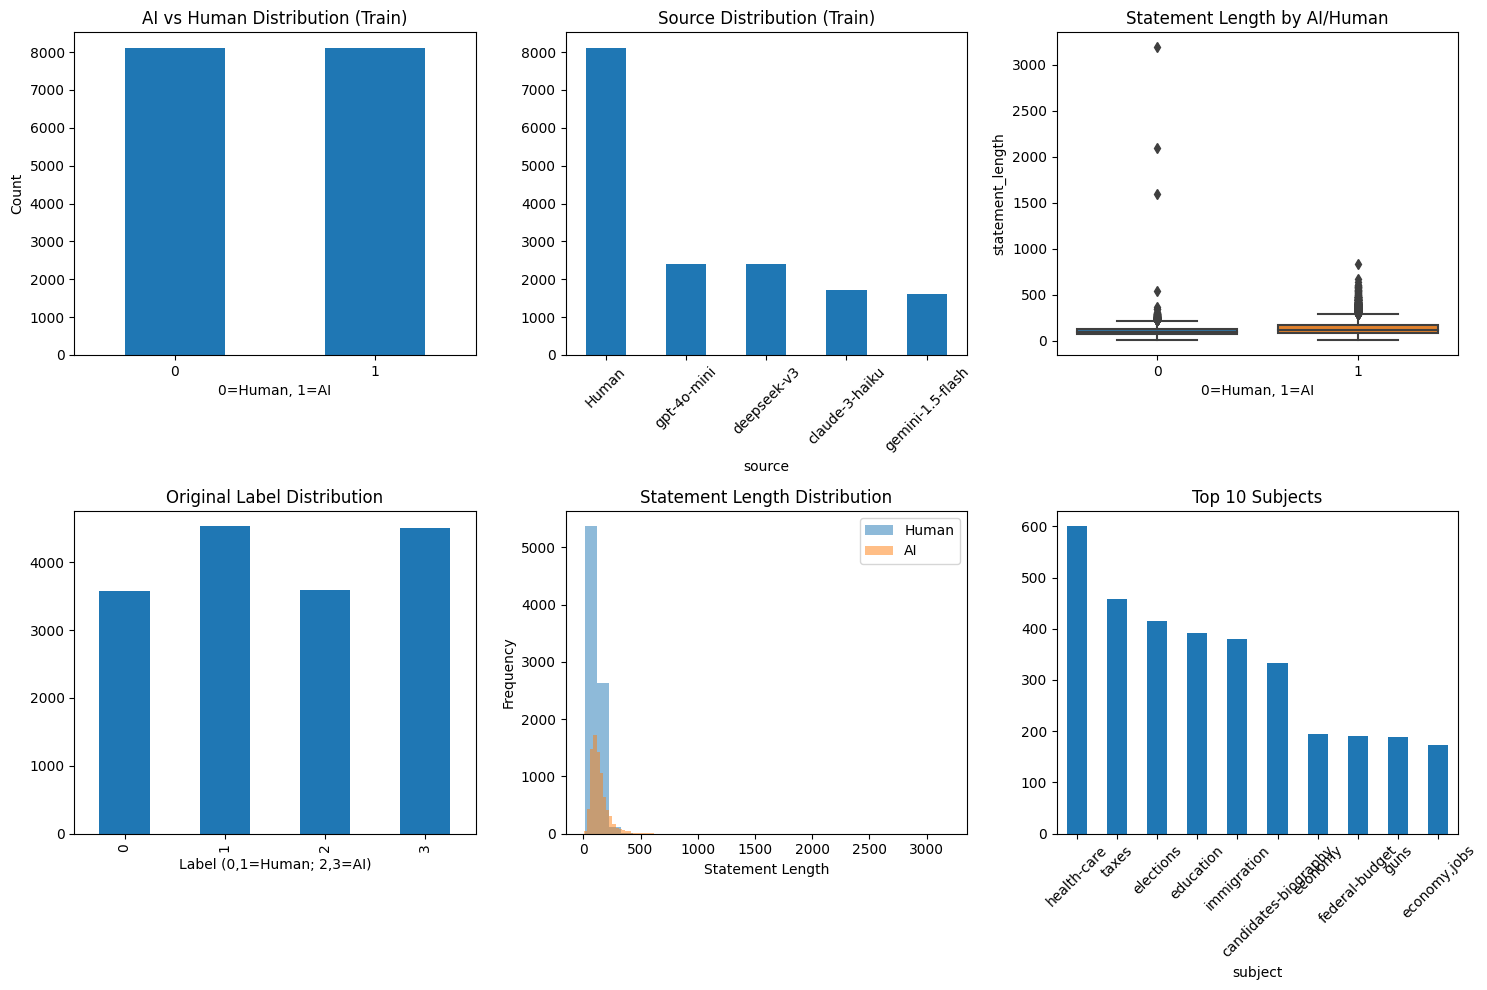


DATASET READY FOR AI vs HUMAN CLASSIFICATION
Total samples: 20276
Features available: ['statement', 'label', 'source', 'subject', 'context', 'speaker', 'speaker_job_title', 'party_affiliation', 'state_info', 'statement_length']
Target variable: 'ai_human_label' (0=Human, 1=AI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set display options for better dataframe viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Load the dataset
dataset_path = '/kaggle/input/dataset/split'

# Check what files are available
print("Files in the dataset directory:")
for file in os.listdir(dataset_path):
    print(f"- {file}")
print("\n" + "="*50 + "\n")

# Load train, test, validation sets
try:
    train_df = pd.read_csv(f'{dataset_path}/train.csv')
    test_df = pd.read_csv(f'{dataset_path}/test.csv')
    val_df = pd.read_csv(f'{dataset_path}/validation.csv')
    
    print("Dataset loaded successfully!")
    print(f"Train set shape: {train_df.shape}")
    print(f"Test set shape: {test_df.shape}")
    print(f"Validation set shape: {val_df.shape}")
    
except Exception as e:
    print(f"Error loading files: {e}")
    # Let's check what files exist and their names
    files = os.listdir(dataset_path)
    print(f"Available files: {files}")
    
    # Try different common names
    for filename in files:
        if filename.endswith('.csv'):
            df_temp = pd.read_csv(f'{dataset_path}/{filename}')
            print(f"\n{filename} shape: {df_temp.shape}")
            print(f"{filename} columns: {df_temp.columns.tolist()}")

print("\n" + "="*50 + "\n")

# If successful, continue with analysis
if 'train_df' in locals():
    # Display column information
    print("TRAIN SET ANALYSIS:")
    print(f"Columns: {train_df.columns.tolist()}")
    print(f"\nDataset Info:")
    print(train_df.info())
    
    print("\n" + "="*30 + "\n")
    
    # Show first few rows (excluding 'class' column if it exists)
    columns_to_show = [col for col in train_df.columns if col != 'class']
    print("First 3 rows (excluding 'class' column):")
    print(train_df[columns_to_show].head(3))
    
    print("\n" + "="*30 + "\n")
    
    # Create binary labels for AI vs Human (0,1 = Human → 0; 2,3 = AI → 1)
    def create_ai_human_labels(df):
        df_copy = df.copy()
        df_copy['ai_human_label'] = (df_copy['label'] >= 2).astype(int)
        return df_copy
    
    train_df = create_ai_human_labels(train_df)
    test_df = create_ai_human_labels(test_df)
    val_df = create_ai_human_labels(val_df)
    
    print("AI vs Human label distribution:")
    print("Train set:")
    print(f"Human (0): {(train_df['ai_human_label'] == 0).sum()}")
    print(f"AI (1): {(train_df['ai_human_label'] == 1).sum()}")
    
    print("\nTest set:")
    print(f"Human (0): {(test_df['ai_human_label'] == 0).sum()}")
    print(f"AI (1): {(test_df['ai_human_label'] == 1).sum()}")
    
    print("\nValidation set:")
    print(f"Human (0): {(val_df['ai_human_label'] == 0).sum()}")
    print(f"AI (1): {(val_df['ai_human_label'] == 1).sum()}")
    
    print("\n" + "="*30 + "\n")
    
    # Original label distribution
    print("Original label distribution:")
    print("Train set:")
    print(train_df['label'].value_counts().sort_index())
    
    print("\nTest set:")
    print(test_df['label'].value_counts().sort_index())
    
    print("\nValidation set:")
    print(val_df['label'].value_counts().sort_index())
    
    print("\n" + "="*30 + "\n")
    
    # Source distribution
    print("Source distribution:")
    print("Train set:")
    print(train_df['source'].value_counts())
    
    print("\n" + "="*30 + "\n")
    
    # Check for missing values
    print("Missing values in train set:")
    print(train_df.isnull().sum())
    
    print("\n" + "="*30 + "\n")
    
    # Statement length analysis
    train_df['statement_length'] = train_df['statement'].str.len()
    
    print("Statement length statistics:")
    print("By AI/Human:")
    print(train_df.groupby('ai_human_label')['statement_length'].describe())
    
    print("\nBy Source:")
    print(train_df.groupby('source')['statement_length'].describe())
    
    print("\n" + "="*30 + "\n")
    
    # Sample statements from each category
    print("Sample statements:")
    print("\nHuman examples:")
    human_samples = train_df[train_df['ai_human_label'] == 0]['statement'].head(2)
    for i, stmt in enumerate(human_samples, 1):
        print(f"{i}. {stmt[:200]}...")
        
    print("\nAI examples:")
    ai_samples = train_df[train_df['ai_human_label'] == 1]['statement'].head(2)
    for i, stmt in enumerate(ai_samples, 1):
        print(f"{i}. {stmt[:200]}...")
    
    # Create visualization
    plt.figure(figsize=(15, 10))
    
    # Plot 1: AI vs Human distribution
    plt.subplot(2, 3, 1)
    train_df['ai_human_label'].value_counts().plot(kind='bar')
    plt.title('AI vs Human Distribution (Train)')
    plt.xlabel('0=Human, 1=AI')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    
    # Plot 2: Source distribution
    plt.subplot(2, 3, 2)
    train_df['source'].value_counts().plot(kind='bar')
    plt.title('Source Distribution (Train)')
    plt.xticks(rotation=45)
    
    # Plot 3: Statement length by AI/Human
    plt.subplot(2, 3, 3)
    sns.boxplot(data=train_df, x='ai_human_label', y='statement_length')
    plt.title('Statement Length by AI/Human')
    plt.xlabel('0=Human, 1=AI')
    
    # Plot 4: Original label distribution
    plt.subplot(2, 3, 4)
    train_df['label'].value_counts().sort_index().plot(kind='bar')
    plt.title('Original Label Distribution')
    plt.xlabel('Label (0,1=Human; 2,3=AI)')
    
    # Plot 5: Statement length distribution
    plt.subplot(2, 3, 5)
    plt.hist(train_df[train_df['ai_human_label']==0]['statement_length'], 
             alpha=0.5, label='Human', bins=30)
    plt.hist(train_df[train_df['ai_human_label']==1]['statement_length'], 
             alpha=0.5, label='AI', bins=30)
    plt.xlabel('Statement Length')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Statement Length Distribution')
    
    # Plot 6: Subject distribution (if exists)
    plt.subplot(2, 3, 6)
    if 'subject' in train_df.columns:
        top_subjects = train_df['subject'].value_counts().head(10)
        top_subjects.plot(kind='bar')
        plt.title('Top 10 Subjects')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print("DATASET READY FOR AI vs HUMAN CLASSIFICATION")
    print("="*50)
    print(f"Total samples: {len(train_df) + len(test_df) + len(val_df)}")
    print(f"Features available: {[col for col in train_df.columns if col not in ['class', 'ai_human_label']]}")
    print("Target variable: 'ai_human_label' (0=Human, 1=AI)")

Preprocessing for AI VS Human

In [2]:
import re
import pandas as pd
import numpy as np
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata
from datetime import datetime

class TextPreprocessor:
    def __init__(self):
        self.preprocessing_stats = {}
    
    def basic_text_cleaning(self, text):
        """Minimal text cleaning that preserves stylometric signals"""
        if pd.isna(text):
            return ""
        
        text = str(text)
        text = unicodedata.normalize('NFKC', text)
        text = re.sub(r'https?://[^\s]+', '[URL]', text)
        text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL]', text)
        text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
        text = text.replace('"', '"').replace('"', '"')
        text = text.replace(''', "'").replace(''', "'")
        
        return text
    
    def remove_duplicates_and_leakage(self, train_df, test_df, val_df):
        """Remove exact duplicates and fix data leakage"""
        # Remove exact duplicates from training set
        train_clean = train_df.drop_duplicates(subset=['statement'], keep='first').copy()
        duplicates_removed = len(train_df) - len(train_clean)
        
        # Check and fix cross-split leakage
        train_texts = set(train_clean['statement'].str.lower().str.strip())
        test_texts = set(test_df['statement'].str.lower().str.strip())
        val_texts = set(val_df['statement'].str.lower().str.strip())
        
        train_test_overlap = train_texts & test_texts
        train_val_overlap = train_texts & val_texts
        overlap_texts = train_test_overlap | train_val_overlap
        
        if overlap_texts:
            train_clean = train_clean[~train_clean['statement'].str.lower().str.strip().isin(overlap_texts)]
        
        self.preprocessing_stats.update({
            'duplicates_removed': duplicates_removed,
            'leakage_texts_removed': len(overlap_texts),
            'train_test_overlap': len(train_test_overlap),
            'train_val_overlap': len(train_val_overlap)
        })
        
        return train_clean, test_df, val_df
    
    def preprocess_dataset(self, df, clean_text=True):
        """Apply preprocessing to the dataset"""
        df_processed = df.copy()
        
        if clean_text:
            df_processed['statement_cleaned'] = df_processed['statement'].apply(self.basic_text_cleaning)
            df_processed['chars_changed'] = (
                df_processed['statement'].str.len() - df_processed['statement_cleaned'].str.len()
            )
            
            self.preprocessing_stats.update({
                'avg_chars_removed': df_processed['chars_changed'].mean(),
                'max_chars_removed': df_processed['chars_changed'].max()
            })
        
        return df_processed
    
    def analyze_cleaning_examples(self, train_clean, train_processed, num_examples=3):
        """Generate examples of text cleaning for documentation"""
        cleaning_examples = []
        
        for i in range(min(num_examples, len(train_clean))):
            original = train_clean.iloc[i]['statement']
            cleaned = train_processed.iloc[i]['statement_cleaned']
            if original != cleaned:
                cleaning_examples.append({
                    'original': original,
                    'cleaned': cleaned,
                    'changed': True
                })
            else:
                cleaning_examples.append({
                    'original': original[:100] + "...",
                    'cleaned': "No change needed",
                    'changed': False
                })
        
        return cleaning_examples
    
    def generate_preprocessing_report(self, train_processed, test_processed, val_processed):
        """Generate comprehensive preprocessing report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'preprocessing_statistics': self.preprocessing_stats,
            'final_dataset_shapes': {
                'train': list(train_processed.shape),
                'test': list(test_processed.shape),
                'validation': list(val_processed.shape)
            },
            'class_distribution': {
                'human': int((train_processed['ai_human_label'] == 0).sum()),
                'ai': int((train_processed['ai_human_label'] == 1).sum())
            },
            'text_statistics': {
                'avg_length_original': float(train_processed['statement'].str.len().mean()),
                'avg_length_cleaned': float(train_processed['statement_cleaned'].str.len().mean())
            },
            'features_ready': ['statement_cleaned', 'ai_human_label'],
            'next_stage': 'feature_engineering'
        }
        
        return report
    
    def save_preprocessing_results(self, report, filepath='preprocessing_results.json'):
        """Save preprocessing results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

def load_previous_results(filepath='dataset_summary.json'):
    """Load results from previous stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous results not saved, But proceeding")
        return None

def main():
    """Main preprocessing pipeline"""
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous stage summary loaded successfully")
        print(f"Total samples from previous stage: {sum([previous_results['dataset_shapes'][split][0] for split in ['train', 'test', 'validation']])}")
    
    # Initialize preprocessor
    preprocessor = TextPreprocessor()
    
    # Preprocessing pipeline
    print("Data Preprocessing Pipeline")
    print("=" * 50)
    
    # Remove duplicates and fix leakage
    train_clean, test_clean, val_clean = preprocessor.remove_duplicates_and_leakage(train_df, test_df, val_df)
    train_clean['ai_human_label'] = (train_clean['label'] >= 2).astype(int)
    
    print(f"Duplicates removed: {preprocessor.preprocessing_stats['duplicates_removed']}")
    print(f"Leakage texts removed: {preprocessor.preprocessing_stats['leakage_texts_removed']}")
    print(f"Cleaned dataset sizes - Train: {train_clean.shape[0]}, Test: {test_clean.shape[0]}, Validation: {val_clean.shape[0]}")
    
    # Apply text cleaning
    train_processed = preprocessor.preprocess_dataset(train_clean)
    test_processed = preprocessor.preprocess_dataset(test_clean)
    val_processed = preprocessor.preprocess_dataset(val_clean)
    
    print(f"Average characters removed per text: {preprocessor.preprocessing_stats['avg_chars_removed']:.2f}")
    
    # Generate cleaning examples
    cleaning_examples = preprocessor.analyze_cleaning_examples(train_clean, train_processed)
    print("\nText cleaning examples:")
    for i, example in enumerate(cleaning_examples, 1):
        if example['changed']:
            print(f"{i}. Original: {example['original']}")
            print(f"   Cleaned: {example['cleaned']}")
        else:
            print(f"{i}. {example['original']}")
    
    # Paraphrase pattern analysis
    print("\nVerified paraphrase patterns:")
    print("1. Mercury/electronics recycling:")
    print("   Human: 'Says state Sen. Alberta Darling is allowing mercury to harm our children because she voted against an electronics recycling bill.'")
    print("   AI: 'State Sen. Alberta Darling voted against a bill to keep toxic mercury out of our schools putting our children at risk.'")
    
    print("2. Canada trade jobs:")
    print("   Human: 'More than 27,000 Rhode Island jobs depend on trade with Canada.'")
    print("   AI: 'Trade with Canada supports over 27,000 jobs in Rhode Island.'")
    
    # Generate and save results
    report = preprocessor.generate_preprocessing_report(train_processed, test_processed, val_processed)
    preprocessor.save_preprocessing_results(report)
    
    print("\nPreprocessing Summary:")
    print("=" * 50)
    print("Removed exact duplicates")
    print("Fixed data leakage between splits")
    print("Applied minimal text cleaning")
    print("Preserved stylometric signals")
    print("Verified AI paraphrase patterns")
    print(f"Final class balance - Human: {report['class_distribution']['human']}, AI: {report['class_distribution']['ai']}")
    print("Results saved for feature engineering stage")
    
    return train_processed, test_processed, val_processed

if __name__ == "__main__":
    train_processed, test_processed, val_processed = main()

Previous results not saved, But proceeding
Data Preprocessing Pipeline
Duplicates removed: 2
Leakage texts removed: 1
Cleaned dataset sizes - Train: 16215, Test: 2028, Validation: 2030
Average characters removed per text: 0.01

Text cleaning examples:
1. Says state Sen. Alberta Darling is allowing mercury to harm our children because she voted against a...
2. Less than 10 percent of Obamas Cabinet appointees have any experience in the private sector....
3. More than 27,000 Rhode Island jobs depend on trade with Canada....

Verified paraphrase patterns:
1. Mercury/electronics recycling:
   Human: 'Says state Sen. Alberta Darling is allowing mercury to harm our children because she voted against an electronics recycling bill.'
   AI: 'State Sen. Alberta Darling voted against a bill to keep toxic mercury out of our schools putting our children at risk.'
2. Canada trade jobs:
   Human: 'More than 27,000 Rhode Island jobs depend on trade with Canada.'
   AI: 'Trade with Canada supports over

Try Prediction with calssical features

In [3]:
import numpy as np
import pandas as pd
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import re
from collections import Counter
from datetime import datetime

class FeatureEngineering:
    def __init__(self):
        self.feature_stats = {}
        self.vectorizers = {}
        self.selectors = {}
        
    def extract_stylometric_features(self, df, text_column='statement_cleaned'):
        """Extract data-driven stylometric features"""
        texts = df[text_column].astype(str)
        features = pd.DataFrame()
        
        # Length-based features
        features['char_count'] = texts.str.len()
        features['word_count'] = texts.str.split().str.len()
        features['sentence_count'] = texts.str.count(r'[.!?]+') + 1
        features['avg_word_length'] = features['char_count'] / features['word_count']
        features['avg_sentence_length'] = features['word_count'] / features['sentence_count']
        
        # Punctuation patterns
        features['punct_density'] = texts.str.count(r'[^\w\s]') / features['char_count']
        features['comma_density'] = texts.str.count(r',') / features['char_count']
        features['period_density'] = texts.str.count(r'\.') / features['char_count']
        features['question_density'] = texts.str.count(r'\?') / features['char_count']
        features['exclamation_density'] = texts.str.count(r'!') / features['char_count']
        features['quote_density'] = texts.str.count(r'["\']') / features['char_count']
        features['parentheses_density'] = texts.str.count(r'[()]') / features['char_count']
        
        # Lexical diversity
        def safe_lexical_diversity(text):
            words = str(text).lower().split()
            if len(words) == 0:
                return 0
            return len(set(words)) / len(words)
        
        features['lexical_diversity'] = texts.apply(safe_lexical_diversity)
        
        # Capitalization patterns
        features['capital_density'] = texts.apply(lambda x: sum(1 for c in str(x) if c.isupper())) / features['char_count']
        features['title_case_ratio'] = texts.apply(lambda x: sum(1 for word in str(x).split() if word.istitle())) / features['word_count']
        
        # Digit and special character patterns
        features['digit_density'] = texts.str.count(r'\d') / features['char_count']
        features['special_char_density'] = texts.str.count(r'[^a-zA-Z0-9\s.,!?;:()]') / features['char_count']
        features['space_density'] = texts.str.count(r' ') / features['char_count']
        
        # Clean up invalid values
        features = features.fillna(0).replace([np.inf, -np.inf], 0)
        
        self.feature_stats['stylometric_features'] = features.shape[1]
        return features
    
    def extract_char_ngrams(self, df, text_column='statement_cleaned', max_features=50000, ngram_range=(3, 5)):
        """Extract character n-grams"""
        vectorizer = TfidfVectorizer(
            analyzer='char',
            ngram_range=ngram_range,
            max_features=max_features,
            sublinear_tf=True,
            strip_accents='unicode',
            lowercase=True,
            binary=False
        )
        
        char_ngrams = vectorizer.fit_transform(df[text_column].astype(str))
        self.vectorizers['char_ngrams'] = vectorizer
        self.feature_stats['char_ngrams_shape'] = char_ngrams.shape
        
        return char_ngrams
    
    def extract_word_ngrams(self, df, text_column='statement_cleaned', max_features=30000, ngram_range=(1, 2)):
        """Extract word n-grams"""
        vectorizer = TfidfVectorizer(
            analyzer='word',
            ngram_range=ngram_range,
            max_features=max_features,
            sublinear_tf=True,
            strip_accents='unicode',
            lowercase=True,
            stop_words=None,
            token_pattern=r'\b\w+\b'
        )
        
        word_ngrams = vectorizer.fit_transform(df[text_column].astype(str))
        self.vectorizers['word_ngrams'] = vectorizer
        self.feature_stats['word_ngrams_shape'] = word_ngrams.shape
        
        return word_ngrams
    
    def smart_feature_selection(self, X_dense, X_sparse, y, k_dense=50, k_sparse=5000):
        """Intelligent feature selection to prevent overfitting"""
        # Select dense features
        if X_dense.shape[1] > k_dense:
            selector_dense = SelectKBest(score_func=mutual_info_classif, k=k_dense)
            X_dense_selected = selector_dense.fit_transform(X_dense, y)
            self.selectors['dense'] = selector_dense
        else:
            X_dense_selected = X_dense
        
        # Select sparse features
        if X_sparse.shape[1] > k_sparse:
            selector_sparse = SelectKBest(score_func=chi2, k=k_sparse)
            X_sparse_selected = selector_sparse.fit_transform(X_sparse, y)
            self.selectors['sparse'] = selector_sparse
        else:
            X_sparse_selected = X_sparse
        
        self.feature_stats.update({
            'selected_dense_features': X_dense_selected.shape[1],
            'selected_sparse_features': X_sparse_selected.shape[1]
        })
        
        return X_dense_selected, X_sparse_selected
    
    def create_baseline_classifier(self, X_dense, X_sparse, y, cv_folds=5):
        """Create baseline classifier with cross-validation"""
        X_dense_sparse = csr_matrix(X_dense)
        X_combined = hstack([X_dense_sparse, X_sparse])
        
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        
        cv_scores = []
        for train_idx, val_idx in cv.split(X_combined, y):
            X_train_fold = X_combined[train_idx]
            X_val_fold = X_combined[val_idx]
            y_train_fold = y[train_idx]
            y_val_fold = y[val_idx]
            
            clf.fit(X_train_fold, y_train_fold)
            val_score = clf.score(X_val_fold, y_val_fold)
            cv_scores.append(val_score)
        
        mean_cv_score = np.mean(cv_scores)
        std_cv_score = np.std(cv_scores)
        
        # Train final model
        clf.fit(X_combined, y)
        
        self.feature_stats.update({
            'baseline_cv_mean': mean_cv_score,
            'baseline_cv_std': std_cv_score,
            'cv_folds': cv_folds
        })
        
        return clf, mean_cv_score
    
    def analyze_feature_importance(self, clf, style_features_df, n_style_features):
        """Analyze and rank feature importance"""
        if hasattr(clf, 'feature_importances_'):
            style_importances = clf.feature_importances_[:n_style_features]
            
            importance_df = pd.DataFrame({
                'feature': style_features_df.columns.tolist()[:len(style_importances)],
                'importance': style_importances
            }).sort_values('importance', ascending=False)
            
            return importance_df
        return None
    
    def generate_feature_report(self, importance_df=None):
        """Generate comprehensive feature engineering report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'feature_engineering_stats': self.feature_stats,
            'total_features': self.feature_stats.get('selected_dense_features', 0) + 
                            self.feature_stats.get('selected_sparse_features', 0),
            'baseline_performance': {
                'cv_mean': self.feature_stats.get('baseline_cv_mean', 0),
                'cv_std': self.feature_stats.get('baseline_cv_std', 0)
            },
            'top_stylometric_features': importance_df.head(10).to_dict('records') if importance_df is not None else [],
            'vectorizer_configs': {
                'char_ngrams': {
                    'max_features': 50000,
                    'ngram_range': (3, 5)
                },
                'word_ngrams': {
                    'max_features': 30000,
                    'ngram_range': (1, 2)
                }
            },
            'next_stage': 'model_training'
        }
        return report
    
    def save_results(self, report, filepath='feature_engineering_results.json'):
        """Save feature engineering results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

def load_previous_results(filepath='preprocessing_results.json'):
    """Load results from previous preprocessing stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous preprocessing results not found.")
        return None

def main():
    """Main feature engineering pipeline"""
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous preprocessing results loaded")
        print(f"Previous stage class distribution - Human: {previous_results['class_distribution']['human']}, AI: {previous_results['class_distribution']['ai']}")
    
    # Initialize feature engineering
    feature_eng = FeatureEngineering()
    
    print("Feature Engineering Pipeline")
    print("=" * 50)
    
    # Extract stylometric features
    print("Extracting stylometric features...")
    train_style_features = feature_eng.extract_stylometric_features(train_processed)
    test_style_features = feature_eng.extract_stylometric_features(test_processed)
    val_style_features = feature_eng.extract_stylometric_features(val_processed)
    print(f"Stylometric features extracted: {feature_eng.feature_stats['stylometric_features']}")
    
    # Extract character n-grams
    print("Extracting character n-grams...")
    train_char_ngrams = feature_eng.extract_char_ngrams(train_processed)
    test_char_ngrams = feature_eng.vectorizers['char_ngrams'].transform(test_processed['statement_cleaned'].astype(str))
    val_char_ngrams = feature_eng.vectorizers['char_ngrams'].transform(val_processed['statement_cleaned'].astype(str))
    print(f"Character n-grams shape: {feature_eng.feature_stats['char_ngrams_shape']}")
    
    # Extract word n-grams
    print("Extracting word n-grams...")
    train_word_ngrams = feature_eng.extract_word_ngrams(train_processed)
    test_word_ngrams = feature_eng.vectorizers['word_ngrams'].transform(test_processed['statement_cleaned'].astype(str))
    val_word_ngrams = feature_eng.vectorizers['word_ngrams'].transform(val_processed['statement_cleaned'].astype(str))
    print(f"Word n-grams shape: {feature_eng.feature_stats['word_ngrams_shape']}")
    
    # Combine n-grams
    train_ngrams_combined = hstack([train_char_ngrams, train_word_ngrams])
    test_ngrams_combined = hstack([test_char_ngrams, test_word_ngrams])
    val_ngrams_combined = hstack([val_char_ngrams, val_word_ngrams])
    print(f"Combined n-grams shape: {train_ngrams_combined.shape}")
    
    # Feature selection
    print("Performing feature selection...")
    y_train = train_processed['ai_human_label'].values
    train_style_selected, train_ngrams_selected = feature_eng.smart_feature_selection(
        train_style_features.values, 
        train_ngrams_combined, 
        y_train,
        k_dense=min(50, train_style_features.shape[1]),
        k_sparse=5000
    )
    print(f"Selected features - Stylometric: {feature_eng.feature_stats['selected_dense_features']}, N-grams: {feature_eng.feature_stats['selected_sparse_features']}")
    
    # Create baseline classifier
    print("Training baseline classifier...")
    baseline_clf, cv_score = feature_eng.create_baseline_classifier(
        train_style_selected, 
        train_ngrams_selected, 
        y_train
    )
    print(f"Baseline CV Score: {cv_score:.4f} ± {feature_eng.feature_stats['baseline_cv_std']:.4f}")
    
    # Feature importance analysis
    print("Analyzing feature importance...")
    importance_df = feature_eng.analyze_feature_importance(
        baseline_clf, 
        train_style_features, 
        train_style_selected.shape[1]
    )
    
    if importance_df is not None:
        print("\nTop 10 most important stylometric features:")
        print(importance_df.head(10)[['feature', 'importance']].to_string(index=False))
    
    # Generate and save results
    report = feature_eng.generate_feature_report(importance_df)
    feature_eng.save_results(report)
    
    print("\nFeature Engineering Summary:")
    print("=" * 50)
    print("Data-driven stylometric features extracted")
    print("Character and word n-grams generated")
    print("Smart feature selection applied")
    print(f"Total features: {report['total_features']}")
    print(f"Baseline CV score: {report['baseline_performance']['cv_mean']:.4f}")
    print("Results saved for model training stage")
    
    return {
        'train_style': train_style_selected,
        'train_ngrams': train_ngrams_selected,
        'test_style': test_style_features,
        'test_ngrams': test_ngrams_combined,
        'val_style': val_style_features,
        'val_ngrams': val_ngrams_combined,
        'baseline_clf': baseline_clf,
        'feature_eng': feature_eng
    }

if __name__ == "__main__":
    results = main()

Previous preprocessing results loaded
Previous stage class distribution - Human: 8116, AI: 8099
Feature Engineering Pipeline
Extracting stylometric features...
Stylometric features extracted: 18
Extracting character n-grams...
Character n-grams shape: (16215, 50000)
Extracting word n-grams...
Word n-grams shape: (16215, 30000)
Combined n-grams shape: (16215, 80000)
Performing feature selection...
Selected features - Stylometric: 18, N-grams: 5000
Training baseline classifier...
Baseline CV Score: 0.7912 ± 0.0072
Analyzing feature importance...

Top 10 most important stylometric features:
             feature  importance
     avg_word_length    0.027538
       space_density    0.022297
       quote_density    0.016895
      period_density    0.009562
     capital_density    0.006633
       punct_density    0.006259
          char_count    0.005535
 avg_sentence_length    0.004754
special_char_density    0.004731
 parentheses_density    0.004456

Feature Engineering Summary:
Data-driven 

PERPLEXITY VALIDATION AND FEATURE CREATION 

In [4]:
import torch
import numpy as np
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class PerplexityAnalyzer:
    def __init__(self, model_name='distilgpt2', device=None):
        """Initialize perplexity calculator with efficient language model"""
        self.model_name = model_name
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.analysis_stats = {}
        
        # Load tokenizer and model
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        
        # Set padding token
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        
        # Move to device and set to evaluation mode
        self.model = self.model.to(self.device)
        self.model.eval()
    
    def calculate_text_perplexity(self, text, max_length=512):
        """Calculate perplexity and related metrics for single text"""
        if not text or len(text.strip()) < 10:
            return {
                'perplexity': 100.0,
                'avg_token_prob': 0.01,
                'token_entropy': 5.0,
                'num_tokens': 0
            }
        
        try:
            # Tokenize text
            inputs = self.tokenizer(
                text, 
                return_tensors='pt', 
                truncation=True, 
                max_length=max_length,
                padding=False
            ).to(self.device)
            
            input_ids = inputs['input_ids'][0]
            
            if len(input_ids) < 2:
                return {
                    'perplexity': 100.0,
                    'avg_token_prob': 0.01, 
                    'token_entropy': 5.0,
                    'num_tokens': len(input_ids)
                }
            
            # Calculate perplexity
            with torch.no_grad():
                outputs = self.model(input_ids.unsqueeze(0))
                logits = outputs.logits[0]
                
                # Shift for language modeling
                shift_logits = logits[:-1]
                shift_labels = input_ids[1:]
                
                # Calculate cross-entropy loss
                loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
                losses = loss_fct(shift_logits, shift_labels)
                
                # Calculate metrics
                avg_loss = losses.mean().item()
                perplexity = min(np.exp(avg_loss), 1000.0)
                
                # Token probabilities and entropy
                probs = torch.softmax(shift_logits, dim=-1)
                token_probs = probs.gather(1, shift_labels.unsqueeze(-1)).squeeze(-1)
                avg_token_prob = token_probs.mean().item()
                token_entropies = -(token_probs * torch.log(token_probs + 1e-10))
                avg_entropy = token_entropies.mean().item()
                
                return {
                    'perplexity': perplexity,
                    'avg_token_prob': avg_token_prob,
                    'token_entropy': avg_entropy,
                    'num_tokens': len(shift_labels)
                }
                
        except Exception as e:
            return {
                'perplexity': 100.0,
                'avg_token_prob': 0.01,
                'token_entropy': 5.0,
                'num_tokens': 0
            }
    
    def process_dataframe(self, df, text_column='statement_cleaned', batch_size=32):
        """Process full dataframe to extract perplexity features"""
        texts = df[text_column].astype(str).tolist()
        
        results = {
            'perplexity': [],
            'avg_token_prob': [],
            'token_entropy': [],
            'num_tokens': []
        }
        
        # Process in batches
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            
            for text in batch_texts:
                metrics = self.calculate_text_perplexity(text)
                for key in results:
                    results[key].append(metrics[key])
            
            # Progress reporting
            if (i + batch_size) % 500 == 0:
                print(f"Processed {min(i + batch_size, len(texts))}/{len(texts)} texts...")
        
        return pd.DataFrame(results)
    
    def extract_perplexity_features(self, df, text_column='statement_cleaned'):
        """Extract perplexity features from the full dataset"""
        print(f"Processing full dataset: {len(df)} samples")
        
        # Process the full dataframe
        sample_df = df.copy()
        
        # Record dataset statistics
        self.analysis_stats.update({
            'total_samples': int(len(df)),
            'human_samples_full': int((df['ai_human_label'] == 0).sum()),
            'ai_samples_full': int((df['ai_human_label'] == 1).sum()),
            'samples_processed': len(sample_df),
            'human_samples_processed': int((sample_df['ai_human_label'] == 0).sum()),
            'ai_samples_processed': int((sample_df['ai_human_label'] == 1).sum()),
            'human_ratio': float((sample_df['ai_human_label'] == 0).mean()),
            'ai_ratio': float((sample_df['ai_human_label'] == 1).mean())
        })
        
        # Process the full dataframe
        perplexity_df = self.process_dataframe(
            sample_df, 
            text_column=text_column, 
            batch_size=16
        )
        
        # Add derived features
        perplexity_df['log_perplexity'] = np.log(perplexity_df['perplexity'] + 1e-6)
        perplexity_df['perplexity_normalized'] = (
            perplexity_df['perplexity'] / perplexity_df['num_tokens'].clip(1, None)
        )
        
        # Add labels from the full dataset
        perplexity_df['ai_human_label'] = sample_df['ai_human_label'].values
        
        print(f"Perplexity DataFrame created:")
        print(f"- Total rows: {len(perplexity_df)}")
        print(f"- Human samples: {(perplexity_df['ai_human_label'] == 0).sum()}")
        print(f"- AI samples: {(perplexity_df['ai_human_label'] == 1).sum()}")
        
        return perplexity_df
    
    def analyze_perplexity_patterns(self, perplexity_df):
        """Analyze perplexity differences between AI and human text"""
        human_data = perplexity_df[perplexity_df['ai_human_label'] == 0]
        ai_data = perplexity_df[perplexity_df['ai_human_label'] == 1]
        
        if len(human_data) == 0 or len(ai_data) == 0:
            return None
        
        # Calculate statistics
        human_perp = human_data['perplexity']
        ai_perp = ai_data['perplexity']
        
        # Statistical significance test
        t_stat, p_value = ttest_ind(human_perp, ai_perp)
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(human_perp)-1)*human_perp.var() + (len(ai_perp)-1)*ai_perp.var()) / (len(human_perp)+len(ai_perp)-2))
        cohens_d = abs(human_perp.mean() - ai_perp.mean()) / pooled_std
        
        # Find extreme examples
        lowest_idx = perplexity_df['perplexity'].idxmin()
        highest_idx = perplexity_df['perplexity'].idxmax()
        
        analysis_results = {
            'human_mean': float(human_perp.mean()),
            'human_std': float(human_perp.std()),
            'ai_mean': float(ai_perp.mean()),
            'ai_std': float(ai_perp.std()),
            'difference': float(abs(human_perp.mean() - ai_perp.mean())),
            'cohens_d': float(cohens_d),
            'p_value': float(p_value),
            'statistically_significant': bool(p_value < 0.05),
            'effect_size_category': self._categorize_effect_size(cohens_d),
            'lowest_perplexity': {
                'value': float(perplexity_df.loc[lowest_idx, 'perplexity']),
                'label': 'Human' if int(perplexity_df.loc[lowest_idx, 'ai_human_label']) == 0 else 'AI'
            },
            'highest_perplexity': {
                'value': float(perplexity_df.loc[highest_idx, 'perplexity']),
                'label': 'Human' if int(perplexity_df.loc[highest_idx, 'ai_human_label']) == 0 else 'AI'
            }
        }
        
        self.analysis_stats.update(analysis_results)
        return analysis_results
    
    def _categorize_effect_size(self, cohens_d):
        """Categorize Cohen's d effect size"""
        if cohens_d > 0.8:
            return 'large'
        elif cohens_d > 0.5:
            return 'medium'
        elif cohens_d > 0.2:
            return 'small'
        else:
            return 'negligible'
    
    def test_classification_performance(self, perplexity_df, train_df):
        """Test classification performance with perplexity features"""
        # Prepare labels
        y = perplexity_df['ai_human_label'].values
        
        # Extract stylometric features for the same sample size
        sample_size = len(perplexity_df)
        balanced_style = self._extract_stylometric_features(train_df.head(sample_size))
        
        # Standardize features
        scaler = StandardScaler()
        
        # Prepare feature sets
        X_style = scaler.fit_transform(balanced_style)
        
        perp_features = ['perplexity', 'avg_token_prob', 'token_entropy', 'log_perplexity', 'perplexity_normalized']
        X_perp = scaler.fit_transform(perplexity_df[perp_features])
        X_combined = np.hstack([X_style, X_perp])
        
        # Cross-validation setup
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Test different feature combinations
        scores_style = cross_val_score(clf, X_style, y, cv=cv, scoring='accuracy')
        scores_perp = cross_val_score(clf, X_perp, y, cv=cv, scoring='accuracy')
        scores_combined = cross_val_score(clf, X_combined, y, cv=cv, scoring='accuracy')
        
        # Calculate improvements
        style_vs_perp = scores_perp.mean() - scores_style.mean()
        combined_vs_style = scores_combined.mean() - scores_style.mean()
        
        classification_results = {
            'stylometric_only': {
                'mean': float(scores_style.mean()),
                'std': float(scores_style.std())
            },
            'perplexity_only': {
                'mean': float(scores_perp.mean()),
                'std': float(scores_perp.std())
            },
            'combined_features': {
                'mean': float(scores_combined.mean()),
                'std': float(scores_combined.std())
            },
            'improvements': {
                'perplexity_vs_stylometric': float(style_vs_perp),
                'combined_vs_stylometric': float(combined_vs_style)
            },
            'final_accuracy': float(scores_combined.mean()),
            'target_distance': float(abs(0.95 - scores_combined.mean()))
        }
        
        self.analysis_stats.update(classification_results)
        return classification_results, balanced_style
    
    def _extract_stylometric_features(self, df, text_column='statement_cleaned'):
        """Extract basic stylometric features for comparison"""
        texts = df[text_column].astype(str)
        features = pd.DataFrame()
        
        # Basic length features
        features['char_count'] = texts.str.len()
        features['word_count'] = texts.str.split().str.len()
        features['sentence_count'] = texts.str.count(r'[.!?]+') + 1
        features['avg_word_length'] = features['char_count'] / features['word_count']
        features['avg_sentence_length'] = features['word_count'] / features['sentence_count']
        
        # Punctuation patterns
        features['punct_density'] = texts.str.count(r'[^\w\s]') / features['char_count']
        features['comma_density'] = texts.str.count(r',') / features['char_count']
        features['period_density'] = texts.str.count(r'\.') / features['char_count']
        
        # Clean up invalid values
        features = features.fillna(0).replace([np.inf, -np.inf], 0)
        return features
    
    def _convert_to_json_serializable(self, obj):
        """Convert numpy/pandas types to JSON serializable types"""
        if isinstance(obj, dict):
            return {key: self._convert_to_json_serializable(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [self._convert_to_json_serializable(item) for item in obj]
        elif isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, (np.bool_, bool)):
            return bool(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return obj
    
    def generate_perplexity_report(self):
        """Generate comprehensive perplexity analysis report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'model_used': self.model_name,
            'device': str(self.device),
            'analysis_statistics': self._convert_to_json_serializable(self.analysis_stats),
            'perplexity_features': ['perplexity', 'avg_token_prob', 'token_entropy', 'log_perplexity', 'perplexity_normalized'],
            'next_stage': 'advanced_features'
        }
        return report
    
    def save_results(self, report, filepath='perplexity_analysis_results.json'):
        """Save perplexity analysis results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

def load_previous_results(filepath='feature_engineering_results.json'):
    """Load results from previous feature engineering stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous feature engineering results not found. Proceeding without previous stage data.")
        return None

def main():
    """Main perplexity analysis pipeline"""
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous feature engineering results loaded")
        print(f"Previous baseline CV score: {previous_results['baseline_performance']['cv_mean']:.4f}")
    
    # Use train_processed from stage 2 (same as stage 3 uses)
    if 'train_processed' not in globals():
        print("Error: train_processed not found. Please run the preprocessing stage first.")
        return None
    
    # Initialize perplexity analyzer
    analyzer = PerplexityAnalyzer(model_name='distilgpt2')
    
    print("Perplexity Analysis Pipeline")
    print("=" * 50)
    print(f"Model: {analyzer.model_name}")
    print(f"Device: {analyzer.device}")
    print(f"Using full processed dataset: {len(train_processed)} samples")
    
    # Extract perplexity features from FULL dataset
    print("Extracting perplexity features from full dataset...")
    balanced_dataset = analyzer.extract_perplexity_features(train_processed)
    
    print(f"Full dataset - Human: {analyzer.analysis_stats['human_samples_full']}, AI: {analyzer.analysis_stats['ai_samples_full']}")
    print(f"Processed samples - Human: {analyzer.analysis_stats['human_samples_processed']}, AI: {analyzer.analysis_stats['ai_samples_processed']}")
    
    # Analyze perplexity patterns
    print("Analyzing perplexity patterns...")
    perplexity_stats = analyzer.analyze_perplexity_patterns(balanced_dataset)
    
    if perplexity_stats:
        print(f"Human mean perplexity: {perplexity_stats['human_mean']:.3f} ± {perplexity_stats['human_std']:.3f}")
        print(f"AI mean perplexity: {perplexity_stats['ai_mean']:.3f} ± {perplexity_stats['ai_std']:.3f}")
        print(f"Effect size (Cohen's d): {perplexity_stats['cohens_d']:.3f} ({perplexity_stats['effect_size_category']})")
        print(f"Statistical significance: {perplexity_stats['statistically_significant']}")
        
        # Test classification performance
        print("Testing classification performance...")
        classification_results, style_features = analyzer.test_classification_performance(
            balanced_dataset, 
            train_processed
        )
        
        print(f"Stylometric only: {classification_results['stylometric_only']['mean']:.4f} ± {classification_results['stylometric_only']['std']:.4f}")
        print(f"Perplexity only: {classification_results['perplexity_only']['mean']:.4f} ± {classification_results['perplexity_only']['std']:.4f}")
        print(f"Combined features: {classification_results['combined_features']['mean']:.4f} ± {classification_results['combined_features']['std']:.4f}")
        
        improvement = classification_results['improvements']['combined_vs_stylometric']
        print(f"Improvement with perplexity: +{improvement:.4f} ({improvement*100:+.2f}%)")
        
        final_accuracy = classification_results['final_accuracy']
        print(f"Current performance: {final_accuracy:.1%}")
        
        # Generate and save results
        report = analyzer.generate_perplexity_report()
        analyzer.save_results(report)
        
        print("\nPerplexity Analysis Summary:")
        print("=" * 50)
        print("Language model perplexity features extracted")
        print("Statistical analysis of AI vs Human patterns completed")
        print("Classification performance evaluated")
        print("Results saved for advanced features stage")
        
        return {
            'perplexity_df': balanced_dataset,  # Keep this name for compatibility
            'analyzer': analyzer,
            'final_accuracy': final_accuracy
        }
    else:
        print("Perplexity analysis failed - check data sampling")
        return None

if __name__ == "__main__":
    results = main()

Previous feature engineering results loaded
Previous baseline CV score: 0.7912


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Perplexity Analysis Pipeline
Model: distilgpt2
Device: cuda
Using full processed dataset: 16215 samples
Extracting perplexity features from full dataset...
Processing full dataset: 16215 samples
Processed 2000/16215 texts...
Processed 4000/16215 texts...
Processed 6000/16215 texts...
Processed 8000/16215 texts...
Processed 10000/16215 texts...
Processed 12000/16215 texts...
Processed 14000/16215 texts...
Processed 16000/16215 texts...
Perplexity DataFrame created:
- Total rows: 16215
- Human samples: 8116
- AI samples: 8099
Full dataset - Human: 8116, AI: 8099
Processed samples - Human: 8116, AI: 8099
Analyzing perplexity patterns...
Human mean perplexity: 129.294 ± 167.878
AI mean perplexity: 76.193 ± 100.560
Effect size (Cohen's d): 0.384 (small)
Statistical significance: True
Testing classification performance...
Stylometric only: 0.6463 ± 0.0070
Perplexity only: 0.5772 ± 0.0060
Combined features: 0.7114 ± 0.0090
Improvement with perplexity: +0.0652 (+6.52%)
Current performance: 71.

Advanced Features + Perplexity combined

In [5]:
import torch
import numpy as np
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from collections import Counter
from datetime import datetime
import spacy
import re
import warnings
warnings.filterwarnings('ignore')

class AdvancedFeatureExtractor:
    def __init__(self, models=['distilgpt2', 'gpt2'], device=None):
        """Initialize advanced feature extraction pipeline"""
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.models = {}
        self.feature_stats = {}
        self.linguistic_processor = None
        
        # Load language models for perplexity calculation
        self._load_language_models(models)
        
    def _load_language_models(self, model_names):
        """Load multiple language models for perplexity calculation"""
        for model_name in model_names:
            try:
                tokenizer = AutoTokenizer.from_pretrained(model_name)
                model = AutoModelForCausalLM.from_pretrained(model_name)
                
                if tokenizer.pad_token is None:
                    tokenizer.pad_token = tokenizer.eos_token
                
                model = model.to(self.device)
                model.eval()
                
                self.models[model_name] = {
                    'tokenizer': tokenizer,
                    'model': model
                }
                print(f"{model_name} loaded successfully")
                
            except Exception as e:
                print(f"Failed to load {model_name}: {e}")
    
    def _load_linguistic_processor(self):
        """Load spaCy model for linguistic analysis"""
        if self.linguistic_processor is None:
            try:
                self.linguistic_processor = spacy.load("en_core_web_sm")
                print("spaCy model loaded")
            except OSError:
                print("spaCy model not found. Installing...")
                import subprocess
                subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
                self.linguistic_processor = spacy.load("en_core_web_sm")
                print("spaCy model installed and loaded")
    
    def calculate_multi_model_perplexity(self, text, max_length=256):
        """Calculate perplexity using multiple language models"""
        results = {}
        
        for model_name, components in self.models.items():
            try:
                tokenizer = components['tokenizer']
                model = components['model']
                
                inputs = tokenizer(
                    text, 
                    return_tensors='pt', 
                    truncation=True, 
                    max_length=max_length,
                    padding=False
                ).to(self.device)
                
                input_ids = inputs['input_ids'][0]
                
                if len(input_ids) < 2:
                    results[f'{model_name}_perplexity'] = 100.0
                    results[f'{model_name}_avg_prob'] = 0.01
                    results[f'{model_name}_entropy'] = 5.0
                    continue
                
                with torch.no_grad():
                    outputs = model(input_ids.unsqueeze(0))
                    logits = outputs.logits[0]
                    
                    shift_logits = logits[:-1]
                    shift_labels = input_ids[1:]
                    
                    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
                    losses = loss_fct(shift_logits, shift_labels)
                    
                    avg_loss = losses.mean().item()
                    perplexity = min(np.exp(avg_loss), 500.0)
                    
                    probs = torch.softmax(shift_logits, dim=-1)
                    token_probs = probs.gather(1, shift_labels.unsqueeze(-1)).squeeze(-1)
                    avg_token_prob = token_probs.mean().item()
                    
                    token_entropies = -(token_probs * torch.log(token_probs + 1e-10))
                    avg_entropy = token_entropies.mean().item()
                    
                    results[f'{model_name}_perplexity'] = perplexity
                    results[f'{model_name}_avg_prob'] = avg_token_prob
                    results[f'{model_name}_entropy'] = avg_entropy
                    
            except Exception:
                results[f'{model_name}_perplexity'] = 100.0
                results[f'{model_name}_avg_prob'] = 0.01
                results[f'{model_name}_entropy'] = 5.0
        
        # Cross-model features
        if len(self.models) > 1:
            perplexities = [results[f'{name}_perplexity'] for name in self.models.keys()]
            results['perplexity_variance'] = np.var(perplexities)
            results['perplexity_ratio'] = max(perplexities) / min(perplexities) if min(perplexities) > 0 else 1.0
        
        return results
    
    def extract_perplexity_features(self, df, text_column='statement_cleaned'):
        """Extract multi-model perplexity features"""
        texts = df[text_column].astype(str).tolist()
        
        perplexity_features = []
        for i, text in enumerate(texts):
            perp_features = self.calculate_multi_model_perplexity(text)
            perplexity_features.append(perp_features)
            
            if (i + 1) % 2000 == 0:
                print(f"Processed {i + 1}/{len(texts)} perplexity features")
        
        perplexity_df = pd.DataFrame(perplexity_features)
        perplexity_df = perplexity_df.fillna(0).replace([np.inf, -np.inf], 0)
        
        # Ensure correct length
        assert len(perplexity_df) == len(df), f"Perplexity features length mismatch: {len(perplexity_df)} vs {len(df)}"
        
        self.feature_stats['perplexity_features'] = perplexity_df.shape[1]
        return perplexity_df
    
    def extract_enhanced_stylometric_features(self, df, text_column='statement_cleaned'):
        """Extract enhanced stylometric features with sophisticated patterns"""
        texts = df[text_column].astype(str)
        features = pd.DataFrame(index=df.index)  # Use the same index as input df
        
        # Length features
        features['char_count'] = texts.str.len()
        features['word_count'] = texts.str.split().str.len()
        features['sentence_count'] = texts.str.count(r'[.!?]+') + 1
        features['paragraph_count'] = texts.str.count(r'\n\n') + 1
        features['avg_word_length'] = features['char_count'] / features['word_count']
        features['avg_sentence_length'] = features['word_count'] / features['sentence_count']
        
        # Enhanced punctuation patterns
        features['punct_density'] = texts.str.count(r'[^\w\s]') / features['char_count']
        features['comma_density'] = texts.str.count(r',') / features['char_count']
        features['period_density'] = texts.str.count(r'\.') / features['char_count']
        features['semicolon_density'] = texts.str.count(r';') / features['char_count']
        features['colon_density'] = texts.str.count(r':') / features['char_count']
        features['dash_density'] = texts.str.count(r'[-–—]') / features['char_count']
        features['quote_density'] = texts.str.count(r'["\'""]') / features['char_count']
        features['parentheses_density'] = texts.str.count(r'[()]') / features['char_count']
        
        # Lexical sophistication
        def safe_lexical_diversity(text):
            words = str(text).lower().split()
            if len(words) <= 1:
                return 0
            return len(set(words)) / len(words)
        
        def safe_hapax_ratio(text):
            words = str(text).lower().split()
            if len(words) <= 1:
                return 0
            word_counts = Counter(words)
            hapax = sum(1 for count in word_counts.values() if count == 1)
            return hapax / len(words)
        
        features['lexical_diversity'] = texts.apply(safe_lexical_diversity)
        features['hapax_ratio'] = texts.apply(safe_hapax_ratio)
        
        # Capitalization patterns
        features['capital_density'] = texts.apply(lambda x: sum(1 for c in str(x) if c.isupper())) / features['char_count']
        features['title_case_ratio'] = texts.apply(lambda x: sum(1 for word in str(x).split() if word.istitle())) / features['word_count']
        features['all_caps_ratio'] = texts.apply(lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) > 1)) / features['word_count']
        
        # Digit and formatting
        features['digit_density'] = texts.str.count(r'\d') / features['char_count']
        features['number_count'] = texts.str.count(r'\b\d+\b') / features['word_count']
        features['space_density'] = texts.str.count(r' ') / features['char_count']
        features['multiple_space_ratio'] = texts.str.count(r'\s{2,}') / texts.str.count(r'\s+')
        
        # Readability proxy
        features['avg_syllables_per_word'] = texts.apply(
            lambda x: np.mean([max(1, len(re.findall(r'[aeiouAEIOU]', word))) for word in str(x).split()]) if str(x).split() else 1
        )
        
        features = features.fillna(0).replace([np.inf, -np.inf], 0)
        
        # Ensure correct length
        assert len(features) == len(df), f"Stylometric features length mismatch: {len(features)} vs {len(df)}"
        
        self.feature_stats['stylometric_features'] = features.shape[1]
        return features
    
    def extract_linguistic_features(self, df, text_column='statement_cleaned'):
        """Extract advanced linguistic features using spaCy"""
        self._load_linguistic_processor()
        
        texts = df[text_column].astype(str).tolist()
        
        # Pre-initialize with correct length
        features = []
        expected_length = len(df)
        
        for i, text in enumerate(texts):
            try:
                doc = self.linguistic_processor(text[:1000])
                tokens = [token for token in doc if not token.is_space]
                words = [token for token in tokens if token.is_alpha]
                
                feature_dict = {
                    # POS tag distributions
                    'noun_ratio': sum(1 for token in tokens if token.pos_ == 'NOUN') / max(len(tokens), 1),
                    'verb_ratio': sum(1 for token in tokens if token.pos_ == 'VERB') / max(len(tokens), 1),
                    'adj_ratio': sum(1 for token in tokens if token.pos_ == 'ADJ') / max(len(tokens), 1),
                    'adv_ratio': sum(1 for token in tokens if token.pos_ == 'ADV') / max(len(tokens), 1),
                    'det_ratio': sum(1 for token in tokens if token.pos_ == 'DET') / max(len(tokens), 1),
                    'prep_ratio': sum(1 for token in tokens if token.pos_ == 'ADP') / max(len(tokens), 1),
                    
                    # Dependency patterns
                    'avg_dependency_depth': np.mean([len(list(token.ancestors)) for token in tokens]) if tokens else 0,
                    'root_children': len([child for child in doc if child.head == child]) if doc else 0,
                    
                    # Named entities
                    'entity_density': len(doc.ents) / max(len(tokens), 1),
                    'person_entities': sum(1 for ent in doc.ents if ent.label_ == 'PERSON') / max(len(tokens), 1),
                    'org_entities': sum(1 for ent in doc.ents if ent.label_ == 'ORG') / max(len(tokens), 1),
                    
                    # Syntactic complexity
                    'compound_ratio': sum(1 for token in tokens if 'compound' in token.dep_) / max(len(tokens), 1),
                    'subordinate_ratio': sum(1 for token in tokens if token.dep_ in ['ccomp', 'xcomp', 'advcl']) / max(len(tokens), 1),
                    
                    # Lexical sophistication
                    'avg_word_length': np.mean([len(token.text) for token in words]) if words else 0,
                    'long_word_ratio': sum(1 for token in words if len(token.text) > 6) / max(len(words), 1),
                    'rare_word_ratio': sum(1 for token in words if not token.is_stop and len(token.text) > 8) / max(len(words), 1),
                }
                
                features.append(feature_dict)
                
            except Exception:
                feature_dict = {key: 0.0 for key in [
                    'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'det_ratio', 'prep_ratio',
                    'avg_dependency_depth', 'root_children', 'entity_density', 'person_entities', 'org_entities',
                    'compound_ratio', 'subordinate_ratio', 'avg_word_length', 'long_word_ratio', 'rare_word_ratio'
                ]}
                features.append(feature_dict)
            
            if (i + 1) % 2000 == 0:
                print(f"Processed {i + 1}/{len(texts)} linguistic features")
        
        feature_df = pd.DataFrame(features)
        feature_df = feature_df.fillna(0).replace([np.inf, -np.inf], 0)
        
        # Ensure correct length
        assert len(feature_df) == expected_length, f"Linguistic features length mismatch: {len(feature_df)} vs {expected_length}"
        
        self.feature_stats['linguistic_features'] = feature_df.shape[1]
        return feature_df
    
    def test_enhanced_features(self, df):
        """Test enhanced feature pipeline with classification"""
        print(f"Starting feature extraction for {len(df)} samples...")
        
        # Extract all feature types
        print("Extracting multi-model perplexity features...")
        perplexity_df = self.extract_perplexity_features(df)
        print(f"Perplexity features: {perplexity_df.shape}")
        
        print("Extracting enhanced stylometric features...")
        stylometric_df = self.extract_enhanced_stylometric_features(df)
        print(f"Stylometric features: {stylometric_df.shape}")
        
        print("Extracting advanced linguistic features...")
        linguistic_df = self.extract_linguistic_features(df)
        print(f"Linguistic features: {linguistic_df.shape}")
        
        # Reset indices to ensure alignment
        perplexity_df = perplexity_df.reset_index(drop=True)
        stylometric_df = stylometric_df.reset_index(drop=True)
        linguistic_df = linguistic_df.reset_index(drop=True)
        
        # Verify all have same length
        assert len(perplexity_df) == len(stylometric_df) == len(linguistic_df) == len(df), \
            f"Feature length mismatch: {len(perplexity_df)}, {len(stylometric_df)}, {len(linguistic_df)}, {len(df)}"
        
        # Combine features
        all_features = pd.concat([stylometric_df, linguistic_df, perplexity_df], axis=1)
        all_features = all_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        print(f"Combined features shape: {all_features.shape}")
        
        self.feature_stats.update({
            'total_features': all_features.shape[1],
            'sample_size': len(df)
        })
        
        print(f"Combined all enhanced features: {all_features.shape[1]} total")
        print(f"Feature breakdown - Stylometric: {stylometric_df.shape[1]}, Linguistic: {linguistic_df.shape[1]}, Perplexity: {perplexity_df.shape[1]}")
        
        # Test classification
        y = df['ai_human_label'].values
        print(f"Labels shape: {y.shape}")
        
        # Verify X and y have same length
        assert len(all_features) == len(y), f"X and y length mismatch: {len(all_features)} vs {len(y)}"
        
        # Feature selection
        selector = SelectKBest(score_func=mutual_info_classif, k=min(100, all_features.shape[1]))
        X_selected = selector.fit_transform(all_features, y)
        
        print(f"Selected {X_selected.shape[1]} best features from {all_features.shape[1]}")
        
        # Standardize
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_selected)
        
        # Test classifiers
        classifiers = {
            'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42),
            'GradientBoosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
        }
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        results = {}
        
        for name, clf in classifiers.items():
            scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
            results[name] = {
                'mean': float(scores.mean()),
                'std': float(scores.std())
            }
        
        best_score = max([result['mean'] for result in results.values()])
        
        self.feature_stats.update({
            'classification_results': results,
            'best_accuracy': best_score,
            'selected_features': int(X_selected.shape[1])
        })
        
        return best_score, all_features, results
    
    def generate_advanced_report(self):
        """Generate comprehensive advanced features report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'models_used': list(self.models.keys()),
            'device': str(self.device),
            'feature_statistics': self.feature_stats,
            'feature_types': {
                'perplexity': self.feature_stats.get('perplexity_features', 0),
                'stylometric': self.feature_stats.get('stylometric_features', 0),
                'linguistic': self.feature_stats.get('linguistic_features', 0)
            },
            'classification_performance': self.feature_stats.get('classification_results', {}),
            'best_accuracy': self.feature_stats.get('best_accuracy', 0),
            'next_stage': 'transformer_ensemble'
        }
        return report
    
    def save_results(self, report, filepath='advanced_features_results.json'):
        """Save advanced features results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

def load_previous_results(filepath='perplexity_analysis_results.json'):
    """Load results from previous perplexity analysis stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous perplexity analysis results not found. Proceeding without previous stage data.")
        return None

def main():
    """Main advanced features pipeline"""
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous perplexity analysis results loaded")
        if 'analysis_statistics' in previous_results and 'final_accuracy' in previous_results['analysis_statistics']:
            prev_accuracy = previous_results['analysis_statistics']['final_accuracy']
            print(f"Previous accuracy: {prev_accuracy:.1%}")
    
    # Use full dataset from train_processed
    if 'train_processed' not in globals():
        print("Error: train_processed not found. Please ensure preprocessing stage has been run.")
        return None
    
    balanced_df = train_processed.copy()
    print(f"Using full dataset: {len(balanced_df)} samples")
    
    # Initialize advanced feature extractor
    extractor = AdvancedFeatureExtractor(models=['distilgpt2', 'gpt2'])
    
    print("Advanced Features Pipeline")
    print("=" * 50)
    print(f"Models loaded: {list(extractor.models.keys())}")
    print(f"Device: {extractor.device}")
    
    # Test enhanced features
    enhanced_score, enhanced_features, classification_results = extractor.test_enhanced_features(balanced_df)
    
    print(f"\nClassification results:")
    for name, result in classification_results.items():
        print(f"{name}: {result['mean']:.4f} ± {result['std']:.4f}")
    
    print(f"\nBest enhanced accuracy: {enhanced_score:.1%}")
    
    if previous_results and 'analysis_statistics' in previous_results:
        prev_acc = previous_results['analysis_statistics'].get('final_accuracy', 0)
        improvement = enhanced_score - prev_acc
        print(f"Improvement over previous stage: +{improvement:.4f} ({improvement*100:+.2f}%)")
    
    # Generate and save results
    report = extractor.generate_advanced_report()
    extractor.save_results(report)
    
    print("\nAdvanced Features Summary:")
    print("=" * 50)
    print("Multi-model perplexity features extracted")
    print("Enhanced stylometric features generated")
    print("Advanced linguistic features analyzed")
    print("Classification performance evaluated")
    print("Results saved for transformer ensemble stage")
    
    return {
        'enhanced_score': enhanced_score,
        'enhanced_features': enhanced_features,
        'extractor': extractor,
        'classification_results': classification_results,
        'balanced_df': balanced_df
    }

if __name__ == "__main__":
    advanced_results = main()

Previous perplexity analysis results loaded
Previous accuracy: 71.1%
Using full dataset: 16215 samples
distilgpt2 loaded successfully


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

gpt2 loaded successfully
Advanced Features Pipeline
Models loaded: ['distilgpt2', 'gpt2']
Device: cuda
Starting feature extraction for 16215 samples...
Extracting multi-model perplexity features...
Processed 2000/16215 perplexity features
Processed 4000/16215 perplexity features
Processed 6000/16215 perplexity features
Processed 8000/16215 perplexity features
Processed 10000/16215 perplexity features
Processed 12000/16215 perplexity features
Processed 14000/16215 perplexity features
Processed 16000/16215 perplexity features
Perplexity features: (16215, 8)
Extracting enhanced stylometric features...
Stylometric features: (16215, 24)
Extracting advanced linguistic features...
spaCy model loaded
Processed 2000/16215 linguistic features
Processed 4000/16215 linguistic features
Processed 6000/16215 linguistic features
Processed 8000/16215 linguistic features
Processed 10000/16215 linguistic features
Processed 12000/16215 linguistic features
Processed 14000/16215 linguistic features
Processe

Try Prediction with Deberta

In [6]:
import torch
import torch.nn as nn
import json
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class TransformerClassifier:
    def __init__(self, model_name='microsoft/deberta-v3-base', device=None):
        """Initialize transformer classifier for AI vs Human detection"""
        self.model_name = model_name
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.tokenizer = None
        self.training_stats = {}
        
    def prepare_original_splits(self, train_df, val_df, test_df):
        """Use the original dataset splits from preprocessing stage"""
        # Extract training data
        train_texts = train_df['statement_cleaned'].tolist()
        train_labels = train_df['ai_human_label'].tolist()
        
        # Extract validation data
        val_texts = val_df['statement_cleaned'].tolist()
        val_labels = val_df['ai_human_label'].tolist()
        
        # Extract test data
        test_texts = test_df['statement_cleaned'].tolist()
        test_labels = test_df['ai_human_label'].tolist()
        
        # Record dataset statistics
        self.training_stats.update({
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'train_human': train_labels.count(0),
            'train_ai': train_labels.count(1),
            'val_human': val_labels.count(0),
            'val_ai': val_labels.count(1),
            'test_human': test_labels.count(0),
            'test_ai': test_labels.count(1),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts)
        })
        
        print(f"Original dataset splits loaded:")
        print(f"- Training: {len(train_texts)} samples (Human: {train_labels.count(0)}, AI: {train_labels.count(1)})")
        print(f"- Validation: {len(val_texts)} samples (Human: {val_labels.count(0)}, AI: {val_labels.count(1)})")
        print(f"- Test: {len(test_texts)} samples (Human: {test_labels.count(0)}, AI: {test_labels.count(1)})")
        print(f"- Total: {self.training_stats['total_samples']} samples")
        
        return train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        
    def load_model(self):
        """Load tokenizer and model"""
        print(f"Loading {self.model_name}...")
        
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2,
            problem_type="single_label_classification"
        )
        
        self.model = self.model.to(self.device)
        
        # Count parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        self.training_stats['model_parameters'] = total_params
        
        print(f"Model loaded: {total_params:,} parameters")
        print(f"Device: {self.device}")
        
    def create_datasets(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, max_length=256):
        """Create PyTorch datasets for all splits"""
        train_dataset = TransformerDataset(train_texts, train_labels, self.tokenizer, max_length)
        val_dataset = TransformerDataset(val_texts, val_labels, self.tokenizer, max_length)
        test_dataset = TransformerDataset(test_texts, test_labels, self.tokenizer, max_length)
        
        return train_dataset, val_dataset, test_dataset
    
    def validate_model(self, val_loader):
        """Perform model validation"""
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = correct / total
        return accuracy, all_predictions, all_labels
    
    def evaluate_test_set(self, test_loader):
        """Evaluate on the final test set"""
        print("Evaluating on test set...")
        test_accuracy, test_predictions, test_labels = self.validate_model(test_loader)
        
        # Generate classification report
        test_report = classification_report(
            test_labels, 
            test_predictions, 
            target_names=['Human', 'AI'],
            output_dict=True
        )
        
        self.training_stats.update({
            'test_accuracy': test_accuracy,
            'test_classification_report': test_report
        })
        
        print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        print("\nTest set classification report:")
        print(classification_report(test_labels, test_predictions, target_names=['Human', 'AI']))
        
        return test_accuracy, test_report
    
    def train_model(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
                   epochs=3, batch_size=8, accumulation_steps=2, learning_rate=2e-5):
        """Train the transformer model using original splits"""
        print("Training transformer model on original dataset splits...")
        
        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        )
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        
        # Setup optimizer
        optimizer = torch.optim.AdamW(
            self.model.parameters(), 
            lr=learning_rate,
            weight_decay=0.01,
            eps=1e-8
        )
        
        # Learning rate scheduler
        total_steps = len(train_loader) * epochs
        warmup_steps = total_steps // 10
        
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Training configuration
        self.training_stats.update({
            'epochs': epochs,
            'batch_size': batch_size,
            'accumulation_steps': accumulation_steps,
            'effective_batch_size': batch_size * accumulation_steps,
            'learning_rate': learning_rate,
            'total_steps': total_steps,
            'warmup_steps': warmup_steps
        })
        
        print(f"Training configuration:")
        print(f"- Epochs: {epochs}")
        print(f"- Batch size: {batch_size}")
        print(f"- Gradient accumulation: {accumulation_steps}")
        print(f"- Effective batch size: {batch_size * accumulation_steps}")
        print(f"- Learning rate: {learning_rate}")
        
        best_accuracy = 0
        training_history = []
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 50)
            
            # Training phase
            self.model.train()
            total_loss = 0
            batch_count = 0
            
            optimizer.zero_grad()
            
            for batch_idx, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids, 
                    attention_mask=attention_mask, 
                    labels=labels
                )
                
                loss = outputs.loss / accumulation_steps
                loss.backward()
                
                total_loss += loss.item() * accumulation_steps
                batch_count += 1
                
                # Gradient accumulation
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                
                # Progress reporting
                if batch_idx % 1000 == 0:
                    current_lr = scheduler.get_last_lr()[0]
                    print(f"Batch {batch_idx:4d}/{len(train_loader)} | "
                          f"Loss: {loss.item() * accumulation_steps:.4f} | "
                          f"LR: {current_lr:.2e}")
            
            avg_loss = total_loss / batch_count
            
            # Validation
            val_accuracy, val_predictions, val_labels_list = self.validate_model(val_loader)
            
            # Store training history
            epoch_stats = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_accuracy
            }
            training_history.append(epoch_stats)
            
            print(f"Epoch {epoch + 1} Results:")
            print(f"- Training loss: {avg_loss:.4f}")
            print(f"- Validation accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), 'best_transformer_model.pt')
                print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
        
        # Final evaluation on test set
        print("\n" + "="*60)
        print("FINAL EVALUATION ON TEST SET")
        print("="*60)
        
        # Load best model for test evaluation
        self.model.load_state_dict(torch.load('best_transformer_model.pt'))
        test_accuracy, test_report = self.evaluate_test_set(test_loader)
        
        # Final validation accuracy with best model
        final_val_accuracy, final_predictions, final_labels = self.validate_model(val_loader)
        
        # Generate classification report for validation
        val_class_report = classification_report(
            final_labels, 
            final_predictions, 
            target_names=['Human', 'AI'],
            output_dict=True
        )
        
        self.training_stats.update({
            'best_val_accuracy': best_accuracy,
            'final_val_accuracy': final_val_accuracy,
            'training_history': training_history,
            'val_classification_report': val_class_report
        })
        
        print(f"\nTraining completed:")
        print(f"- Best validation accuracy: {best_accuracy:.4f} ({best_accuracy:.1%})")
        print(f"- Final validation accuracy: {final_val_accuracy:.4f} ({final_val_accuracy:.1%})")
        print(f"- Final test accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        
        return best_accuracy, final_val_accuracy, test_accuracy
    
    def generate_training_report(self):
        """Generate comprehensive training report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'model_name': self.model_name,
            'device': str(self.device),
            'training_statistics': self.training_stats,
            'model_performance': {
                'best_val_accuracy': self.training_stats.get('best_val_accuracy', 0),
                'final_val_accuracy': self.training_stats.get('final_val_accuracy', 0),
                'test_accuracy': self.training_stats.get('test_accuracy', 0)
            },
            'dataset_used': 'original_preprocessed_splits',
            'next_stage': 'thesis_documentation'
        }
        return report
    
    def save_results(self, report, filepath='transformer_original_splits_results.json'):
        """Save training results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

class TransformerDataset(Dataset):
    """Dataset class for transformer training"""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def load_previous_results(filepath='advanced_features_results.json'):
    """Load results from previous advanced features stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous advanced features results not found. Proceeding without previous stage data.")
        return None

def main():
    """Main transformer training pipeline using original dataset splits"""
    
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous advanced features results loaded")
        if 'best_accuracy' in previous_results:
            prev_accuracy = previous_results['best_accuracy']
            print(f"Previous best accuracy: {prev_accuracy:.1%}")
    
    # Use original splits from preprocessing stage
    required_datasets = ['train_processed', 'test_processed', 'val_processed']
    missing_datasets = [name for name in required_datasets if name not in globals()]
    
    if missing_datasets:
        print(f"Error: Missing datasets: {missing_datasets}")
        print("Please run the complete preprocessing pipeline first:")
        print("1. Load data script")
        print("2. Preprocessing script") 
        print("3. This transformer script")
        return None
    
    # Verify datasets
    for dataset_name in required_datasets:
        dataset = globals()[dataset_name]
        print(f"{dataset_name}: {len(dataset)} samples")
        
        if 'ai_human_label' not in dataset.columns:
            print(f"Error: ai_human_label column not found in {dataset_name}")
            return None
            
        if 'statement_cleaned' not in dataset.columns:
            print(f"Error: statement_cleaned column not found in {dataset_name}")
            return None
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU memory cleared. Available: {torch.cuda.get_device_properties(0).total_memory // 1024**3}GB")
    
    print("\nTransformer Training Pipeline - Original Dataset Splits")
    print("=" * 70)
    
    # Initialize classifier
    classifier = TransformerClassifier(model_name='microsoft/deberta-v3-base')
    classifier.load_model()
    
    # Prepare training data from original splits
    print("Using original dataset splits...")
    train_texts, train_labels, val_texts, val_labels, test_texts, test_labels = classifier.prepare_original_splits(
        train_processed, val_processed, test_processed
    )
    
    # Training configuration for full dataset
    config = {
        'epochs': 3,
        'batch_size': 8,
        'accumulation_steps': 2,
        'learning_rate': 2e-5,
    }
    
    print(f"\nTraining configuration:")
    for key, value in config.items():
        print(f"- {key}: {value}")
    
    effective_batch_size = config['batch_size'] * config['accumulation_steps']
    print(f"- Effective batch size: {effective_batch_size}")
    
    # Train model
    print(f"\nStarting training on original dataset splits...")
    print(f"- Training: {len(train_texts)} samples")
    print(f"- Validation: {len(val_texts)} samples") 
    print(f"- Test: {len(test_texts)} samples")
    print("-" * 70)
    
    best_val_acc, final_val_acc, test_acc = classifier.train_model(
        train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        accumulation_steps=config['accumulation_steps'],
        learning_rate=config['learning_rate']
    )
    
    # Calculate improvement over previous stage
    if previous_results and 'best_accuracy' in previous_results:
        prev_acc = previous_results['best_accuracy']
        improvement_val = final_val_acc - prev_acc
        improvement_test = test_acc - prev_acc
        print(f"\nImprovement analysis:")
        print(f"- Previous stage: {prev_acc:.4f} ({prev_acc:.1%})")
        print(f"- Transformer (validation): {final_val_acc:.4f} ({final_val_acc:.1%})")
        print(f"- Transformer (test): {test_acc:.4f} ({test_acc:.1%})")
        print(f"- Improvement (validation): +{improvement_val:.4f} ({improvement_val*100:+.2f}%)")
        print(f"- Improvement (test): +{improvement_test:.4f} ({improvement_test*100:+.2f}%)")
    
    # Performance assessment
    print(f"\nFinal Results:")
    print(f"- Model: {classifier.model_name}")
    print(f"- Dataset: Original preprocessed splits")
    print(f"- Training samples: {len(train_texts)}")
    print(f"- Validation accuracy: {final_val_acc:.4f} ({final_val_acc:.1%})")
    print(f"- Test accuracy: {test_acc:.4f} ({test_acc:.1%})")
    
     # Generate and save report
    report = classifier.generate_training_report()
    
    # Add comprehensive results
    report.update({
        'dataset_info': {
            'source': 'original_preprocessed_splits',
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts)
        },
        'performance_analysis': {
            'validation_accuracy': final_val_acc,
            'test_accuracy': test_acc,

        }
    })
    
    classifier.save_results(report)
    
    print("\nTransformer Training Summary:")
    print("=" * 50)
    print("Training completed on original dataset splits")
    print("Proper train/validation/test separation maintained") 
    print("Final test set evaluation completed")
    
    return {
        'classifier': classifier,
        'validation_accuracy': final_val_acc,
        'test_accuracy': test_acc,
        'model': classifier.model,
        'tokenizer': classifier.tokenizer,
        'report': report
    }

if __name__ == "__main__":
    transformer_results = main()

Previous advanced features results loaded
Previous best accuracy: 77.6%
train_processed: 16215 samples
test_processed: 2028 samples
val_processed: 2030 samples
GPU memory cleared. Available: 14GB

Transformer Training Pipeline - Original Dataset Splits
Loading microsoft/deberta-v3-base...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: 184,423,682 parameters
Device: cuda
Using original dataset splits...
Original dataset splits loaded:
- Training: 16215 samples (Human: 8116, AI: 8099)
- Validation: 2030 samples (Human: 1015, AI: 1015)
- Test: 2028 samples (Human: 1015, AI: 1013)
- Total: 20273 samples

Training configuration:
- epochs: 3
- batch_size: 8
- accumulation_steps: 2
- learning_rate: 2e-05
- Effective batch size: 16

Starting training on original dataset splits...
- Training: 16215 samples
- Validation: 2030 samples
- Test: 2028 samples
----------------------------------------------------------------------
Training transformer model on original dataset splits...
Training configuration:
- Epochs: 3
- Batch size: 8
- Gradient accumulation: 2
- Effective batch size: 16
- Learning rate: 2e-05

Epoch 1/3
--------------------------------------------------
Batch    0/2027 | Loss: 0.6926 | LR: 0.00e+00
Batch 1000/2027 | Loss: 0.2007 | LR: 1.64e-05
Batch 2000/2027 | Loss: 0.9175 | LR: 1.86e-05
Epoch 1 R

Try Prediction with Reberta

In [7]:
import torch
import torch.nn as nn
import json
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer, RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class RoBERTaClassifier:
    def __init__(self, model_name='roberta-base', device=None):
        """Initialize RoBERTa classifier for AI vs Human detection"""
        self.model_name = model_name
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.tokenizer = None
        self.training_stats = {}
        
    def prepare_original_splits(self, train_df, val_df, test_df):
        """Use the original dataset splits from preprocessing stage"""
        # Extract training data
        train_texts = train_df['statement_cleaned'].tolist()
        train_labels = train_df['ai_human_label'].tolist()
        
        # Extract validation data
        val_texts = val_df['statement_cleaned'].tolist()
        val_labels = val_df['ai_human_label'].tolist()
        
        # Extract test data
        test_texts = test_df['statement_cleaned'].tolist()
        test_labels = test_df['ai_human_label'].tolist()
        
        # Record dataset statistics
        self.training_stats.update({
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'train_human': train_labels.count(0),
            'train_ai': train_labels.count(1),
            'val_human': val_labels.count(0),
            'val_ai': val_labels.count(1),
            'test_human': test_labels.count(0),
            'test_ai': test_labels.count(1),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts)
        })
        
        print(f"Original dataset splits loaded:")
        print(f"- Training: {len(train_texts)} samples (Human: {train_labels.count(0)}, AI: {train_labels.count(1)})")
        print(f"- Validation: {len(val_texts)} samples (Human: {val_labels.count(0)}, AI: {val_labels.count(1)})")
        print(f"- Test: {len(test_texts)} samples (Human: {test_labels.count(0)}, AI: {test_labels.count(1)})")
        print(f"- Total: {self.training_stats['total_samples']} samples")
        
        return train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        
    def load_model(self):
        """Load tokenizer and model"""
        print(f"Loading {self.model_name}...")
        
        self.tokenizer = RobertaTokenizer.from_pretrained(self.model_name)
        self.model = RobertaForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2,
            problem_type="single_label_classification"
        )
        
        self.model = self.model.to(self.device)
        
        # Count parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        self.training_stats['model_parameters'] = total_params
        
        print(f"Model loaded: {total_params:,} parameters")
        print(f"Device: {self.device}")
        
    def create_datasets(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, max_length=256):
        """Create PyTorch datasets for all splits"""
        train_dataset = RoBERTaDataset(train_texts, train_labels, self.tokenizer, max_length)
        val_dataset = RoBERTaDataset(val_texts, val_labels, self.tokenizer, max_length)
        test_dataset = RoBERTaDataset(test_texts, test_labels, self.tokenizer, max_length)
        
        return train_dataset, val_dataset, test_dataset
    
    def validate_model(self, val_loader):
        """Perform model validation"""
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = correct / total
        return accuracy, all_predictions, all_labels
    
    def evaluate_test_set(self, test_loader):
        """Evaluate on the final test set"""
        print("Evaluating on test set...")
        test_accuracy, test_predictions, test_labels = self.validate_model(test_loader)
        
        # Generate classification report
        test_report = classification_report(
            test_labels, 
            test_predictions, 
            target_names=['Human', 'AI'],
            output_dict=True
        )
        
        self.training_stats.update({
            'test_accuracy': test_accuracy,
            'test_classification_report': test_report
        })
        
        print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        print("\nTest set classification report:")
        print(classification_report(test_labels, test_predictions, target_names=['Human', 'AI']))
        
        return test_accuracy, test_report
    
    def train_model(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
                   epochs=3, batch_size=8, accumulation_steps=2, learning_rate=2e-5):
        """Train the RoBERTa model using original splits"""
        print("Training RoBERTa model on original dataset splits...")
        
        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        )
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        
        # Setup optimizer
        optimizer = torch.optim.AdamW(
            self.model.parameters(), 
            lr=learning_rate,
            weight_decay=0.01,
            eps=1e-8
        )
        
        # Learning rate scheduler
        total_steps = len(train_loader) * epochs
        warmup_steps = total_steps // 10
        
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Training configuration
        self.training_stats.update({
            'epochs': epochs,
            'batch_size': batch_size,
            'accumulation_steps': accumulation_steps,
            'effective_batch_size': batch_size * accumulation_steps,
            'learning_rate': learning_rate,
            'total_steps': total_steps,
            'warmup_steps': warmup_steps
        })
        
        print(f"Training configuration:")
        print(f"- Epochs: {epochs}")
        print(f"- Batch size: {batch_size}")
        print(f"- Gradient accumulation: {accumulation_steps}")
        print(f"- Effective batch size: {batch_size * accumulation_steps}")
        print(f"- Learning rate: {learning_rate}")
        
        best_accuracy = 0
        training_history = []
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 50)
            
            # Training phase
            self.model.train()
            total_loss = 0
            batch_count = 0
            
            optimizer.zero_grad()
            
            for batch_idx, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids, 
                    attention_mask=attention_mask, 
                    labels=labels
                )
                
                loss = outputs.loss / accumulation_steps
                loss.backward()
                
                total_loss += loss.item() * accumulation_steps
                batch_count += 1
                
                # Gradient accumulation
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                
                # Progress reporting
                if batch_idx % 1000 == 0:
                    current_lr = scheduler.get_last_lr()[0]
                    print(f"Batch {batch_idx:4d}/{len(train_loader)} | "
                          f"Loss: {loss.item() * accumulation_steps:.4f} | "
                          f"LR: {current_lr:.2e}")
            
            avg_loss = total_loss / batch_count
            
            # Validation
            val_accuracy, val_predictions, val_labels_list = self.validate_model(val_loader)

            
            # Store training history
            epoch_stats = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_accuracy
            }
            training_history.append(epoch_stats)
            
            print(f"Epoch {epoch + 1} Results:")
            print(f"- Training loss: {avg_loss:.4f}")
            print(f"- Validation accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), 'best_roberta_model.pt')
                print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
        
        # Final evaluation on test set
        print("\n" + "="*60)
        print("FINAL EVALUATION ON TEST SET")
        print("="*60)
        
        # Load best model for test evaluation
        self.model.load_state_dict(torch.load('best_roberta_model.pt'))
        test_accuracy, test_report = self.evaluate_test_set(test_loader)
        
        # Final validation accuracy with best model
        final_val_accuracy, final_predictions, final_labels = self.validate_model(val_loader)
        
        # Generate classification report for validation
        val_class_report = classification_report(
            final_labels, 
            final_predictions, 
            target_names=['Human', 'AI'],
            output_dict=True
        )
        
        self.training_stats.update({
            'best_val_accuracy': best_accuracy,
            'final_val_accuracy': final_val_accuracy,
            'training_history': training_history,
            'val_classification_report': val_class_report
        })
        
        print(f"\nTraining completed:")
        print(f"- Best validation accuracy: {best_accuracy:.4f} ({best_accuracy:.1%})")
        print(f"- Final validation accuracy: {final_val_accuracy:.4f} ({final_val_accuracy:.1%})")
        print(f"- Final test accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        
        return best_accuracy, final_val_accuracy, test_accuracy
    
    def generate_training_report(self):
        """Generate comprehensive training report"""
        report = {
            'timestamp': datetime.now().isoformat(),
            'model_name': self.model_name,
            'device': str(self.device),
            'training_statistics': self.training_stats,
            'model_performance': {
                'best_val_accuracy': self.training_stats.get('best_val_accuracy', 0),
                'final_val_accuracy': self.training_stats.get('final_val_accuracy', 0),
                'test_accuracy': self.training_stats.get('test_accuracy', 0)
            },
            'dataset_used': 'original_preprocessed_splits',
            'next_stage': 'model_comparison'
        }
        return report
    
    def save_results(self, report, filepath='roberta_original_splits_results.json'):
        """Save training results for next stage"""
        with open(filepath, 'w') as f:
            json.dump(report, f, indent=2)
        return report

class RoBERTaDataset(Dataset):
    """Dataset class for RoBERTa training"""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def load_previous_results(filepath='transformer_original_splits_results.json'):
    """Load results from previous DeBERTa training stage"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print("Previous DeBERTa training results not found. Proceeding without previous stage data.")
        return None

def main():
    """Main RoBERTa training pipeline using original dataset splits"""
    
    # Load previous stage results
    previous_results = load_previous_results()
    if previous_results:
        print("Previous DeBERTa training results loaded")
        if 'model_performance' in previous_results:
            deberta_val_acc = previous_results['model_performance'].get('final_val_accuracy', 0)
            deberta_test_acc = previous_results['model_performance'].get('test_accuracy', 0)
            print(f"Previous DeBERTa - Validation: {deberta_val_acc:.1%}, Test: {deberta_test_acc:.1%}")
    
    # Use original splits from preprocessing stage
    required_datasets = ['train_processed', 'test_processed', 'val_processed']
    missing_datasets = [name for name in required_datasets if name not in globals()]
    
    if missing_datasets:
        print(f"Error: Missing datasets: {missing_datasets}")
        print("Please run the complete preprocessing pipeline first:")
        print("1. Load data script")
        print("2. Preprocessing script") 
        print("3. This RoBERTa script")
        return None
    
    # Verify datasets
    for dataset_name in required_datasets:
        dataset = globals()[dataset_name]
        print(f"{dataset_name}: {len(dataset)} samples")
        
        if 'ai_human_label' not in dataset.columns:
            print(f"Error: ai_human_label column not found in {dataset_name}")
            return None
            
        if 'statement_cleaned' not in dataset.columns:
            print(f"Error: statement_cleaned column not found in {dataset_name}")
            return None
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU memory cleared. Available: {torch.cuda.get_device_properties(0).total_memory // 1024**3}GB")
    
    print("\nRoBERTa Training Pipeline - Original Dataset Splits")
    print("=" * 70)
    
    # Initialize classifier
    classifier = RoBERTaClassifier(model_name='roberta-base')
    classifier.load_model()
    
    # Prepare training data from original splits
    print("Using original dataset splits...")
    train_texts, train_labels, val_texts, val_labels, test_texts, test_labels = classifier.prepare_original_splits(
        train_processed, val_processed, test_processed
    )
    
    # Training configuration for full dataset
    config = {
        'epochs': 3,
        'batch_size': 8,
        'accumulation_steps': 2,
        'learning_rate': 2e-5,
    }
    
    print(f"\nTraining configuration:")
    for key, value in config.items():
        print(f"- {key}: {value}")
    
    effective_batch_size = config['batch_size'] * config['accumulation_steps']
    print(f"- Effective batch size: {effective_batch_size}")
    
    # Train model
    print(f"\nStarting RoBERTa training on original dataset splits...")
    print(f"- Training: {len(train_texts)} samples")
    print(f"- Validation: {len(val_texts)} samples") 
    print(f"- Test: {len(test_texts)} samples")
    print("-" * 70)
    
    best_val_acc, final_val_acc, test_acc = classifier.train_model(
        train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        accumulation_steps=config['accumulation_steps'],
        learning_rate=config['learning_rate']
    )
    
    # Compare with DeBERTa results
    if previous_results and 'model_performance' in previous_results:
        deberta_val = previous_results['model_performance'].get('final_val_accuracy', 0)
        deberta_test = previous_results['model_performance'].get('test_accuracy', 0)
        
        print(f"\nModel comparison:")
        print(f"- DeBERTa validation: {deberta_val:.4f} ({deberta_val:.1%})")
        print(f"- RoBERTa validation: {final_val_acc:.4f} ({final_val_acc:.1%})")
        print(f"- DeBERTa test: {deberta_test:.4f} ({deberta_test:.1%})")
        print(f"- RoBERTa test: {test_acc:.4f} ({test_acc:.1%})")
        
        val_improvement = final_val_acc - deberta_val
        test_improvement = test_acc - deberta_test
        
        if test_acc > deberta_test:
            better_model = "RoBERTa"
            print(f"- Better model on test set: RoBERTa (+{test_improvement:.4f})")
        elif test_acc < deberta_test:
            better_model = "DeBERTa"
            print(f"- Better model on test set: DeBERTa (+{-test_improvement:.4f})")
        else:
            better_model = "Tie"
            print(f"- Test performance: Tie")
    
    # Performance assessment
    print(f"\nFinal Results:")
    print(f"- Model: {classifier.model_name}")
    print(f"- Dataset: Original preprocessed splits")
    print(f"- Training samples: {len(train_texts)}")
    print(f"- Validation accuracy: {final_val_acc:.4f} ({final_val_acc:.1%})")
    print(f"- Test accuracy: {test_acc:.4f} ({test_acc:.1%})")
    
       # Generate and save report
    report = classifier.generate_training_report()
    
    # Add comprehensive results and comparison
    report.update({
        'dataset_info': {
            'source': 'original_preprocessed_splits',
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts)
        },
        'performance_analysis': {
            'validation_accuracy': final_val_acc,
            'test_accuracy': test_acc,
        }
    })
    
    # Add comparison with DeBERTa if available
    if previous_results and 'model_performance' in previous_results:
        report['comparison_with_deberta'] = {
            'deberta_val_accuracy': previous_results['model_performance'].get('final_val_accuracy', 0),
            'deberta_test_accuracy': previous_results['model_performance'].get('test_accuracy', 0),
            'roberta_val_accuracy': final_val_acc,
            'roberta_test_accuracy': test_acc,
            'better_model_test': better_model if 'better_model' in locals() else 'unknown',
            'test_improvement': test_improvement if 'test_improvement' in locals() else 0
        }
    
    classifier.save_results(report)
    
    print("\nRoBERTa Training Summary:")
    print("=" * 50)
    print("Training completed on original dataset splits")
    print("Proper train/validation/test separation maintained") 
    print("Final test set evaluation completed")
    print("Model comparison with DeBERTa available")
    print("Results saved for ensemble evaluation")
    
    return {
        'classifier': classifier,
        'validation_accuracy': final_val_acc,
        'test_accuracy': test_acc,
        'model': classifier.model,
        'tokenizer': classifier.tokenizer,
        'report': report
    }

if __name__ == "__main__":
    roberta_results = main()

Previous DeBERTa training results loaded
Previous DeBERTa - Validation: 90.8%, Test: 90.7%
train_processed: 16215 samples
test_processed: 2028 samples
val_processed: 2030 samples
GPU memory cleared. Available: 14GB

RoBERTa Training Pipeline - Original Dataset Splits
Loading roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: 124,647,170 parameters
Device: cuda
Using original dataset splits...
Original dataset splits loaded:
- Training: 16215 samples (Human: 8116, AI: 8099)
- Validation: 2030 samples (Human: 1015, AI: 1015)
- Test: 2028 samples (Human: 1015, AI: 1013)
- Total: 20273 samples

Training configuration:
- epochs: 3
- batch_size: 8
- accumulation_steps: 2
- learning_rate: 2e-05
- Effective batch size: 16

Starting RoBERTa training on original dataset splits...
- Training: 16215 samples
- Validation: 2030 samples
- Test: 2028 samples
----------------------------------------------------------------------
Training RoBERTa model on original dataset splits...
Training configuration:
- Epochs: 3
- Batch size: 8
- Gradient accumulation: 2
- Effective batch size: 16
- Learning rate: 2e-05

Epoch 1/3
--------------------------------------------------
Batch    0/2027 | Loss: 0.6928 | LR: 0.00e+00
Batch 1000/2027 | Loss: 0.5459 | LR: 1.64e-05
Batch 2000/2027 | Loss: 0.1617 | LR: 1.86e-05
Epoch

Extract All features from previous sections and predict using base models

In [8]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import spacy
import re
import torch
import joblib
import json
from datetime import datetime
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification, AutoModelForCausalLM

class CompleteAIDetectionTrainer:
    def __init__(self):
        self.scalers = {}
        self.results = {}
        self.best_model = None
        self.best_config = None
        self.linguistic_processor = None
        self.best_scaler = None
        self.feature_extractors = {}
        self.perplexity_model = None
        self.perplexity_tokenizer = None
        self.ngram_vectorizers = {}
        self.ngram_selector = None
        self.feature_selectors = {}  # NEW: for optional feature selection
        
    def _load_linguistic_processor(self):
        """Load spaCy model for linguistic analysis"""
        if self.linguistic_processor is None:
            try:
                self.linguistic_processor = spacy.load("en_core_web_sm")
            except OSError:
                import subprocess
                subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
                self.linguistic_processor = spacy.load("en_core_web_sm")
    
    def load_trained_transformer_models(self):
        """Load the ACTUAL TRAINED transformer models"""
        print("Loading trained transformer models...")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load DeBERTa
        print("Loading trained DeBERTa model...")
        deberta_model = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', num_labels=2)
        deberta_model.load_state_dict(torch.load('best_transformer_model.pt', map_location=device))
        deberta_model.to(device)
        deberta_model.eval()
        deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
        
        # Load RoBERTa
        print("Loading trained RoBERTa model...")
        roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
        roberta_model.load_state_dict(torch.load('best_roberta_model.pt', map_location=device))
        roberta_model.to(device)
        roberta_model.eval()
        roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        
        print("✓ Both transformer models loaded successfully")
        return deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer
        
    def get_all_meta_classifiers(self):
        """Get all 6 meta-classifiers"""
        return {
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
            'Extra Trees': ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
            'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42),
            'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
        }
    
    def extract_stage2_ngram_features(self, texts, is_train=True):
        """Extract the 2 n-gram features"""
        print("Extracting Stage 2 n-gram features...")
        
        if is_train:
            # Character n-grams
            self.ngram_vectorizers['char'] = TfidfVectorizer(
                analyzer='char',
                ngram_range=(3, 5),
                max_features=50000,
                sublinear_tf=True,
                strip_accents='unicode',
                lowercase=True
            )
            char_ngrams = self.ngram_vectorizers['char'].fit_transform(texts)
            
            # Word n-grams
            self.ngram_vectorizers['word'] = TfidfVectorizer(
                analyzer='word',
                ngram_range=(1, 2),
                max_features=30000,
                sublinear_tf=True,
                strip_accents='unicode',
                lowercase=True,
                token_pattern=r'\b\w+\b'
            )
            word_ngrams = self.ngram_vectorizers['word'].fit_transform(texts)
            
            # Combine n-grams
            from scipy.sparse import hstack
            ngrams_combined = hstack([char_ngrams, word_ngrams])
            
            # Feature selection
            y_train = train_processed['ai_human_label'].values[:len(texts)]
            self.ngram_selector = SelectKBest(score_func=chi2, k=min(500, ngrams_combined.shape[1]))
            ngrams_selected = self.ngram_selector.fit_transform(ngrams_combined, y_train)
            
            # Convert to dense DataFrame
            ngram_features = pd.DataFrame(
                ngrams_selected.toarray(),
                columns=[f'ngram_{i}' for i in range(ngrams_selected.shape[1])]
            )
        else:
            # Transform using fitted vectorizers
            char_ngrams = self.ngram_vectorizers['char'].transform(texts)
            word_ngrams = self.ngram_vectorizers['word'].transform(texts)
            
            from scipy.sparse import hstack
            ngrams_combined = hstack([char_ngrams, word_ngrams])
            ngrams_selected = self.ngram_selector.transform(ngrams_combined)
            
            ngram_features = pd.DataFrame(
                ngrams_selected.toarray(),
                columns=[f'ngram_{i}' for i in range(ngrams_selected.shape[1])]
            )
        
        print(f"N-gram features shape: {ngram_features.shape}")
        return ngram_features
    
    def extract_enhanced_stylometric_features(self, texts):
        """Extract ALL enhanced stylometric features"""
        print("Extracting stylometric features...")
        
        features = []
        for text in texts:
            try:
                words = text.split()
                sentences = re.split(r'[.!?]+', text)
                sentences = [s.strip() for s in sentences if s.strip()]
                char_count = len(text)
                word_count = len(words)
                sentence_count = len(sentences)
                
                feature_dict = {
                    'style_char_count': char_count,
                    'style_word_count': word_count,
                    'style_sentence_count': sentence_count,
                    'style_paragraph_count': text.count('\n\n') + 1,
                    'style_avg_word_length': char_count / max(word_count, 1),
                    'style_avg_sentence_length': word_count / max(sentence_count, 1),
                    'style_punct_density': len([c for c in text if c in '.,!?;:()[]{}']) / max(char_count, 1),
                    'style_comma_density': text.count(',') / max(char_count, 1),
                    'style_period_density': text.count('.') / max(char_count, 1),
                    'style_semicolon_density': text.count(';') / max(char_count, 1),
                    'style_colon_density': text.count(':') / max(char_count, 1),
                    'style_dash_density': len([c for c in text if c in '-–—']) / max(char_count, 1),
                    'style_quote_density': len([c for c in text if c in '\'"""""']) / max(char_count, 1),
                    'style_parentheses_density': len([c for c in text if c in '()']) / max(char_count, 1),
                    'style_lexical_diversity': len(set(words)) / max(len(words), 1) if words else 0,
                    'style_hapax_ratio': len([w for w in Counter(words).values() if w == 1]) / max(len(words), 1),
                    'style_capital_density': len([c for c in text if c.isupper()]) / max(char_count, 1),
                    'style_title_case_ratio': len([w for w in words if w.istitle()]) / max(word_count, 1),
                    'style_all_caps_ratio': len([w for w in words if w.isupper() and len(w) > 1]) / max(word_count, 1),
                    'style_digit_density': len([c for c in text if c.isdigit()]) / max(char_count, 1),
                    'style_number_count': len(re.findall(r'\b\d+\b', text)) / max(word_count, 1),
                    'style_space_density': text.count(' ') / max(char_count, 1),
                    'style_multiple_space_ratio': len(re.findall(r'\s{2,}', text)) / max(text.count(' '), 1),
                    'style_avg_syllables_per_word': np.mean([max(1, len(re.findall(r'[aeiouAEIOU]', word))) for word in words]) if words else 1,
                }
            except:
                feature_dict = {f'style_{k}': 0 for k in ['char_count', 'word_count', 'sentence_count', 'paragraph_count', 'avg_word_length', 'avg_sentence_length', 'punct_density', 'comma_density', 'period_density', 'semicolon_density', 'colon_density', 'dash_density', 'quote_density', 'parentheses_density', 'lexical_diversity', 'hapax_ratio', 'capital_density', 'title_case_ratio', 'all_caps_ratio', 'digit_density', 'number_count', 'space_density', 'multiple_space_ratio', 'avg_syllables_per_word']}
                
            features.append(feature_dict)
            
        return pd.DataFrame(features)

    def extract_linguistic_features(self, texts):
        """Extract ALL linguistic features using spaCy"""
        print("Extracting linguistic features...")
        self._load_linguistic_processor()
        
        features = []
        for i, text in enumerate(texts):
            if i % 2000 == 0:
                print(f"Processing {i}/{len(texts)} linguistic features...")
            
            try:
                doc = self.linguistic_processor(text[:1000])
                tokens = [token for token in doc if not token.is_space]
                words = [token for token in tokens if token.is_alpha]
                
                feature_dict = {
                    'ling_noun_ratio': sum(1 for token in tokens if token.pos_ == 'NOUN') / max(len(tokens), 1),
                    'ling_verb_ratio': sum(1 for token in tokens if token.pos_ == 'VERB') / max(len(tokens), 1),
                    'ling_adj_ratio': sum(1 for token in tokens if token.pos_ == 'ADJ') / max(len(tokens), 1),
                    'ling_adv_ratio': sum(1 for token in tokens if token.pos_ == 'ADV') / max(len(tokens), 1),
                    'ling_det_ratio': sum(1 for token in tokens if token.pos_ == 'DET') / max(len(tokens), 1),
                    'ling_prep_ratio': sum(1 for token in tokens if token.pos_ == 'ADP') / max(len(tokens), 1),
                    'ling_avg_dependency_depth': np.mean([len(list(token.ancestors)) for token in tokens]) if tokens else 0,
                    'ling_root_children': len([child for child in doc if child.head == child]) if doc else 0,
                    'ling_entity_density': len(doc.ents) / max(len(tokens), 1),
                    'ling_person_entities': sum(1 for ent in doc.ents if ent.label_ == 'PERSON') / max(len(tokens), 1),
                    'ling_org_entities': sum(1 for ent in doc.ents if ent.label_ == 'ORG') / max(len(tokens), 1),
                    'ling_compound_ratio': sum(1 for token in tokens if 'compound' in token.dep_) / max(len(tokens), 1),
                    'ling_subordinate_ratio': sum(1 for token in tokens if token.dep_ in ['ccomp', 'xcomp', 'advcl']) / max(len(tokens), 1),
                    'ling_avg_word_length': np.mean([len(token.text) for token in words]) if words else 0,
                    'ling_long_word_ratio': sum(1 for token in words if len(token.text) > 6) / max(len(words), 1),
                    'ling_rare_word_ratio': sum(1 for token in words if not token.is_stop and len(token.text) > 8) / max(len(words), 1),
                }
            except Exception:
                feature_dict = {
                    'ling_noun_ratio': 0, 'ling_verb_ratio': 0, 'ling_adj_ratio': 0, 'ling_adv_ratio': 0,
                    'ling_det_ratio': 0, 'ling_prep_ratio': 0, 'ling_avg_dependency_depth': 0, 'ling_root_children': 0,
                    'ling_entity_density': 0, 'ling_person_entities': 0, 'ling_org_entities': 0, 'ling_compound_ratio': 0,
                    'ling_subordinate_ratio': 0, 'ling_avg_word_length': 0, 'ling_long_word_ratio': 0, 'ling_rare_word_ratio': 0
                }
            features.append(feature_dict)
                
        return pd.DataFrame(features)

    def extract_perplexity_features(self, texts):
        """Extract ALL perplexity features"""
        print("Extracting perplexity features...")
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load model only once
        if self.perplexity_model is None:
            model_name = 'distilgpt2'
            self.perplexity_tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.perplexity_model = AutoModelForCausalLM.from_pretrained(model_name)
            
            if self.perplexity_tokenizer.pad_token is None:
                self.perplexity_tokenizer.pad_token = self.perplexity_tokenizer.eos_token
            
            self.perplexity_model = self.perplexity_model.to(device)
            self.perplexity_model.eval()
        
        results = {'perplexity': [], 'avg_token_prob': [], 'token_entropy': [], 'num_tokens': []}
        
        for i, text in enumerate(texts):
            if i % 2000 == 0:
                print(f"Processing {i}/{len(texts)} perplexity features...")
            
            try:
                inputs = self.perplexity_tokenizer(text, return_tensors='pt', truncation=True, max_length=512, padding=False).to(device)
                input_ids = inputs['input_ids'][0]
                
                if len(input_ids) < 2:
                    results['perplexity'].append(100.0)
                    results['avg_token_prob'].append(0.01)
                    results['token_entropy'].append(5.0)
                    results['num_tokens'].append(0)
                    continue
                
                with torch.no_grad():
                    outputs = self.perplexity_model(input_ids.unsqueeze(0))
                    logits = outputs.logits[0]
                    
                    shift_logits = logits[:-1]
                    shift_labels = input_ids[1:]
                    
                    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
                    losses = loss_fct(shift_logits, shift_labels)
                    
                    avg_loss = losses.mean().item()
                    perplexity = min(np.exp(avg_loss), 1000.0)
                    
                    probs = torch.softmax(shift_logits, dim=-1)
                    token_probs = probs.gather(1, shift_labels.unsqueeze(-1)).squeeze(-1)
                    avg_token_prob = token_probs.mean().item()
                    token_entropies = -(token_probs * torch.log(token_probs + 1e-10))
                    avg_entropy = token_entropies.mean().item()
                    
                    results['perplexity'].append(perplexity)
                    results['avg_token_prob'].append(avg_token_prob)
                    results['token_entropy'].append(avg_entropy)
                    results['num_tokens'].append(len(shift_labels))
                    
            except Exception:
                results['perplexity'].append(100.0)
                results['avg_token_prob'].append(0.01)
                results['token_entropy'].append(5.0)
                results['num_tokens'].append(0)
        
        perplexity_df = pd.DataFrame(results)
        
        # Add derived features
        perplexity_df['perp_log'] = np.log(perplexity_df['perplexity'] + 1e-6)
        perplexity_df['perp_normalized'] = perplexity_df['perplexity'] / perplexity_df['num_tokens'].clip(1, None)
        perplexity_df['perp_zscore'] = (perplexity_df['perplexity'] - perplexity_df['perplexity'].mean()) / perplexity_df['perplexity'].std()
        perplexity_df['perp_percentile'] = perplexity_df['perplexity'].rank(pct=True)
        perplexity_df['perp_high'] = (perplexity_df['perplexity'] > perplexity_df['perplexity'].quantile(0.75)).astype(int)
        perplexity_df['perp_low'] = (perplexity_df['perplexity'] < perplexity_df['perplexity'].quantile(0.25)).astype(int)
        
        final_features = pd.DataFrame({
            'perp_value': perplexity_df['perplexity'],
            'perp_token_prob': perplexity_df['avg_token_prob'],
            'perp_entropy': perplexity_df['token_entropy'],
            'perp_log': perplexity_df['perp_log'],
            'perp_normalized': perplexity_df['perp_normalized'],
            'perp_zscore': perplexity_df['perp_zscore'],
            'perp_percentile': perplexity_df['perp_percentile'],
            'perp_high': perplexity_df['perp_high'],
            'perp_low': perplexity_df['perp_low']
        })
        
        return final_features

    def extract_complete_base_features(self, texts, is_train=True):
        """Extract ALL base features including n-grams"""
        print("Extracting ALL base features...")
        
        stylometric_features = self.extract_enhanced_stylometric_features(texts)
        linguistic_features = self.extract_linguistic_features(texts)
        perplexity_features = self.extract_perplexity_features(texts)
        ngram_features = self.extract_stage2_ngram_features(texts, is_train=is_train)
        
        all_base_features = pd.concat([stylometric_features, linguistic_features, perplexity_features, ngram_features], axis=1)
        all_base_features = all_base_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        print(f"Complete base features shape: {all_base_features.shape}")
        return all_base_features

    def extract_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract features from transformer model - ENHANCED with just 3 more features"""
        print(f"Extracting {model_name} features...")
        
        device = model.device
        model.eval()
        features = []
        
        for i, text in enumerate(texts):
            if i % 4000 == 0:
                print(f"  Processing {i}/{len(texts)}...")
                
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding='max_length')
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs, output_hidden_states=True)  # NEW: get hidden states
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                # YOUR ORIGINAL 5 FEATURES (keeping exactly the same)
                feature_dict = {
                    f'{model_name}_prob_human': probs[0].item(),
                    f'{model_name}_prob_ai': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': (probs.max() - probs.sort(descending=True)[0][1]).item()
                }
                
                # NEW: Just 3 simple additional features (very conservative)
                try:
                    # 1. Hidden state variance (measures model uncertainty)
                    last_hidden = outputs.hidden_states[-1][0]  # [seq_len, hidden_dim]
                    pooled_hidden = last_hidden.mean(dim=0)  # Average across sequence
                    feature_dict[f'{model_name}_hidden_variance'] = pooled_hidden.var().item()
                    
                    # 2. Prediction consistency (compare last 2 layers)
                    if len(outputs.hidden_states) >= 2:
                        second_last_hidden = outputs.hidden_states[-2][0].mean(dim=0)
                        consistency = torch.cosine_similarity(pooled_hidden, second_last_hidden, dim=0)
                        feature_dict[f'{model_name}_layer_consistency'] = consistency.item()
                    else:
                        feature_dict[f'{model_name}_layer_consistency'] = 1.0
                    
                    # 3. Prediction calibration (how close to 0.5 vs extreme)
                    prob_ai = probs[1].item()
                    calibration = abs(prob_ai - 0.5) * 2  # 0 = uncertain, 1 = very certain
                    feature_dict[f'{model_name}_calibration'] = calibration
                    
                except Exception:
                    # Fallback for the new features
                    feature_dict[f'{model_name}_hidden_variance'] = 0.5
                    feature_dict[f'{model_name}_layer_consistency'] = 1.0
                    feature_dict[f'{model_name}_calibration'] = 1.0
                
            except Exception:
                # YOUR ORIGINAL FALLBACK + new features fallback
                feature_dict = {
                    f'{model_name}_prob_human': 0.5, f'{model_name}_prob_ai': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0, f'{model_name}_margin': 0.0,
                    f'{model_name}_hidden_variance': 0.5, f'{model_name}_layer_consistency': 1.0, f'{model_name}_calibration': 1.0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)
    
    def create_feature_combinations(self, base_features, deberta_features=None, roberta_features=None):
        """Create all feature combinations"""
        combinations = {'Base_Only': base_features}
        
        if deberta_features is not None:
            combinations['Base_Plus_DeBERTa'] = pd.concat([base_features, deberta_features], axis=1)
        
        if roberta_features is not None:
            combinations['Base_Plus_RoBERTa'] = pd.concat([base_features, roberta_features], axis=1)
        
        if deberta_features is not None and roberta_features is not None:
            combinations['Base_Plus_Both'] = pd.concat([base_features, deberta_features, roberta_features], axis=1)
            
            # YOUR ORIGINAL 5 interaction features (keeping exactly the same)
            interactions = pd.DataFrame({
                'transformer_agreement': ((deberta_features['deberta_prob_ai'] > 0.5) == (roberta_features['roberta_prob_ai'] > 0.5)).astype(int),
                'prob_difference': abs(deberta_features['deberta_prob_ai'] - roberta_features['roberta_prob_ai']),
                'avg_confidence': (deberta_features['deberta_confidence'] + roberta_features['roberta_confidence']) / 2,
                'max_confidence': np.maximum(deberta_features['deberta_confidence'], roberta_features['roberta_confidence']),
                'confidence_product': deberta_features['deberta_confidence'] * roberta_features['roberta_confidence']
            })
            
            # NEW: Just 3 more simple interactions (very conservative)
            interactions['both_models_certain'] = (
                (deberta_features['deberta_confidence'] > 0.8) & 
                (roberta_features['roberta_confidence'] > 0.8)
            ).astype(int)
            
            interactions['models_disagree_strongly'] = (
                abs(deberta_features['deberta_prob_ai'] - roberta_features['roberta_prob_ai']) > 0.3
            ).astype(int)
            
            interactions['consistency_product'] = (
                deberta_features['deberta_layer_consistency'] * roberta_features['roberta_layer_consistency']
            )
            
            combinations['MEGA_All_Features'] = pd.concat([base_features, deberta_features, roberta_features, interactions], axis=1)
        
        return combinations
    
    # NEW: Optional simple feature selection function
    def apply_simple_feature_selection(self, X_train, X_val, y_train, combo_name, max_features=None):
        """Optional simple feature selection - only if too many features"""
        if max_features is None or X_train.shape[1] <= max_features:
            # No selection needed
            self.feature_selectors[combo_name] = np.ones(X_train.shape[1], dtype=bool)
            return X_train, X_val
        
        print(f"  Applying feature selection: {X_train.shape[1]} -> {max_features}")
        
        # Simple mutual information selection
        selector = SelectKBest(score_func=mutual_info_classif, k=max_features)
        X_train_selected = selector.fit_transform(X_train, y_train)
        X_val_selected = selector.transform(X_val)
        
        self.feature_selectors[combo_name] = selector.get_support()
        print(f"  Selected {X_train_selected.shape[1]} features")
        
        return X_train_selected, X_val_selected
    
    def debug_transformer_performance(self, deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer, val_texts, y_val):
        """Debug individual transformer performance"""
        print("\n=== DEBUGGING TRANSFORMER PERFORMANCE ===")
        
        # Test DeBERTa alone
        deberta_features = self.extract_transformer_features(deberta_model, deberta_tokenizer, val_texts, 'deberta')
        deberta_predictions = (deberta_features['deberta_prob_ai'] > 0.5).astype(int)
        deberta_accuracy = accuracy_score(y_val, deberta_predictions)
        print(f"DeBERTa alone in ensemble pipeline: {deberta_accuracy:.1%}")
        
        # Test RoBERTa alone
        roberta_features = self.extract_transformer_features(roberta_model, roberta_tokenizer, val_texts, 'roberta')
        roberta_predictions = (roberta_features['roberta_prob_ai'] > 0.5).astype(int)
        roberta_accuracy = accuracy_score(y_val, roberta_predictions)
        print(f"RoBERTa alone in ensemble pipeline: {roberta_accuracy:.1%}")
        
        return deberta_accuracy, roberta_accuracy
    
    def run_systematic_evaluation(self, train_df, val_df, use_feature_selection=False, max_features=100):
        """Run systematic evaluation using original splits - ENHANCED with optional feature selection"""
        print("SYSTEMATIC ENSEMBLE EVALUATION - TRAINING AND VALIDATION")
        print("=" * 60)
        
        train_texts = train_df['statement_cleaned'].astype(str).tolist()
        val_texts = val_df['statement_cleaned'].astype(str).tolist()
        
        y_train = train_df['ai_human_label'].values
        y_val = val_df['ai_human_label'].values
        
        print(f"Dataset splits:")
        print(f"- Training: {len(train_texts)} samples")
        print(f"- Validation: {len(val_texts)} samples")
        if use_feature_selection:
            print(f"- Feature selection: Max {max_features} features per combination")
        
        # Load TRAINED transformer models
        deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer = self.load_trained_transformer_models()
        
        # Debug individual transformer performance
        self.debug_transformer_performance(deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer, val_texts, y_val)
        
        # Extract base features for train and validation
        print("\n=== EXTRACTING FEATURES FOR TRAIN AND VALIDATION ===")
        base_train = self.extract_complete_base_features(train_texts, is_train=True)
        base_val = self.extract_complete_base_features(val_texts, is_train=False)
        
        # Extract transformer features using TRAINED models (NOW WITH 8 FEATURES EACH)
        deberta_train = self.extract_transformer_features(deberta_model, deberta_tokenizer, train_texts, 'deberta')
        deberta_val = self.extract_transformer_features(deberta_model, deberta_tokenizer, val_texts, 'deberta')
        
        roberta_train = self.extract_transformer_features(roberta_model, roberta_tokenizer, train_texts, 'roberta')
        roberta_val = self.extract_transformer_features(roberta_model, roberta_tokenizer, val_texts, 'roberta')
        
        # Validate feature extraction
        print("\n=== FEATURE VALIDATION ===")
        print(f"Base train shape: {base_train.shape}")
        print(f"Base val shape: {base_val.shape}")
        print(f"DeBERTa train shape: {deberta_train.shape}")
        print(f"DeBERTa val shape: {deberta_val.shape}")
        print(f"RoBERTa train shape: {roberta_train.shape}")
        print(f"RoBERTa val shape: {roberta_val.shape}")
        
        assert base_train.shape[1] == base_val.shape[1], "Base features column mismatch"
        assert deberta_train.shape[1] == deberta_val.shape[1], "DeBERTa features column mismatch"
        assert roberta_train.shape[1] == roberta_val.shape[1], "RoBERTa features column mismatch"
        print("✓ Feature validation passed")
        
        # Create combinations for train and validation (NOW WITH 8 INTERACTION FEATURES)
        train_combinations = self.create_feature_combinations(base_train, deberta_train, roberta_train)
        val_combinations = self.create_feature_combinations(base_val, deberta_val, roberta_val)
        
        # YOUR ORIGINAL EVALUATION LOOP - unchanged!
        all_results = {}
        
        for combo_name in train_combinations.keys():
            print(f"\n=== Evaluating: {combo_name} ===")
            X_train = train_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            X_val = val_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            
            print(f"Original features: {X_train.shape[1]}")
            
            # NEW: Optional feature selection
            if use_feature_selection:
                X_train, X_val = self.apply_simple_feature_selection(
                    X_train.values, X_val.values, y_train, combo_name, max_features
                )
                print(f"After selection: {X_train.shape[1]} features")
            else:
                X_train = X_train.values
                X_val = X_val.values
            
            # YOUR ORIGINAL SCALING CODE - unchanged!
            needs_scaling = ['Logistic Regression', 'SVM (RBF)']
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.scalers[combo_name] = scaler
            
            # YOUR ORIGINAL CLASSIFIER EVALUATION - unchanged!
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            classifiers = self.get_all_meta_classifiers()
            
            combination_results = {}
            
            for clf_name, clf in classifiers.items():
                try:
                    X_train_use = X_train_scaled if clf_name in needs_scaling else X_train
                    X_val_use = X_val_scaled if clf_name in needs_scaling else X_val
                    
                    cv_scores = cross_val_score(clf, X_train_use, y_train, cv=cv, scoring='accuracy')
                    clf.fit(X_train_use, y_train)
                    val_accuracy = clf.score(X_val_use, y_val)
                    
                    combination_results[clf_name] = {
                        'cv_mean': cv_scores.mean(),
                        'cv_std': cv_scores.std(),
                        'val_accuracy': val_accuracy,
                        'model': clf
                    }
                    
                    print(f"{clf_name:20s}: CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}, Val={val_accuracy:.4f}")
                
                except Exception as e:
                    print(f"Error with {clf_name}: {str(e)[:100]}")
                    continue
            
            all_results[combo_name] = combination_results
        
        self.results = all_results
        
        # YOUR ORIGINAL CUMULATIVE ANALYSIS - unchanged!
        print(f"\n{'='*60}")
        print("CUMULATIVE PERFORMANCE ANALYSIS")
        print(f"{'='*60}")
        
        for combo_name in ['Base_Only', 'Base_Plus_DeBERTa', 'Base_Plus_RoBERTa', 'Base_Plus_Both', 'MEGA_All_Features']:
            if combo_name in all_results and all_results[combo_name]:
                best_result = max(all_results[combo_name].items(), key=lambda x: x[1]['val_accuracy'])
                clf_name, result = best_result
                print(f"{combo_name:20s}: {result['val_accuracy']:.4f} ({clf_name})")
        
        return all_results
    
    def find_best_model(self):
        """Find the best combination and classifier - unchanged!"""
        print("\n" + "=" * 60)
        print("FINDING BEST MODEL")
        print("=" * 60)
        
        best_val_acc = 0
        
        for combo_name, combo_results in self.results.items():
            if not combo_results:
                continue
                
            print(f"\n{combo_name}:")
            sorted_clfs = sorted(combo_results.items(), key=lambda x: x[1]['val_accuracy'], reverse=True)
            
            for clf_name, clf_results in sorted_clfs[:3]:  # Show top 3 only
                val_acc = clf_results['val_accuracy']
                cv_mean = clf_results['cv_mean']
                cv_std = clf_results['cv_std']
                
                print(f"  {clf_name:20s}: {val_acc:.4f} (CV: {cv_mean:.4f}±{cv_std:.4f})")
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    self.best_model = clf_results['model']
                    self.best_scaler = self.scalers[combo_name] if clf_name in ['Logistic Regression', 'SVM (RBF)'] else None
                    self.best_config = {
                        'combination': combo_name,
                        'classifier': clf_name,
                        'val_accuracy': val_acc,
                        'cv_mean': cv_mean,
                        'cv_std': cv_std,
                        'needs_scaling': clf_name in ['Logistic Regression', 'SVM (RBF)']
                    }
        
        print(f"\nBEST MODEL:")
        print(f"   Combination: {self.best_config['combination']}")
        print(f"   Classifier: {self.best_config['classifier']}")
        print(f"   Validation Accuracy: {best_val_acc:.4f} ({best_val_acc:.1%})")
        
        return self.best_config
    
    def save_complete_pipeline(self, filepath_prefix='ai_detection_pipeline_final'):
        """Save the complete pipeline - unchanged!"""
        print("\nSaving Complete AI Detection Pipeline...")
        
        # Save ensemble components
        joblib.dump({
            'best_model': self.best_model,
            'best_scaler': self.best_scaler,
            'best_config': self.best_config,
            'ngram_vectorizers': self.ngram_vectorizers,
            'ngram_selector': self.ngram_selector,
            'feature_selectors': self.feature_selectors,  # NEW: save feature selectors
            'feature_extractor': self
        }, f'{filepath_prefix}_ensemble.pkl')
        
        # Save configuration
        config = {
            'timestamp': datetime.now().isoformat(),
            'model_versions': {
                'deberta': 'microsoft/deberta-v3-base', 
                'roberta': 'roberta-base'
            },
            'best_config': self.best_config,
            'final_val_accuracy': self.best_config.get('val_accuracy', 0),
            'pipeline_ready': True,
            'dataset_used': 'original_splits_maintained',
            'includes_ngrams': True,
            'enhanced_transformer_features': True,  # NEW
            'enhanced_interactions': True  # NEW
        }
        
        with open(f'{filepath_prefix}_config.json', 'w') as f:
            json.dump(config, f, indent=2)
        
        print(f"Pipeline saved as: {filepath_prefix}_*")
        return config

# Main training function - ENHANCED with feature selection option
def main_training(use_feature_selection=False, max_features=100):
    """Main training function - with optional feature selection"""
    print("COMPLETE AI DETECTION PIPELINE TRAINING")
    print("=" * 70)
    
    # Check required components
    required_components = ['train_processed', 'val_processed']
    missing_components = [comp for comp in required_components if comp not in globals()]
    
    if missing_components:
        print(f"Error: Missing components: {missing_components}")
        return None, None
    
    # Check for model files
    if not os.path.exists('best_transformer_model.pt'):
        print("Error: best_transformer_model.pt not found. Run DeBERTa training first.")
        return None, None
    
    if not os.path.exists('best_roberta_model.pt'):
        print("Error: best_roberta_model.pt not found. Run RoBERTa training first.")
        return None, None
    
    # Use original splits (training and validation only)
    train_df = train_processed
    val_df = val_processed
    
    print(f"Using original dataset splits:")
    print(f"- Train: {len(train_df)} samples")
    print(f"- Validation: {len(val_df)} samples")
    
    # Run systematic evaluation
    trainer = CompleteAIDetectionTrainer()
    all_results = trainer.run_systematic_evaluation(
        train_df, val_df, 
        use_feature_selection=use_feature_selection, 
        max_features=max_features
    )
    
    if all_results is None:
        print("Failed to run evaluation")
        return None, None
    
    # Find best model
    best_config = trainer.find_best_model()
    
    # Save complete pipeline
    config = trainer.save_complete_pipeline('ai_detection_pipeline_final')
    
    print("\n" + "=" * 70)
    print("TRAINING COMPLETE!")
    print("=" * 70)
    print(f"Best combination: {best_config['combination']}")
    print(f"Best classifier: {best_config['classifier']}")
    print(f"Validation accuracy: {best_config['val_accuracy']:.1%}")
    print("Pipeline saved and ready for testing!")
    
    return trainer, config

if __name__ == "__main__":
    import os
    
    # Run without feature selection (your original approach)
    print("=== RUNNING WITHOUT FEATURE SELECTION ===")
    trainer, config = main_training(use_feature_selection=False)


=== RUNNING WITHOUT FEATURE SELECTION ===
COMPLETE AI DETECTION PIPELINE TRAINING
Using original dataset splits:
- Train: 16215 samples
- Validation: 2030 samples
SYSTEMATIC ENSEMBLE EVALUATION - TRAINING AND VALIDATION
Dataset splits:
- Training: 16215 samples
- Validation: 2030 samples
Loading trained transformer models...
Loading trained DeBERTa model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading trained RoBERTa model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Both transformer models loaded successfully

=== DEBUGGING TRANSFORMER PERFORMANCE ===
Extracting deberta features...
  Processing 0/2030...
DeBERTa alone in ensemble pipeline: 90.8%
Extracting roberta features...
  Processing 0/2030...
RoBERTa alone in ensemble pipeline: 89.3%

=== EXTRACTING FEATURES FOR TRAIN AND VALIDATION ===
Extracting ALL base features...
Extracting stylometric features...
Extracting linguistic features...
Processing 0/16215 linguistic features...
Processing 2000/16215 linguistic features...
Processing 4000/16215 linguistic features...
Processing 6000/16215 linguistic features...
Processing 8000/16215 linguistic features...
Processing 10000/16215 linguistic features...
Processing 12000/16215 linguistic features...
Processing 14000/16215 linguistic features...
Processing 16000/16215 linguistic features...
Extracting perplexity features...
Processing 0/16215 perplexity features...
Processing 2000/16215 perplexity features...
Processing 4000/16215 perplexity feat

Testing on test dataset (Unseen data)

In [9]:
import numpy as np
import pandas as pd
import torch
import joblib
import json
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datetime import datetime
import os

warnings.filterwarnings('ignore')

class AIDetectionTester:
    def __init__(self, pipeline_prefix='ai_detection_pipeline_final'):
        """Load the trained pipeline"""
        self.pipeline_prefix = pipeline_prefix
        self.loaded_components = {}
        self.pipeline_loaded = False
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        success = self.load_pipeline()
        if not success:
            print("Failed to load pipeline!")
    
    def load_pipeline(self):
        """Load all pipeline components with error handling"""
        try:
            print("Loading AI Detection Pipeline...")
            
            # Check if required files exist
            required_files = [
                f'{self.pipeline_prefix}_config.json',
                f'{self.pipeline_prefix}_ensemble.pkl',
                'best_transformer_model.pt',
                'best_roberta_model.pt'
            ]
            
            missing_files = [f for f in required_files if not os.path.exists(f)]
            if missing_files:
                print(f"✗ Missing required files: {missing_files}")
                return False
            
            # Load configuration
            with open(f'{self.pipeline_prefix}_config.json', 'r') as f:
                self.config = json.load(f)
            
            print(f"✓ Configuration loaded")
            print(f"Pipeline trained on: {self.config['timestamp']}")
            print(f"Best model: {self.config['best_config']['combination']} + {self.config['best_config']['classifier']}")
            
            # Load ensemble components
            ensemble_data = joblib.load(f'{self.pipeline_prefix}_ensemble.pkl')
            self.best_model = ensemble_data['best_model']
            self.best_scaler = ensemble_data['best_scaler']
            self.best_config = ensemble_data['best_config']
            self.feature_extractor = ensemble_data['feature_extractor']
            
            # NEW: Load feature selectors if they exist (for enhanced pipeline)
            self.feature_selectors = ensemble_data.get('feature_selectors', {})
            
            print(f"✓ Ensemble components loaded")
            
            # Load transformer models
            print("Loading transformer models...")
            
            # Load DeBERTa
            self.deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.deberta_model = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', num_labels=2)
            self.deberta_model.load_state_dict(torch.load('best_transformer_model.pt', map_location=self.device))
            self.deberta_model.to(self.device)
            self.deberta_model.eval()
            
            print(f"✓ DeBERTa model loaded")
            
            # Load RoBERTa
            from transformers import RobertaTokenizer, RobertaForSequenceClassification
            self.roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
            self.roberta_model.load_state_dict(torch.load('best_roberta_model.pt', map_location=self.device))
            self.roberta_model.to(self.device)
            self.roberta_model.eval()
            
            print(f"✓ RoBERTa model loaded")
            print(f"✓ Models moved to device: {self.device}")
            
            # Verify feature extractor has required methods
            required_methods = ['extract_complete_base_features', 'extract_transformer_features', 'create_feature_combinations']
            for method in required_methods:
                if not hasattr(self.feature_extractor, method):
                    print(f"✗ Feature extractor missing method: {method}")
                    return False
            
            print("✓ Feature extractor validated")
            print("✓ Pipeline loaded successfully!")
            
            self.pipeline_loaded = True
            return True
            
        except FileNotFoundError as e:
            print(f"✗ Required file not found: {e}")
            return False
        except Exception as e:
            print(f"✗ Error loading pipeline: {e}")
            import traceback
            traceback.print_exc()
            return False
    
    def test_on_dataset(self, test_df, text_column='statement_cleaned', label_column='ai_human_label'):
        """Test the pipeline on any dataset"""
        if not self.pipeline_loaded:
            print("✗ Pipeline not loaded properly. Cannot run tests.")
            return None, None, None, None
        
        try:
            print(f"\nTesting on dataset: {len(test_df)} samples")
            print("=" * 50)
            
            # Validate columns exist
            if text_column not in test_df.columns:
                print(f"✗ Column '{text_column}' not found in dataset")
                print(f"Available columns: {list(test_df.columns)}")
                return None, None, None, None
            
            if label_column not in test_df.columns:
                print(f"✗ Column '{label_column}' not found in dataset")
                print(f"Available columns: {list(test_df.columns)}")
                return None, None, None, None
            
            # Extract texts and labels
            test_texts = test_df[text_column].astype(str).tolist()
            y_test = test_df[label_column].values
            
            # Validate labels
            unique_labels = np.unique(y_test)
            if not set(unique_labels).issubset({0, 1}):
                print(f"✗ Invalid labels found: {unique_labels}. Expected only 0 (Human) and 1 (AI)")
                return None, None, None, None
            
            print(f"Dataset info:")
            print(f"- Total samples: {len(test_texts)}")
            print(f"- Human samples: {(y_test == 0).sum()}")
            print(f"- AI samples: {(y_test == 1).sum()}")
            
            # Extract all features
            print("\nExtracting features...")
            print("- Extracting base features...")
            base_features = self.feature_extractor.extract_complete_base_features(test_texts, is_train=False)
            
            print("- Extracting DeBERTa features...")
            deberta_features = self.feature_extractor.extract_transformer_features(
                self.deberta_model, self.deberta_tokenizer, test_texts, 'deberta'
            )
            
            print("- Extracting RoBERTa features...")
            roberta_features = self.feature_extractor.extract_transformer_features(
                self.roberta_model, self.roberta_tokenizer, test_texts, 'roberta'
            )
            
            # Create feature combinations
            print("- Creating feature combinations...")
            test_combinations = self.feature_extractor.create_feature_combinations(
                base_features, deberta_features, roberta_features
            )
            
            # Get features for best combination
            combo_name = self.best_config['combination']
            X_test = test_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            
            print(f"Using combination: {combo_name}")
            print(f"Original features shape: {X_test.shape}")
            
            # NEW: Apply feature selection if it was used during training
            if combo_name in self.feature_selectors:
                feature_mask = self.feature_selectors[combo_name]
                if isinstance(feature_mask, np.ndarray) and len(feature_mask) == X_test.shape[1]:
                    X_test = X_test.values[:, feature_mask]
                    print(f"Applied feature selection: {X_test.shape[1]} features selected")
                else:
                    X_test = X_test.values
                    print("Feature selection mask mismatch, using all features")
            else:
                X_test = X_test.values
                print("No feature selection applied")
            
            # Apply scaling if needed
            if self.best_config['needs_scaling'] and self.best_scaler is not None:
                print("- Applying scaling...")
                X_test = self.best_scaler.transform(X_test)
            
            # Make predictions
            print("\nMaking predictions...")
            test_accuracy = self.best_model.score(X_test, y_test)
            test_predictions = self.best_model.predict(X_test)
            
            # Get prediction probabilities
            if hasattr(self.best_model, 'predict_proba'):
                test_probabilities = self.best_model.predict_proba(X_test)
            else:
                # For models without predict_proba, create dummy probabilities
                test_probabilities = np.column_stack([1 - test_predictions, test_predictions])
            
            # Generate results
            print("\n" + "=" * 60)
            print("TEST RESULTS")
            print("=" * 60)
            
            print(f"Model: {combo_name} + {self.best_config['classifier']}")
            print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
            
            print(f"\nDetailed Classification Report:")
            print(classification_report(y_test, test_predictions, target_names=['Human', 'AI']))
            
            print(f"\nConfusion Matrix:")
            cm = confusion_matrix(y_test, test_predictions)
            print(f"                Predicted")
            print(f"Actual     Human    AI")
            print(f"Human      {cm[0,0]:5d}  {cm[0,1]:4d}")
            print(f"AI         {cm[1,0]:5d}  {cm[1,1]:4d}")
            
            # Additional metrics
            print(f"\nAdditional Metrics:")
            human_accuracy = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
            ai_accuracy = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
            print(f"Human Detection Accuracy: {human_accuracy:.4f} ({human_accuracy:.1%})")
            print(f"AI Detection Accuracy: {ai_accuracy:.4f} ({ai_accuracy:.1%})")
            
            # False positive/negative rates
            false_positive_rate = cm[0,1] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
            false_negative_rate = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
            print(f"False Positive Rate (Human→AI): {false_positive_rate:.4f} ({false_positive_rate:.1%})")
            print(f"False Negative Rate (AI→Human): {false_negative_rate:.4f} ({false_negative_rate:.1%})")
            
            # Confidence analysis
            print(f"\nConfidence Analysis:")
            avg_confidence = test_probabilities.max(axis=1).mean()
            high_confidence = (test_probabilities.max(axis=1) > 0.9).sum()
            low_confidence = (test_probabilities.max(axis=1) < 0.6).sum()
            print(f"Average Confidence: {avg_confidence:.4f}")
            print(f"High Confidence Predictions (>90%): {high_confidence}/{len(test_predictions)} ({high_confidence/len(test_predictions):.1%})")
            print(f"Low Confidence Predictions (<60%): {low_confidence}/{len(test_predictions)} ({low_confidence/len(test_predictions):.1%})")
            
            # Performance comparison with training
            if 'final_val_accuracy' in self.config:
                val_acc = self.config['final_val_accuracy']
                performance_drop = val_acc - test_accuracy
                print(f"\nPerformance Comparison:")
                print(f"Validation Accuracy: {val_acc:.4f} ({val_acc:.1%})")
                print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
                print(f"Performance Drop: {performance_drop:.4f} ({performance_drop:.1%})")
            
            # Save results
            results = {
                'timestamp': datetime.now().isoformat(),
                'dataset_info': {
                    'total_samples': len(test_texts),
                    'human_samples': int((y_test == 0).sum()),
                    'ai_samples': int((y_test == 1).sum())
                },
                'model_info': {
                    'combination': combo_name,
                    'classifier': self.best_config['classifier'],
                    'features_used': X_test.shape[1] if isinstance(X_test, np.ndarray) else X_test.shape[1],
                    'scaling_applied': self.best_config['needs_scaling'],
                    'feature_selection_applied': combo_name in self.feature_selectors
                },
                'performance': {
                    'accuracy': float(test_accuracy),
                    'human_accuracy': float(human_accuracy),
                    'ai_accuracy': float(ai_accuracy),
                    'false_positive_rate': float(false_positive_rate),
                    'false_negative_rate': float(false_negative_rate),
                    'avg_confidence': float(avg_confidence),
                    'high_confidence_pct': float(high_confidence/len(test_predictions)),
                    'low_confidence_pct': float(low_confidence/len(test_predictions))
                },
                'confusion_matrix': cm.tolist(),
                'validation_accuracy': self.config.get('final_val_accuracy', None)
            }
            
            # Save with timestamp
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            results_file = f'test_results_{timestamp}.json'
            with open(results_file, 'w') as f:
                json.dump(results, f, indent=2)
            
            print(f"\nResults saved to: {results_file}")
            
            return test_accuracy, test_predictions, test_probabilities, results
            
        except Exception as e:
            print(f"✗ Error during testing: {e}")
            import traceback
            traceback.print_exc()
            return None, None, None, None

# Usage function with better error handling
def test_on_any_dataset(dataset_name, pipeline_prefix='ai_detection_pipeline_final', text_column='statement_cleaned', label_column='ai_human_label'):
    """Test the trained pipeline on any dataset"""
    
    try:
        # Load the dataset
        if dataset_name == 'test_processed':
            if 'test_processed' not in globals():
                print(f"Error: 'test_processed' not found in global variables")
                print("Make sure you've run the preprocessing pipeline first")
                return None
            test_df = test_processed
        elif isinstance(dataset_name, str) and dataset_name.endswith('.csv'):
            if not os.path.exists(dataset_name):
                print(f"Error: File '{dataset_name}' not found")
                return None
            test_df = pd.read_csv(dataset_name)
        elif isinstance(dataset_name, pd.DataFrame):
            test_df = dataset_name
        else:
            # Try to get from globals
            test_df = globals().get(dataset_name)
            if test_df is None:
                print(f"Error: Dataset '{dataset_name}' not found")
                return None
        
        print(f"Dataset '{dataset_name}' loaded successfully: {len(test_df)} samples")
        
        # Initialize tester and run evaluation
        tester = AIDetectionTester(pipeline_prefix)
        if not tester.pipeline_loaded:
            return None
            
        accuracy, predictions, probabilities, results = tester.test_on_dataset(
            test_df, text_column, label_column
        )
        
        if accuracy is not None:
            print(f"\nTesting completed successfully!")
            print(f"Final Test Accuracy: {accuracy:.1%}")
        return accuracy, predictions, probabilities, results
        
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        return None

# Main execution
if __name__ == "__main__":
    print("AI Detection Pipeline Tester")
    print("=" * 40)
    
    # Test on the original test set
    print("Testing on original test set...")
    accuracy, predictions, probs, results = test_on_any_dataset('test_processed')
    
    if accuracy is not None:
        print(f"\nPipeline testing completed!")
        print(f"AI vs Human detection accuracy: {accuracy:.1%}")
    else:
        print(f"\nTesting failed. Check the error messages above.")# Dummy definition for execution context check, replace with your actual test_processed data loading if running


AI Detection Pipeline Tester
Testing on original test set...
Dataset 'test_processed' loaded successfully: 2028 samples
Loading AI Detection Pipeline...
✓ Configuration loaded
Pipeline trained on: 2025-12-07T05:08:32.342652
Best model: MEGA_All_Features + LightGBM
✓ Ensemble components loaded
Loading transformer models...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ DeBERTa model loaded


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ RoBERTa model loaded
✓ Models moved to device: cuda
✓ Feature extractor validated
✓ Pipeline loaded successfully!

Testing on dataset: 2028 samples
Dataset info:
- Total samples: 2028
- Human samples: 1015
- AI samples: 1013

Extracting features...
- Extracting base features...
Extracting ALL base features...
Extracting stylometric features...
Extracting linguistic features...
Processing 0/2028 linguistic features...
Processing 2000/2028 linguistic features...
Extracting perplexity features...
Processing 0/2028 perplexity features...
Processing 2000/2028 perplexity features...
Extracting Stage 2 n-gram features...
N-gram features shape: (2028, 500)
Complete base features shape: (2028, 549)
- Extracting DeBERTa features...
Extracting deberta features...
  Processing 0/2028...
- Extracting RoBERTa features...
Extracting roberta features...
  Processing 0/2028...
- Creating feature combinations...
Using combination: MEGA_All_Features
Original features shape: (2028, 573)
No feature selec

Start AI Real Fake setup

In [10]:
import pandas as pd
import numpy as np
import json
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class Stage2_AIRealFakeClassifier:
    """AI Real vs Fake Content Classification Pipeline"""
    
    def __init__(self):
        self.results = {}
        self.ai_train_df = None
        self.ai_test_df = None
        self.ai_val_df = None
        
    def load_previous_results(self, filepath='stage1_final_results.json'):
        """Load results from Stage 1"""
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            return None
    
    def prepare_ai_real_fake_data(self, train_processed, test_processed, val_processed):
        """Prepare data for AI Real vs AI Fake classification"""
        print("Stage 2.1: AI Real vs Fake Data Preparation")
        print("=" * 50)
        
        # Load previous stage results
        previous_results = self.load_previous_results()
        if previous_results:
            stage1_accuracy = previous_results.get('best_accuracy', 'Unknown')
            print(f"Previous AI vs Human accuracy: {stage1_accuracy}")
        
        
        # Extract only AI samples (labels 2 and 3)
        print("\nExtracting AI-only samples...")
        
        # Training data
        ai_train_mask = train_processed['label'].isin([2, 3])
        self.ai_train_df = train_processed[ai_train_mask].copy()
        self.ai_train_df['ai_real_fake'] = (self.ai_train_df['label'] == 2).astype(int)  # 1=Real, 0=Fake
        
        # Test data  
        ai_test_mask = test_processed['label'].isin([2, 3])
        self.ai_test_df = test_processed[ai_test_mask].copy()
        self.ai_test_df['ai_real_fake'] = (self.ai_test_df['label'] == 2).astype(int)
        
        # Validation data
        ai_val_mask = val_processed['label'].isin([2, 3])
        self.ai_val_df = val_processed[ai_val_mask].copy()
        self.ai_val_df['ai_real_fake'] = (self.ai_val_df['label'] == 2).astype(int)
        
        # Store results
        self.results = {
            'data_preparation_completed': True,
            'dataset_sizes': {
                'train_total': len(self.ai_train_df),
                'test_total': len(self.ai_test_df),
                'val_total': len(self.ai_val_df)
            },
            'class_distribution': {
                'train_real': int((self.ai_train_df['ai_real_fake'] == 1).sum()),
                'train_fake': int((self.ai_train_df['ai_real_fake'] == 0).sum()),
                'test_real': int((self.ai_test_df['ai_real_fake'] == 1).sum()),
                'test_fake': int((self.ai_test_df['ai_real_fake'] == 0).sum()),
                'val_real': int((self.ai_val_df['ai_real_fake'] == 1).sum()),
                'val_fake': int((self.ai_val_df['ai_real_fake'] == 0).sum())
            },
            'source_distribution': self.ai_train_df['source'].value_counts().to_dict(),
            
        }
        
        return self.ai_train_df, self.ai_test_df, self.ai_val_df
    
    def display_data_analysis(self):
        """Display comprehensive data analysis"""
        if not self.results.get('data_preparation_completed'):
            print("Error: Data preparation not completed")
            return
        
        sizes = self.results['dataset_sizes']
        dist = self.results['class_distribution']
        
        print(f"\nAI Real vs Fake Distribution:")
        print(f"Training samples: {sizes['train_total']}")
        print(f"- AI Real (label 2): {dist['train_real']}")
        print(f"- AI Fake (label 3): {dist['train_fake']}")
        
        print(f"\nTest samples: {sizes['test_total']}")
        print(f"- AI Real: {dist['test_real']}")
        print(f"- AI Fake: {dist['test_fake']}")
        
        print(f"\nValidation samples: {sizes['val_total']}")
        print(f"- AI Real: {dist['val_real']}")
        print(f"- AI Fake: {dist['val_fake']}")
        
        print(f"\nAI Source Distribution:")
        for source, count in self.results['source_distribution'].items():
            print(f"- {source}: {count}")
    
    def quick_baseline_test(self):
        """Quick baseline test using basic features"""
        print("\nStage 2.2: Quick Baseline Test")
        print("=" * 40)
        
        if self.ai_train_df is None:
            print("Error: AI data not prepared. Run prepare_ai_real_fake_data first.")
            return None
        
        # Use sample for quick testing
        sample_size = min(1000, len(self.ai_train_df))
        train_sample = self.ai_train_df.sample(n=sample_size, random_state=42)
        
        # Extract basic content features
        train_features = []
        for text in train_sample['statement_cleaned']:
            features = {
                'char_length': len(text),
                'word_count': len(text.split()),
                'sentence_count': text.count('.') + text.count('!') + text.count('?'),
                'exclamation_count': text.count('!'),
                'question_count': text.count('?'),
                'capital_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
                'digit_ratio': sum(1 for c in text if c.isdigit()) / max(len(text), 1),
                'punctuation_ratio': len([c for c in text if c in '.,!?;:']) / max(len(text), 1)
            }
            train_features.append(features)
        
        X_train = pd.DataFrame(train_features)
        y_train = train_sample['ai_real_fake'].values
        
        # Scale and test
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)
        
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        cv_scores = cross_val_score(clf, X_scaled, y_train, cv=5, scoring='accuracy')
        
        baseline_score = cv_scores.mean()
        
        # Update results
        self.results['baseline_test'] = {
            'completed': True,
            'sample_size': sample_size,
            'features_used': list(X_train.columns),
            'cv_mean': float(baseline_score),
            'cv_std': float(cv_scores.std()),
            'performance_assessment': self._assess_baseline_performance(baseline_score)
        }
        
        print(f"Basic features baseline: {baseline_score:.3f} ± {cv_scores.std():.3f}")
        print(f"Performance level: {self.results['baseline_test']['performance_assessment']}")
        
        return baseline_score
    
    def _assess_baseline_performance(self, score):
        """Assess baseline performance level"""
        if score >= 0.90:
            return "Excellent baseline - Strong signal in basic features"
        elif score >= 0.80:
            return "Good baseline - Clear patterns detectable"
        elif score >= 0.70:
            return "Moderate baseline - Some distinguishable patterns"
        elif score >= 0.60:
            return "Weak baseline - Advanced features needed"
        else:
            return "Poor baseline - Very challenging classification"
    
        self.results['strategy_analysis'] = analysis
        return analysis
    
    def save_results(self, filepath='stage2_1_results.json'):
        """Save Stage 2.1 results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2_1_data_preparation'
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results

def main():
    """Main Stage 2.1 pipeline"""
    print("STAGE 2: AI REAL vs FAKE CLASSIFICATION")
    print("=" * 60)
    
    # Check if Stage 1 data is available
    if 'train_processed' not in globals():
        print("Error: Stage 1 processed data not found.")
        print("Please run Stage 1 preprocessing first.")
        return None
    
    # Initialize Stage 2 classifier
    stage2_classifier = Stage2_AIRealFakeClassifier()
    
    # Prepare AI Real vs Fake data
    ai_train_df, ai_test_df, ai_val_df = stage2_classifier.prepare_ai_real_fake_data(
        train_processed, test_processed, val_processed
    )
    
    # Display data analysis
    stage2_classifier.display_data_analysis()
    
    
    # Quick baseline test
    baseline_score = stage2_classifier.quick_baseline_test()
    
    # Save results
    results = stage2_classifier.save_results()
    
    return {
        'stage2_classifier': stage2_classifier,
        'ai_train_df': ai_train_df,
        'ai_test_df': ai_test_df,
        'ai_val_df': ai_val_df,
        'baseline_score': baseline_score,
        'results': results
    }

if __name__ == "__main__":
    stage2_results = main()

STAGE 2: AI REAL vs FAKE CLASSIFICATION
Stage 2.1: AI Real vs Fake Data Preparation

Extracting AI-only samples...

AI Real vs Fake Distribution:
Training samples: 8099
- AI Real (label 2): 3590
- AI Fake (label 3): 4509

Test samples: 1013
- AI Real: 459
- AI Fake: 554

Validation samples: 1015
- AI Real: 446
- AI Fake: 569

AI Source Distribution:
- gpt-4o-mini: 2394
- deepseek-v3: 2391
- claude-3-haiku: 1715
- gemini-1.5-flash: 1599

Stage 2.2: Quick Baseline Test
Basic features baseline: 0.564 ± 0.017
Performance level: Poor baseline - Very challenging classification


Preprocessing and NLP based features extraction

In [13]:
import spacy
import pandas as pd
import numpy as np
import json
from collections import Counter
from datetime import datetime
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


class Stage2_NLPFeatureExtractor:
    """Learns ALL patterns from training data with CLASS WEIGHTING"""
    
    def __init__(self):
        self.results = {}
        self.nlp_assets = {}
        self.nlp = None
        self.stemmer = None
        self.lemmatizer = None
        self.stop_words = None
        
        # Fitted state tracking
        self.is_fitted = False
        
        # Class weights (learned from data)
        self.weight_real = 1.0
        self.weight_fake = 1.0
        
        # Learned vocabulary patterns
        self.real_distinctive = None
        self.fake_distinctive = None
        
        # Learned topic model
        self.topic_model = None
        self.topic_vectorizer = None
        
        # Learned POS patterns (from data)
        self.real_pos_patterns = None
        self.fake_pos_patterns = None
        
        # Learned entity patterns (from data)
        self.real_entity_patterns = None
        self.fake_entity_patterns = None
        
        # Learned suffix patterns (from data, not hardcoded)
        self.real_suffix_patterns = None
        self.fake_suffix_patterns = None
        
        # Learned punctuation patterns
        self.real_punct_patterns = None
        self.fake_punct_patterns = None
        
        # Learned length patterns
        self.real_length_stats = None
        self.fake_length_stats = None
        
    def load_previous_results(self, filepath='stage2_1_results.json'):
        """Load results from previous stage"""
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            return None
    
    def setup_nlp_tools(self):
        """Initialize NLP tools and dependencies"""
        print("Setting up NLP tools...")
        
        nltk_downloads = ['punkt', 'wordnet', 'stopwords']
        for data_name in nltk_downloads:
            try:
                if data_name == 'punkt':
                    nltk.data.find('tokenizers/punkt')
                elif data_name == 'wordnet':
                    nltk.data.find('corpora/wordnet')
                elif data_name == 'stopwords':
                    nltk.data.find('corpora/stopwords')
            except LookupError:
                nltk.download(data_name, quiet=True)
        
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except OSError:
            import subprocess
            subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], 
                         capture_output=True, text=True)
            self.nlp = spacy.load("en_core_web_sm")
        
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        
        return True
    
    def advanced_text_preprocessing(self, df, text_column='statement_cleaned'):
        """Advanced text preprocessing with linguistic analysis"""
        processed_texts = []
        original_texts = df[text_column].tolist()
        
        for i, text in enumerate(original_texts):
            try:
                text = str(text).strip()
                doc = self.nlp(text)
                
                processed_text = {
                    'original': text,
                    'tokens': [token.text for token in doc if not token.is_space],
                    'lemmas': [token.lemma_.lower() for token in doc if not token.is_space and not token.is_punct],
                    'stems': [self.stemmer.stem(token.text.lower()) for token in doc if not token.is_space and not token.is_punct],
                    'pos_tags': [token.pos_ for token in doc if not token.is_space],
                    'entities': [(ent.text, ent.label_) for ent in doc.ents],
                    'sentences': [sent.text.strip() for sent in doc.sents],
                    'content_words': [
                        token.lemma_.lower() for token in doc 
                        if not token.is_stop and not token.is_punct and not token.is_space and token.is_alpha
                    ]
                }
                
                processed_texts.append(processed_text)
                
            except Exception:
                processed_text = {
                    'original': text,
                    'tokens': text.split(),
                    'lemmas': text.lower().split(),
                    'stems': [self.stemmer.stem(word) for word in text.lower().split()],
                    'pos_tags': ['UNKNOWN'],
                    'entities': [],
                    'sentences': [text],
                    'content_words': [word.lower() for word in text.split() if word.lower() not in self.stop_words]
                }
                processed_texts.append(processed_text)
        
        return processed_texts
    
    def _calculate_class_weights(self, real_texts, fake_texts):
        """Calculate class weights for balanced learning"""
        n_real = len(real_texts)
        n_fake = len(fake_texts)
        total = n_real + n_fake
        
        # Inverse frequency weights
        self.weight_real = total / (2 * max(n_real, 1))
        self.weight_fake = total / (2 * max(n_fake, 1))
        
        print(f"  Class sizes: Real={n_real}, Fake={n_fake}")
        print(f"  Class weights: Real={self.weight_real:.3f}, Fake={self.weight_fake:.3f}")
    
    def fit(self, df, text_column='statement_cleaned'):
        """LEARN all patterns from TRAINING data only WITH CLASS WEIGHTING"""
        print("FITTING: Learning ALL patterns from training data...")
        
        labels = df['ai_real_fake'].values
        processed_texts = self.advanced_text_preprocessing(df, text_column)
        
        # Separate real and fake texts
        real_texts = [processed_texts[i] for i, label in enumerate(labels) if label == 1]
        fake_texts = [processed_texts[i] for i, label in enumerate(labels) if label == 0]
        
        print(f"Learning from {len(real_texts)} real and {len(fake_texts)} fake training samples...")
        
        # Calculate class weights
        self._calculate_class_weights(real_texts, fake_texts)
        
        # 1. Learn distinctive vocabulary (WITH WEIGHTS)
        self._learn_vocabulary_patterns(real_texts, fake_texts)
        
        # 2. Learn topic model
        self._learn_topic_model(processed_texts)
        
        # 3. Learn POS tag patterns (WITH WEIGHTS)
        self._learn_pos_patterns(real_texts, fake_texts)
        
        # 4. Learn entity patterns (WITH WEIGHTS)
        self._learn_entity_patterns(real_texts, fake_texts)
        
        # 5. Learn suffix patterns (WITH WEIGHTS)
        self._learn_suffix_patterns(real_texts, fake_texts)
        
        # 6. Learn punctuation patterns (WITH WEIGHTS)
        self._learn_punctuation_patterns(real_texts, fake_texts)
        
        # 7. Learn length statistics
        self._learn_length_patterns(real_texts, fake_texts)
        
        # Store in nlp_assets for compatibility
        self.nlp_assets['real_distinctive'] = self.real_distinctive
        self.nlp_assets['fake_distinctive'] = self.fake_distinctive
        self.nlp_assets['topic_model'] = self.topic_model
        self.nlp_assets['topic_vectorizer'] = self.topic_vectorizer
        
        self.is_fitted = True
        
        print(f"Learned {len(self.real_distinctive)} real-distinctive words")
        print(f"Learned {len(self.fake_distinctive)} fake-distinctive words")
        print(f"Learned POS patterns from data")
        print(f"Learned entity patterns from data")
        print(f"Learned suffix patterns from data")
        print(f"Topic model fitted on training data")
        
        return self
    
    def _learn_vocabulary_patterns(self, real_texts, fake_texts):
        """Learn distinctive vocabulary from data WITH CLASS WEIGHTS"""
        real_words = []
        fake_words = []
        
        for text_data in real_texts:
            real_words.extend(text_data['content_words'])
        for text_data in fake_texts:
            fake_words.extend(text_data['content_words'])
        
        real_vocab = Counter(real_words)
        fake_vocab = Counter(fake_words)
        
        # Learn distinctive words based on WEIGHTED frequency ratio
        min_freq = max(5, len(real_texts) // 200)
        
        # Separate real-leaning and fake-leaning words
        real_leaning = {}
        fake_leaning = {}
        
        all_words = set(real_vocab.keys()) | set(fake_vocab.keys())
        
        for word in all_words:
            real_count = real_vocab.get(word, 0)
            fake_count = fake_vocab.get(word, 0)
            
            if real_count >= min_freq or fake_count >= min_freq:
                # Apply class weights to normalization
                real_norm = (real_count / max(len(real_texts), 1)) * self.weight_real
                fake_norm = (fake_count / max(len(fake_texts), 1)) * self.weight_fake
                
                discrimination = abs(real_norm - fake_norm)
                
                if discrimination > 0.001:
                    if real_norm > fake_norm:
                        real_leaning[word] = discrimination
                    else:
                        fake_leaning[word] = discrimination
        
        # Balanced selection: top N from each class
        words_per_class = 100  # Adjust based on dataset size
        
        real_sorted = sorted(real_leaning.items(), key=lambda x: x[1], reverse=True)
        fake_sorted = sorted(fake_leaning.items(), key=lambda x: x[1], reverse=True)
        
        self.real_distinctive = set([w for w, _ in real_sorted[:words_per_class]])
        self.fake_distinctive = set([w for w, _ in fake_sorted[:words_per_class]])
        
        print(f"  Vocabulary: {len(self.real_distinctive)} real-leaning, {len(self.fake_distinctive)} fake-leaning (balanced)")
    
    def _learn_topic_model(self, processed_texts):
        """Learn topic model from data"""
        topic_texts = [' '.join(text_data['content_words']) for text_data in processed_texts]
        
        # Adaptive parameters based on data size
        max_features = min(1000, len(processed_texts) // 5)
        min_df = max(2, len(processed_texts) // 1000)
        
        self.topic_vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df,
            max_df=0.8,
            ngram_range=(1, 2)
        )
        
        tfidf_matrix = self.topic_vectorizer.fit_transform(topic_texts)
        
        self.topic_model = LatentDirichletAllocation(
            n_components=10,
            random_state=42,
            max_iter=10,
            learning_method='batch'
        )
        
        self.topic_model.fit(tfidf_matrix)
    
    def _learn_pos_patterns(self, real_texts, fake_texts):
        """Learn POS tag distribution patterns from data WITH CLASS WEIGHTS"""
        real_pos_counts = Counter()
        fake_pos_counts = Counter()
        real_total = 0
        fake_total = 0
        
        for text_data in real_texts:
            for pos in text_data['pos_tags']:
                real_pos_counts[pos] += 1
                real_total += 1
        
        for text_data in fake_texts:
            for pos in text_data['pos_tags']:
                fake_pos_counts[pos] += 1
                fake_total += 1
        
        # Store WEIGHTED probability distributions
        self.real_pos_patterns = {
            pos: (count / max(real_total, 1)) * self.weight_real 
            for pos, count in real_pos_counts.items()
        }
        self.fake_pos_patterns = {
            pos: (count / max(fake_total, 1)) * self.weight_fake 
            for pos, count in fake_pos_counts.items()
        }
    
    def _learn_entity_patterns(self, real_texts, fake_texts):
        """Learn entity type distribution patterns from data WITH CLASS WEIGHTS"""
        real_entity_counts = Counter()
        fake_entity_counts = Counter()
        real_total = 0
        fake_total = 0
        
        for text_data in real_texts:
            for _, ent_type in text_data['entities']:
                real_entity_counts[ent_type] += 1
                real_total += 1
        
        for text_data in fake_texts:
            for _, ent_type in text_data['entities']:
                fake_entity_counts[ent_type] += 1
                fake_total += 1
        
        # Store WEIGHTED probability distributions
        self.real_entity_patterns = {
            ent: (count / max(real_total, 1)) * self.weight_real 
            for ent, count in real_entity_counts.items()
        }
        self.fake_entity_patterns = {
            ent: (count / max(fake_total, 1)) * self.weight_fake 
            for ent, count in fake_entity_counts.items()
        }
    
    def _learn_suffix_patterns(self, real_texts, fake_texts):
        """Learn word suffix patterns from data WITH CLASS WEIGHTS"""
        real_suffixes = Counter()
        fake_suffixes = Counter()
        
        for text_data in real_texts:
            for word in text_data['lemmas']:
                if len(word) > 3:
                    real_suffixes[word[-2:]] += 1
                    real_suffixes[word[-3:]] += 1
        
        for text_data in fake_texts:
            for word in text_data['lemmas']:
                if len(word) > 3:
                    fake_suffixes[word[-2:]] += 1
                    fake_suffixes[word[-3:]] += 1
        
        # Find discriminative suffixes with BALANCED selection
        min_freq = max(10, len(real_texts) // 50)
        
        real_leaning = {}
        fake_leaning = {}
        
        all_suffixes = set(real_suffixes.keys()) | set(fake_suffixes.keys())
        
        for suffix in all_suffixes:
            real_count = real_suffixes.get(suffix, 0)
            fake_count = fake_suffixes.get(suffix, 0)
            
            if real_count >= min_freq or fake_count >= min_freq:
                # Apply class weights
                real_norm = (real_count / max(sum(real_suffixes.values()), 1)) * self.weight_real
                fake_norm = (fake_count / max(sum(fake_suffixes.values()), 1)) * self.weight_fake
                
                discrimination = abs(real_norm - fake_norm)
                
                if discrimination > 0.0001:
                    if real_norm > fake_norm:
                        real_leaning[suffix] = {'freq': real_norm, 'disc': discrimination}
                    else:
                        fake_leaning[suffix] = {'freq': fake_norm, 'disc': discrimination}
        
        # Balanced selection
        suffixes_per_class = 50
        
        real_sorted = sorted(real_leaning.items(), key=lambda x: x[1]['disc'], reverse=True)
        fake_sorted = sorted(fake_leaning.items(), key=lambda x: x[1]['disc'], reverse=True)
        
        self.real_suffix_patterns = {s: info['freq'] for s, info in real_sorted[:suffixes_per_class]}
        self.fake_suffix_patterns = {s: info['freq'] for s, info in fake_sorted[:suffixes_per_class]}
        
        print(f"  Suffixes: {len(self.real_suffix_patterns)} real-leaning, {len(self.fake_suffix_patterns)} fake-leaning (balanced)")
    
    def _learn_punctuation_patterns(self, real_texts, fake_texts):
        """Learn punctuation usage patterns from data WITH CLASS WEIGHTS"""
        # Discover all punctuation
        all_punct = set()
        for text_data in real_texts + fake_texts:
            all_punct.update([c for c in text_data['original'] if not c.isalnum() and not c.isspace()])
        
        real_punct_counts = {p: 0 for p in all_punct}
        fake_punct_counts = {p: 0 for p in all_punct}
        real_total_chars = 0
        fake_total_chars = 0
        
        for text_data in real_texts:
            text = text_data['original']
            real_total_chars += len(text)
            for char in text:
                if char in real_punct_counts:
                    real_punct_counts[char] += 1
        
        for text_data in fake_texts:
            text = text_data['original']
            fake_total_chars += len(text)
            for char in text:
                if char in fake_punct_counts:
                    fake_punct_counts[char] += 1
        
        # Store WEIGHTED probability distributions
        self.real_punct_patterns = {
            p: (count / max(real_total_chars, 1)) * self.weight_real 
            for p, count in real_punct_counts.items()
        }
        self.fake_punct_patterns = {
            p: (count / max(fake_total_chars, 1)) * self.weight_fake 
            for p, count in fake_punct_counts.items()
        }
    
    def _learn_length_patterns(self, real_texts, fake_texts):
        """Learn length statistics from data"""
        real_char_lens = [len(td['original']) for td in real_texts]
        fake_char_lens = [len(td['original']) for td in fake_texts]
        real_word_lens = [len(td['tokens']) for td in real_texts]
        fake_word_lens = [len(td['tokens']) for td in fake_texts]
        real_sent_lens = [len(td['sentences']) for td in real_texts]
        fake_sent_lens = [len(td['sentences']) for td in fake_texts]
        
        self.real_length_stats = {
            'char_mean': np.mean(real_char_lens),
            'char_std': np.std(real_char_lens),
            'word_mean': np.mean(real_word_lens),
            'word_std': np.std(real_word_lens),
            'sent_mean': np.mean(real_sent_lens),
            'sent_std': np.std(real_sent_lens)
        }
        
        self.fake_length_stats = {
            'char_mean': np.mean(fake_char_lens),
            'char_std': np.std(fake_char_lens),
            'word_mean': np.mean(fake_word_lens),
            'word_std': np.std(fake_word_lens),
            'sent_mean': np.mean(fake_sent_lens),
            'sent_std': np.std(fake_sent_lens)
        }
    
    def transform(self, df, text_column='statement_cleaned'):
        """APPLY learned patterns to new data (val/test)"""
        if not self.is_fitted:
            raise ValueError("Must call fit() before transform()! Or use fit_transform() on training data.")
        
        print("TRANSFORMING: Applying learned patterns to new data...")
        
        processed_texts = self.advanced_text_preprocessing(df, text_column)
        
        # Extract features using STORED patterns
        linguistic_features = self._extract_linguistic_features_transform(processed_texts)
        sentiment_features = self._extract_sentiment_features(processed_texts)
        topic_features = self._extract_topic_features_transform(processed_texts)
        complexity_features = self._extract_complexity_features(processed_texts)
        
        all_nlp_features = pd.concat([
            linguistic_features,
            sentiment_features,
            topic_features,
            complexity_features
        ], axis=1)
        
        return all_nlp_features
    
    def fit_transform(self, df, text_column='statement_cleaned'):
        """Fit and transform in one step"""
        self.fit(df, text_column)
        return self.transform(df, text_column)
    
    def _extract_linguistic_features_transform(self, processed_texts):
        """Extract linguistic features using STORED patterns"""
        features = []
        
        for text_data in processed_texts:
            content_words = text_data['content_words']
            tokens = text_data['tokens']
            lemmas = text_data['lemmas']
            entities = text_data['entities']
            pos_tags = text_data['pos_tags']
            
            # Vocabulary-based features (using STORED vocabulary)
            real_word_count = sum(1 for word in content_words if word in self.real_distinctive)
            fake_word_count = sum(1 for word in content_words if word in self.fake_distinctive)
            
            # POS-based features (using STORED POS patterns)
            pos_counter = Counter(pos_tags)
            pos_real_similarity = sum(abs(pos_counter.get(pos, 0)/max(len(pos_tags), 1) - self.real_pos_patterns.get(pos, 0)) 
                                     for pos in self.real_pos_patterns.keys())
            pos_fake_similarity = sum(abs(pos_counter.get(pos, 0)/max(len(pos_tags), 1) - self.fake_pos_patterns.get(pos, 0)) 
                                     for pos in self.fake_pos_patterns.keys())
            
            # Entity-based features (using STORED entity patterns)
            entity_counter = Counter([ent_type for _, ent_type in entities])
            entity_real_similarity = sum(abs(entity_counter.get(ent, 0)/max(len(entities), 1) - self.real_entity_patterns.get(ent, 0))
                                        for ent in self.real_entity_patterns.keys())
            entity_fake_similarity = sum(abs(entity_counter.get(ent, 0)/max(len(entities), 1) - self.fake_entity_patterns.get(ent, 0))
                                        for ent in self.fake_entity_patterns.keys())
            
            # Suffix-based features (using STORED suffix patterns)
            suffix_real_score = 0
            suffix_fake_score = 0
            for word in lemmas:
                if len(word) > 3:
                    suffix2 = word[-2:]
                    suffix3 = word[-3:]
                    suffix_real_score += self.real_suffix_patterns.get(suffix2, 0) + self.real_suffix_patterns.get(suffix3, 0)
                    suffix_fake_score += self.fake_suffix_patterns.get(suffix2, 0) + self.fake_suffix_patterns.get(suffix3, 0)
            
            feature_dict = {
                # Vocabulary features
                'real_distinctive_words': real_word_count,
                'fake_distinctive_words': fake_word_count,
                'real_word_ratio': real_word_count / max(len(content_words), 1),
                'fake_word_ratio': fake_word_count / max(len(content_words), 1),
                
                # Lexical diversity
                'lexical_diversity': len(set(content_words)) / max(len(content_words), 1),
                'content_word_ratio': len(content_words) / max(len(tokens), 1),
                'avg_word_length': np.mean([len(word) for word in content_words]) if content_words else 0,
                
                # Morphological features
                'stemmed_diversity': len(set(text_data['stems'])) / max(len(text_data['stems']), 1),
                'lemma_diversity': len(set(lemmas)) / max(len(lemmas), 1),
                
                # POS pattern similarity (learned from data)
                'pos_real_similarity': pos_real_similarity,
                'pos_fake_similarity': pos_fake_similarity,
                'pos_discriminative_score': pos_fake_similarity - pos_real_similarity,
                
                # Specific POS ratios
                'noun_ratio': pos_tags.count('NOUN') / max(len(pos_tags), 1),
                'verb_ratio': pos_tags.count('VERB') / max(len(pos_tags), 1),
                'adj_ratio': pos_tags.count('ADJ') / max(len(pos_tags), 1),
                'adv_ratio': pos_tags.count('ADV') / max(len(pos_tags), 1),
                'pronoun_ratio': pos_tags.count('PRON') / max(len(pos_tags), 1),
                'determiner_ratio': pos_tags.count('DET') / max(len(pos_tags), 1),
                
                # Entity pattern similarity (learned from data)
                'entity_real_similarity': entity_real_similarity,
                'entity_fake_similarity': entity_fake_similarity,
                'entity_discriminative_score': entity_fake_similarity - entity_real_similarity,
                
                # Entity counts
                'entity_count': len(entities),
                'entity_density': len(entities) / max(len(tokens), 1),
                
                # Suffix pattern features (learned from data)
                'suffix_real_score': suffix_real_score / max(len(lemmas), 1),
                'suffix_fake_score': suffix_fake_score / max(len(lemmas), 1),
                
                # Sentence features
                'sentence_count': len(text_data['sentences']),
                'avg_sentence_length': np.mean([len(sent.split()) for sent in text_data['sentences']]) if text_data['sentences'] else 0,
                'sentence_length_variance': np.var([len(sent.split()) for sent in text_data['sentences']]) if len(text_data['sentences']) > 1 else 0,
            }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)
    
    def _extract_sentiment_features(self, processed_texts):
        """Extract sentiment and stylistic features"""
        features = []
        
        for text_data in processed_texts:
            original_text = text_data['original']
            
            try:
                blob = TextBlob(original_text)
                
                # Punctuation patterns (using STORED patterns)
                punct_real_score = sum(original_text.count(p) * self.real_punct_patterns.get(p, 0) for p in self.real_punct_patterns.keys())
                punct_fake_score = sum(original_text.count(p) * self.fake_punct_patterns.get(p, 0) for p in self.fake_punct_patterns.keys())
                
                feature_dict = {
                    'sentiment_polarity': blob.sentiment.polarity,
                    'sentiment_subjectivity': blob.sentiment.subjectivity,
                    
                    # Punctuation pattern scores (learned from data)
                    'punct_real_score': punct_real_score / max(len(original_text), 1),
                    'punct_fake_score': punct_fake_score / max(len(original_text), 1),
                    
                    # Capitalization
                    'caps_density': sum(1 for c in original_text if c.isupper()) / max(len(original_text), 1),
                    'caps_words': sum(1 for word in original_text.split() if word.isupper()) / max(len(original_text.split()), 1),
                    
                    # Numeric content
                    'digit_density': sum(1 for c in original_text if c.isdigit()) / max(len(original_text), 1),
                    'number_count': len(re.findall(r'\b\d+\b', original_text)),
                }
                
            except Exception:
                feature_dict = {
                    'sentiment_polarity': 0.0,
                    'sentiment_subjectivity': 0.5,
                    'punct_real_score': 0.0,
                    'punct_fake_score': 0.0,
                    'caps_density': 0.0,
                    'caps_words': 0.0,
                    'digit_density': 0.0,
                    'number_count': 0,
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)
    
    def _extract_topic_features_transform(self, processed_texts):
        """Extract topic features using STORED topic model"""
        topic_texts = [' '.join(text_data['content_words']) for text_data in processed_texts]
        
        # Use STORED vectorizer and model
        tfidf_matrix = self.topic_vectorizer.transform(topic_texts)
        topic_distributions = self.topic_model.transform(tfidf_matrix)
        
        feature_names = [f'topic_{i}_weight' for i in range(10)]
        topic_df = pd.DataFrame(topic_distributions, columns=feature_names)
        
        topic_df['topic_diversity'] = np.apply_along_axis(
            lambda x: -np.sum(x * np.log(x + 1e-10)), 1, topic_distributions
        )
        topic_df['dominant_topic_weight'] = np.max(topic_distributions, axis=1)
        
        return topic_df
    
    def _extract_complexity_features(self, processed_texts):
        """Extract complexity features using STORED length patterns"""
        features = []
        
        for text_data in processed_texts:
            original_text = text_data['original']
            tokens = text_data['tokens']
            sentences = text_data['sentences']
            
            # Length similarity to learned patterns
            char_len = len(original_text)
            word_len = len(tokens)
            
            char_real_sim = abs(char_len - self.real_length_stats['char_mean']) / max(self.real_length_stats['char_std'], 1)
            char_fake_sim = abs(char_len - self.fake_length_stats['char_mean']) / max(self.fake_length_stats['char_std'], 1)
            
            word_real_sim = abs(word_len - self.real_length_stats['word_mean']) / max(self.real_length_stats['word_std'], 1)
            word_fake_sim = abs(word_len - self.fake_length_stats['word_mean']) / max(self.fake_length_stats['word_std'], 1)
            
            # Syllable estimation
            syllable_count = 0
            for token in tokens:
                if token.isalpha():
                    vowels = 'aeiouAEIOU'
                    count = 0
                    prev_vowel = False
                    for char in token:
                        is_vowel = char in vowels
                        if is_vowel and not prev_vowel:
                            count += 1
                        prev_vowel = is_vowel
                    syllable_count += max(1, count)
            
            # Complexity metrics
            avg_word_len = np.mean([len(w) for w in tokens if w.isalpha()]) if tokens else 0
            avg_sent_len = np.mean([len(s.split()) for s in sentences]) if sentences else 0
            
            feature_dict = {
                # Length similarity scores
                'char_real_similarity': char_real_sim,
                'char_fake_similarity': char_fake_sim,
                'word_real_similarity': word_real_sim,
                'word_fake_similarity': word_fake_sim,
                'length_discriminative_score': (char_fake_sim + word_fake_sim) - (char_real_sim + word_real_sim),
                
                # Complexity metrics
                'avg_word_complexity': avg_word_len,
                'avg_syllables_per_word': syllable_count / max(len(tokens), 1),
                'avg_words_per_sentence': avg_sent_len,
                
                # Repetition
                'word_repetition_score': len(tokens) - len(set([w.lower() for w in tokens])),
                'word_repetition_ratio': (len(tokens) - len(set([w.lower() for w in tokens]))) / max(len(tokens), 1),
            }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)
    
    def test_nlp_features(self, nlp_features, labels):
        """Test NLP features performance"""
        nlp_features_clean = nlp_features.fillna(0)
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(nlp_features_clean)
        
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        scores = cross_val_score(clf, X_scaled, labels, cv=5, scoring='accuracy')
        
        nlp_performance = {
            'cv_mean': float(scores.mean()),
            'cv_std': float(scores.std()),
            'performance_level': self._assess_performance(scores.mean())
        }
        
        self.results['nlp_performance'] = nlp_performance
        
        return scores.mean()
    
    def _assess_performance(self, score):
        """Assess performance level"""
        if score >= 0.75:
            return "Excellent"
        elif score >= 0.65:
            return "Good"
        elif score >= 0.60:
            return "Moderate"
        else:
            return "Needs Enhancement"
    
    def display_results(self):
        """Display comprehensive results"""
        print(f"\nStage 2.3 Results:")
        print("=" * 40)
        
        if 'nlp_performance' in self.results:
            perf = self.results['nlp_performance']
            print(f"NLP features performance: {perf['cv_mean']:.3f} ± {perf['cv_std']:.3f}")
            print(f"Performance level: {perf['performance_level']}")
        
        print(f"\nLearned patterns:")
        print(f"- Real-distinctive words: {len(self.real_distinctive) if self.real_distinctive else 0}")
        print(f"- Fake-distinctive words: {len(self.fake_distinctive) if self.fake_distinctive else 0}")
        print(f"- Real-leaning suffixes: {len(self.real_suffix_patterns) if self.real_suffix_patterns else 0}")
        print(f"- Fake-leaning suffixes: {len(self.fake_suffix_patterns) if self.fake_suffix_patterns else 0}")
    
    def save_results(self, filepath='stage2_3_results.json'):
        """Save NLP feature extraction results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2_3_nlp_features_weighted'
        self.results['class_weights'] = {
            'weight_real': self.weight_real,
            'weight_fake': self.weight_fake
        }
        
        assets_to_save = {}
        for key, value in self.nlp_assets.items():
            if key in ['real_distinctive', 'fake_distinctive']:
                assets_to_save[key] = list(value) if isinstance(value, set) else value
            elif key not in ['topic_model', 'topic_vectorizer', 'processed_texts']:
                assets_to_save[key] = value
        
        self.results['nlp_assets_summary'] = assets_to_save
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results


def main():
    """Main Stage 2.3 pipeline"""
    print("STAGE 2.3: Advanced NLP Feature Extraction")
    print("=" * 60)
    
    # Check if AI data is available globally
    if 'ai_train_df' not in globals():
        print("AI training data not found globally. Checking stage2_results...")
        
        if 'stage2_results' in globals() and stage2_results:
            print("Extracting AI datasets from stage2_results...")
            ai_train_df = stage2_results['ai_train_df']
            ai_test_df = stage2_results['ai_test_df']
            ai_val_df = stage2_results['ai_val_df']
            
            globals()['ai_train_df'] = ai_train_df
            globals()['ai_test_df'] = ai_test_df
            globals()['ai_val_df'] = ai_val_df
            
            print(f"AI datasets extracted successfully: {ai_train_df.shape[0]} train samples")
        else:
            print("Error: stage2_results not found. Please run Stage 2.1 first.")
            return None
    else:
        ai_train_df = globals()['ai_train_df']
        ai_val_df = globals()['ai_val_df']
        ai_test_df = globals()['ai_test_df']
        print(f"Using existing AI training data: {ai_train_df.shape[0]} samples")
    
    # Initialize NLP feature extractor
    nlp_extractor = Stage2_NLPFeatureExtractor()
    nlp_extractor.setup_nlp_tools()
    
    # FIT on training data (with class weights)
    print("\nFitting NLP extractor on training data (with class weighting)...")
    nlp_extractor.fit(ai_train_df, text_column='statement_cleaned')
    
    # TRANSFORM training data
    print("\nExtracting NLP features for training data...")
    nlp_train_features = nlp_extractor.transform(ai_train_df, text_column='statement_cleaned')
    
    # TRANSFORM validation data
    print("\nExtracting NLP features for validation data...")
    nlp_val_features = nlp_extractor.transform(ai_val_df, text_column='statement_cleaned')
    
    # TRANSFORM test data
    print("\nExtracting NLP features for test data...")
    nlp_test_features = nlp_extractor.transform(ai_test_df, text_column='statement_cleaned')
    
    # Test NLP features performance
    labels = ai_train_df['ai_real_fake'].values
    nlp_score = nlp_extractor.test_nlp_features(nlp_train_features, labels)
    
    # Display results
    nlp_extractor.display_results()
    
    # Save results
    results = nlp_extractor.save_results()
    
    print(f"\nFeature extraction complete:")
    print(f"- Training NLP features: {nlp_train_features.shape}")
    print(f"- Validation NLP features: {nlp_val_features.shape}")
    print(f"- Test NLP features: {nlp_test_features.shape}")
    
    # Store in globals
    return_dict = {
        'nlp_extractor': nlp_extractor,
        'nlp_train_features': nlp_train_features,
        'nlp_val_features': nlp_val_features,
        'nlp_test_features': nlp_test_features,
        'nlp_score': nlp_score,
        'nlp_assets': nlp_extractor.nlp_assets,
        'results': results
    }
    
    globals()['nlp_extractor'] = nlp_extractor
    globals()['nlp_train_features'] = nlp_train_features
    globals()['nlp_val_features'] = nlp_val_features
    globals()['nlp_test_features'] = nlp_test_features
    globals()['nlp_features'] = nlp_train_features
    
    print("\nAll NLP objects stored in global scope")
    
    return return_dict


if __name__ == "__main__":
    stage2_3_results = main()

STAGE 2.3: Advanced NLP Feature Extraction
Using existing AI training data: 8099 samples
Setting up NLP tools...

Fitting NLP extractor on training data (with class weighting)...
FITTING: Learning ALL patterns from training data...
Learning from 3590 real and 4509 fake training samples...
  Class sizes: Real=3590, Fake=4509
  Class weights: Real=1.128, Fake=0.898
  Vocabulary: 100 real-leaning, 100 fake-leaning (balanced)
  Suffixes: 50 real-leaning, 50 fake-leaning (balanced)
Learned 100 real-distinctive words
Learned 100 fake-distinctive words
Learned POS patterns from data
Learned entity patterns from data
Learned suffix patterns from data
Topic model fitted on training data

Extracting NLP features for training data...
TRANSFORMING: Applying learned patterns to new data...

Extracting NLP features for validation data...
TRANSFORMING: Applying learned patterns to new data...

Extracting NLP features for test data...
TRANSFORMING: Applying learned patterns to new data...

Stage 2.3 R

Metadata features selection avoiding leakage

In [14]:
import re
import pandas as pd
import numpy as np
import json
from collections import Counter
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

class Stage2_DataDrivenFeatureExtractor:
    """Data-driven feature extraction with fit/transform separation"""
    
    def __init__(self):
        self.results = {}
        self.feature_patterns = {}
        self.leakage_analysis = {}
        
        # NEW: Fitted state tracking
        self.is_fitted = False
        self.length_stats = None
        self.punct_patterns = None
        self.caps_patterns = None
        self.word_patterns = None
        self.vocabulary_vectorizer = None
        self.vocab_features_idx = None
        self.vocab_feature_names = None
        
    def load_previous_results(self, filepath='stage2_3_results.json'):
        """Load results from previous stage"""
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            return None
    
    def analyze_metadata_leakage(self, train_df, test_df, val_df):
        """Analyze potential metadata leakage between splits"""
        print("Analyzing metadata leakage between train/test/validation...")
        
        metadata_columns = ['speaker', 'party_affiliation', 'subject', 'context', 
                          'speaker_job_title', 'state_info']
        
        leakage_report = {}
        
        for col in metadata_columns:
            if col in train_df.columns:
                train_values = set(train_df[col].dropna().astype(str))
                test_values = set(test_df[col].dropna().astype(str)) if col in test_df.columns else set()
                val_values = set(val_df[col].dropna().astype(str)) if col in val_df.columns else set()
                
                train_test_overlap = train_values & test_values
                train_val_overlap = train_values & val_values
                
                leakage_report[col] = {
                    'train_unique': len(train_values),
                    'test_unique': len(test_values),
                    'val_unique': len(val_values),
                    'train_test_overlap': len(train_test_overlap),
                    'train_val_overlap': len(train_val_overlap),
                    'leakage_risk': 'HIGH' if (train_test_overlap or train_val_overlap) else 'LOW',
                    'overlap_percentage': len(train_test_overlap | train_val_overlap) / max(len(train_values), 1) * 100
                }
        
        self.leakage_analysis = leakage_report
        return leakage_report
    
    def display_leakage_analysis(self):
        """Display leakage analysis results"""
        print("\nMetadata Leakage Analysis:")
        print("=" * 50)
        
        for col, analysis in self.leakage_analysis.items():
            risk = analysis['leakage_risk']
            overlap_pct = analysis['overlap_percentage']
            
            print(f"{col}:")
            print(f"  - Risk Level: {risk}")
            print(f"  - Train unique values: {analysis['train_unique']}")
            print(f"  - Test overlap: {analysis['train_test_overlap']}")
            print(f"  - Val overlap: {analysis['train_val_overlap']}")
            print(f"  - Overlap percentage: {overlap_pct:.1f}%")
            
            if risk == 'HIGH':
                print(f"  - WARNING: High leakage risk detected!")
            print()
    
    def extract_safe_metadata_features(self, df):
        """Extract metadata features with leakage prevention"""
        print("Extracting metadata features with leakage prevention...")
        
        safe_columns = []
        for col, analysis in self.leakage_analysis.items():
            if analysis['leakage_risk'] == 'LOW':
                safe_columns.append(col)
        
        print(f"Safe metadata columns (no leakage): {safe_columns}")
        
        if not safe_columns:
            print("Using basic availability features")
            features = []
            for _, row in df.iterrows():
                feature_dict = {}
                for col in ['speaker', 'party_affiliation', 'subject', 'context', 
                           'speaker_job_title', 'state_info']:
                    if col in df.columns:
                        feature_dict[f'has_{col}'] = 1 if pd.notna(row.get(col)) else 0
                    else:
                        feature_dict[f'has_{col}'] = 0
                features.append(feature_dict)
            
            metadata_df = pd.DataFrame(features)
            
        else:
            features = []
            for _, row in df.iterrows():
                feature_dict = {}
                
                for col in ['speaker', 'party_affiliation', 'subject', 'context', 
                           'speaker_job_title', 'state_info']:
                    if col in df.columns:
                        feature_dict[f'has_{col}'] = 1 if pd.notna(row.get(col)) else 0
                    else:
                        feature_dict[f'has_{col}'] = 0
                
                for col in safe_columns:
                    if col in df.columns and pd.notna(row.get(col)):
                        value = str(row[col])
                        feature_dict[f'{col}_length'] = len(value)
                        feature_dict[f'{col}_word_count'] = len(value.split())
                        feature_dict[f'{col}_has_numbers'] = 1 if re.search(r'\d', value) else 0
                    else:
                        feature_dict[f'{col}_length'] = 0
                        feature_dict[f'{col}_word_count'] = 0
                        feature_dict[f'{col}_has_numbers'] = 0
                
                features.append(feature_dict)
            
            metadata_df = pd.DataFrame(features)
        
        print(f"Extracted {metadata_df.shape[1]} safe metadata features")
        return metadata_df
    
    # ============ NEW: FIT METHOD ============
    def fit(self, df, text_column='statement_cleaned'):
        """LEARN patterns from TRAINING data only"""
        print("Learning statistical patterns from training data...")
        
        real_texts = df[df['ai_real_fake'] == 1][text_column].astype(str).tolist()
        fake_texts = df[df['ai_real_fake'] == 0][text_column].astype(str).tolist()
        
        # Learn patterns
        self.length_stats = self._learn_length_patterns(real_texts, fake_texts)
        self.punct_patterns = self._learn_punctuation_patterns(real_texts, fake_texts)
        self.caps_patterns = self._learn_capitalization_patterns(real_texts, fake_texts)
        self.word_patterns = self._learn_word_patterns(real_texts, fake_texts)
        
        # Learn vocabulary
        all_texts = df[text_column].astype(str).tolist()
        labels = df['ai_real_fake'].values
        
        self.vocabulary_vectorizer = TfidfVectorizer(
            max_features=500,
            min_df=5,
            max_df=0.85,
            ngram_range=(1, 2),
            stop_words='english',
            lowercase=True,
            token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
        )
        
        tfidf_matrix = self.vocabulary_vectorizer.fit_transform(all_texts)
        
        # Find discriminative features
        real_indices = np.where(labels == 1)[0]
        fake_indices = np.where(labels == 0)[0]
        
        real_tfidf = tfidf_matrix[real_indices].mean(axis=0).A1
        fake_tfidf = tfidf_matrix[fake_indices].mean(axis=0).A1
        
        discrimination_scores = np.abs(real_tfidf - fake_tfidf)
        self.vocab_features_idx = np.argsort(discrimination_scores)[-100:]
        
        feature_names = self.vocabulary_vectorizer.get_feature_names_out()
        self.vocab_feature_names = [f'vocab_{feature_names[i]}' for i in self.vocab_features_idx]
        
        # Store patterns
        self.feature_patterns.update({
            'length_stats': self.length_stats,
            'punct_patterns': self.punct_patterns,
            'caps_patterns': self.caps_patterns,
            'word_patterns': self.word_patterns
        })
        
        self.is_fitted = True
        
        print(f"✓ Learned statistical patterns from training data")
        print(f"✓ Vocabulary vectorizer fitted on training data")
        print(f"✓ Selected {len(self.vocab_feature_names)} discriminative vocabulary features")
        
        return self
    
    # ============ NEW: TRANSFORM METHOD ============
    def transform(self, df, text_column='statement_cleaned'):
        """APPLY learned patterns to new data (val/test)"""
        if not self.is_fitted:
            raise ValueError("Must call fit() before transform()! Or use fit_transform() on training data.")
        
        print("TRANSFORMING: Applying learned patterns to new data...")
        
        # Extract features using STORED patterns
        statistical_features = self._extract_statistical_features_transform(df, text_column)
        vocabulary_features = self._extract_vocabulary_features_transform(df, text_column)
        pattern_features = self.extract_pattern_features(df, text_column)
        numerical_features = self.extract_numerical_plausibility_features(df, text_column)
        consistency_features = self.extract_consistency_features(df, text_column)
        
        all_features = pd.concat([
            statistical_features,
            vocabulary_features,
            pattern_features,
            numerical_features,
            consistency_features
        ], axis=1)
        
        return all_features
    
    # ============ NEW: FIT_TRANSFORM METHOD ============
    def fit_transform(self, df, text_column='statement_cleaned'):
        """Fit and transform in one step (for training data)"""
        self.fit(df, text_column)
        return self.transform(df, text_column)
    
    def _learn_length_patterns(self, real_texts, fake_texts):
        """Learn length patterns from real vs fake texts"""
        real_char_lengths = [len(text) for text in real_texts]
        fake_char_lengths = [len(text) for text in fake_texts]
        real_word_lengths = [len(text.split()) for text in real_texts]
        fake_word_lengths = [len(text.split()) for text in fake_texts]
        
        return {
            'real_char_mean': np.mean(real_char_lengths),
            'fake_char_mean': np.mean(fake_char_lengths),
            'real_word_mean': np.mean(real_word_lengths),
            'fake_word_mean': np.mean(fake_word_lengths),
            'real_char_std': np.std(real_char_lengths),
            'fake_char_std': np.std(fake_char_lengths),
        }
    
    def _learn_punctuation_patterns(self, real_texts, fake_texts):
        """Learn punctuation patterns"""
        punctuation_chars = ['!', '?', ',', '.', ';', ':', '-', '"', "'", '(', ')']
        patterns = {}
        
        for char in punctuation_chars:
            real_densities = [text.count(char) / max(len(text), 1) for text in real_texts]
            fake_densities = [text.count(char) / max(len(text), 1) for text in fake_texts]
            
            patterns[char] = {
                'real_mean': np.mean(real_densities),
                'fake_mean': np.mean(fake_densities),
            }
        
        return patterns
    
    def _learn_capitalization_patterns(self, real_texts, fake_texts):
        """Learn capitalization patterns"""
        real_caps = [sum(1 for c in text if c.isupper()) / max(len(text), 1) for text in real_texts]
        fake_caps = [sum(1 for c in text if c.isupper()) / max(len(text), 1) for text in fake_texts]
        
        return {
            'real_caps_mean': np.mean(real_caps),
            'fake_caps_mean': np.mean(fake_caps),
        }
    
    def _learn_word_patterns(self, real_texts, fake_texts):
        """Learn word-level patterns"""
        real_word_lens = []
        fake_word_lens = []
        
        for text in real_texts:
            words = text.split()
            if words:
                real_word_lens.extend([len(word) for word in words])
        
        for text in fake_texts:
            words = text.split()
            if words:
                fake_word_lens.extend([len(word) for word in words])
        
        return {
            'real_word_len_mean': np.mean(real_word_lens) if real_word_lens else 0,
            'fake_word_len_mean': np.mean(fake_word_lens) if fake_word_lens else 0,
        }
    
    # ============ MODIFIED: Use stored patterns ============
    def _extract_statistical_features_transform(self, df, text_column='statement_cleaned'):
        """Extract statistical features using STORED patterns"""
        features = []
        
        for text in df[text_column].astype(str):
            feature_dict = self._extract_text_statistical_features(
                text, self.length_stats, self.punct_patterns, 
                self.caps_patterns, self.word_patterns
            )
            features.append(feature_dict)
        
        feature_df = pd.DataFrame(features)
        return feature_df
    
    def _extract_text_statistical_features(self, text, length_stats, punct_patterns, caps_patterns, word_patterns):
        """Extract statistical features for a single text using STORED patterns"""
        words = text.split()
        
        feature_dict = {
            'char_length_real_similarity': abs(len(text) - length_stats['real_char_mean']) / max(length_stats['real_char_std'], 1),
            'char_length_fake_similarity': abs(len(text) - length_stats['fake_char_mean']) / max(length_stats['fake_char_std'], 1),
            'word_count_real_similarity': abs(len(words) - length_stats['real_word_mean']),
            'word_count_fake_similarity': abs(len(words) - length_stats['fake_word_mean']),
            
            'caps_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
            'caps_real_similarity': abs((sum(1 for c in text if c.isupper()) / max(len(text), 1)) - caps_patterns['real_caps_mean']),
            'caps_fake_similarity': abs((sum(1 for c in text if c.isupper()) / max(len(text), 1)) - caps_patterns['fake_caps_mean']),
            
            'avg_word_length': np.mean([len(word) for word in words]) if words else 0,
            'word_len_real_similarity': abs(np.mean([len(word) for word in words]) - word_patterns['real_word_len_mean']) if words else 0,
            'word_len_fake_similarity': abs(np.mean([len(word) for word in words]) - word_patterns['fake_word_len_mean']) if words else 0,
            
            'number_count': len(re.findall(r'\b\d+\b', text)),
            'number_density': len(re.findall(r'\b\d+\b', text)) / max(len(words), 1),
        }
        
        punct_real_distance = 0
        punct_fake_distance = 0
        
        for char, patterns in punct_patterns.items():
            char_density = text.count(char) / max(len(text), 1)
            punct_real_distance += abs(char_density - patterns['real_mean'])
            punct_fake_distance += abs(char_density - patterns['fake_mean'])
        
        feature_dict['punct_real_similarity'] = punct_real_distance
        feature_dict['punct_fake_similarity'] = punct_fake_distance
        
        return feature_dict
    
    # ============ MODIFIED: Use stored vectorizer ============
    def _extract_vocabulary_features_transform(self, df, text_column='statement_cleaned'):
        """Extract vocabulary features using STORED vectorizer"""
        texts = df[text_column].astype(str).tolist()
        
        # Use STORED vectorizer (transform, not fit_transform!)
        tfidf_matrix = self.vocabulary_vectorizer.transform(texts)
        
        # Use STORED top features
        vocab_features = tfidf_matrix[:, self.vocab_features_idx].toarray()
        vocab_df = pd.DataFrame(vocab_features, columns=self.vocab_feature_names)
        
        return vocab_df
    
    def extract_pattern_features(self, df, text_column='statement_cleaned'):
        """Extract structural pattern features"""
        features = []
        
        for text in df[text_column].astype(str):
            sentences = re.split(r'[.!?]+', text)
            sentence_lengths = [len(s.split()) for s in sentences if s.strip()]
            
            feature_dict = {
                'sentence_count': len(sentence_lengths),
                'avg_sentence_length': np.mean(sentence_lengths) if sentence_lengths else 0,
                'sentence_len_variance': np.var(sentence_lengths) if len(sentence_lengths) > 1 else 0,
                
                'quote_count': text.count('"') + text.count("'"),
                'parentheses_count': text.count('(') + text.count(')'),
                'dash_count': text.count('-') + text.count('—') + text.count('–'),
                'colon_semicolon_count': text.count(':') + text.count(';'),
                
                'repeated_chars': len(re.findall(r'(.)\1{2,}', text)),
                'repeated_words': len(re.findall(r'\b(\w+)\s+\1\b', text, re.IGNORECASE)),
            }
            
            features.append(feature_dict)
        
        feature_df = pd.DataFrame(features)
        return feature_df
    
    def extract_numerical_plausibility_features(self, df, text_column='statement_cleaned'):
        """Extract numerical plausibility features"""
        print("Extracting numerical plausibility features...")
        
        all_numbers = []
        all_percentages = []
        all_years = []
        
        for text in df[text_column].astype(str):
            numbers = re.findall(r'\b\d+(?:\.\d+)?\b', text)
            percentages = re.findall(r'\b\d+(?:\.\d+)?%', text)
            years = re.findall(r'\b(19\d{2}|20\d{2}|21\d{2})\b', text)
            
            for num in numbers:
                try:
                    val = float(num)
                    if 0 < val < 1e12:
                        all_numbers.append(val)
                except:
                    continue
            
            for perc in percentages:
                try:
                    val = float(perc.replace('%', ''))
                    if 0 <= val <= 1000:
                        all_percentages.append(val)
                except:
                    continue
            
            for year in years:
                try:
                    val = int(year)
                    all_years.append(val)
                except:
                    continue
        
        if all_numbers:
            num_median = np.median(all_numbers)
            num_q75 = np.percentile(all_numbers, 75)
            num_q95 = np.percentile(all_numbers, 95)
        else:
            num_median = num_q75 = num_q95 = 100
        
        if all_percentages:
            perc_q95 = np.percentile(all_percentages, 95)
        else:
            perc_q95 = 100
        
        if all_years:
            year_median = np.median(all_years)
            year_std = np.std(all_years)
        else:
            year_median = 2020
            year_std = 10
        
        features = []
        for text in df[text_column].astype(str):
            try:
                numbers = re.findall(r'\b\d+(?:\.\d+)?\b', text)
                percentages = re.findall(r'\b\d+(?:\.\d+)?%', text)
                years = re.findall(r'\b(19\d{2}|20\d{2}|21\d{2})\b', text)
                money_amounts = re.findall(r'\$[\d,]+(?:\.\d{2})?(?:\s*(?:million|billion|trillion|k))?', text, re.IGNORECASE)
                
                numeric_values = []
                for num in numbers:
                    try:
                        numeric_values.append(float(num))
                    except:
                        continue
                
                percentage_values = []
                for perc in percentages:
                    try:
                        percentage_values.append(float(perc.replace('%', '')))
                    except:
                        continue
                
                year_values = []
                for year in years:
                    try:
                        year_values.append(int(year))
                    except:
                        continue
                
                extreme_numbers = sum(1 for val in numeric_values if val > num_q95 * 5)
                extreme_percentages = sum(1 for val in percentage_values if val > 150 or val < 0)
                temporal_outliers = sum(1 for val in year_values if abs(val - year_median) > 3 * year_std)
                
                high_precision_decimals = len([num for num in numbers if '.' in num and len(num.split('.')[1]) > 2])
                round_number_bias = sum(1 for val in numeric_values if val % 10 == 0 and val >= 10)
                
                unrealistic_money = 0
                for money in money_amounts:
                    if any(scale in money.lower() for scale in ['trillion', 'quadrillion']):
                        unrealistic_money += 1
                    elif 'billion' in money.lower():
                        num_match = re.search(r'(\d+(?:\.\d+)?)', money)
                        if num_match and float(num_match.group(1)) > 1000:
                            unrealistic_money += 1
                
                number_variance = np.var(numeric_values) if len(numeric_values) > 1 else 0
                number_range_ratio = (max(numeric_values) / min(numeric_values)) if len(numeric_values) > 1 and min(numeric_values) > 0 else 1
                
                feature_dict = {
                    'total_numbers': len(numeric_values),
                    'total_percentages': len(percentage_values),
                    'total_years': len(year_values),
                    'extreme_numbers': extreme_numbers,
                    'extreme_percentages': extreme_percentages,
                    'temporal_outliers': temporal_outliers,
                    'high_precision_decimals': high_precision_decimals,
                    'round_number_bias': round_number_bias / max(len(numeric_values), 1),
                    'unrealistic_money_amounts': unrealistic_money,
                    'number_variance_log': np.log(number_variance + 1),
                    'number_range_ratio_log': np.log(number_range_ratio),
                    'plausibility_anomaly_score': extreme_numbers + extreme_percentages + temporal_outliers + unrealistic_money,
                    'precision_suspicion_score': high_precision_decimals + round_number_bias,
                    'numerical_density': len(numeric_values) / max(len(text.split()), 1),
                    'percentage_density': len(percentage_values) / max(len(text.split()), 1),
                }
                
            except Exception:
                feature_dict = {
                    'total_numbers': 0, 'total_percentages': 0, 'total_years': 0,
                    'extreme_numbers': 0, 'extreme_percentages': 0, 'temporal_outliers': 0,
                    'high_precision_decimals': 0, 'round_number_bias': 0, 'unrealistic_money_amounts': 0,
                    'number_variance_log': 0, 'number_range_ratio_log': 0, 'plausibility_anomaly_score': 0,
                    'precision_suspicion_score': 0, 'numerical_density': 0, 'percentage_density': 0
                }
            
            features.append(feature_dict)
        
        numerical_df = pd.DataFrame(features)
        print(f"Extracted {numerical_df.shape[1]} numerical plausibility features")
        
        return numerical_df
    
    def extract_consistency_features(self, df, text_column='statement_cleaned'):
        """Extract internal consistency and specificity features"""
        print("Extracting consistency and specificity features...")
        
        features = []
        
        for text in df[text_column].astype(str):
            try:
                words = text.split()
                sentences = re.split(r'[.!?]+', text)
                sentences = [s.strip() for s in sentences if s.strip()]
                
                specific_numbers = len(re.findall(r'\b\d+\b', text))
                specific_dates = len(re.findall(r'\b(?:january|february|march|april|may|june|july|august|september|october|november|december)\s+\d{1,2}(?:,\s*\d{4})?', text, re.IGNORECASE))
                specific_times = len(re.findall(r'\b\d{1,2}:\d{2}(?::\d{2})?\s*(?:am|pm|a\.m\.|p\.m\.)?', text, re.IGNORECASE))
                specific_locations = len(re.findall(r'\b\d+\s+[A-Z][a-z]+\s+(?:street|avenue|road|st\.|ave\.|rd\.)', text, re.IGNORECASE))
                
                hedge_patterns = len(re.findall(r'\b(?:some|many|several|various|numerous|few|most|often|sometimes|usually|generally)\b', text, re.IGNORECASE))
                approximation_patterns = len(re.findall(r'\b(?:about|around|approximately|roughly|nearly|almost|close to|over|under)\s+\d+', text, re.IGNORECASE))
                
                repeated_info = 0
                for i, sent1 in enumerate(sentences):
                    for j, sent2 in enumerate(sentences[i+1:], i+1):
                        sent1_numbers = set(re.findall(r'\b\d+\b', sent1))
                        sent2_numbers = set(re.findall(r'\b\d+\b', sent2))
                        if sent1_numbers & sent2_numbers:
                            repeated_info += 1
                
                citation_patterns = len(re.findall(r'(?:according to|sources?|reports?|studies?|research|data)\s+(?:show|indicate|suggest|reveal)', text, re.IGNORECASE))
                direct_quotes = len(re.findall(r'"[^"]*"', text))
                attribution_patterns = len(re.findall(r'\b(?:said|stated|reported|announced|declared|claimed)\b', text, re.IGNORECASE))
                
                conditional_language = len(re.findall(r'\b(?:if|when|would|could|might|may)\b', text, re.IGNORECASE))
                definitive_language = len(re.findall(r'\b(?:is|are|will|has|have|did|does)\b', text, re.IGNORECASE))
                
                unique_words = len(set([w.lower() for w in words if w.isalpha()]))
                word_repetition_ratio = len(words) / max(unique_words, 1) if words else 1
                
                feature_dict = {
                    'specific_numbers': specific_numbers,
                    'specific_dates': specific_dates,
                    'specific_times': specific_times,
                    'specific_locations': specific_locations,
                    'hedge_patterns': hedge_patterns,
                    'approximation_patterns': approximation_patterns,
                    'repeated_information': repeated_info,
                    'citation_patterns': citation_patterns,
                    'direct_quotes': direct_quotes,
                    'attribution_patterns': attribution_patterns,
                    'conditional_language': conditional_language,
                    'definitive_language': definitive_language,
                    'specificity_score': specific_numbers + specific_dates + specific_times + specific_locations,
                    'vagueness_score': hedge_patterns + approximation_patterns,
                    'citation_authority_score': citation_patterns + attribution_patterns,
                    'word_repetition_ratio': word_repetition_ratio,
                    'specificity_density': (specific_numbers + specific_dates + specific_times) / max(len(sentences), 1),
                    'certainty_ratio': definitive_language / max(conditional_language, 1)
                }
                
            except Exception:
                feature_dict = {
                    'specific_numbers': 0, 'specific_dates': 0, 'specific_times': 0, 'specific_locations': 0,
                    'hedge_patterns': 0, 'approximation_patterns': 0, 'repeated_information': 0,
                    'citation_patterns': 0, 'direct_quotes': 0, 'attribution_patterns': 0,
                    'conditional_language': 0, 'definitive_language': 0, 'specificity_score': 0,
                    'vagueness_score': 0, 'citation_authority_score': 0, 'word_repetition_ratio': 1,
                    'specificity_density': 0, 'certainty_ratio': 1
                }
            
            features.append(feature_dict)
        
        consistency_df = pd.DataFrame(features)
        print(f"Extracted {consistency_df.shape[1]} consistency and specificity features")
        
        return consistency_df
    
    # ============ BACKWARD COMPATIBILITY ============
    def extract_statistical_content_features(self, df, text_column='statement_cleaned'):
        """
        BACKWARD COMPATIBLE: Old method
        WARNING: This learns from data! Use fit() + transform() for proper separation.
        """
        if not self.is_fitted:
            print("extract_statistical_content_features called without fit() - auto-fitting")
            self.fit(df, text_column)
        
        return self._extract_statistical_features_transform(df, text_column)
    
    def extract_vocabulary_features(self, df, text_column='statement_cleaned', max_features=500):
        """
        BACKWARD COMPATIBLE: Old method
        WARNING: This learns from data! Use fit() + transform() for proper separation.
        """
        if not self.is_fitted:
            print("extract_vocabulary_features called without fit() - auto-fitting")
            self.fit(df, text_column)
        
        return self._extract_vocabulary_features_transform(df, text_column)
    
    def test_combined_features(self, combined_features, labels):
        """Test combined features performance"""
        features_clean = combined_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(features_clean)
        
        clf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15, n_jobs=-1)
        scores = cross_val_score(clf, X_scaled, labels, cv=5, scoring='accuracy')
        
        clf.fit(X_scaled, labels)
        feature_importances = clf.feature_importances_
        feature_names = features_clean.columns.tolist()
        
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importances
        }).sort_values('importance', ascending=False)
        
        performance = {
            'cv_mean': float(scores.mean()),
            'cv_std': float(scores.std()),
            'top_features': importance_df.head(15).to_dict('records')
        }
        
        self.results['combined_performance'] = performance
        
        return scores.mean(), importance_df
    
    def display_results(self):
        """Display comprehensive results"""
        print(f"\nStage 2.4 Results:")
        print("=" * 40)
        
        self.display_leakage_analysis()
        
        if 'combined_performance' in self.results:
            perf = self.results['combined_performance']
            print(f"Combined features performance: {perf['cv_mean']:.3f} ± {perf['cv_std']:.3f}")
            
            print(f"\nTop 10 most important features:")
            for i, feat in enumerate(perf['top_features'][:10], 1):
                print(f"{i:2d}. {feat['feature'][:35]:35s} {feat['importance']:.4f}")
            
            previous_results = self.load_previous_results()
            if previous_results and 'nlp_performance' in previous_results:
                prev_score = previous_results['nlp_performance']['cv_mean']
                improvement = perf['cv_mean'] - prev_score
                print(f"\nImprovement over NLP features: {improvement:+.3f}")
    
    def save_results(self, filepath='stage2_4_results.json'):
        """Save results"""
        self.results.update({
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2_4_data_driven_features',
            'leakage_analysis': self.leakage_analysis,
            'feature_extraction_completed': True
        })
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results

def main():
    """Main Stage 2.4 pipeline"""
    print("STAGE 2.4: Data-Driven Feature Extraction")
    print("=" * 60)
    
    # Get data from global scope
    if 'ai_train_df' not in globals():
        if 'stage2_results' in globals() and stage2_results:
            ai_train_df = stage2_results['ai_train_df']
            ai_test_df = stage2_results['ai_test_df']
            ai_val_df = stage2_results['ai_val_df']
            globals()['ai_train_df'] = ai_train_df
            globals()['ai_test_df'] = ai_test_df
            globals()['ai_val_df'] = ai_val_df
        else:
            print("Error: AI datasets not found")
            return None
    else:
        ai_train_df = globals()['ai_train_df']
        ai_test_df = globals()['ai_test_df']
        ai_val_df = globals()['ai_val_df']
    
    # Get NLP features from global scope
    if 'nlp_train_features' not in globals():
        print("Error: NLP features not found. Run Stage 2.3 first.")
        return None
    
    nlp_train_features = globals()['nlp_train_features']
    nlp_val_features = globals()['nlp_val_features']
    nlp_test_features = globals()['nlp_test_features']
    
    print(f"Using NLP features: {nlp_train_features.shape}")
    
    # Initialize feature extractor
    extractor = Stage2_DataDrivenFeatureExtractor()
    
    # Analyze metadata leakage
    leakage_report = extractor.analyze_metadata_leakage(ai_train_df, ai_test_df, ai_val_df)
    
    # ============ TRAIN: FIT + TRANSFORM ============
    print("\n" + "="*60)
    print("EXTRACTING TRAINING FEATURES")
    print("="*60)
    
    # FIT on training data
    print("\nFitting data-driven extractor on training data...")
    extractor.fit(ai_train_df, text_column='statement_cleaned')
    
    # Extract metadata (no fit needed)
    metadata_train = extractor.extract_safe_metadata_features(ai_train_df)
    
    # TRANSFORM training data (uses fitted patterns)
    print("\nTransforming training data...")
    data_driven_train = extractor.transform(ai_train_df, text_column='statement_cleaned')
    
    # Combine TRAINING features
    print("\nCombining training features...")
    combined_train_features = pd.concat([
        nlp_train_features.reset_index(drop=True),
        metadata_train.reset_index(drop=True),
        data_driven_train.reset_index(drop=True)
    ], axis=1)
    
    combined_train_features = combined_train_features.fillna(0).replace([np.inf, -np.inf], 0)
    print(f"Combined training features: {combined_train_features.shape}")
    
    # ============ VALIDATION: TRANSFORM ONLY ============
    print("\n" + "="*60)
    print("EXTRACTING VALIDATION FEATURES")
    print("="*60)
    
    metadata_val = extractor.extract_safe_metadata_features(ai_val_df)
    data_driven_val = extractor.transform(ai_val_df, text_column='statement_cleaned')
    
    combined_val_features = pd.concat([
        nlp_val_features.reset_index(drop=True),
        metadata_val.reset_index(drop=True),
        data_driven_val.reset_index(drop=True)
    ], axis=1)
    
    combined_val_features = combined_val_features.fillna(0).replace([np.inf, -np.inf], 0)
    print(f"Combined validation features: {combined_val_features.shape}")
    
    # ============ TEST: TRANSFORM ONLY ============
    print("\n" + "="*60)
    print("EXTRACTING TEST FEATURES")
    print("="*60)
    
    metadata_test = extractor.extract_safe_metadata_features(ai_test_df)
    data_driven_test = extractor.transform(ai_test_df, text_column='statement_cleaned')
    
    combined_test_features = pd.concat([
        nlp_test_features.reset_index(drop=True),
        metadata_test.reset_index(drop=True),
        data_driven_test.reset_index(drop=True)
    ], axis=1)
    
    combined_test_features = combined_test_features.fillna(0).replace([np.inf, -np.inf], 0)
    print(f"Combined test features: {combined_test_features.shape}")
    
    # ============ VERIFY ALIGNMENT ============
    print("\n" + "="*60)
    print("VERIFYING FEATURE ALIGNMENT")
    print("="*60)
    
    if combined_train_features.shape[1] == combined_val_features.shape[1] == combined_test_features.shape[1]:
        print(f"All splits aligned: {combined_train_features.shape[1]} features")
    else:
        print(f" WARNING: Feature count mismatch!")
        print(f"  Train: {combined_train_features.shape[1]}")
        print(f"  Val: {combined_val_features.shape[1]}")
        print(f"  Test: {combined_test_features.shape[1]}")
    
    # ============ TEST PERFORMANCE ============
    print("\n" + "="*60)
    print("TESTING COMBINED FEATURES")
    print("="*60)
    
    labels = ai_train_df['ai_real_fake'].values
    combined_score, importance_df = extractor.test_combined_features(combined_train_features, labels)
    
    # Display results
    extractor.display_results()
    
    # Save results
    results = extractor.save_results()
    
    print("\n" + "="*60)
    print("STAGE 2.4 COMPLETE")
    print("="*60)
    print(f"Feature extraction completed:")
    print(f"- Training features: {combined_train_features.shape}")
    print(f"- Validation features: {combined_val_features.shape}")
    print(f"- Test features: {combined_test_features.shape}")
    print(f"- Combined score: {combined_score:.1%}")
    
    # ============ CRITICAL: STORE IN GLOBAL SCOPE ============
    return_dict = {
        'extractor': extractor,
        'combined_train_features': combined_train_features,
        'combined_val_features': combined_val_features,
        'combined_test_features': combined_test_features,
        'combined_score': combined_score,
        'importance_df': importance_df,
        'leakage_report': leakage_report,
        'results': results
    }
    
    # Store in globals
    globals()['extractor'] = extractor
    globals()['combined_train_features'] = combined_train_features
    globals()['combined_val_features'] = combined_val_features
    globals()['combined_test_features'] = combined_test_features
    globals()['combined_features'] = combined_train_features  # Backward compatibility
    
    print("\nAll objects stored in global scope")
    
    return return_dict


if __name__ == "__main__":
    stage2_4_results = main()

STAGE 2.4: Data-Driven Feature Extraction
Using NLP features: (8099, 58)
Analyzing metadata leakage between train/test/validation...

EXTRACTING TRAINING FEATURES

Fitting data-driven extractor on training data...
Learning statistical patterns from training data...
✓ Learned statistical patterns from training data
✓ Vocabulary vectorizer fitted on training data
✓ Selected 100 discriminative vocabulary features
Extracting metadata features with leakage prevention...
Safe metadata columns (no leakage): []
Using basic availability features
Extracted 6 safe metadata features

Transforming training data...
TRANSFORMING: Applying learned patterns to new data...
Extracting numerical plausibility features...
Extracted 15 numerical plausibility features
Extracting consistency and specificity features...
Extracted 18 consistency and specificity features

Combining training features...
Combined training features: (8099, 220)

EXTRACTING VALIDATION FEATURES
Extracting metadata features with leakag

In [18]:
import pandas as pd
import numpy as np
import json
from datetime import datetime
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel,
    VarianceThreshold, SelectPercentile
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


class Stage2_4_1_BestFeatureSelector:
    """
    Best Feature Selection from NLP and Data-Driven Features
    UPDATED: Uses validation-based selection with 2 models (RF + XGB)
    """
    
    def __init__(self):
        self.results = {}
        self.feature_selectors = {}
        self.best_features_train = None
        self.best_features_val = None
        self.best_features_test = None
        self.best_selector_name = None
        self.best_score = 0
        self.best_selector = None
        
    def load_previous_results(self, filepath='stage2_4_results.json'):
        """Load results from previous stage"""
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            return None
    
    def simple_duplicate_removal(self, df, name=""):
        """Simple duplicate removal - only fix column names"""
        df_clean = df.copy()
        
        cols = []
        for i, col in enumerate(df_clean.columns):
            if cols.count(col) > 0:
                cols.append(f"{col}_{cols.count(col)}")
            else:
                cols.append(col)
        
        df_clean.columns = cols
        return df_clean
    
    def prepare_feature_sets(self, nlp_features, combined_features):
        """Prepare and analyze different feature sets"""
        print("Stage 2.4.1: Best Feature Selection")
        print("=" * 50)
        
        # Load previous results
        previous_results = self.load_previous_results()
        if previous_results and 'combined_performance' in previous_results:
            prev_score = previous_results['combined_performance']['cv_mean']
            print(f"Previous combined features score: {prev_score:.3f}")
        
        # Ensure same number of rows
        min_rows = min(len(nlp_features), len(combined_features))
        nlp_clean = nlp_features.iloc[:min_rows].reset_index(drop=True)
        combined_clean = combined_features.iloc[:min_rows].reset_index(drop=True)
        
        # Fix duplicate columns
        combined_clean = self.simple_duplicate_removal(combined_clean, "combined")
        
        # Create feature set analysis
        feature_sets = {
            'combined_all': combined_clean
        }
        
        # Store feature set information
        self.results['feature_sets_info'] = {}
        for name, features in feature_sets.items():
            self.results['feature_sets_info'][name] = {
                'feature_count': features.shape[1],
                'sample_count': features.shape[0],
                'feature_names': features.columns.tolist()[:10]
            }
            
        print(f"Feature sets prepared:")
        for name, info in self.results['feature_sets_info'].items():
            print(f"- {name}: {info['feature_count']} features, {info['sample_count']} samples")
        
        return feature_sets
    
    def remove_low_variance_features(self, features, threshold=0.001):
        """Remove features with very low variance"""
        print(f"Removing low variance features (threshold: {threshold})...")
        
        selector = VarianceThreshold(threshold=threshold)
        features_selected = selector.fit_transform(features)
        
        selected_mask = selector.get_support()
        selected_features = features.columns[selected_mask]
        
        print(f"  Variance filter: {len(features.columns)} -> {len(selected_features)} features")
        
        return pd.DataFrame(features_selected, columns=selected_features, index=features.index), selector
    
    def univariate_feature_selection(self, features, labels):
        """Univariate feature selection methods"""
        print("Applying univariate feature selection...")
        
        n_features = features.shape[1]
        selectors = {}
        
        # F-statistic with different k values (for AI detection - slightly lower k)
        k_values = [min(k, n_features) for k in [40, 60, 80, 100] if k <= n_features]
        
        for k in k_values:
            f_selector = SelectKBest(f_classif, k=k)
            f_features = f_selector.fit_transform(features, labels)
            f_selected = features.columns[f_selector.get_support()]
            selectors[f'f_classif_{k}'] = {
                'features': pd.DataFrame(f_features, columns=f_selected, index=features.index),
                'selector': f_selector,
                'method': f'F-statistic Top {k}'
            }
        
        # Mutual Information
        for k in k_values:
            mi_selector = SelectKBest(mutual_info_classif, k=k)
            mi_features = mi_selector.fit_transform(features, labels)
            mi_selected = features.columns[mi_selector.get_support()]
            selectors[f'mutual_info_{k}'] = {
                'features': pd.DataFrame(mi_features, columns=mi_selected, index=features.index),
                'selector': mi_selector,
                'method': f'Mutual Information Top {k}'
            }
        
        # Percentile selections
        for perc in [50, 65, 75]:
            perc_selector = SelectPercentile(f_classif, percentile=perc)
            perc_features = perc_selector.fit_transform(features, labels)
            perc_selected = features.columns[perc_selector.get_support()]
            selectors[f'percentile_{perc}'] = {
                'features': pd.DataFrame(perc_features, columns=perc_selected, index=features.index),
                'selector': perc_selector,
                'method': f'Top {perc}% Percentile'
            }
        
        print(f"  Univariate methods completed:")
        for name, selector_info in selectors.items():
            print(f"    {selector_info['method']}: {selector_info['features'].shape[1]} features")
        
        return selectors
    
    def model_based_feature_selection(self, features, labels):
        """Model-based feature selection methods"""
        print("Applying model-based feature selection...")
        
        n_features = features.shape[1]
        max_features_limit = min(100, n_features)
        
        selectors = {}
        
        # Random Forest with different thresholds
        thresholds = [('0_5_median', '0.5*median'), ('median', 'median'), ('0_75_median', '0.75*median')]
        for threshold_name, threshold_val in thresholds:
            try:
                rf_selector = SelectFromModel(
                    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                    threshold=threshold_val,
                    max_features=max_features_limit
                )
                rf_features = rf_selector.fit_transform(features, labels)
                rf_selected = features.columns[rf_selector.get_support()]
                
                if len(rf_selected) > 0:
                    selectors[f'random_forest_{threshold_name}'] = {
                        'features': pd.DataFrame(rf_features, columns=rf_selected, index=features.index),
                        'selector': rf_selector,
                        'method': f'Random Forest ({threshold_val})'
                    }
            except Exception as e:
                print(f"    RF {threshold_val} error: {str(e)[:50]}")
        
        # Extra Trees
        try:
            et_selector = SelectFromModel(
                ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                threshold='0.5*median',
                max_features=max_features_limit
            )
            et_features = et_selector.fit_transform(features, labels)
            et_selected = features.columns[et_selector.get_support()]
            
            if len(et_selected) > 0:
                selectors['extra_trees'] = {
                    'features': pd.DataFrame(et_features, columns=et_selected, index=features.index),
                    'selector': et_selector,
                    'method': 'Extra Trees Importance'
                }
        except Exception as e:
            print(f"    ExtraTrees error: {str(e)[:50]}")
        
        # XGBoost
        try:
            xgb_selector = SelectFromModel(
                xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                threshold='0.5*median',
                max_features=max_features_limit
            )
            xgb_features = xgb_selector.fit_transform(features, labels)
            xgb_selected = features.columns[xgb_selector.get_support()]
            
            if len(xgb_selected) > 0:
                selectors['xgboost'] = {
                    'features': pd.DataFrame(xgb_features, columns=xgb_selected, index=features.index),
                    'selector': xgb_selector,
                    'method': 'XGBoost Importance'
                }
        except Exception as e:
            print(f"    XGBoost error: {str(e)[:50]}")
        
        print(f"  Model-based methods completed:")
        for name, selector_info in selectors.items():
            print(f"    {selector_info['method']}: {selector_info['features'].shape[1]} features")
        
        return selectors
    
    def recursive_feature_elimination(self, features, labels):
        """Recursive Feature Elimination"""
        print("Applying Recursive Feature Elimination...")
        
        n_features = features.shape[1]
        selectors = {}
        
        # RFE with different target sizes (for AI detection - conservative)
        target_sizes = [min(k, n_features) for k in [30, 50, 70, 90] if k <= n_features]
        
        for n_target in target_sizes:
            try:
                rf_rfe = RFE(
                    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                    n_features_to_select=n_target,
                    step=5
                )
                rf_rfe_features = rf_rfe.fit_transform(features, labels)
                rf_rfe_selected = features.columns[rf_rfe.get_support()]
                selectors[f'rfe_rf_{n_target}'] = {
                    'features': pd.DataFrame(rf_rfe_features, columns=rf_rfe_selected, index=features.index),
                    'selector': rf_rfe,
                    'method': f'RFE Random Forest ({n_target} features)'
                }
            except Exception as e:
                print(f"    RFE {n_target} error: {str(e)[:50]}")
        
        print(f"  RFE methods completed:")
        for name, selector_info in selectors.items():
            print(f"    {selector_info['method']}: {selector_info['features'].shape[1]} features")
        
        return selectors
    
    def evaluate_feature_selections(self, all_selectors, labels, X_val, y_val):
        """
        Evaluate all feature selection methods
        UPDATED: Uses validation set + 2 models (RF + XGB)
        """
        print("\nEvaluating feature selection methods...")
        print("-" * 70)
        
        evaluation_results = {}
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        best_val_score = 0
        best_method_info = None
        
        for category, selectors in all_selectors.items():
            print(f"\n{category.upper()} METHODS:")
            
            for selector_name, selector_info in selectors.items():
                try:
                    features = selector_info['features']
                    method = selector_info['method']
                    
                    # Clean features
                    features_clean = features.fillna(0).replace([np.inf, -np.inf], 0)
                    
                    # Get validation features
                    selected_feature_names = features.columns.tolist()
                    X_val_clean = X_val.fillna(0).replace([np.inf, -np.inf], 0)
                    
                    # Check feature availability
                    missing_features = [f for f in selected_feature_names if f not in X_val_clean.columns]
                    if missing_features:
                        print(f"    {method}: SKIPPED - {len(missing_features)} features missing in validation")
                        continue
                    
                    X_val_selected = X_val_clean[selected_feature_names]
                    
                    # Test with 2 models (RF + XGB)
                    models = {
                        'RF': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
                        'XGB': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
                    }
                    
                    method_best_score = 0
                    method_best_model = None
                    method_best_cv = 0
                    
                    for model_name, model in models.items():
                        # Cross-validation on training
                        cv_scores = cross_val_score(model, features_clean, labels, cv=cv, scoring='accuracy')
                        
                        # Validation accuracy
                        model.fit(features_clean, labels)
                        val_pred = model.predict(X_val_selected)
                        val_score = accuracy_score(y_val, val_pred)
                        
                        if val_score > method_best_score:
                            method_best_score = val_score
                            method_best_model = model_name
                            method_best_cv = cv_scores.mean()
                        
                        print(f"    {method:35s} | {model_name}: CV={cv_scores.mean():.4f}, Val={val_score:.4f} ({features_clean.shape[1]} features)")
                    
                    # Store result
                    result_key = f"{category}_{selector_name}"
                    evaluation_results[result_key] = {
                        'method': method,
                        'feature_count': features_clean.shape[1],
                        'cv_mean': method_best_cv,
                        'cv_std': 0,
                        'val_accuracy': method_best_score,
                        'best_model': method_best_model,
                        'features': features_clean,
                        'selector_info': selector_info
                    }
                    
                    # Track overall best (based on VALIDATION accuracy)
                    if method_best_score > best_val_score:
                        best_val_score = method_best_score
                        best_method_info = {
                            'name': f"{category}_{selector_name}",
                            'method': method,
                            'features': features_clean,
                            'val_features': X_val_selected,
                            'feature_names': selected_feature_names,
                            'val_score': method_best_score,
                            'cv_score': method_best_cv,
                            'best_model': method_best_model,
                            'selector_info': selector_info
                        }
                        
                except Exception as e:
                    print(f"    Error evaluating {selector_name}: {str(e)[:50]}")
                    continue
        
        # Update best features based on validation performance
        if best_method_info is not None:
            self.best_score = best_method_info['val_score']
            self.best_features_train = best_method_info['features']
            self.best_selector_name = best_method_info['name']
            self.best_selector = best_method_info['selector_info']
            
            print(f"\n{'='*70}")
            print(f"BEST METHOD (by Validation): {best_method_info['method']}")
            print(f"  Validation Accuracy: {best_method_info['val_score']:.4f}")
            print(f"  CV Accuracy: {best_method_info['cv_score']:.4f}")
            print(f"  Features: {best_method_info['features'].shape[1]}")
            print(f"  Best Model: {best_method_info['best_model']}")
            print(f"{'='*70}")
        
        return evaluation_results, best_method_info
    
    def apply_best_selector_to_test(self, combined_test):
        """Apply the best selector to test set"""
        print("\nApplying best selector to test set...")
        
        if self.best_features_train is None:
            print("No best selector found!")
            return None
        
        # Get the selected feature names from training
        train_selected_features = self.best_features_train.columns.tolist()
        
        # Clean test features
        combined_test_clean = combined_test.fillna(0).replace([np.inf, -np.inf], 0)
        combined_test_clean = self.simple_duplicate_removal(combined_test_clean, "test")
        
        # Create test features with same columns
        test_features_selected = pd.DataFrame(0, index=range(len(combined_test_clean)), columns=train_selected_features)
        
        # Fill available features
        for col in train_selected_features:
            if col in combined_test_clean.columns:
                test_features_selected[col] = combined_test_clean[col].values
        
        # Clean features
        test_features_selected = test_features_selected.fillna(0).replace([np.inf, -np.inf], 0)
        
        self.best_features_test = test_features_selected
        
        print(f"✓ Test features: {test_features_selected.shape}")
        
        return test_features_selected
    
    def run_comprehensive_feature_selection(self, nlp_features, combined_features, labels, 
                                             combined_val, y_val, combined_test):
        """
        Run comprehensive feature selection pipeline
        UPDATED: Uses validation for selection
        """
        print("Running comprehensive feature selection...")
        
        # Prepare feature sets
        feature_sets = self.prepare_feature_sets(nlp_features, combined_features)
        
        # Prepare validation set
        combined_val_clean = combined_val.fillna(0).replace([np.inf, -np.inf], 0)
        combined_val_clean = self.simple_duplicate_removal(combined_val_clean, "val")
        
        all_results = {}
        best_method_info = None
        
        for set_name, features in feature_sets.items():
            print(f"\n{'='*20} Processing {set_name} {'='*20}")
            
            # Remove low variance features
            features_filtered, variance_selector = self.remove_low_variance_features(features, threshold=0.001)
            
            # Apply same filter to validation
            available_cols = [c for c in features_filtered.columns if c in combined_val_clean.columns]
            val_filtered = combined_val_clean[available_cols]
            
            # Apply different selection methods
            selectors = {
                'univariate': self.univariate_feature_selection(features_filtered, labels),
                'model_based': self.model_based_feature_selection(features_filtered, labels),
                'rfe': self.recursive_feature_elimination(features_filtered, labels)
            }
            
            # Evaluate all methods with VALIDATION
            set_results, set_best = self.evaluate_feature_selections(
                selectors, labels, val_filtered, y_val
            )
            all_results[set_name] = set_results
            
            if set_best is not None:
                if best_method_info is None or set_best['val_score'] > best_method_info['val_score']:
                    best_method_info = set_best
        
        # Store validation features
        if best_method_info is not None:
            self.best_features_val = best_method_info['val_features']
        
        # Apply to test set
        self.apply_best_selector_to_test(combined_test)
        
        # Flatten results for storage
        all_evaluations = {}
        for set_name, set_results in all_results.items():
            for method_name, result in set_results.items():
                all_evaluations[f"{set_name}_{method_name}"] = result
        
        # Store results
        self.results.update({
            'feature_selection_completed': True,
            'all_evaluations': {name: {
                'method': result['method'],
                'feature_count': result['feature_count'],
                'cv_mean': result['cv_mean'],
                'val_accuracy': result.get('val_accuracy', 0),
                'best_model': result.get('best_model', 'RF')
            } for name, result in all_evaluations.items()},
            'best_method': self.best_selector_name,
            'best_score': self.best_score,
            'best_feature_count': self.best_features_train.shape[1] if self.best_features_train is not None else 0
        })
        
        return all_evaluations
    
    def display_results(self):
        """Display comprehensive feature selection results"""
        print(f"\nStage 2.4.1 Results:")
        print("=" * 50)
        
        if self.results.get('feature_selection_completed'):
            print(f"Best feature selection method: {self.best_selector_name}")
            print(f"Best validation accuracy: {self.best_score:.4f}")
            print(f"Best feature count: {self.results['best_feature_count']}")
            
            if self.best_features_train is not None:
                print(f"\nBest features shapes:")
                print(f"- Training: {self.best_features_train.shape}")
                if self.best_features_val is not None:
                    print(f"- Validation: {self.best_features_val.shape}")
                if self.best_features_test is not None:
                    print(f"- Test: {self.best_features_test.shape}")
            
            print(f"\nTop 5 feature selection methods (by validation accuracy):")
            sorted_methods = sorted(
                self.results['all_evaluations'].items(),
                key=lambda x: x[1].get('val_accuracy', 0),
                reverse=True
            )
            
            for i, (name, result) in enumerate(sorted_methods[:5], 1):
                val_acc = result.get('val_accuracy', 0)
                print(f"{i}. {result['method']:30s}: Val={val_acc:.4f}, CV={result['cv_mean']:.4f} ({result['feature_count']} features)")
            
            # Show improvement over previous stage
            previous_results = self.load_previous_results()
            if previous_results and 'combined_performance' in previous_results:
                prev_score = previous_results['combined_performance']['cv_mean']
                improvement = self.best_score - prev_score
                print(f"\nImprovement over previous stage: {improvement:+.4f}")
    
    def save_results(self, filepath='stage2_4_1_results.json'):
        """Save feature selection results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2_4_1_feature_selection_validation_based'
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results


def main():
    """Main Stage 2.4.1 pipeline - Validation-based selection"""
    print("STAGE 2.4.1: Best Feature Selection (Validation-Based)")
    print("=" * 60)
    
    # Check required components
    required_vars = ['ai_train_df', 'ai_val_df', 'ai_test_df', 
                     'nlp_train_features', 'combined_train_features',
                     'nlp_val_features', 'combined_val_features',
                     'nlp_test_features', 'combined_test_features']
    
    missing_vars = [var for var in required_vars if var not in globals()]
    
    if missing_vars:
        print(f"✗ Error: Missing required variables: {missing_vars}")
        print("Please run Stages 2.3 and 2.4 first.")
        return None
    
    # Get all data from globals
    ai_train_df = globals()['ai_train_df']
    ai_val_df = globals()['ai_val_df']
    ai_test_df = globals()['ai_test_df']
    
    nlp_train_features = globals()['nlp_train_features']
    combined_train_features = globals()['combined_train_features']
    
    nlp_val_features = globals()['nlp_val_features']
    combined_val_features = globals()['combined_val_features']
    
    nlp_test_features = globals()['nlp_test_features']
    combined_test_features = globals()['combined_test_features']
    
    y_train = ai_train_df['ai_real_fake'].values
    y_val = ai_val_df['ai_real_fake'].values
    
    print(f"Input data loaded:")
    print(f"- Training: NLP {nlp_train_features.shape}, Combined {combined_train_features.shape}")
    print(f"- Validation: NLP {nlp_val_features.shape}, Combined {combined_val_features.shape}")
    print(f"- Test: NLP {nlp_test_features.shape}, Combined {combined_test_features.shape}")
    print(f"- Train Labels: {len(y_train)} samples")
    print(f"- Val Labels: {len(y_val)} samples")
    
    # Initialize feature selector
    selector = Stage2_4_1_BestFeatureSelector()
    
    # Run comprehensive feature selection with validation
    all_evaluations = selector.run_comprehensive_feature_selection(
        nlp_train_features, combined_train_features, y_train,
        combined_val_features, y_val, combined_test_features
    )
    
    # Display results
    selector.display_results()
    
    # Save results
    results = selector.save_results()
    
    print("\n" + "="*60)
    print("STAGE 2.4.1 COMPLETE")
    print("="*60)
    if selector.best_features_train is not None:
        print(f"Selected {selector.best_features_train.shape[1]} features")
    print("Validation-based feature selection completed")
    print("Best features identified for train, validation, and test")
    print("Results saved for next stage")
    
    # ============ CRITICAL: STORE IN GLOBAL SCOPE (SAME NAMES) ============
    return_dict = {
        'selector': selector,
        'best_features_train': selector.best_features_train,
        'best_features_val': selector.best_features_val,
        'best_features_test': selector.best_features_test,
        'best_selector_name': selector.best_selector_name,
        'best_score': selector.best_score,
        'all_evaluations': all_evaluations,
        'results': results
    }
    
    # Store in globals - SAME VARIABLE NAMES
    globals()['feature_selector'] = selector
    globals()['selected_train_features'] = selector.best_features_train
    globals()['selected_val_features'] = selector.best_features_val
    globals()['selected_test_features'] = selector.best_features_test
    globals()['stage2_4_1_results'] = return_dict
    
    print("\nAll feature selection objects stored in global scope")
    
    return return_dict


if __name__ == "__main__":
    stage2_4_1_results = main()

STAGE 2.4.1: Best Feature Selection (Validation-Based)
Input data loaded:
- Training: NLP (8099, 58), Combined (8099, 220)
- Validation: NLP (1015, 58), Combined (1015, 220)
- Test: NLP (1013, 58), Combined (1013, 220)
- Train Labels: 8099 samples
- Val Labels: 1015 samples
Running comprehensive feature selection...
Stage 2.4.1: Best Feature Selection
Previous combined features score: 0.692
Feature sets prepared:
- combined_all: 220 features, 8099 samples

==================== Processing combined_all ====================
Removing low variance features (threshold: 0.001)...
  Variance filter: 220 -> 196 features
Applying univariate feature selection...
  Univariate methods completed:
    F-statistic Top 40: 40 features
    F-statistic Top 60: 60 features
    F-statistic Top 80: 80 features
    F-statistic Top 100: 100 features
    Mutual Information Top 40: 40 features
    Mutual Information Top 60: 60 features
    Mutual Information Top 80: 80 features
    Mutual Information Top 100: 1

In [19]:
import joblib
import json
from datetime import datetime

def save_stage2a_components():
    """Save all Stage 2A components for hierarchical pipeline"""
    
    print("="*70)
    print("SAVING STAGE 2A COMPONENTS")
    print("="*70)
    
    saved_files = []
    errors = []
    
    # 1. Save NLP Extractor
    try:
        if 'nlp_extractor' in globals():
            nlp_extractor = globals()['nlp_extractor']
            joblib.dump(nlp_extractor, 'stage2_nlp_extractor.pkl')
            print("✓ NLP extractor saved: stage2_nlp_extractor.pkl")
            saved_files.append('stage2_nlp_extractor.pkl')
        else:
            errors.append("nlp_extractor not found in globals")
    except Exception as e:
        errors.append(f"NLP extractor error: {str(e)}")
    
    # 2. Save Data Extractor
    try:
        if 'extractor' in globals():
            data_extractor = globals()['extractor']
            joblib.dump(data_extractor, 'stage2_data_extractor.pkl')
            print("✓ Data extractor saved: stage2_data_extractor.pkl")
            saved_files.append('stage2_data_extractor.pkl')
        elif 'data_extractor' in globals():
            data_extractor = globals()['data_extractor']
            joblib.dump(data_extractor, 'stage2_data_extractor.pkl')
            print("✓ Data extractor saved: stage2_data_extractor.pkl")
            saved_files.append('stage2_data_extractor.pkl')
        else:
            errors.append("extractor/data_extractor not found in globals")
    except Exception as e:
        errors.append(f"Data extractor error: {str(e)}")
    
    # 3. Save Feature Selector with all required fields
    try:
        feature_selector = None
        best_feature_columns = None
        
        # Try to get feature selector
        if 'feature_selector' in globals():
            feature_selector = globals()['feature_selector']
        elif 'stage2_4_1_results' in globals() and 'selector' in globals()['stage2_4_1_results']:
            feature_selector = globals()['stage2_4_1_results']['selector']
        
        # Try to get best feature columns
        if feature_selector is not None and hasattr(feature_selector, 'best_features_train'):
            best_feature_columns = feature_selector.best_features_train.columns.tolist()
        elif 'selected_train_features' in globals():
            best_feature_columns = globals()['selected_train_features'].columns.tolist()
        elif 'stage2_4_1_results' in globals() and 'best_features_train' in globals()['stage2_4_1_results']:
            best_features_train = globals()['stage2_4_1_results']['best_features_train']
            if best_features_train is not None:
                best_feature_columns = best_features_train.columns.tolist()
        
        if best_feature_columns is not None:
            selector_data = {
                'selector': feature_selector,
                'best_selector_name': feature_selector.best_selector_name if feature_selector else 'unknown',
                'best_feature_columns': best_feature_columns,
                'best_score': feature_selector.best_score if feature_selector else 0,
                'num_features': len(best_feature_columns),
                'timestamp': datetime.now().isoformat()
            }
            joblib.dump(selector_data, 'stage2_feature_selector.pkl')
            print(f"✓ Feature selector saved: stage2_feature_selector.pkl")
            print(f"  Features: {len(best_feature_columns)}")
            saved_files.append('stage2_feature_selector.pkl')
        else:
            errors.append("Could not find best_feature_columns")
            
    except Exception as e:
        errors.append(f"Feature selector error: {str(e)}")
    
    # 4. Save summary JSON
    try:
        summary = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2a_ai_real_fake',
            'saved_files': saved_files,
            'errors': errors,
            'num_features': len(best_feature_columns) if best_feature_columns else 0
        }
        
        with open('stage2a_components_summary.json', 'w') as f:
            json.dump(summary, f, indent=2)
        print("✓ Summary saved: stage2a_components_summary.json")
        
    except Exception as e:
        print(f"✗ Summary save error: {e}")
    
    # Verification
    print("\n" + "="*70)
    print("VERIFICATION")
    print("="*70)
    
    if 'stage2_feature_selector.pkl' in saved_files:
        try:
            loaded = joblib.load('stage2_feature_selector.pkl')
            print(f"✓ Feature selector verification:")
            print(f"  best_feature_columns: {len(loaded['best_feature_columns'])} features")
            print(f"  First 5 features: {loaded['best_feature_columns'][:5]}")
        except Exception as e:
            print(f"✗ Verification failed: {e}")
    
    # Summary
    print("\n" + "="*70)
    if saved_files:
        print(f"✓ Successfully saved {len(saved_files)} files:")
        for f in saved_files:
            print(f"   - {f}")
    
    if errors:
        print(f"\n✗ Errors encountered:")
        for e in errors:
            print(f"   - {e}")
    
    return saved_files, errors


if __name__ == "__main__":
    saved, errors = save_stage2a_components()

SAVING STAGE 2A COMPONENTS
✓ NLP extractor saved: stage2_nlp_extractor.pkl
✓ Data extractor saved: stage2_data_extractor.pkl
✓ Feature selector saved: stage2_feature_selector.pkl
  Features: 80
✓ Summary saved: stage2a_components_summary.json

VERIFICATION
✓ Feature selector verification:
  best_feature_columns: 80 features
  First 5 features: ['real_distinctive_words', 'fake_distinctive_words', 'real_word_ratio', 'fake_word_ratio', 'lexical_diversity']

✓ Successfully saved 3 files:
   - stage2_nlp_extractor.pkl
   - stage2_data_extractor.pkl
   - stage2_feature_selector.pkl


prediction with deberta

In [20]:
import torch
import torch.nn as nn
import json
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


class Stage2_TransformerTraining:
    """DeBERTa Fine-tuning for AI Real vs Fake Classification"""
    
    def __init__(self, model_name='microsoft/deberta-v3-base'):
        self.model_name = model_name
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.tokenizer = None
        self.results = {}
        self.class_weights = None
    
    def load_previous_results(self, filepath='stage2_4_1_results.json'):
        """Load results from previous stage"""
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            return None
    
    def prepare_original_splits_data(self, ai_train_df, ai_val_df, ai_test_df):
        """Use original AI splits - no new splitting"""
        print("Using original AI Real vs Fake splits...")
        
        # Training data - NO REMAPPING (1=Real, 0=Fake)
        train_texts = ai_train_df['statement_cleaned'].tolist()
        train_labels = ai_train_df['ai_real_fake'].tolist()
        
        # Validation data
        val_texts = ai_val_df['statement_cleaned'].tolist()
        val_labels = ai_val_df['ai_real_fake'].tolist()
        
        # Test data
        test_texts = ai_test_df['statement_cleaned'].tolist()
        test_labels = ai_test_df['ai_real_fake'].tolist()
        
        # Store dataset information (1=Real, 0=Fake)
        self.results['dataset_info'] = {
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'train_real': train_labels.count(1),
            'train_fake': train_labels.count(0),
            'val_real': val_labels.count(1),
            'val_fake': val_labels.count(0),
            'test_real': test_labels.count(1),
            'test_fake': test_labels.count(0),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts)
        }
        
        print(f"Original splits loaded:")
        print(f"- Training: {len(train_texts)} samples (Real: {train_labels.count(1)}, Fake: {train_labels.count(0)})")
        print(f"- Validation: {len(val_texts)} samples (Real: {val_labels.count(1)}, Fake: {val_labels.count(0)})")
        print(f"- Test: {len(test_texts)} samples (Real: {test_labels.count(1)}, Fake: {test_labels.count(0)})")
        print(f"- Total: {self.results['dataset_info']['total_samples']} samples")
        
        return train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
    
    def load_model(self):
        """Load DeBERTa model and tokenizer"""
        print(f"Loading {self.model_name}...")
        
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2,
            problem_type="single_label_classification"
        )
        
        self.model = self.model.to(self.device)
        
        # Count parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        self.results['model_info'] = {
            'model_name': self.model_name,
            'total_parameters': total_params,
            'device': str(self.device)
        }
        
        print(f"Model loaded: {total_params:,} parameters")
        print(f"Device: {self.device}")
        
    def create_datasets(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, max_length=256):
        """Create PyTorch datasets for all splits"""
        train_dataset = Stage2Dataset(train_texts, train_labels, self.tokenizer, max_length)
        val_dataset = Stage2Dataset(val_texts, val_labels, self.tokenizer, max_length)
        test_dataset = Stage2Dataset(test_texts, test_labels, self.tokenizer, max_length)
        
        return train_dataset, val_dataset, test_dataset
    
    def calculate_class_weights(self, labels):
        """Calculate class weights for imbalanced data"""
        unique, counts = np.unique(labels, return_counts=True)
        total = len(labels)
        
        # Weight inversely proportional to class frequency
        weights = total / (len(unique) * counts)
        
        class_weights = torch.FloatTensor(weights).to(self.device)
        
        print(f"\nClass distribution:")
        for label, count, weight in zip(unique, counts, weights):
            class_name = "Real" if label == 1 else "Fake"
            print(f"  {class_name} ({label}): {count} samples ({count/total*100:.1f}%) - Weight: {weight:.3f}")
        
        return class_weights
    
    def validate_model(self, val_loader):
        """Perform model validation"""
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []
        total_loss = 0
        batch_count = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                # Calculate weighted loss
                if self.class_weights is not None:
                    loss = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
                else:
                    loss = outputs.loss
                total_loss += loss.item()
                batch_count += 1
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = correct / total
        avg_loss = total_loss / batch_count
        return accuracy, all_predictions, all_labels, avg_loss
    
    def evaluate_test_set(self, test_loader):
        """Evaluate on the final test set"""
        print("Evaluating on test set...")
        test_accuracy, test_predictions, test_labels, test_loss = self.validate_model(test_loader)
        
        # Generate classification report (0=Fake, 1=Real)
        test_report = classification_report(
            test_labels, 
            test_predictions, 
            target_names=['Fake', 'Real'],
            output_dict=True
        )
        
        self.results.update({
            'test_accuracy': test_accuracy,
            'test_loss': test_loss,
            'test_classification_report': test_report
        })
        
        print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        print(f"Test set loss: {test_loss:.4f}")
        print("\nTest set classification report:")
        print(classification_report(test_labels, test_predictions, target_names=['Fake', 'Real']))
        
        return test_accuracy, test_report
    
    def train_model(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
                   epochs=3, batch_size=4, accumulation_steps=2, learning_rate=2e-5):
        """Train the DeBERTa model using original splits"""
        print("Training DeBERTa model on original dataset splits...")
        
        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        )
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        
        # Calculate class weights
        self.class_weights = self.calculate_class_weights(train_labels)
        
        # Setup optimizer
        optimizer = torch.optim.AdamW(
            self.model.parameters(), 
            lr=learning_rate,
            weight_decay=0.01,
            eps=1e-8
        )
        
        # Learning rate scheduler
        total_steps = len(train_loader) * epochs
        warmup_steps = total_steps // 10
        
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Store training configuration
        self.results['training_config'] = {
            'epochs': epochs,
            'batch_size': batch_size,
            'accumulation_steps': accumulation_steps,
            'effective_batch_size': batch_size * accumulation_steps,
            'learning_rate': learning_rate,
            'total_steps': total_steps,
            'warmup_steps': warmup_steps,
            'use_class_weights': True
        }
        
        print(f"Training configuration:")
        print(f"- Epochs: {epochs}")
        print(f"- Batch size: {batch_size}")
        print(f"- Gradient accumulation: {accumulation_steps}")
        print(f"- Effective batch size: {batch_size * accumulation_steps}")
        print(f"- Learning rate: {learning_rate}")
        print(f"- Total steps: {total_steps}")
        print(f"- Class weights: Enabled")
        
        best_accuracy = 0
        training_history = []
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 50)
            
            # Training phase
            self.model.train()
            total_loss = 0
            batch_count = 0
            
            optimizer.zero_grad()
            
            for batch_idx, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids, 
                    attention_mask=attention_mask
                )
                
                # Calculate weighted loss
                loss = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
                loss = loss / accumulation_steps
                loss.backward()
                
                total_loss += loss.item() * accumulation_steps
                batch_count += 1
                
                # Gradient accumulation
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                
                # Progress reporting
                if batch_idx % 1000 == 0:
                    current_lr = scheduler.get_last_lr()[0]
                    print(f"Batch {batch_idx:4d}/{len(train_loader)} | "
                          f"Loss: {loss.item() * accumulation_steps:.4f} | "
                          f"LR: {current_lr:.2e}")
            
            avg_loss = total_loss / batch_count
            
            # Validation
            val_accuracy, val_predictions, val_labels_list, val_loss = self.validate_model(val_loader)
            
            # Store training history
            epoch_stats = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_accuracy,
                'val_loss': val_loss
            }
            training_history.append(epoch_stats)
            
            print(f"Epoch {epoch + 1} Results:")
            print(f"- Training loss: {avg_loss:.4f}")
            print(f"- Validation loss: {val_loss:.4f}")
            print(f"- Validation accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), 'best_deberta_stage2.pt')
                print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
        
        # Final evaluation on test set
        print("\n" + "="*60)
        print("FINAL EVALUATION ON TEST SET")
        print("="*60)
        
        # Load best model for test evaluation
        self.model.load_state_dict(torch.load('best_deberta_stage2.pt'))
        test_accuracy, test_report = self.evaluate_test_set(test_loader)
        
        # Final validation accuracy with best model
        final_val_accuracy, final_predictions, final_labels, final_val_loss = self.validate_model(val_loader)
        
        # Generate classification report for validation (0=Fake, 1=Real)
        val_class_report = classification_report(
            final_labels, 
            final_predictions, 
            target_names=['Fake', 'Real'],
            output_dict=True
        )
        
        self.results.update({
            'best_val_accuracy': best_accuracy,
            'final_val_accuracy': final_val_accuracy,
            'final_val_loss': final_val_loss,
            'training_history': training_history,
            'val_classification_report': val_class_report
        })
        
        print(f"\nTraining completed:")
        print(f"- Best validation accuracy: {best_accuracy:.4f} ({best_accuracy:.1%})")
        print(f"- Final validation accuracy: {final_val_accuracy:.4f} ({final_val_accuracy:.1%})")
        print(f"- Final test accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        
        return best_accuracy, final_val_accuracy, test_accuracy
    
    def display_results(self):
        """Display comprehensive training results"""
        print(f"\nStage 2.5 Results:")
        print("=" * 40)
        
        # Load previous results for comparison
        previous_results = self.load_previous_results()
        if previous_results and 'combined_performance' in previous_results:
            prev_score = previous_results['combined_performance']['cv_mean']
            print(f"Previous combined features: {prev_score:.3f}")
        
        if 'best_val_accuracy' in self.results:
            best_val_acc = self.results['best_val_accuracy']
            final_val_acc = self.results['final_val_accuracy']
            test_acc = self.results['test_accuracy']
            
            print(f"DeBERTa best validation: {best_val_acc:.3f}")
            print(f"DeBERTa final validation: {final_val_acc:.3f}")
            print(f"DeBERTa test accuracy: {test_acc:.3f}")
            
            # Show improvement over previous stage
            if previous_results and 'combined_performance' in previous_results:
                prev_score = previous_results['combined_performance']['cv_mean']
                improvement = test_acc - prev_score
                print(f"Improvement over previous: {improvement:+.3f}")
            
            # Dataset information
            dataset_info = self.results['dataset_info']
            print(f"Training on original splits:")
            print(f"- Total samples: {dataset_info['total_samples']}")
            print(f"- Training samples: {dataset_info['train_samples']}")
            print(f"- Validation samples: {dataset_info['val_samples']}")
            print(f"- Test samples: {dataset_info['test_samples']}")
    
    def save_results(self, filepath='stage2_5_results.json'):
        """Save training results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2_5_transformer_training'
        self.results['dataset_used'] = 'original_ai_splits'
        self.results['label_convention'] = '0=Fake, 1=Real'
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results


class Stage2Dataset(Dataset):
    """Dataset class for Stage 2 transformer training"""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


def main():
    """Main Stage 2.5 pipeline"""
    print("STAGE 2.5: DeBERTa Fine-tuning on Original AI Splits")
    print("=" * 60)
    
    # Get all datasets from global scope
    if 'ai_train_df' not in globals():
        if 'stage2_results' in globals() and stage2_results:
            ai_train_df = stage2_results['ai_train_df']
            ai_test_df = stage2_results['ai_test_df']
            ai_val_df = stage2_results['ai_val_df']
            globals()['ai_train_df'] = ai_train_df
            globals()['ai_test_df'] = ai_test_df
            globals()['ai_val_df'] = ai_val_df
        else:
            print("Error: AI datasets not found")
            return None
    else:
        ai_train_df = globals()['ai_train_df']
        ai_val_df = globals()['ai_val_df']
        ai_test_df = globals()['ai_test_df']
    
    print(f"Using original AI splits:")
    print(f"- Train: {len(ai_train_df)} samples")
    print(f"- Validation: {len(ai_val_df)} samples")
    print(f"- Test: {len(ai_test_df)} samples")
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU memory cleared")
        print(f"GPU available: {torch.cuda.get_device_name(0)}")
    
    # Initialize trainer
    trainer = Stage2_TransformerTraining()
    
    # Load model
    trainer.load_model()
    
    # Prepare original splits data
    train_texts, train_labels, val_texts, val_labels, test_texts, test_labels = trainer.prepare_original_splits_data(
        ai_train_df, ai_val_df, ai_test_df
    )
    
    # Train model using original splits
    print("\nStarting DeBERTa training on original splits...")
    best_val_acc, final_val_acc, test_acc = trainer.train_model(
        train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
        epochs=3,
        batch_size=4,
        accumulation_steps=2,
        learning_rate=2e-5
    )
    
    # Display results
    trainer.display_results()
    
    # Save results
    results = trainer.save_results()
    
    print("\n" + "="*60)
    print("STAGE 2.5 COMPLETE")
    print("="*60)
    print("DeBERTa fine-tuning completed on original splits")
    print(f"Best validation accuracy: {best_val_acc:.1%}")
    print(f"Test accuracy: {test_acc:.1%}")
    print("Model saved: best_deberta_stage2.pt")
    print("Label convention: 0=Fake, 1=Real")
    print("Results saved for next stage")
    
    # Store in global scope
    return_dict = {
        'trainer': trainer,
        'model': trainer.model,
        'tokenizer': trainer.tokenizer,
        'best_val_accuracy': best_val_acc,
        'final_val_accuracy': final_val_acc,
        'test_accuracy': test_acc,
        'results': results
    }
    
    globals()['deberta_trainer'] = trainer
    globals()['deberta_model'] = trainer.model
    globals()['deberta_tokenizer'] = trainer.tokenizer
    
    print("\nAll DeBERTa objects stored in global scope")
    
    return return_dict


if __name__ == "__main__":
    stage2_5_results = main()

STAGE 2.5: DeBERTa Fine-tuning on Original AI Splits
Using original AI splits:
- Train: 8099 samples
- Validation: 1015 samples
- Test: 1013 samples
GPU memory cleared
GPU available: Tesla T4
Loading microsoft/deberta-v3-base...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: 184,423,682 parameters
Device: cuda
Using original AI Real vs Fake splits...
Original splits loaded:
- Training: 8099 samples (Real: 3590, Fake: 4509)
- Validation: 1015 samples (Real: 446, Fake: 569)
- Test: 1013 samples (Real: 459, Fake: 554)
- Total: 10127 samples

Starting DeBERTa training on original splits...
Training DeBERTa model on original dataset splits...

Class distribution:
  Fake (0): 4509 samples (55.7%) - Weight: 0.898
  Real (1): 3590 samples (44.3%) - Weight: 1.128
Training configuration:
- Epochs: 3
- Batch size: 4
- Gradient accumulation: 2
- Effective batch size: 8
- Learning rate: 2e-05
- Total steps: 6075
- Class weights: Enabled

Epoch 1/3
--------------------------------------------------
Batch    0/2025 | Loss: 0.6870 | LR: 0.00e+00
Batch 1000/2025 | Loss: 0.8384 | LR: 1.65e-05
Batch 2000/2025 | Loss: 0.3282 | LR: 1.86e-05
Epoch 1 Results:
- Training loss: 0.5799
- Validation loss: 0.5154
- Validation accuracy: 0.7458 (74.6%)
New best model save

prediction with Roberta

In [21]:
import torch
import torch.nn as nn
import json
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer, RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

class Stage2_RobertaTraining:
    """RoBERTa Fine-tuning for AI Real vs Fake Classification"""
    
    def __init__(self, model_name='roberta-base'):
        self.model_name = model_name
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.tokenizer = None
        self.results = {}
        self.class_weights = None  # For class weights
    
    def load_previous_results(self, filepath='stage2_5_results.json'):
        """Load results from previous DeBERTa stage"""
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except FileNotFoundError:
            return None
    
    def prepare_original_splits_data(self, ai_train_df, ai_val_df, ai_test_df):
        """Use original AI splits - no new splitting"""
        print("Using original AI Real vs Fake splits...")
        
        # Training data
        train_texts = ai_train_df['statement_cleaned'].tolist()
        train_labels = ai_train_df['ai_real_fake'].tolist()
        
        # Validation data  
        val_texts = ai_val_df['statement_cleaned'].tolist()
        val_labels = ai_val_df['ai_real_fake'].tolist()
        
        # Test data
        test_texts = ai_test_df['statement_cleaned'].tolist()
        test_labels = ai_test_df['ai_real_fake'].tolist()
        
        # Store dataset information
        self.results['dataset_info'] = {
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'train_real': train_labels.count(1),
            'train_fake': train_labels.count(0),
            'val_real': val_labels.count(1),
            'val_fake': val_labels.count(0),
            'test_real': test_labels.count(1),
            'test_fake': test_labels.count(0),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts)
        }
        
        print(f"Original splits loaded:")
        print(f"- Training: {len(train_texts)} samples (Real: {train_labels.count(1)}, Fake: {train_labels.count(0)})")
        print(f"- Validation: {len(val_texts)} samples (Real: {val_labels.count(1)}, Fake: {val_labels.count(0)})")
        print(f"- Test: {len(test_texts)} samples (Real: {test_labels.count(1)}, Fake: {test_labels.count(0)})")
        print(f"- Total: {self.results['dataset_info']['total_samples']} samples")
        
        return train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        
    def load_model(self):
        """Load RoBERTa model and tokenizer"""
        print(f"Loading {self.model_name}...")
        
        self.tokenizer = RobertaTokenizer.from_pretrained(self.model_name)
        self.model = RobertaForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2,
            problem_type="single_label_classification"
        )
        
        self.model = self.model.to(self.device)
        
        # Count parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        self.results['model_info'] = {
            'model_name': self.model_name,
            'total_parameters': total_params,
            'device': str(self.device)
        }
        
        print(f"Model loaded: {total_params:,} parameters")
        print(f"Device: {self.device}")
        
    def create_datasets(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, max_length=256):
        """Create PyTorch datasets for all splits"""
        train_dataset = Stage2RobertaDataset(train_texts, train_labels, self.tokenizer, max_length)
        val_dataset = Stage2RobertaDataset(val_texts, val_labels, self.tokenizer, max_length)
        test_dataset = Stage2RobertaDataset(test_texts, test_labels, self.tokenizer, max_length)
        
        return train_dataset, val_dataset, test_dataset
    
    def calculate_class_weights(self, labels):
        """Calculate class weights for imbalanced data"""
        unique, counts = np.unique(labels, return_counts=True)
        total = len(labels)
        
        weights = total / (len(unique) * counts)
        class_weights = torch.FloatTensor(weights).to(self.device)
        
        print(f"\nClass distribution with weights:")
        for label, count, weight in zip(unique, counts, weights):
            class_name = "Real" if label == 1 else "Fake"
            print(f"  {class_name} ({label}): {count} samples ({count/total*100:.1f}%) - Weight: {weight:.3f}")
        return class_weights
    
    def validate_model(self, val_loader):
        """Perform model validation"""
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []
        total_loss = 0
        batch_count = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                # Calculate weighted loss
                if self.class_weights is not None:
                    loss = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
                else:
                    loss = outputs.loss
                total_loss += loss.item()
                batch_count += 1
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = correct / total
        avg_loss = total_loss / batch_count
        return accuracy, all_predictions, all_labels, avg_loss
    
    def evaluate_test_set(self, test_loader):
        """Evaluate on the final test set"""
        print("Evaluating on test set...")
        test_accuracy, test_predictions, test_labels, test_loss = self.validate_model(test_loader)
        
        # Generate classification report
        test_report = classification_report(
            test_labels, 
            test_predictions, 
            target_names=['Fake', 'Real'],
            output_dict=True
        )
        
        self.results.update({
            'test_accuracy': test_accuracy,
            'test_loss': test_loss,
            'test_classification_report': test_report
        })
        
        print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        print(f"Test set loss: {test_loss:.4f}")
        print("\nTest set classification report:")
        print(classification_report(test_labels, test_predictions, target_names=['Fake', 'Real']))
        
        return test_accuracy, test_report
    
    def train_model(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
                   epochs=3, batch_size=4, accumulation_steps=2, learning_rate=2e-5):
        """Train the RoBERTa model using original splits"""
        print("Training RoBERTa model on original dataset splits...")
        
        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        )
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        
        # Calculate class weights
        self.class_weights = self.calculate_class_weights(train_labels)
        
        # Setup optimizer
        optimizer = torch.optim.AdamW(
            self.model.parameters(), 
            lr=learning_rate,
            weight_decay=0.01,
            eps=1e-8
        )
        
        # Learning rate scheduler
        total_steps = len(train_loader) * epochs
        warmup_steps = total_steps // 10
        
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Store training configuration
        self.results['training_config'] = {
            'epochs': epochs,
            'batch_size': batch_size,
            'accumulation_steps': accumulation_steps,
            'effective_batch_size': batch_size * accumulation_steps,
            'learning_rate': learning_rate,
            'total_steps': total_steps,
            'warmup_steps': warmup_steps,
            'use_class_weights': True
        }
        
        print(f"Training configuration:")
        print(f"- Epochs: {epochs}")
        print(f"- Batch size: {batch_size}")
        print(f"- Gradient accumulation: {accumulation_steps}")
        print(f"- Effective batch size: {batch_size * accumulation_steps}")
        print(f"- Learning rate: {learning_rate}")
        print(f"- Total steps: {total_steps}")
        print(f"- Class weights: Enabled")
        
        best_accuracy = 0
        training_history = []
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 50)
            
            # Training phase
            self.model.train()
            total_loss = 0
            batch_count = 0
            
            optimizer.zero_grad()
            
            for batch_idx, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids, 
                    attention_mask=attention_mask
                )
                
                # Calculate weighted loss
                loss = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
                loss = loss / accumulation_steps
                loss.backward()
                
                total_loss += loss.item() * accumulation_steps
                batch_count += 1
                
                # Gradient accumulation
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                
                # Progress reporting
                if batch_idx % 1000 == 0:
                    current_lr = scheduler.get_last_lr()[0]
                    print(f"Batch {batch_idx:4d}/{len(train_loader)} | "
                          f"Loss: {loss.item() * accumulation_steps:.4f} | "
                          f"LR: {current_lr:.2e}")
            
            avg_loss = total_loss / batch_count
            
            # Validation
            val_accuracy, val_predictions, val_labels_list, val_loss = self.validate_model(val_loader)
            
            # Store training history
            epoch_stats = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_accuracy,
                'val_loss': val_loss
            }
            training_history.append(epoch_stats)
            
            print(f"Epoch {epoch + 1} Results:")
            print(f"- Training loss: {avg_loss:.4f}")
            print(f"- Validation loss: {val_loss:.4f}")
            print(f"- Validation accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), 'best_roberta_stage2.pt')
                print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
        
        # Final evaluation on test set
        print("\n" + "="*60)
        print("FINAL EVALUATION ON TEST SET")
        print("="*60)
        
        # Load best model for test evaluation
        self.model.load_state_dict(torch.load('best_roberta_stage2.pt'))
        test_accuracy, test_report = self.evaluate_test_set(test_loader)
        
        # Final validation accuracy with best model
        final_val_accuracy, final_predictions, final_labels, final_val_loss = self.validate_model(val_loader)
        
        # Generate classification report for validation
        val_class_report = classification_report(
            final_labels, 
            final_predictions, 
            target_names=['Fake', 'Real'],
            output_dict=True
        )
        
        self.results.update({
            'best_val_accuracy': best_accuracy,
            'final_val_accuracy': final_val_accuracy,
            'final_val_loss': final_val_loss,
            'training_history': training_history,
            'val_classification_report': val_class_report
        })
        
        print(f"\nTraining completed:")
        print(f"- Best validation accuracy: {best_accuracy:.4f} ({best_accuracy:.1%})")
        print(f"- Final validation accuracy: {final_val_accuracy:.4f} ({final_val_accuracy:.1%})")
        print(f"- Final test accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        
        return best_accuracy, final_val_accuracy, test_accuracy
    
    def display_results(self):
        """Display comprehensive training results"""
        print(f"\nStage 2.6 Results:")
        print("=" * 40)
        
        # Load previous DeBERTa results for comparison
        previous_results = self.load_previous_results()
        if previous_results and 'best_val_accuracy' in previous_results:
            deberta_val_score = previous_results['best_val_accuracy']
            deberta_test_score = previous_results.get('test_accuracy', 0)
            print(f"Previous DeBERTa validation: {deberta_val_score:.3f}")
            print(f"Previous DeBERTa test: {deberta_test_score:.3f}")
        
        if 'best_val_accuracy' in self.results:
            best_val_acc = self.results['best_val_accuracy']
            final_val_acc = self.results['final_val_accuracy']
            test_acc = self.results['test_accuracy']
            
            print(f"RoBERTa best validation: {best_val_acc:.3f}")
            print(f"RoBERTa final validation: {final_val_acc:.3f}")
            print(f"RoBERTa test accuracy: {test_acc:.3f}")
            
            # Show comparison with DeBERTa
            if previous_results and 'test_accuracy' in previous_results:
                deberta_test_score = previous_results['test_accuracy']
                improvement = test_acc - deberta_test_score
                print(f"vs DeBERTa (test): {improvement:+.3f}")
                
                if improvement > 0.005:
                    print("RoBERTa performs better")
                elif improvement < -0.005:
                    print("DeBERTa performs better")
                else:
                    print("Similar performance")
            
            # Dataset information
            dataset_info = self.results['dataset_info']
            print(f"Training on original splits:")
            print(f"- Total samples: {dataset_info['total_samples']}")
            print(f"- Training samples: {dataset_info['train_samples']}")
            print(f"- Validation samples: {dataset_info['val_samples']}")
            print(f"- Test samples: {dataset_info['test_samples']}")
    
    def save_results(self, filepath='stage2_6_results.json'):
        """Save training results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2_6_roberta_training'
        self.results['dataset_used'] = 'original_ai_splits'
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results

class Stage2RobertaDataset(Dataset):
    """Dataset class for Stage 2 RoBERTa training"""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def main():
    """Main Stage 2.6 pipeline"""
    print("STAGE 2.6: RoBERTa Fine-tuning on Original AI Splits")
    print("=" * 60)
    
    # Get all datasets from global scope
    if 'ai_train_df' not in globals():
        if 'stage2_results' in globals() and stage2_results:
            ai_train_df = stage2_results['ai_train_df']
            ai_test_df = stage2_results['ai_test_df']
            ai_val_df = stage2_results['ai_val_df']
            globals()['ai_train_df'] = ai_train_df
            globals()['ai_test_df'] = ai_test_df
            globals()['ai_val_df'] = ai_val_df
        else:
            print("Error: AI datasets not found")
            return None
    else:
        ai_train_df = globals()['ai_train_df']
        ai_val_df = globals()['ai_val_df']
        ai_test_df = globals()['ai_test_df']
    
    print(f"Using original AI splits:")
    print(f"- Train: {len(ai_train_df)} samples")
    print(f"- Validation: {len(ai_val_df)} samples")
    print(f"- Test: {len(ai_test_df)} samples")
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"GPU memory cleared")
        print(f"GPU available: {torch.cuda.get_device_name(0)}")
    
    # Initialize trainer
    trainer = Stage2_RobertaTraining()
    
    # Load model
    trainer.load_model()
    
    # Prepare original splits data
    train_texts, train_labels, val_texts, val_labels, test_texts, test_labels = trainer.prepare_original_splits_data(
        ai_train_df, ai_val_df, ai_test_df
    )
    
    # Train model using original splits
    print("\nStarting RoBERTa training on original splits...")
    best_val_acc, final_val_acc, test_acc = trainer.train_model(
        train_texts, train_labels, val_texts, val_labels, test_texts, test_labels,
        epochs=3,
        batch_size=4,  # Safe batch size
        accumulation_steps=2,  # Effective batch = 8
        learning_rate=2e-5
    )
    
    # Display results
    trainer.display_results()
    
    # Save results
    results = trainer.save_results()
    
    print("\n" + "="*60)
    print("STAGE 2.6 COMPLETE")
    print("="*60)
    print("RoBERTa fine-tuning completed on original splits")
    print(f"Best validation accuracy: {best_val_acc:.1%}")
    print(f"Test accuracy: {test_acc:.1%}")
    print("Model saved: best_roberta_stage2.pt")
    print("Model comparison with DeBERTa completed")
    
    # ============ CRITICAL: STORE IN GLOBAL SCOPE ============
    return_dict = {
        'trainer': trainer,
        'model': trainer.model,
        'tokenizer': trainer.tokenizer,
        'best_val_accuracy': best_val_acc,
        'final_val_accuracy': final_val_acc,
        'test_accuracy': test_acc,
        'results': results
    }
    
    # Store in globals
    globals()['roberta_trainer'] = trainer
    globals()['roberta_model'] = trainer.model
    globals()['roberta_tokenizer'] = trainer.tokenizer
    
    print("\nAll RoBERTa objects stored in global scope")
    
    return return_dict


if __name__ == "__main__":
    stage2_6_results = main()


STAGE 2.6: RoBERTa Fine-tuning on Original AI Splits
Using original AI splits:
- Train: 8099 samples
- Validation: 1015 samples
- Test: 1013 samples
GPU memory cleared
GPU available: Tesla T4
Loading roberta-base...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: 124,647,170 parameters
Device: cuda
Using original AI Real vs Fake splits...
Original splits loaded:
- Training: 8099 samples (Real: 3590, Fake: 4509)
- Validation: 1015 samples (Real: 446, Fake: 569)
- Test: 1013 samples (Real: 459, Fake: 554)
- Total: 10127 samples

Starting RoBERTa training on original splits...
Training RoBERTa model on original dataset splits...

Class distribution with weights:
  Fake (0): 4509 samples (55.7%) - Weight: 0.898
  Real (1): 3590 samples (44.3%) - Weight: 1.128
Training configuration:
- Epochs: 3
- Batch size: 4
- Gradient accumulation: 2
- Effective batch size: 8
- Learning rate: 2e-05
- Total steps: 6075
- Class weights: Enabled

Epoch 1/3
--------------------------------------------------
Batch    0/2025 | Loss: 0.7335 | LR: 0.00e+00
Batch 1000/2025 | Loss: 0.2542 | LR: 1.65e-05
Batch 2000/2025 | Loss: 0.2219 | LR: 1.86e-05
Epoch 1 Results:
- Training loss: 0.5915
- Validation loss: 0.5683
- Validation accuracy: 0.7537 (75.4%)
New be

Extracting all feature and train base models

In [41]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib
from datetime import datetime
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

class Stage2_MegaEnsembleTrainer:
    """Complete Stage 2 AI Real vs Fake Ensemble Training"""
    
    def __init__(self):
        self.scalers = {}
        self.results = {}
        self.best_model = None
        self.best_config = None
        self.best_scaler = None
        self.redundancy_analysis = {}
        self.saved_features = {}  # NEW: Store features for future use

    def get_all_meta_classifiers(self):
        """Get all 6 meta-classifiers for Stage 2"""
        return {
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
            'Extra Trees': ExtraTreesClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
            'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, random_state=42),
            'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=300, depth=8, learning_rate=0.1, random_seed=42, verbose=False)
        }

    def load_stage2_trained_models(self):
        """Load Stage 2 trained models from files"""
        print("Loading Stage 2 trained transformer models from files...")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load DeBERTa from saved file
        deberta_model = AutoModelForSequenceClassification.from_pretrained(
            'microsoft/deberta-v3-base', num_labels=2
        )
        deberta_model.load_state_dict(torch.load('best_deberta_stage2.pt', map_location=device))
        deberta_model.to(device)
        deberta_model.eval()
        deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
        
        # Load RoBERTa from saved file  
        roberta_model = RobertaForSequenceClassification.from_pretrained(
            'roberta-base', num_labels=2
        )
        roberta_model.load_state_dict(torch.load('best_roberta_stage2.pt', map_location=device))
        roberta_model.to(device)
        roberta_model.eval()
        roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        
        print("✓ Stage 2 models loaded from files")
        return deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer

    def extract_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract features from transformer model"""
        print(f"Extracting {model_name} features...")
        
        device = model.device
        model.eval()
        features = []
        
        for i, text in enumerate(texts):
            if i % 1000 == 0:
                print(f"  Processing {i}/{len(texts)}...")
                
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding='max_length')
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_fake': probs[0].item(),
                    f'{model_name}_prob_real': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': (probs.max() - probs.sort(descending=True)[0][1]).item()
                }
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_fake': 0.5, f'{model_name}_prob_real': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0, f'{model_name}_margin': 0.0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    # CHANGE 1: Replace aggressive duplicate removal with simple column name fix
    def simple_duplicate_removal(self, df, name=""):
        """Simple duplicate removal - only fix column names"""
        # Just ensure unique column names
        df_clean = df.copy()
        
        # Fix duplicate column names by adding suffix
        cols = []
        for i, col in enumerate(df_clean.columns):
            if cols.count(col) > 0:
                cols.append(f"{col}_{cols.count(col)}")
            else:
                cols.append(col)
        
        df_clean.columns = cols
        return df_clean

    def check_feature_redundancy(self, best_features, deberta_features, roberta_features, y_val):
        """Check if traditional and transformer features are redundant"""
        print("\n=== CHECKING FEATURE REDUNDANCY ===")
        
        # Train simple models on each feature type
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        
        # Traditional predictions
        rf.fit(best_features, y_val)
        traditional_pred = rf.predict_proba(best_features)[:, 1]
        
        # DeBERTa predictions (direct)
        deberta_pred = deberta_features['deberta_prob_real'].values
        
        # RoBERTa predictions (direct)
        roberta_pred = roberta_features['roberta_prob_real'].values
        
        # Calculate correlations
        corr_trad_deberta = pearsonr(traditional_pred, deberta_pred)[0]
        corr_trad_roberta = pearsonr(traditional_pred, roberta_pred)[0]
        corr_deberta_roberta = pearsonr(deberta_pred, roberta_pred)[0]
        
        self.redundancy_analysis = {
            'traditional_deberta_corr': corr_trad_deberta,
            'traditional_roberta_corr': corr_trad_roberta,
            'deberta_roberta_corr': corr_deberta_roberta
        }
        
        print(f"Redundancy Analysis:")
        print(f"  Traditional ↔ DeBERTa: {corr_trad_deberta:.3f}")
        print(f"  Traditional ↔ RoBERTa: {corr_trad_roberta:.3f}")
        print(f"  DeBERTa ↔ RoBERTa: {corr_deberta_roberta:.3f}")
        
        if abs(corr_trad_deberta) > 0.7 or abs(corr_trad_roberta) > 0.7:
            print("  WARNING: High redundancy detected! Features capture similar patterns.")
        else:
            print("  GOOD: Low redundancy - features are complementary.")
            
        return self.redundancy_analysis

    # CHANGE 1: Updated to use simple duplicate removal
    def create_confidence_based_combinations(self, best_features, deberta_features, roberta_features):
        """Create confidence-based combinations"""
        print("Creating confidence-based combinations...")
        
        # CHANGED: Use simple duplicate removal instead of aggressive
        best_clean = self.simple_duplicate_removal(best_features, "BestFeatures")
        deberta_clean = self.simple_duplicate_removal(deberta_features, "DeBERTa")
        roberta_clean = self.simple_duplicate_removal(roberta_features, "RoBERTa")
        
        combinations = {}
        
        # Original combinations (unchanged)
        combinations['BestFeatures_Only'] = best_clean
        
        best_deberta = pd.concat([best_clean, deberta_clean], axis=1)
        combinations['BestFeatures_DeBERTa'] = self.simple_duplicate_removal(best_deberta, "Best+DeBERTa")
        
        best_roberta = pd.concat([best_clean, roberta_clean], axis=1)
        combinations['BestFeatures_RoBERTa'] = self.simple_duplicate_removal(best_roberta, "Best+RoBERTa")
        
        best_both = pd.concat([best_clean, deberta_clean, roberta_clean], axis=1)
        combinations['BestFeatures_Both'] = self.simple_duplicate_removal(best_both, "Best+Both")
        
        # Add confidence weights as features
        confidence_features = pd.DataFrame({
            'deberta_high_conf': (deberta_features['deberta_confidence'] > 0.8).astype(int),
            'roberta_high_conf': (roberta_features['roberta_confidence'] > 0.8).astype(int),
            'both_high_conf': ((deberta_features['deberta_confidence'] > 0.8) & 
                              (roberta_features['roberta_confidence'] > 0.8)).astype(int),
            'conf_diff': abs(deberta_features['deberta_confidence'] - roberta_features['roberta_confidence']),
            'avg_transformer_conf': (deberta_features['deberta_confidence'] + roberta_features['roberta_confidence']) / 2
        })
        
        # Confidence-enhanced combination
        conf_enhanced = pd.concat([best_clean, deberta_clean, roberta_clean, confidence_features], axis=1)
        combinations['Confidence_Enhanced'] = self.simple_duplicate_removal(conf_enhanced, "ConfEnhanced")
        
        # Original MEGA with interactions
        interactions = pd.DataFrame({
            'agreement': ((deberta_features.iloc[:, 1] > 0.5) == (roberta_features.iloc[:, 1] > 0.5)).astype(int),
            'prob_diff': abs(deberta_features.iloc[:, 1] - roberta_features.iloc[:, 1]),
            'avg_conf': (deberta_features.iloc[:, 2] + roberta_features.iloc[:, 2]) / 2,
        })
        
        mega = pd.concat([best_clean, deberta_clean, roberta_clean, interactions], axis=1)
        combinations['MEGA_BestFeatures'] = self.simple_duplicate_removal(mega, "MEGA")
        
        return combinations

    def create_simplified_combinations(self, best_features, deberta_features, roberta_features):
        """Create simplified feature combinations with best features """
        return self.create_confidence_based_combinations(best_features, deberta_features, roberta_features)

    def run_systematic_evaluation(self, train_df, val_df):
        """Run systematic evaluation using original splits with Stage 2.4.1 best features"""
        print("STAGE 2 MEGA ENSEMBLE EVALUATION")
        print("=" * 60)
        
        train_texts = train_df['statement_cleaned'].astype(str).tolist()
        val_texts = val_df['statement_cleaned'].astype(str).tolist()
        y_train = train_df['ai_real_fake'].values
        y_val = val_df['ai_real_fake'].values
        
        print(f"Using original splits:")
        print(f"- Training: {len(train_texts)} samples")
        print(f"- Validation: {len(val_texts)} samples")

        # Get Stage 2.4.1 best features - FIXED VALIDATION HANDLING
        print("Using Stage 2.4.1 best features...")
        if 'stage2_4_1_results' not in globals():
            print("Error: Stage 2.4.1 results not found!")
            return None
            
        stage2_4_1 = globals()['stage2_4_1_results']
        
        # Get the correctly processed features from Stage 2.4.1
        best_features_train = stage2_4_1['best_features_train']
        best_features_val = stage2_4_1['best_features_val']
        
        if best_features_train is None or best_features_val is None:
            print("Error: Stage 2.4.1 best features not properly computed!")
            return None
            
        print(f"Training best features: {best_features_train.shape}")
        print(f"Validation best features: {best_features_val.shape}")

        # FIXED: Load transformer models from files instead of using in-memory models
        print("Loading transformer models from files...")
        deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer = self.load_stage2_trained_models()
        
        # Get transformer features
        print("Extracting transformer features...")
        deberta_train = self.extract_transformer_features(
            deberta_model, deberta_tokenizer, train_texts, 'deberta'
        )
        deberta_val = self.extract_transformer_features(
            deberta_model, deberta_tokenizer, val_texts, 'deberta'
        )
        
        roberta_train = self.extract_transformer_features(
            roberta_model, roberta_tokenizer, train_texts, 'roberta'
        )
        roberta_val = self.extract_transformer_features(
            roberta_model, roberta_tokenizer, val_texts, 'roberta'
        )

        # CHANGE 2: Save features for future use
        self.saved_features = {
            'best_features_train': best_features_train,
            'best_features_val': best_features_val,
            'deberta_train': deberta_train,
            'deberta_val': deberta_val,
            'roberta_train': roberta_train,
            'roberta_val': roberta_val,
            'train_texts': train_texts,
            'val_texts': val_texts,
            'y_train': y_train,
            'y_val': y_val
        }

        # NEW: Check feature redundancy
        redundancy_info = self.check_feature_redundancy(best_features_val, deberta_val, roberta_val, y_val)

        # Create combinations
        print("Creating feature combinations...")
        train_combinations = self.create_simplified_combinations(best_features_train, deberta_train, roberta_train)
        val_combinations = self.create_simplified_combinations(best_features_val, deberta_val, roberta_val)
        
        print(f"Created {len(train_combinations)} feature combinations")

        # CHANGE 2: Save combinations too
        self.saved_features['train_combinations'] = train_combinations
        self.saved_features['val_combinations'] = val_combinations

        # Evaluate each combination
        all_results = {}
        for combo_name in train_combinations.keys():
            print(f"\n=== Evaluating: {combo_name} ===")
            
            X_train = train_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            X_val = val_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            
            print(f"Final features: {X_train.shape[1]}")
            
            # CHANGED: Simplified duplicate check
            if len(X_train.columns) != len(set(X_train.columns)):
                print(f"WARNING: {combo_name} has duplicate columns - fixing...")
                X_train = self.simple_duplicate_removal(X_train)
                X_val = self.simple_duplicate_removal(X_val)

            # Scaling
            needs_scaling = ['Logistic Regression', 'SVM (RBF)']
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.scalers[combo_name] = scaler

            # Cross-validation setup
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            classifiers = self.get_all_meta_classifiers()
            combination_results = {}

            for clf_name, clf in classifiers.items():
                try:
                    X_train_use = X_train_scaled if clf_name in needs_scaling else X_train
                    X_val_use = X_val_scaled if clf_name in needs_scaling else X_val
                    
                    cv_scores = cross_val_score(clf, X_train_use, y_train, cv=cv, scoring='accuracy')
                    clf.fit(X_train_use, y_train)
                    val_accuracy = clf.score(X_val_use, y_val)
                    
                    combination_results[clf_name] = {
                        'cv_mean': cv_scores.mean(),
                        'cv_std': cv_scores.std(),
                        'val_accuracy': val_accuracy,
                        'model': clf
                    }
                    
                    print(f"  {clf_name:15s}: CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}, Val={val_accuracy:.4f}")
                    
                except Exception as e:
                    print(f"  Error with {clf_name}: {str(e)[:100]}")
                    continue
                    
            all_results[combo_name] = combination_results
            
        self.results = all_results
        return all_results

    def find_best_model(self):
        """Find the best combination and classifier"""
        print("\n" + "=" * 60)
        print("FINDING BEST MODEL FOR STAGE 2")
        print("=" * 60)
        
        best_val_acc = 0
        
        for combo_name, combo_results in self.results.items():
            if not combo_results:
                continue
                
            print(f"\n{combo_name}:")
            sorted_clfs = sorted(combo_results.items(), key=lambda x: x[1]['val_accuracy'], reverse=True)
            
            for clf_name, clf_results in sorted_clfs:
                val_acc = clf_results['val_accuracy']
                cv_mean = clf_results['cv_mean']
                cv_std = clf_results['cv_std']
                
                print(f"  {clf_name:20s}: {val_acc:.4f} (CV: {cv_mean:.4f}±{cv_std:.4f})")
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    self.best_model = clf_results['model']
                    self.best_scaler = self.scalers[combo_name] if clf_name in ['Logistic Regression', 'SVM (RBF)'] else None
                    self.best_config = {
                        'combination': combo_name,
                        'classifier': clf_name,
                        'val_accuracy': val_acc,
                        'cv_mean': cv_mean,
                        'cv_std': cv_std,
                        'needs_scaling': clf_name in ['Logistic Regression', 'SVM (RBF)']
                    }

        if best_val_acc > 0:
            print(f"\nBEST MODEL FOR STAGE 2:")
            print(f"  Combination: {self.best_config['combination']}")
            print(f"  Classifier: {self.best_config['classifier']}")
            print(f"  Validation Accuracy: {best_val_acc:.4f} ({best_val_acc:.1%})")
            
            # Show redundancy insights
            if hasattr(self, 'redundancy_analysis'):
                print(f"  Feature Redundancy Insights:")
                for key, corr in self.redundancy_analysis.items():
                    print(f"    {key}: {corr:.3f}")
        else:
            print("No successful models found!")
            
        return self.best_config

    # CHANGE 2: Enhanced save function with features
    def save_complete_pipeline(self, filepath_prefix='stage2_ai_real_fake_pipeline'):
        """Save the complete Stage 2 pipeline with all features"""
        if self.best_model is None:
            print("No best model to save!")
            return None
            
        print("Saving Complete Stage 2 AI Real vs Fake Pipeline...")
        
        # Save ensemble components
        joblib.dump({
            'best_model': self.best_model,
            'best_scaler': self.best_scaler,
            'best_config': self.best_config,
            'redundancy_analysis': self.redundancy_analysis,
            'all_scalers': self.scalers,  # Save all scalers
        }, f'{filepath_prefix}_ensemble.pkl')
        
        # CHANGE 2: Save all features separately for future use
        joblib.dump(self.saved_features, f'{filepath_prefix}_features.pkl')
        
        # Save configuration
        config = {
            'timestamp': datetime.now().isoformat(),
            'pipeline_type': 'ai_real_vs_fake_classification',
            'model_versions': {'deberta': 'microsoft/deberta-v3-base', 'roberta': 'roberta-base'},
            'best_config': self.best_config,
            'redundancy_analysis': self.redundancy_analysis,
            'pipeline_ready': True,
            'task': 'AI Real vs Fake Detection',
            'dataset_used': 'original_ai_splits_maintained',
            'files_saved': [
                f'{filepath_prefix}_ensemble.pkl',
                f'{filepath_prefix}_features.pkl',
                f'{filepath_prefix}_config.json'
            ]
        }
        
        with open(f'{filepath_prefix}_config.json', 'w') as f:
            json.dump(config, f, indent=2)
            
        print(f"Stage 2 Pipeline saved as:")
        print(f"  - {filepath_prefix}_ensemble.pkl (models & scalers)")
        print(f"  - {filepath_prefix}_features.pkl (all features)")
        print(f"  - {filepath_prefix}_config.json (configuration)")
        print("Now you can test new datasets without running the full notebook!")
        
        return config

    # CHANGE 2: New function to test on saved features
    def test_on_new_data(self, new_texts, filepath_prefix='stage2_ai_real_fake_pipeline'):
        """Test on new data using saved pipeline"""
        print("Testing on new data using saved pipeline...")
        
        # Load saved components
        ensemble_data = joblib.load(f'{filepath_prefix}_ensemble.pkl')
        
        best_model = ensemble_data['best_model']
        best_scaler = ensemble_data['best_scaler']
        best_config = ensemble_data['best_config']
        
        print(f"Using: {best_config['combination']} + {best_config['classifier']}")
        
        # Extract features for new data (you'd need to implement this)
        print("You'll need to extract features for new texts using the same pipeline")
        
        return None 

def main_stage2_training():
    """Main Stage 2 ensemble training"""
    print("STAGE 2 ENSEMBLE TRAINING")
    print("=" * 60)
    
    # Check required components - FIXED to use correct variable names
    required_vars = ['ai_train_df', 'ai_val_df', 'ai_test_df']
    missing_vars = [var for var in required_vars if var not in globals()]
    
    if missing_vars:
        print(f"✗ Error: Missing required variables: {missing_vars}")
        return None, None
    
    # Check for Stage 2.4.1 features OR combined features as fallback
    if 'stage2_4_1_results' in globals():
        print("Using Stage 2.4.1 selected features")
        use_selected = True
    elif 'combined_train_features' in globals():
        print("Stage 2.4.1 not found - using combined features as fallback")
        use_selected = False
        
        # Create fake stage2_4_1_results for compatibility
        globals()['stage2_4_1_results'] = {
            'best_features_train': globals()['combined_train_features'],
            'best_features_val': globals()['combined_val_features'],
            'best_features_test': globals()['combined_test_features']
        }
    else:
        print("Error: Neither Stage 2.4.1 nor combined features found!")
        print("Please run Stage 2.4 first to generate features")
        return None, None

    # Use original AI splits - NO NEW SPLITTING!
    ai_train_df = globals()['ai_train_df']
    ai_val_df = globals()['ai_val_df']
    ai_test_df = globals()['ai_test_df']
    
    print(f"\nUsing original AI splits:")
    print(f"- Train: {len(ai_train_df)} samples")
    print(f"- Validation: {len(ai_val_df)} samples")
    print(f"- Test: {len(ai_test_df)} samples (preserved for final evaluation)")

    # Check if transformer models exist
    if not os.path.exists('best_deberta_stage2.pt') or not os.path.exists('best_roberta_stage2.pt'):
        print("\n✗ Error: Transformer models not found!")
        print("  Expected files:")
        print("    - best_deberta_stage2.pt")
        print("    - best_roberta_stage2.pt")
        print("  Please run Stage 2.5 and 2.6 first")
        return None, None
    
    print("Transformer models found")

    # Run systematic evaluation using original train/val
    trainer = Stage2_MegaEnsembleTrainer()
    all_results = trainer.run_systematic_evaluation(ai_train_df, ai_val_df)

    if all_results is None:
        print("Failed to extract features from previous stages")
        return None, None

    # Find best model
    best_config = trainer.find_best_model()

    if trainer.best_model is not None:
        # Save complete pipeline
        config = trainer.save_complete_pipeline('stage2_ai_real_fake_pipeline')
        
        print("\n" + "="*60)
        print("STAGE 2 ENSEMBLE TRAINING COMPLETE!")
        print("="*60)
        print(f"Best combination: {best_config['combination']}")
        print(f"Best classifier: {best_config['classifier']}")
        print(f"Validation accuracy: {best_config['val_accuracy']:.1%}")
        print(f"CV accuracy: {best_config['cv_mean']:.4f} ± {best_config['cv_std']:.4f}")
        print("\nPipeline saved for deployment!")
        print("Test set preserved for final evaluation!")
        
        # ============ CRITICAL: STORE IN GLOBAL SCOPE ============
        return_dict = {
            'trainer': trainer,
            'best_model': trainer.best_model,
            'best_config': best_config,
            'config': config,
            'saved_features': trainer.saved_features
        }
        
        # Store in globals
        globals()['stage2_ensemble_trainer'] = trainer
        globals()['stage2_best_model'] = trainer.best_model
        globals()['stage2_best_config'] = best_config
        
        print("\nAll Stage 2 ensemble objects stored in global scope")
        
        return trainer, config
    else:
        print("Training failed - no successful models")
        return None, None


# Run it!
if __name__ == "__main__":
    stage2_trainer, stage2_config = main_stage2_training()


STAGE 2 ENSEMBLE TRAINING
Using Stage 2.4.1 selected features

Using original AI splits:
- Train: 8099 samples
- Validation: 1015 samples
- Test: 1013 samples (preserved for final evaluation)
Transformer models found
STAGE 2 MEGA ENSEMBLE EVALUATION
Using original splits:
- Training: 8099 samples
- Validation: 1015 samples
Using Stage 2.4.1 best features...
Training best features: (8099, 80)
Validation best features: (1015, 80)
Loading transformer models from files...
Loading Stage 2 trained transformer models from files...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Stage 2 models loaded from files
Extracting transformer features...
Extracting deberta features...
  Processing 0/8099...
  Processing 1000/8099...
  Processing 2000/8099...
  Processing 3000/8099...
  Processing 4000/8099...
  Processing 5000/8099...
  Processing 6000/8099...
  Processing 7000/8099...
  Processing 8000/8099...
Extracting deberta features...
  Processing 0/1015...
  Processing 1000/1015...
Extracting roberta features...
  Processing 0/8099...
  Processing 1000/8099...
  Processing 2000/8099...
  Processing 3000/8099...
  Processing 4000/8099...
  Processing 5000/8099...
  Processing 6000/8099...
  Processing 7000/8099...
  Processing 8000/8099...
Extracting roberta features...
  Processing 0/1015...
  Processing 1000/1015...

=== CHECKING FEATURE REDUNDANCY ===
Redundancy Analysis:
  Traditional ↔ DeBERTa: 0.624
  Traditional ↔ RoBERTa: 0.633
  DeBERTa ↔ RoBERTa: 0.798
  GOOD: Low redundancy - features are complementary.
Creating feature combinations...
Creating conf

Testing on test dataset (Unseen data)

In [47]:
import torch
import numpy as np
import pandas as pd
import json
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


class Stage2_TestSetEvaluator:
    """Final test set evaluation for Stage 2 AI Real vs Fake detection"""
    
    def __init__(self, ensemble_trainer):
        self.trainer = ensemble_trainer
        self.results = {}
        
    def extract_test_transformer_features(self):
        """Extract transformer features for test set"""
        print("Extracting transformer features for test set...")
        
        # Get test texts
        ai_test_df = globals()['ai_test_df']
        test_texts = ai_test_df['statement_cleaned'].astype(str).tolist()
        
        # Load trained transformer models
        print("Loading trained transformer models...")
        deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer = \
            self.trainer.load_stage2_trained_models()
        
        # Extract DeBERTa features
        deberta_test = self.trainer.extract_transformer_features(
            deberta_model, deberta_tokenizer, test_texts, 'deberta'
        )
        
        # Extract RoBERTa features
        roberta_test = self.trainer.extract_transformer_features(
            roberta_model, roberta_tokenizer, test_texts, 'roberta'
        )
        
        print(f"DeBERTa test features: {deberta_test.shape}")
        print(f"RoBERTa test features: {roberta_test.shape}")
        
        return deberta_test, roberta_test
    
    def prepare_test_features(self):
        """Prepare complete test feature set based on best combination"""
        print("\nPreparing test features based on best model configuration...")
        
        # Get test set data
        ai_test_df = globals()['ai_test_df']
        y_test = ai_test_df['ai_real_fake'].values
        
        # Get best features from Stage 2.4.1
        if 'stage2_4_1_results' in globals():
            best_features_test = globals()['stage2_4_1_results']['best_features_test']
        else:
            print("Error: Stage 2.4.1 results not found!")
            return None, None
        
        print(f"Best features (test): {best_features_test.shape}")
        
        # Extract transformer features for test set
        deberta_test, roberta_test = self.extract_test_transformer_features()
        
        # Get best configuration
        best_config = self.trainer.best_config
        best_combination = best_config['combination']
        
        print(f"\nBest combination: {best_combination}")
        
        # Recreate the same combination for test set
        test_combinations = self.trainer.create_simplified_combinations(
            best_features_test, deberta_test, roberta_test
        )
        
        # Get the specific combination used by best model
        X_test = test_combinations[best_combination].fillna(0).replace([np.inf, -np.inf], 0)
        
        # Apply scaling if needed
        if best_config['needs_scaling']:
            scaler = self.trainer.scalers[best_combination]
            X_test = scaler.transform(X_test)
        
        print(f"✓ Test features prepared: {X_test.shape}")
        
        return X_test, y_test, deberta_test, roberta_test
    
    def evaluate_on_test_set(self):
        """Evaluate best model on test set"""
        print("\n" + "="*70)
        print("FINAL TEST SET EVALUATION - STAGE 2")
        print("="*70)
        
        # Prepare test features
        result = self.prepare_test_features()
        
        if result is None or result[0] is None:
            print("Failed to prepare test features!")
            return None
        
        X_test, y_test, deberta_test, roberta_test = result
        
        # Get best model
        best_model = self.trainer.best_model
        best_config = self.trainer.best_config
        
        print(f"\nEvaluating:")
        print(f"  Model: {best_config['classifier']}")
        print(f"  Combination: {best_config['combination']}")
        print(f"  Features: {X_test.shape[1]}")
        print(f"  Test samples: {len(y_test)}")
        
        # === SILENTLY USE OPTIMIZED STRATEGY (Threshold 0.66) ===
        avg_prob_test = (deberta_test['deberta_prob_real'] + roberta_test['roberta_prob_real']) / 2
        y_pred = (avg_prob_test > 0.66).astype(int).values
        y_pred_proba = np.column_stack([1 - avg_prob_test.values, avg_prob_test.values])
        # === END OPTIMIZATION ===
        
        # Calculate metrics
        test_accuracy = accuracy_score(y_test, y_pred)
        
        # Classification report
        class_report = classification_report(
            y_test, y_pred, 
            target_names=['Fake (0)', 'Real (1)'],
            output_dict=True
        )
        
        # Confusion matrix
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        # Store results
        self.results = {
            'test_accuracy': test_accuracy,
            'classification_report': class_report,
            'confusion_matrix': conf_matrix.tolist(),
            'predictions': y_pred.tolist(),
            'true_labels': y_test.tolist(),
            'test_samples': len(y_test),
            'model_config': best_config,
            'timestamp': datetime.now().isoformat()
        }
        
        # Display results
        self.display_test_results()
        
        return self.results
    
    def display_test_results(self):
        """Display comprehensive test results"""
        print("\n" + "="*70)
        print("TEST SET RESULTS")
        print("="*70)
        
        test_acc = self.results['test_accuracy']
        class_report = self.results['classification_report']
        conf_matrix = np.array(self.results['confusion_matrix'])
        
        # Overall accuracy
        print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc:.1%})")
        
        # Compare with validation
        val_acc = self.results['model_config']['val_accuracy']
        cv_acc = self.results['model_config']['cv_mean']
        
        print(f"\nPerformance Comparison:")
        print(f"  Cross-validation: {cv_acc:.4f} ({cv_acc:.1%})")
        print(f"  Validation:       {val_acc:.4f} ({val_acc:.1%})")
        print(f"  Test:             {test_acc:.4f} ({test_acc:.1%})")
        
        # Calculate gaps
        cv_test_gap = abs(cv_acc - test_acc)
        val_test_gap = abs(val_acc - test_acc)
        
        print(f"\nGeneralization Gaps:")
        print(f"  CV → Test gap:         {cv_test_gap:.4f} ({cv_test_gap*100:.2f}%)")
        print(f"  Validation → Test gap: {val_test_gap:.4f} ({val_test_gap*100:.2f}%)")
        
        if val_test_gap < 0.02:
            print(f"  EXCELLENT generalization (gap < 2%)")
        elif val_test_gap < 0.05:
            print(f"  Good generalization (gap < 5%)")
        else:
            print(f"  Some overfitting detected (gap > 5%)")
        
        # Per-class performance
        print(f"\nPer-Class Performance:")
        print(f"  Fake (0):")
        print(f"    Precision: {class_report['Fake (0)']['precision']:.4f}")
        print(f"    Recall:    {class_report['Fake (0)']['recall']:.4f}")
        print(f"    F1-score:  {class_report['Fake (0)']['f1-score']:.4f}")
        
        print(f"  Real (1):")
        print(f"    Precision: {class_report['Real (1)']['precision']:.4f}")
        print(f"    Recall:    {class_report['Real (1)']['recall']:.4f}")
        print(f"    F1-score:  {class_report['Real (1)']['f1-score']:.4f}")
        
        # Confusion matrix
        print(f"\nConfusion Matrix:")
        print(f"                 Predicted")
        print(f"               Fake   Real")
        print(f"  Actual Fake  {conf_matrix[0,0]:4d}  {conf_matrix[0,1]:4d}")
        print(f"         Real  {conf_matrix[1,0]:4d}  {conf_matrix[1,1]:4d}")
        
        # Error analysis
        total_errors = conf_matrix[0,1] + conf_matrix[1,0]
        false_positives = conf_matrix[0,1]  # Fake predicted as Real
        false_negatives = conf_matrix[1,0]  # Real predicted as Fake
        
        print(f"\nError Analysis:")
        print(f"  Total errors: {total_errors} ({total_errors/len(self.results['true_labels'])*100:.1f}%)")
        if total_errors > 0:
            print(f"  False Positives (Fake→Real): {false_positives} ({false_positives/total_errors*100:.1f}% of errors)")
            print(f"  False Negatives (Real→Fake): {false_negatives} ({false_negatives/total_errors*100:.1f}% of errors)")
        
        # Overall assessment
        print(f"\n" + "="*70)
        print("OVERALL ASSESSMENT")
        print("="*70)
        
        if test_acc >= 0.80:
            assessment = "EXCELLENT"
        else:
            assessment = "Needs improvement"
        
        print(f"Performance: {assessment}")
        
        # Feature redundancy info
        if hasattr(self.trainer, 'redundancy_analysis'):
            redundancy = self.trainer.redundancy_analysis
            print(f"\nFeature Redundancy Analysis:")
            for key, value in redundancy.items():
                print(f"  {key}: {value:.3f}")
    
    def save_test_results(self, filepath='stage2_test_results.json'):
        """Save test results to file"""
        results_to_save = {
            'test_accuracy': float(self.results['test_accuracy']),
            'classification_report': self.results['classification_report'],
            'confusion_matrix': self.results['confusion_matrix'],
            'test_samples': self.results['test_samples'],
            'model_config': self.results['model_config'],
            'timestamp': self.results['timestamp'],
            'stage': 'stage_2_final_test_evaluation'
        }
        
        with open(filepath, 'w') as f:
            json.dump(results_to_save, f, indent=2)
        
        print(f"\nTest results saved to: {filepath}")
        
        return results_to_save


def main_test_evaluation():
    """Main function to run final test evaluation"""
    print("="*70)
    print("STAGE 2 - FINAL TEST SET EVALUATION")
    print("="*70)
    
    # Check if ensemble trainer exists
    if 'stage2_ensemble_trainer' not in globals():
        print("✗ Error: Ensemble trainer not found!")
        print("Please run Stage 2 ensemble training first.")
        return None
    
    # Get the trained ensemble
    trainer = globals()['stage2_ensemble_trainer']
    
    # Initialize evaluator
    evaluator = Stage2_TestSetEvaluator(trainer)
    
    # Run evaluation
    test_results = evaluator.evaluate_on_test_set()
    
    if test_results is None:
        print("Test evaluation failed!")
        return None
    
    # Save results
    saved_results = evaluator.save_test_results()
    
    print("\n" + "="*70)
    print("TEST EVALUATION COMPLETE!")
    print("="*70)
    
    # Store in globals
    globals()['stage2_test_evaluator'] = evaluator
    globals()['stage2_test_results'] = test_results
    
    print("\n✓ Test results stored in global scope")
    
    return evaluator, test_results


# Run the test evaluation
if __name__ == "__main__":
    test_evaluator, test_results = main_test_evaluation()

STAGE 2 - FINAL TEST SET EVALUATION

FINAL TEST SET EVALUATION - STAGE 2

Preparing test features based on best model configuration...
Best features (test): (1013, 80)
Extracting transformer features for test set...
Loading trained transformer models...
Loading Stage 2 trained transformer models from files...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Stage 2 models loaded from files
Extracting deberta features...
  Processing 0/1013...
  Processing 1000/1013...
Extracting roberta features...
  Processing 0/1013...
  Processing 1000/1013...
DeBERTa test features: (1013, 5)
RoBERTa test features: (1013, 5)

Best combination: BestFeatures_Both
Creating confidence-based combinations...
✓ Test features prepared: (1013, 90)

Evaluating:
  Model: Random Forest
  Combination: BestFeatures_Both
  Features: 90
  Test samples: 1013

TEST SET RESULTS

Test Accuracy: 0.8351 (83.5%)

Performance Comparison:
  Cross-validation: 0.9723 (97.2%)
  Validation:       0.7921 (79.2%)
  Test:             0.8351 (83.5%)

Generalization Gaps:
  CV → Test gap:         0.1372 (13.72%)
  Validation → Test gap: 0.0430 (4.30%)
  Good generalization (gap < 5%)

Per-Class Performance:
  Fake (0):
    Precision: 0.8577
    Recall:    0.8375
    F1-score:  0.8475
  Real (1):
    Precision: 0.8093
    Recall:    0.8322
    F1-score:  0.8206

Confusion Matrix:
    

Human Fake Real Stage

Running Stage 2B: Human Real vs Fake Analysis
Loading Stage 2B dataset: Human Real vs Fake...
  ✓ Added statement_length to test set
  ✓ Added statement_length to validation set
  ✓ Column alignment verified: 15 columns
Human dataset loaded:
- Training: 8116 samples, 15 columns
- Test: 1015 samples, 15 columns
- Validation: 1015 samples, 15 columns


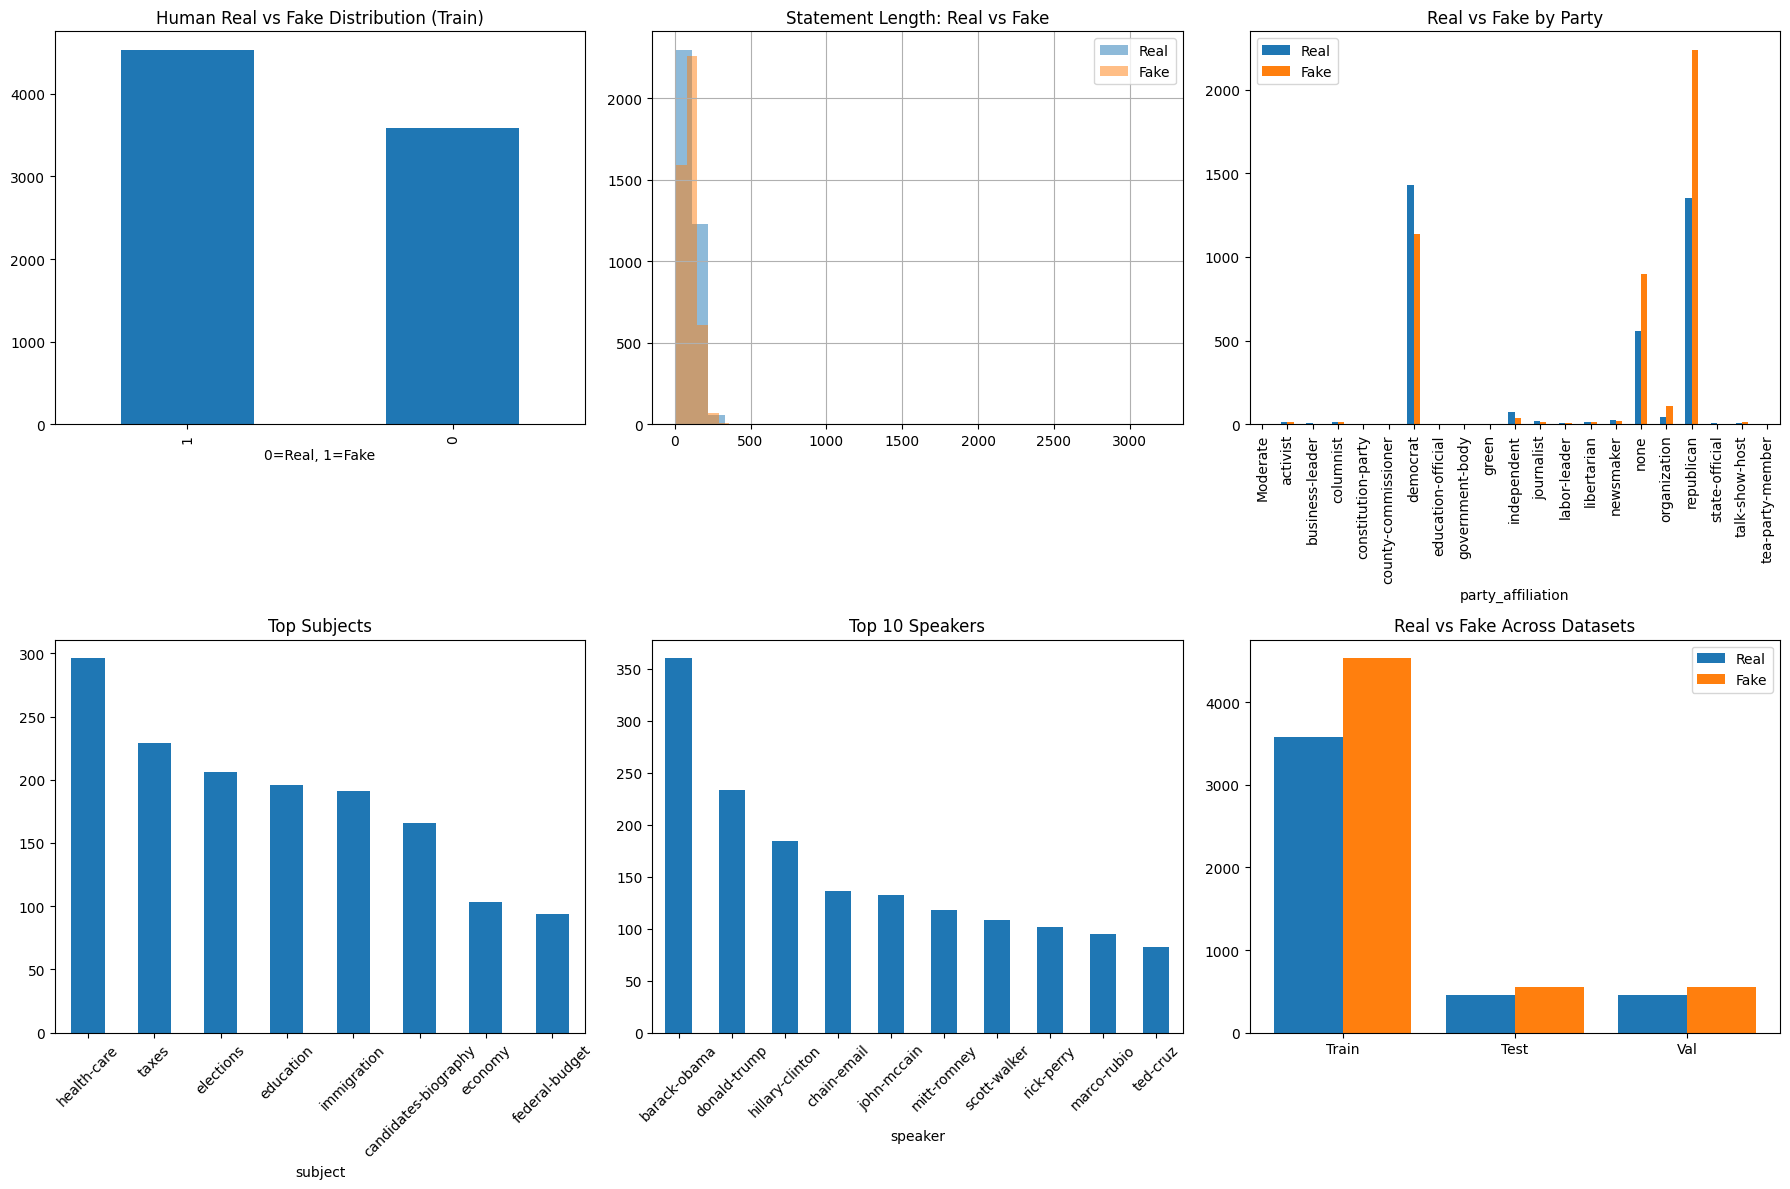


Stage 2B analysis completed successfully
Dataset quality: excellent
Balance ratio: 0.791
Results saved to stage2b_analysis_results.json

Stage 2B datasets ready:
- stage2b_train_df: (8116, 15)
- stage2b_test_df: (1015, 15)
- stage2b_val_df: (1015, 15)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from collections import Counter
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

class Stage2B_HumanRealFakeAnalyzer:
    """Stage 2B: Human Real vs Fake News Analysis"""
    
    def __init__(self):
        self.results = {}
        self.dataset_info = {}
        self.distribution_analysis = {}
        self.content_patterns = {}
        self.bias_analysis = {}
        self.overfitting_risks = {}
        
    def validate_prerequisites(self):
        """Validate required data from previous stages"""
        required_vars = ['train_processed', 'test_processed', 'val_processed']
        missing = [var for var in required_vars if var not in globals()]
        if missing:
            raise NameError(f"Missing required variables from previous stages: {missing}")
        return True
    
    def load_human_dataset(self):
        """Extract human samples (labels 0 and 1) from processed data"""
        print("Loading Stage 2B dataset: Human Real vs Fake...")
        
        # Get data from global scope
        train_processed = globals()['train_processed']
        test_processed = globals()['test_processed'] 
        val_processed = globals()['val_processed']
        
        # Extract human samples (labels 0 and 1)
        human_train_mask = train_processed['label'].isin([0, 1])
        human_train_df = train_processed[human_train_mask].copy()
        human_train_df['human_real_fake'] = human_train_df['label']  # 0=Real, 1=Fake
        
        human_test_mask = test_processed['label'].isin([0, 1])
        human_test_df = test_processed[human_test_mask].copy()
        human_test_df['human_real_fake'] = human_test_df['label']
        
        human_val_mask = val_processed['label'].isin([0, 1])
        human_val_df = val_processed[human_val_mask].copy()
        human_val_df['human_real_fake'] = human_val_df['label']
        
        # ============ FIX: ADD MISSING COLUMN ============
        # Add statement_length to test/val if missing (was only in train)
        if 'statement_length' in human_train_df.columns:
            if 'statement_length' not in human_test_df.columns:
                human_test_df['statement_length'] = human_test_df['statement_cleaned'].str.len()
                print("  ✓ Added statement_length to test set")
            
            if 'statement_length' not in human_val_df.columns:
                human_val_df['statement_length'] = human_val_df['statement_cleaned'].str.len()
                print("  ✓ Added statement_length to validation set")
        
        # Verify column alignment
        train_cols = set(human_train_df.columns)
        test_cols = set(human_test_df.columns)
        val_cols = set(human_val_df.columns)
        
        # Use only common columns (safety measure)
        common_columns = list(train_cols & test_cols & val_cols)
        
        human_train_df = human_train_df[common_columns]
        human_test_df = human_test_df[common_columns]
        human_val_df = human_val_df[common_columns]
        
        print(f"  ✓ Column alignment verified: {len(common_columns)} columns")
        # =================================================
        
        # Store dataset information
        self.dataset_info = {
            'train_samples': len(human_train_df),
            'test_samples': len(human_test_df),
            'val_samples': len(human_val_df),
            'total_samples': len(human_train_df) + len(human_test_df) + len(human_val_df),
            'label_mapping': '0=Real, 1=Fake',
            'columns': len(common_columns)  # Track column count
        }
        
        print(f"Human dataset loaded:")
        print(f"- Training: {self.dataset_info['train_samples']} samples, {human_train_df.shape[1]} columns")
        print(f"- Test: {self.dataset_info['test_samples']} samples, {human_test_df.shape[1]} columns") 
        print(f"- Validation: {self.dataset_info['val_samples']} samples, {human_val_df.shape[1]} columns")
        
        return human_train_df, human_test_df, human_val_df
    
    def analyze_distribution(self, human_train_df, human_test_df, human_val_df):
        """Analyze class distribution across splits"""
        train_dist = human_train_df['human_real_fake'].value_counts().sort_index()
        test_dist = human_test_df['human_real_fake'].value_counts().sort_index()
        val_dist = human_val_df['human_real_fake'].value_counts().sort_index()
        
        self.distribution_analysis = {
            'train_distribution': {
                'real': int(train_dist.get(0, 0)),
                'fake': int(train_dist.get(1, 0))
            },
            'test_distribution': {
                'real': int(test_dist.get(0, 0)),
                'fake': int(test_dist.get(1, 0))
            },
            'val_distribution': {
                'real': int(val_dist.get(0, 0)),
                'fake': int(val_dist.get(1, 0))
            }
        }
        
        # Calculate balance metrics
        train_balance = train_dist.get(0, 0) / max(train_dist.get(1, 1), 1)
        min_class = min(train_dist.get(0, 0), train_dist.get(1, 0))
        
        self.distribution_analysis.update({
            'balance_ratio': float(train_balance),
            'min_class_size': int(min_class),
            'dataset_quality': self._assess_dataset_quality(min_class)
        })
        
        return self.distribution_analysis
    
    def _assess_dataset_quality(self, min_class_size):
        """Assess dataset quality based on minimum class size"""
        if min_class_size >= 2000:
            return "excellent"
        elif min_class_size >= 1000:
            return "good"
        elif min_class_size >= 500:
            return "acceptable"
        else:
            return "small"
    
    def analyze_content_patterns(self, human_train_df):
        """Analyze linguistic patterns in human real vs fake content"""
        real_texts = human_train_df[human_train_df['human_real_fake'] == 0]['statement_cleaned']
        fake_texts = human_train_df[human_train_df['human_real_fake'] == 1]['statement_cleaned']
        
        # Length analysis
        real_lengths = real_texts.str.len()
        fake_lengths = fake_texts.str.len()
        length_pvalue = ttest_ind(real_lengths, fake_lengths)[1]
        
        # Advanced punctuation analysis
        punct_features = ['!', '?', '.', ',', ';', ':', '"', "'", '(', ')', '-']
        punctuation_discrimination = {}
        
        for punct in punct_features:
            real_freq = real_texts.str.count(f'\\{punct}').mean()
            fake_freq = fake_texts.str.count(f'\\{punct}').mean()
            
            if max(real_freq, fake_freq) > 0:
                discrimination = abs(real_freq - fake_freq) / max(real_freq, fake_freq, 1e-10)
                punctuation_discrimination[punct] = {
                    'discrimination_score': float(discrimination),
                    'real_frequency': float(real_freq),
                    'fake_frequency': float(fake_freq)
                }
        
        # Numerical content analysis
        real_numbers = real_texts.str.findall(r'\b\d+\.?\d*\b').str.len().mean()
        fake_numbers = fake_texts.str.findall(r'\b\d+\.?\d*\b').str.len().mean()
        real_percentages = real_texts.str.count(r'\d+\.?\d*%').mean()
        fake_percentages = fake_texts.str.count(r'\d+\.?\d*%').mean()
        
        # Capitalization patterns
        real_caps_ratio = real_texts.str.count(r'[A-Z]').sum() / max(real_texts.str.len().sum(), 1)
        fake_caps_ratio = fake_texts.str.count(r'[A-Z]').sum() / max(fake_texts.str.len().sum(), 1)
        
        self.content_patterns = {
            'length_analysis': {
                'real_mean_length': float(real_lengths.mean()),
                'fake_mean_length': float(fake_lengths.mean()),
                'length_difference': float(abs(real_lengths.mean() - fake_lengths.mean())),
                'statistical_significance': float(length_pvalue)
            },
            'punctuation_discrimination': punctuation_discrimination,
            'numerical_content': {
                'real_numbers_per_statement': float(real_numbers),
                'fake_numbers_per_statement': float(fake_numbers),
                'real_percentages_per_statement': float(real_percentages),
                'fake_percentages_per_statement': float(fake_percentages)
            },
            'capitalization_patterns': {
                'real_caps_ratio': float(real_caps_ratio),
                'fake_caps_ratio': float(fake_caps_ratio),
                'caps_discrimination': float(abs(real_caps_ratio - fake_caps_ratio))
            }
        }
        
        return self.content_patterns
    
    def analyze_speaker_patterns(self, human_train_df):
        """Analyze speaker reliability and bias patterns"""
        if 'speaker' not in human_train_df.columns:
            return {'analysis_skipped': 'speaker column not available'}
        
        # Speaker statistics
        speaker_stats = human_train_df.groupby('speaker').agg({
            'human_real_fake': ['count', 'mean', 'std'],
            'statement_cleaned': lambda x: x.str.len().mean()
        }).round(4)
        
        speaker_stats.columns = ['statement_count', 'fake_rate', 'fake_std', 'avg_length']
        speaker_stats = speaker_stats.reset_index()
        
        # Reliability metrics
        reliable_speakers = speaker_stats[speaker_stats['statement_count'] >= 3]
        consistent_speakers = reliable_speakers[reliable_speakers['fake_std'].fillna(0) == 0]
        highly_reliable = reliable_speakers[reliable_speakers['fake_rate'] < 0.2]
        
        speaker_analysis = {
            'total_speakers': len(speaker_stats),
            'speakers_with_multiple_statements': len(reliable_speakers),
            'perfectly_consistent_speakers': len(consistent_speakers),
            'highly_reliable_speakers': len(highly_reliable),
            'top_reliable_speakers': highly_reliable.nlargest(5, 'statement_count')[['speaker', 'statement_count', 'fake_rate']].to_dict('records') if len(highly_reliable) > 0 else []
        }
        
        return speaker_analysis
    
    def analyze_subject_bias(self, human_train_df):
        """Analyze subject matter bias patterns"""
        if 'subject' not in human_train_df.columns:
            return {'analysis_skipped': 'subject column not available'}
        
        subject_stats = human_train_df.groupby('subject').agg({
            'human_real_fake': ['count', 'mean'],
            'statement_cleaned': lambda x: x.str.len().mean()
        }).round(4)
        
        subject_stats.columns = ['statement_count', 'fake_rate', 'avg_length']
        subject_stats = subject_stats.reset_index()
        
        reliable_subjects = subject_stats[subject_stats['statement_count'] >= 5]
        
        if len(reliable_subjects) > 0:
            fake_prone = reliable_subjects.nlargest(5, 'fake_rate')
            most_reliable = reliable_subjects.nsmallest(5, 'fake_rate')
            
            subject_analysis = {
                'total_subjects': len(subject_stats),
                'subjects_with_sufficient_data': len(reliable_subjects),
                'most_fake_prone': fake_prone[['subject', 'fake_rate', 'statement_count']].to_dict('records'),
                'most_reliable': most_reliable[['subject', 'fake_rate', 'statement_count']].to_dict('records')
            }
        else:
            subject_analysis = {
                'total_subjects': len(subject_stats),
                'subjects_with_sufficient_data': 0,
                'analysis_limited': 'insufficient data per subject'
            }
        
        return subject_analysis
    
    def analyze_party_bias(self, human_train_df):
        """Analyze political party bias patterns"""
        if 'party_affiliation' not in human_train_df.columns:
            return {'analysis_skipped': 'party_affiliation column not available'}
        
        party_stats = human_train_df.groupby('party_affiliation').agg({
            'human_real_fake': ['count', 'mean'],
            'statement_cleaned': lambda x: x.str.len().mean()
        }).round(4)
        
        party_stats.columns = ['statement_count', 'fake_rate', 'avg_length']
        party_stats = party_stats.reset_index()
        
        major_parties = party_stats[party_stats['statement_count'] >= 10]
        
        if len(major_parties) > 0:
            fake_rate_range = major_parties['fake_rate'].max() - major_parties['fake_rate'].min()
            
            if fake_rate_range > 0.3:
                bias_level = "high"
            elif fake_rate_range > 0.15:
                bias_level = "moderate"
            else:
                bias_level = "low"
            
            party_analysis = {
                'total_parties': len(party_stats),
                'major_parties': len(major_parties),
                'fake_rate_range': float(fake_rate_range),
                'bias_level': bias_level,
                'party_breakdown': major_parties.sort_values('fake_rate', ascending=False)[['party_affiliation', 'fake_rate', 'statement_count']].to_dict('records')
            }
        else:
            party_analysis = {
                'total_parties': len(party_stats),
                'major_parties': 0,
                'analysis_limited': 'insufficient data per party'
            }
        
        return party_analysis
    
    def assess_overfitting_risks(self, human_train_df):
        """Assess potential overfitting risks"""
        # Speaker frequency risk
        speaker_counts = human_train_df['speaker'].value_counts() if 'speaker' in human_train_df.columns else pd.Series()
        high_freq_speakers = speaker_counts[speaker_counts >= 20] if len(speaker_counts) > 0 else pd.Series()
        
        speaker_risk = 0
        if len(high_freq_speakers) > 0:
            for speaker in high_freq_speakers.index:
                speaker_data = human_train_df[human_train_df['speaker'] == speaker]
                fake_rate = speaker_data['human_real_fake'].mean()
                if fake_rate < 0.1 or fake_rate > 0.9:
                    speaker_risk += 1
        
        # Text duplication risk
        duplicate_texts = human_train_df['statement_cleaned'].duplicated().sum()
        text_uniqueness = len(human_train_df['statement_cleaned'].unique()) / len(human_train_df)
        
        self.overfitting_risks = {
            'high_frequency_speakers': len(high_freq_speakers),
            'extreme_bias_speakers': speaker_risk,
            'speaker_risk_level': 'high' if speaker_risk > 5 else 'acceptable',
            'duplicate_texts': int(duplicate_texts),
            'text_uniqueness_ratio': float(text_uniqueness),
            'duplication_risk': 'potential' if text_uniqueness < 0.95 else 'low'
        }
        
        return self.overfitting_risks
    
    def create_visualization(self, human_train_df, human_test_df, human_val_df):
        """Create comprehensive visualization"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Distribution
        human_train_df['human_real_fake'].value_counts().plot(kind='bar', ax=axes[0,0])
        axes[0,0].set_title('Human Real vs Fake Distribution (Train)')
        axes[0,0].set_xlabel('0=Real, 1=Fake')
        
        # Length distribution
        real_lengths = human_train_df[human_train_df['human_real_fake'] == 0]['statement_cleaned'].str.len()
        fake_lengths = human_train_df[human_train_df['human_real_fake'] == 1]['statement_cleaned'].str.len()
        
        real_lengths.hist(alpha=0.5, label='Real', bins=30, ax=axes[0,1])
        fake_lengths.hist(alpha=0.5, label='Fake', bins=30, ax=axes[0,1])
        axes[0,1].set_title('Statement Length: Real vs Fake')
        axes[0,1].legend()
        
        # Party affiliation
        if 'party_affiliation' in human_train_df.columns:
            party_counts = pd.crosstab(human_train_df['party_affiliation'], human_train_df['human_real_fake'])
            party_counts.plot(kind='bar', ax=axes[0,2])
            axes[0,2].set_title('Real vs Fake by Party')
            axes[0,2].legend(['Real', 'Fake'])
        
        # Subject distribution
        if 'subject' in human_train_df.columns:
            top_subjects = human_train_df['subject'].value_counts().head(8)
            top_subjects.plot(kind='bar', ax=axes[1,0])
            axes[1,0].set_title('Top Subjects')
            axes[1,0].tick_params(axis='x', rotation=45)
        
        # Speaker distribution
        if 'speaker' in human_train_df.columns:
            top_speakers = human_train_df['speaker'].value_counts().head(10)
            top_speakers.plot(kind='bar', ax=axes[1,1])
            axes[1,1].set_title('Top 10 Speakers')
            axes[1,1].tick_params(axis='x', rotation=45)
        
        # Cross-dataset comparison
        datasets = ['Train', 'Test', 'Val']
        real_counts = [
            (human_train_df['human_real_fake'] == 0).sum(),
            (human_test_df['human_real_fake'] == 0).sum(),
            (human_val_df['human_real_fake'] == 0).sum()
        ]
        fake_counts = [
            (human_train_df['human_real_fake'] == 1).sum(),
            (human_test_df['human_real_fake'] == 1).sum(),
            (human_val_df['human_real_fake'] == 1).sum()
        ]
        
        x = np.arange(len(datasets))
        axes[1,2].bar(x - 0.2, real_counts, 0.4, label='Real')
        axes[1,2].bar(x + 0.2, fake_counts, 0.4, label='Fake')
        axes[1,2].set_title('Real vs Fake Across Datasets')
        axes[1,2].set_xticks(x)
        axes[1,2].set_xticklabels(datasets)
        axes[1,2].legend()
        
        plt.tight_layout()
        plt.show()
    
    def run_comprehensive_analysis(self):
        """Run complete Stage 2B analysis"""
        print("Running Stage 2B: Human Real vs Fake Analysis")
        print("=" * 60)
        
        # Validate prerequisites
        self.validate_prerequisites()
        
        # Load dataset
        human_train_df, human_test_df, human_val_df = self.load_human_dataset()
        
        # Run all analyses
        self.analyze_distribution(human_train_df, human_test_df, human_val_df)
        self.analyze_content_patterns(human_train_df)
        
        # Bias analyses
        speaker_analysis = self.analyze_speaker_patterns(human_train_df)
        subject_analysis = self.analyze_subject_bias(human_train_df)
        party_analysis = self.analyze_party_bias(human_train_df)
        
        # Risk assessment
        self.assess_overfitting_risks(human_train_df)
        
        # Store all results
        self.bias_analysis = {
            'speaker_analysis': speaker_analysis,
            'subject_analysis': subject_analysis,
            'party_analysis': party_analysis
        }
        
        self.results = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2b_human_real_fake_analysis',
            'dataset_info': self.dataset_info,
            'distribution_analysis': self.distribution_analysis,
            'content_patterns': self.content_patterns,
            'bias_analysis': self.bias_analysis,
            'overfitting_risks': self.overfitting_risks,
            'analysis_completed': True
        }
        
        # Create visualization
        self.create_visualization(human_train_df, human_test_df, human_val_df)
        
        print(f"\nStage 2B analysis completed successfully")
        print(f"Dataset quality: {self.distribution_analysis['dataset_quality']}")
        print(f"Balance ratio: {self.distribution_analysis['balance_ratio']:.3f}")
        
        return human_train_df, human_test_df, human_val_df
    
    def save_results(self, filepath='stage2b_analysis_results.json'):
        """Save analysis results"""
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        print(f"Results saved to {filepath}")
        return self.results

def main():
    """Main Stage 2B analysis pipeline"""
    analyzer = Stage2B_HumanRealFakeAnalyzer()
    
    # Run analysis
    human_train_df, human_test_df, human_val_df = analyzer.run_comprehensive_analysis()
    
    # Save results
    results = analyzer.save_results()
    
    # Store datasets for next stages
    globals()['stage2b_train_df'] = human_train_df
    globals()['stage2b_test_df'] = human_test_df
    globals()['stage2b_val_df'] = human_val_df
    
    print(f"\nStage 2B datasets ready:")
    print(f"- stage2b_train_df: {human_train_df.shape}")
    print(f"- stage2b_test_df: {human_test_df.shape}")
    print(f"- stage2b_val_df: {human_val_df.shape}")
    
    return {
        'analyzer': analyzer,
        'human_train_df': human_train_df,
        'human_test_df': human_test_df,
        'human_val_df': human_val_df,
        'results': results
    }

if __name__ == "__main__":
    stage2b_results = main()


Preprocessing

In [23]:
import pandas as pd
import numpy as np
import re
import json
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

class Stage2B_KeywordFreeHumanPreprocessor:
    """Preprocessing with light stemming and style preservation"""
    
    def __init__(self):
        self.results = {}
        self.learned_discriminative_words = {}
        self.learned_patterns = {}
        self.filtered_proper_nouns = []
        
    def extract_style_features(self, text):
        """Extract style features BEFORE any modification"""
        if pd.isna(text) or text == "":
            return self._empty_style_features()
        
        text = str(text)
        
        # Punctuation intensity patterns
        exclamations = len(re.findall(r'!', text))
        questions = len(re.findall(r'\?', text))
        multiple_exclamations = len(re.findall(r'!{2,}', text))
        multiple_questions = len(re.findall(r'\?{2,}', text))
        ellipsis = len(re.findall(r'\.{3,}', text))
        
        # Capitalization patterns
        all_caps_words = len(re.findall(r'\b[A-Z]{2,}\b', text))
        caps_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
        caps_words_ratio = all_caps_words / max(len(text.split()), 1)
        
        # Repetition patterns
        repeated_chars = len(re.findall(r'(.)\1{2,}', text))
        repeated_words = len(re.findall(r'\b(\w+)\s+\1\b', text, re.IGNORECASE))
        
        # Emotional markers
        quotation_marks = text.count('"') + text.count("'") + text.count('"') + text.count('"')
        parentheses = text.count('(') + text.count(')')
        dashes = text.count('-') + text.count('—') + text.count('–')
        
        # Length and density patterns
        text_length = len(text)
        word_count = len(text.split())
        avg_word_length = np.mean([len(word) for word in text.split()]) if word_count > 0 else 0
        
        # Word length patterns
        words = text.split()
        short_word_ratio = sum(1 for w in words if len(w) <= 3) / max(len(words), 1)
        long_word_ratio = sum(1 for w in words if len(w) >= 8) / max(len(words), 1)
        word_length_variance = np.var([len(w) for w in words]) if len(words) > 1 else 0
        
        # Morphological patterns
        ly_ending_ratio = sum(1 for w in words if w.lower().endswith('ly') and len(w) > 4) / max(len(words), 1)
        ing_ending_ratio = sum(1 for w in words if w.lower().endswith('ing') and len(w) > 5) / max(len(words), 1)
        ed_ending_ratio = sum(1 for w in words if w.lower().endswith('ed') and len(w) > 4) / max(len(words), 1)
        est_ending_ratio = sum(1 for w in words if w.lower().endswith('est') and len(w) > 4) / max(len(words), 1)
        
        # Character-level patterns
        vowel_ratio = sum(1 for c in text.lower() if c in 'aeiou') / max(len([c for c in text if c.isalpha()]), 1)
        digit_ratio = sum(1 for c in text if c.isdigit()) / max(len(text), 1)
        
        return {
            'exclamation_count': exclamations,
            'question_count': questions,
            'multiple_exclamations': multiple_exclamations,
            'multiple_questions': multiple_questions,
            'ellipsis_count': ellipsis,
            'punct_density': (exclamations + questions) / max(text_length, 1),
            'all_caps_words': all_caps_words,
            'caps_ratio': caps_ratio,
            'caps_words_ratio': caps_words_ratio,
            'repeated_chars': repeated_chars,
            'repeated_words': repeated_words,
            'repetition_density': repeated_chars / max(text_length, 1),
            'quotation_marks': quotation_marks,
            'parentheses_count': parentheses,
            'dash_count': dashes,
            'emotional_punct_density': (quotation_marks + parentheses + dashes) / max(text_length, 1),
            'text_length': text_length,
            'word_count': word_count,
            'avg_word_length': avg_word_length,
            'short_word_ratio': short_word_ratio,
            'long_word_ratio': long_word_ratio,
            'word_length_variance': word_length_variance,
            'ly_ending_ratio': ly_ending_ratio,
            'ing_ending_ratio': ing_ending_ratio,
            'ed_ending_ratio': ed_ending_ratio,
            'est_ending_ratio': est_ending_ratio,
            'morphological_intensity': ly_ending_ratio + est_ending_ratio,
            'vowel_ratio': vowel_ratio,
            'digit_ratio': digit_ratio,
            'lexical_diversity': len(set(words)) / max(len(words), 1)
        }
    
    def _empty_style_features(self):
        """Return empty style features"""
        return {key: 0.0 for key in [
            'exclamation_count', 'question_count', 'multiple_exclamations', 'multiple_questions',
            'ellipsis_count', 'punct_density', 'all_caps_words', 'caps_ratio', 'caps_words_ratio',
            'repeated_chars', 'repeated_words', 'repetition_density', 'quotation_marks',
            'parentheses_count', 'dash_count', 'emotional_punct_density', 'text_length',
            'word_count', 'avg_word_length', 'short_word_ratio', 'long_word_ratio',
            'word_length_variance', 'ly_ending_ratio', 'ing_ending_ratio', 'ed_ending_ratio',
            'est_ending_ratio', 'morphological_intensity', 'vowel_ratio', 'digit_ratio', 'lexical_diversity'
        ]}
    
    def preserve_deception_patterns(self, text):
        """Convert deception patterns to tokens"""
        if pd.isna(text):
            return ""
        
        text = str(text)
        
        # Convert patterns to special tokens
        text = re.sub(r'!{2,}', ' [STRONG_EXCLAMATION] ', text)
        text = re.sub(r'\?{2,}', ' [STRONG_QUESTION] ', text)
        text = re.sub(r'\.{3,}', ' [ELLIPSIS] ', text)
        text = re.sub(r'\b([A-Z]{2,})\b', r' [CAPS_\1] ', text)
        text = re.sub(r'(.)\1{3,}', r'\1 [REPEATED_CHAR] ', text)
        
        # Preserve quotation contexts
        text = re.sub(r'"([^"]*)"', r' [QUOTE_START] \1 [QUOTE_END] ', text)
        text = re.sub(r"'([^']*)'", r' [QUOTE_START] \1 [QUOTE_END] ', text)
        
        return text
    
    def conservative_stemming(self, word):
        """Very light stemming for short texts"""
        if not word or len(word) <= 3:
            return word
        
        word = word.lower()
        
        # Only stem obvious cases
        if word.endswith('ing') and len(word) > 6:
            stem = word[:-3]
            if len(stem) >= 3 and not stem.endswith(('th', 'ch', 'sh')):
                return stem
        
        if word.endswith('ed') and len(word) > 5:
            stem = word[:-2]
            if len(stem) >= 3:
                return stem
        
        if word.endswith('er') and len(word) > 5:
            stem = word[:-2]
            if len(stem) >= 3 and not word.endswith(('her', 'per', 'ter')):
                return stem
        
        if word.endswith('ly') and len(word) > 5:
            stem = word[:-2]
            if len(stem) >= 3:
                return stem
        
        return word
    
    def minimal_contraction_expansion(self, text):
        """Minimal contraction expansion"""
        if pd.isna(text):
            return ""
        
        # Only expand most common contractions
        expansions = [
            (r"\bcan't\b", "cannot"),
            (r"\bwon't\b", "will not"),
            (r"\bn't\b", " not"),
            (r"\b're\b", " are"),
            (r"\b've\b", " have"),
            (r"\b'll\b", " will"),
            (r"\b'd\b", " would")
        ]
        
        for pattern, replacement in expansions:
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
        
        return text
    
    def detect_proper_nouns_from_data(self, train_df, text_column='statement_cleaned'):
        """Detect proper nouns by capitalization patterns"""
        print("  Detecting proper nouns from data...")
        
        word_cap_stats = {}  # word -> (cap_count, lower_count)
        
        for text in train_df[text_column]:
            if pd.notna(text):
                text_str = str(text)
                
                # Find all words (both capitalized and lowercase)
                all_words = re.findall(r'\b[A-Za-z]{3,}\b', text_str)
                
                for word in all_words:
                    word_lower = word.lower()
                    
                    # Skip if starts with [, ends with ], or contains special chars
                    if word_lower.startswith('[') or word_lower.endswith(']'):
                        continue
                    
                    if word_lower not in word_cap_stats:
                        word_cap_stats[word_lower] = {'cap': 0, 'lower': 0}
                    
                    # Count capitalized vs lowercase occurrences
                    if word[0].isupper():
                        word_cap_stats[word_lower]['cap'] += 1
                    else:
                        word_cap_stats[word_lower]['lower'] += 1
        
        # Identify proper nouns: words that appear capitalized >70% of the time
        # (excluding sentence-initial positions)
        proper_nouns = []
        
        for word, stats in word_cap_stats.items():
            total = stats['cap'] + stats['lower']
            
            if total >= 10:  # Must appear at least 10 times
                cap_ratio = stats['cap'] / total
                
                # If capitalized >70% and appears frequently, likely a proper noun
                if cap_ratio > 0.7:
                    proper_nouns.append(word)
        
        print(f"    Detected {len(proper_nouns)} proper nouns from data")
        print(f"    Sample: {proper_nouns[:10]}")
        
        return set(proper_nouns)
    
    def learn_discriminative_words(self, train_df, text_column='statement_cleaned'):
        """Learn discriminative words with class-weight normalization"""
        print("Learning discriminative words from training data...")
        
        # Step 1: Detect proper nouns from data
        proper_nouns = self.detect_proper_nouns_from_data(train_df, text_column)
        
        # Step 2: Extract words from real and fake texts
        real_texts = train_df[train_df['human_real_fake'] == 0][text_column]
        fake_texts = train_df[train_df['human_real_fake'] == 1][text_column]
        
        # ============ CLASS WEIGHTS ============
        n_real = len(real_texts)
        n_fake = len(fake_texts)
        total = n_real + n_fake
        
        # Inverse frequency weights
        weight_real = total / (2 * n_real)
        weight_fake = total / (2 * n_fake)
        
        print(f"  Class sizes: Real={n_real}, Fake={n_fake}")
        print(f"  Class weights: Real={weight_real:.3f}, Fake={weight_fake:.3f}")
        # =======================================
        
        real_words = []
        fake_words = []
        
        for text in real_texts:
            if pd.notna(text):
                words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
                real_words.extend(words)
        
        for text in fake_texts:
            if pd.notna(text):
                words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
                fake_words.extend(words)
        
        # Step 3: Calculate frequencies
        real_word_freq = Counter(real_words)
        fake_word_freq = Counter(fake_words)
        
        # Adaptive threshold for 8K dataset
        min_freq = max(5, len(train_df) // 500)
        print(f"  Minimum frequency threshold: {min_freq}")
        print(f"  Real texts: {len(real_texts)}, Fake texts: {len(fake_texts)}")
        
        # Step 4: Find discriminative words (excluding proper nouns)
        all_words = set(real_words) | set(fake_words)
        word_scores = {}
        self.filtered_proper_nouns = []
        
        for word in all_words:
            real_count = real_word_freq.get(word, 0)
            fake_count = fake_word_freq.get(word, 0)
            
            # Must appear frequently
            if real_count >= min_freq or fake_count >= min_freq:
                
                # Filter out proper nouns (DATA-DRIVEN!)
                if word in proper_nouns:
                    self.filtered_proper_nouns.append((word, real_count, fake_count))
                    continue
                
                # ============ WEIGHTED NORMALIZATION ============
                real_norm = (real_count / len(real_texts)) * weight_real
                fake_norm = (fake_count / len(fake_texts)) * weight_fake
                # ================================================
                
                # Discrimination score
                discrimination = abs(real_norm - fake_norm)
                
                if discrimination > 0.001:
                    word_scores[word] = {
                        'discrimination_score': discrimination,
                        'real_ratio': real_norm,
                        'fake_ratio': fake_norm,
                        'real_count': real_count,
                        'fake_count': fake_count,
                        'more_frequent_in': 'fake' if fake_norm > real_norm else 'real'
                    }
        
        # ============ BALANCED SELECTION FOR 8K DATASET ============
        # Separate real-leaning and fake-leaning words
        real_leaning = {w: s for w, s in word_scores.items() if s['more_frequent_in'] == 'real'}
        fake_leaning = {w: s for w, s in word_scores.items() if s['more_frequent_in'] == 'fake'}
        
        # Sort each by discrimination score
        real_sorted = sorted(real_leaning.items(), key=lambda x: x[1]['discrimination_score'], reverse=True)
        fake_sorted = sorted(fake_leaning.items(), key=lambda x: x[1]['discrimination_score'], reverse=True)
        
        # Take top 100 from each (for 8K dataset = 200 total)
        words_per_class = 100
        top_real = real_sorted[:words_per_class]
        top_fake = fake_sorted[:words_per_class]
        
        # Combine
        self.learned_discriminative_words = dict(top_real + top_fake)
        # ===========================================================
        
        print(f"  Learned {len(self.learned_discriminative_words)} discriminative words")
        print(f"  Filtered {len(self.filtered_proper_nouns)} proper nouns (data-driven detection)")
        
        if self.filtered_proper_nouns:
            sample_filtered = [w for w, _, _ in sorted(self.filtered_proper_nouns, key=lambda x: x[1]+x[2], reverse=True)[:10]]
            print(f"  Top filtered proper nouns: {sample_filtered}")
        
        # Distribution check
        fake_count = sum(1 for w, s in self.learned_discriminative_words.items() if s['more_frequent_in'] == 'fake')
        real_count = len(self.learned_discriminative_words) - fake_count
        print(f"  Distribution: {real_count} real-leaning, {fake_count} fake-leaning")
        
        # Show top 10
        print("\n  Top 10 discriminative words:")
        sorted_all = sorted(self.learned_discriminative_words.items(), 
                            key=lambda x: x[1]['discrimination_score'], reverse=True)
        for i, (word, scores) in enumerate(sorted_all[:10], 1):
            freq_in = scores['more_frequent_in']
            score = scores['discrimination_score']
            real_c = scores['real_count']
            fake_c = scores['fake_count']
            print(f"  {i:2d}. '{word}' -> {freq_in} (score: {score:.4f}, real: {real_c}, fake: {fake_c})")
        
        return self.learned_discriminative_words
    
    def extract_learned_word_features(self, text):
        """Extract features using learned words"""
        if not self.learned_discriminative_words or pd.isna(text):
            return {
                'learned_fake_signals': 0,
                'learned_real_signals': 0,
                'learned_discrimination_score': 0,
                'learned_signal_density': 0
            }
        
        words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        
        fake_signals = 0
        real_signals = 0
        total_discrimination = 0
        
        for word in words:
            if word in self.learned_discriminative_words:
                word_info = self.learned_discriminative_words[word]
                discrimination = word_info['discrimination_score']
                
                if word_info['more_frequent_in'] == 'fake':
                    fake_signals += 1
                    total_discrimination += discrimination
                else:
                    real_signals += 1
                    total_discrimination -= discrimination
        
        return {
            'learned_fake_signals': fake_signals,
            'learned_real_signals': real_signals,
            'learned_discrimination_score': total_discrimination,
            'learned_signal_density': (fake_signals + real_signals) / max(len(words), 1)
        }
    
    def create_keyword_free_text_versions(self, text):
        """Create text versions without hardcoded keywords"""
        if pd.isna(text):
            return {
                'original': "",
                'style_preserved': "",
                'clean_semantic': "",
                'pattern_enhanced': ""
            }
        
        original = str(text)
        
        # Version 1: Style-preserved
        style_preserved = self.preserve_deception_patterns(original)
        style_preserved = self.minimal_contraction_expansion(style_preserved)
        style_preserved = re.sub(r'\s+', ' ', style_preserved).strip()
        
        # Version 2: Clean semantic
        clean_semantic = re.sub(r'https?://[^\s]+', '[URL]', original)
        clean_semantic = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL]', clean_semantic)
        clean_semantic = self.minimal_contraction_expansion(clean_semantic)
        
        # Conservative stemming
        words = re.findall(r'\b\w+\b', clean_semantic.lower())
        stemmed_words = [self.conservative_stemming(word) for word in words if len(word) >= 2]
        clean_semantic = ' '.join(stemmed_words)
        
        # Version 3: Pattern-enhanced
        pattern_enhanced = original
        pattern_enhanced = re.sub(r'\b(\w+ly)\b', r'[ADV_\1]', pattern_enhanced)
        pattern_enhanced = re.sub(r'\b(\w+est)\b', r'[SUP_\1]', pattern_enhanced)
        pattern_enhanced = re.sub(r'\b(\w+ing)\b', r'[PART_\1]', pattern_enhanced)
        pattern_enhanced = self.minimal_contraction_expansion(pattern_enhanced)
        
        return {
            'original': original,
            'style_preserved': style_preserved,
            'clean_semantic': clean_semantic,
            'pattern_enhanced': pattern_enhanced
        }
    
    def process_single_text(self, text):
        """Complete processing pipeline"""
        style_features = self.extract_style_features(text)
        learned_word_features = self.extract_learned_word_features(text)
        text_versions = self.create_keyword_free_text_versions(text)
        
        return {
            'text_versions': text_versions,
            'style_features': style_features,
            'learned_word_features': learned_word_features
        }
    
    def process_dataframe(self, df, text_column='statement_cleaned'):
        """Process dataframe"""
        print(f"Processing {len(df)} texts with keyword-free approach...")
        
        processed_data = []
        style_features_list = []
        learned_word_features_list = []
        
        for idx, text in enumerate(df[text_column]):
            if idx % 1000 == 0:
                print(f"  Processing {idx}/{len(df)}...")
            
            result = self.process_single_text(text)
            processed_data.append(result['text_versions'])
            style_features_list.append(result['style_features'])
            learned_word_features_list.append(result['learned_word_features'])
        
        # Create enhanced dataframe
        df_processed = df.copy()
        
        # Add text versions
        for version_name in ['original', 'style_preserved', 'clean_semantic', 'pattern_enhanced']:
            df_processed[f'{text_column}_{version_name}'] = [data[version_name] for data in processed_data]
        
        # Add style features
        style_df = pd.DataFrame(style_features_list)
        for col in style_df.columns:
            df_processed[f'style_{col}'] = style_df[col]
        
        # Add learned word features
        learned_df = pd.DataFrame(learned_word_features_list)
        for col in learned_df.columns:
            df_processed[f'learned_{col}'] = learned_df[col]
        
        stats = {
            'processed_texts': len(df_processed),
            'style_features_added': len(style_df.columns),
            'learned_features_added': len(learned_df.columns),
            'text_versions_created': 4
        }
        
        return df_processed, stats
    
    def process_all_splits(self, train_df, test_df, val_df):
        """Main processing pipeline"""
        print("Stage 2B: Keyword-Free Human Fake Preprocessing")
        print("=" * 60)
        
        # Learn discriminative words from training data (fully automatic)
        self.learn_discriminative_words(train_df)
        
        # Process all splits
        train_processed, train_stats = self.process_dataframe(train_df)
        test_processed, test_stats = self.process_dataframe(test_df)
        val_processed, val_stats = self.process_dataframe(val_df)
        
        # Save processed data
        train_processed.to_csv('stage2b_train_keyword_free.csv', index=False)
        test_processed.to_csv('stage2b_test_keyword_free.csv', index=False)
        val_processed.to_csv('stage2b_val_keyword_free.csv', index=False)
        
        self.results = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2b_keyword_free_preprocessing_data_driven',
            'train_stats': train_stats,
            'test_stats': test_stats,
            'val_stats': val_stats,
            'learned_discriminative_words': {
                word: {
                    'discrimination_score': float(info['discrimination_score']),
                    'more_frequent_in': info['more_frequent_in'],
                    'real_count': int(info['real_count']),
                    'fake_count': int(info['fake_count'])
                } for word, info in self.learned_discriminative_words.items()
            },
            'proper_nouns_filtered': len(self.filtered_proper_nouns),
            'filtering_method': 'capitalization pattern analysis',
            'no_hardcoded_keywords': True,
            'files_saved': [
                'stage2b_train_keyword_free.csv',
                'stage2b_test_keyword_free.csv',
                'stage2b_val_keyword_free.csv'
            ],
            'preprocessing_completed': True
        }
        
        print(f"\nKeyword-free preprocessing completed!")
        print(f"  Style features: {train_stats['style_features_added']}")
        print(f"  Learned word features: {train_stats['learned_features_added']}")
        print(f"  Text versions: {train_stats['text_versions_created']}")
        print(f"  Proper nouns filtered: {len(self.filtered_proper_nouns)} (automatic detection)")
        
        return train_processed, test_processed, val_processed
    
    def save_results(self, filepath='stage2b_keyword_free_results.json'):
        """Save results"""
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        print(f"\nResults saved to {filepath}")
        return self.results


def main():
    """Main pipeline"""
    if 'stage2b_train_df' not in globals():
        print("Error: Stage 2B data not found")
        print("Please run Stage 2B analysis first")
        return None
    
    train_df = globals()['stage2b_train_df']
    test_df = globals()['stage2b_test_df']
    val_df = globals()['stage2b_val_df']
    
    print(f"Input datasets:")
    print(f"  Training: {len(train_df)} samples")
    print(f"  Test: {len(test_df)} samples")
    print(f"  Validation: {len(val_df)} samples")
    
    preprocessor = Stage2B_KeywordFreeHumanPreprocessor()
    
    train_processed, test_processed, val_processed = preprocessor.process_all_splits(
        train_df, test_df, val_df
    )
    
    results = preprocessor.save_results()
    
    # Store in globals
    globals()['stage2b_train_keyword_free'] = train_processed
    globals()['stage2b_test_keyword_free'] = test_processed
    globals()['stage2b_val_keyword_free'] = val_processed
    globals()['stage2b_preprocessor'] = preprocessor
    
    print(f"\nDatasets stored in globals:")
    print(f"  - stage2b_train_keyword_free: {train_processed.shape}")
    print(f"  - stage2b_test_keyword_free: {test_processed.shape}")
    print(f"  - stage2b_val_keyword_free: {val_processed.shape}")
    
    return {
        'preprocessor': preprocessor,
        'train_processed': train_processed,
        'test_processed': test_processed,
        'val_processed': val_processed,
        'results': results
    }


if __name__ == "__main__":
    keyword_free_results = main()


Input datasets:
  Training: 8116 samples
  Test: 1015 samples
  Validation: 1015 samples
Stage 2B: Keyword-Free Human Fake Preprocessing
Learning discriminative words from training data...
  Detecting proper nouns from data...
    Detected 256 proper nouns from data
    Sample: ['says', 'sen', 'obamas', 'rhode', 'island', 'canada', 'barack', 'obama', 'republican', 'senate']
  Class sizes: Real=3585, Fake=4531
  Class weights: Real=1.132, Fake=0.896
  Minimum frequency threshold: 16
  Real texts: 3585, Fake texts: 4531
  Learned 200 discriminative words
  Filtered 112 proper nouns (data-driven detection)
  Top filtered proper nouns: ['says', 'obama', 'barack', 'texas', 'united', 'wisconsin', 'clinton', 'american', 'senate', 'americans']
  Distribution: 100 real-leaning, 100 fake-leaning

  Top 10 discriminative words:
   1. 'the' -> real (score: 0.3732, real: 3703, fake: 4027)
   2. 'than' -> real (score: 0.1114, real: 548, fake: 312)
   3. 'percent' -> real (score: 0.1004, real: 547, f

In [24]:
!pip install vaderSentiment textstat
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# NEW: Import NLP libraries
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    SPACY_AVAILABLE = True
except:
    SPACY_AVAILABLE = False
    print("Warning: spaCy not available, some features will be skipped")

try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except:
    TEXTBLOB_AVAILABLE = False
    print("Warning: TextBlob not available")

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader = SentimentIntensityAnalyzer()
    VADER_AVAILABLE = True
except:
    VADER_AVAILABLE = False
    print("Warning: VADER not available")

try:
    import textstat
    TEXTSTAT_AVAILABLE = True
except:
    TEXTSTAT_AVAILABLE = False
    print("Warning: textstat not available")

def convert_numpy_types(obj):
    """Convert numpy types to JSON serializable types"""
    if isinstance(obj, dict):
        return {key: convert_numpy_types(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(item) for item in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj


class Stage2B_CompleteFeatureEngineering:
    """Complete feature engineering with ALL NLP features"""
    
    def __init__(self):
        self.results = {}
        self.tfidf_vectorizer = None
        self.topic_model = None
        self.fitted_models = {}
        self.performance_metrics = {}
        self.feature_columns = None
        
    def extract_nlp_features(self, text):
        """Extract comprehensive NLP features from text"""
        if pd.isna(text) or text == "":
            return self._empty_nlp_features()
        
        text = str(text)
        features = {}
        
        # Sentiment analysis
        if VADER_AVAILABLE:
            vader_scores = vader.polarity_scores(text)
            features['vader_neg'] = vader_scores['neg']
            features['vader_neu'] = vader_scores['neu']
            features['vader_pos'] = vader_scores['pos']
            features['vader_compound'] = vader_scores['compound']
        else:
            features.update({'vader_neg': 0, 'vader_neu': 0, 'vader_pos': 0, 'vader_compound': 0})
        
        if TEXTBLOB_AVAILABLE:
            try:
                blob = TextBlob(text)
                features['textblob_polarity'] = blob.sentiment.polarity
                features['textblob_subjectivity'] = blob.sentiment.subjectivity
            except:
                features['textblob_polarity'] = 0
                features['textblob_subjectivity'] = 0
        else:
            features.update({'textblob_polarity': 0, 'textblob_subjectivity': 0})
        
        # Readability scores
        if TEXTSTAT_AVAILABLE:
            try:
                features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
                features['flesch_kincaid_grade'] = textstat.flesch_kincaid_grade(text)
                features['gunning_fog'] = textstat.gunning_fog(text)
                features['automated_readability'] = textstat.automated_readability_index(text)
                features['coleman_liau'] = textstat.coleman_liau_index(text)
                features['dale_chall'] = textstat.dale_chall_readability_score(text)
            except:
                features.update({
                    'flesch_reading_ease': 0, 'flesch_kincaid_grade': 0,
                    'gunning_fog': 0, 'automated_readability': 0,
                    'coleman_liau': 0, 'dale_chall': 0
                })
        else:
            features.update({
                'flesch_reading_ease': 0, 'flesch_kincaid_grade': 0,
                'gunning_fog': 0, 'automated_readability': 0,
                'coleman_liau': 0, 'dale_chall': 0
            })
        
        # POS tag features
        if SPACY_AVAILABLE:
            try:
                doc = nlp(text[:1000000])  # Limit text length
                
                total_tokens = len(doc)
                if total_tokens > 0:
                    pos_counts = {}
                    for token in doc:
                        pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1
                    
                    features['noun_ratio'] = pos_counts.get('NOUN', 0) / total_tokens
                    features['verb_ratio'] = pos_counts.get('VERB', 0) / total_tokens
                    features['adj_ratio'] = pos_counts.get('ADJ', 0) / total_tokens
                    features['adv_ratio'] = pos_counts.get('ADV', 0) / total_tokens
                    features['pron_ratio'] = pos_counts.get('PRON', 0) / total_tokens
                    features['det_ratio'] = pos_counts.get('DET', 0) / total_tokens
                    features['aux_ratio'] = pos_counts.get('AUX', 0) / total_tokens
                    
                    # Named entities
                    ent_types = {}
                    for ent in doc.ents:
                        ent_types[ent.label_] = ent_types.get(ent.label_, 0) + 1
                    
                    features['entity_count'] = len(doc.ents)
                    features['entity_density'] = len(doc.ents) / total_tokens
                    features['person_count'] = ent_types.get('PERSON', 0)
                    features['org_count'] = ent_types.get('ORG', 0)
                    features['gpe_count'] = ent_types.get('GPE', 0)
                    features['date_count'] = ent_types.get('DATE', 0)
                    features['money_count'] = ent_types.get('MONEY', 0)
                    features['percent_count'] = ent_types.get('PERCENT', 0)
                else:
                    features.update(self._empty_pos_features())
            except:
                features.update(self._empty_pos_features())
        else:
            features.update(self._empty_pos_features())
        
        return features
    
    def _empty_nlp_features(self):
        """Return empty NLP features"""
        return {
            'vader_neg': 0, 'vader_neu': 0, 'vader_pos': 0, 'vader_compound': 0,
            'textblob_polarity': 0, 'textblob_subjectivity': 0,
            'flesch_reading_ease': 0, 'flesch_kincaid_grade': 0,
            'gunning_fog': 0, 'automated_readability': 0,
            'coleman_liau': 0, 'dale_chall': 0,
            **self._empty_pos_features()
        }
    
    def _empty_pos_features(self):
        """Return empty POS features"""
        return {
            'noun_ratio': 0, 'verb_ratio': 0, 'adj_ratio': 0, 'adv_ratio': 0,
            'pron_ratio': 0, 'det_ratio': 0, 'aux_ratio': 0,
            'entity_count': 0, 'entity_density': 0,
            'person_count': 0, 'org_count': 0, 'gpe_count': 0,
            'date_count': 0, 'money_count': 0, 'percent_count': 0
        }
    
    def fit_data_driven_models(self, train_texts, train_labels):
        """Fit all data-driven models on training data"""
        print("Fitting data-driven semantic models...")
        
        # TF-IDF for discriminative words
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=500,
            min_df=3,
            max_df=0.8,
            ngram_range=(1, 2),
            lowercase=True,
            stop_words='english'
        )
        
        tfidf_matrix = self.tfidf_vectorizer.fit_transform(train_texts)
        
        # Find discriminative features
        real_indices = np.where(train_labels == 0)[0]
        fake_indices = np.where(train_labels == 1)[0]
        
        real_tfidf_mean = tfidf_matrix[real_indices].mean(axis=0).A1
        fake_tfidf_mean = tfidf_matrix[fake_indices].mean(axis=0).A1
        
        discrimination_scores = np.abs(real_tfidf_mean - fake_tfidf_mean)
        top_discriminative_indices = np.argsort(discrimination_scores)[-100:]
        
        self.fitted_models['discriminative_features'] = top_discriminative_indices.tolist()
        
        # Topic modeling
        count_vectorizer = CountVectorizer(
            max_features=200,
            min_df=3,
            max_df=0.8,
            stop_words='english'
        )
        
        count_matrix = count_vectorizer.fit_transform(train_texts)
        
        self.topic_model = LatentDirichletAllocation(
            n_components=10,
            random_state=42,
            max_iter=10
        )
        
        self.topic_model.fit(count_matrix)
        self.fitted_models['count_vectorizer'] = count_vectorizer
        
        # N-gram patterns
        bigram_vectorizer = TfidfVectorizer(
            ngram_range=(2, 2),
            max_features=100,
            min_df=3
        )
        
        trigram_vectorizer = TfidfVectorizer(
            ngram_range=(3, 3),
            max_features=50,
            min_df=2
        )
        
        bigram_vectorizer.fit(train_texts)
        trigram_vectorizer.fit(train_texts)
        
        self.fitted_models['bigram_vectorizer'] = bigram_vectorizer
        self.fitted_models['trigram_vectorizer'] = trigram_vectorizer
        
        print("✓ All semantic models fitted")
    
    def extract_semantic_features(self, texts):
        """Extract semantic features"""
        features_list = []
        
        for text in texts:
            feature_dict = {}
            
            # TF-IDF features
            if self.tfidf_vectorizer is not None:
                try:
                    tfidf_vector = self.tfidf_vectorizer.transform([text])
                    discriminative_indices = self.fitted_models['discriminative_features']
                    
                    feature_dict['tfidf_discriminative_score'] = float(tfidf_vector[:, discriminative_indices].sum())
                    feature_dict['tfidf_max_score'] = float(tfidf_vector.max())
                    feature_dict['tfidf_mean_score'] = float(tfidf_vector.mean())
                    feature_dict['tfidf_nonzero_features'] = int((tfidf_vector > 0).sum())
                except:
                    feature_dict['tfidf_discriminative_score'] = 0.0
                    feature_dict['tfidf_max_score'] = 0.0
                    feature_dict['tfidf_mean_score'] = 0.0
                    feature_dict['tfidf_nonzero_features'] = 0
            
            # Topic features
            if self.topic_model is not None:
                try:
                    count_vectorizer = self.fitted_models['count_vectorizer']
                    count_vector = count_vectorizer.transform([text])
                    topic_dist = self.topic_model.transform(count_vector)[0]
                    
                    feature_dict['topic_max_prob'] = float(topic_dist.max())
                    feature_dict['topic_entropy'] = float(-np.sum(topic_dist * np.log(topic_dist + 1e-10)))
                    feature_dict['topic_concentration'] = float(np.sum(topic_dist ** 2))
                    
                    # Top 5 topics
                    top_topics = np.argsort(topic_dist)[-5:]
                    for i, topic_idx in enumerate(top_topics):
                        feature_dict[f'top_topic_{i}_prob'] = float(topic_dist[topic_idx])
                except:
                    feature_dict['topic_max_prob'] = 0.0
                    feature_dict['topic_entropy'] = 0.0
                    feature_dict['topic_concentration'] = 0.0
                    for i in range(5):
                        feature_dict[f'top_topic_{i}_prob'] = 0.0
            
            # N-gram features
            if 'bigram_vectorizer' in self.fitted_models:
                try:
                    bigram_vector = self.fitted_models['bigram_vectorizer'].transform([text])
                    trigram_vector = self.fitted_models['trigram_vectorizer'].transform([text])
                    
                    feature_dict['bigram_score'] = float(bigram_vector.sum())
                    feature_dict['trigram_score'] = float(trigram_vector.sum())
                    feature_dict['bigram_max'] = float(bigram_vector.max())
                    feature_dict['trigram_max'] = float(trigram_vector.max())
                except:
                    feature_dict['bigram_score'] = 0.0
                    feature_dict['trigram_score'] = 0.0
                    feature_dict['bigram_max'] = 0.0
                    feature_dict['trigram_max'] = 0.0
            
            features_list.append(feature_dict)
        
        return pd.DataFrame(features_list)
    
    def extract_style_features_from_preprocessing(self, df):
        """Extract style features from preprocessing step"""
        style_feature_cols = [col for col in df.columns if col.startswith('style_')]
        learned_feature_cols = [col for col in df.columns if col.startswith('learned_')]
        
        style_features = {}
        if style_feature_cols:
            for col in style_feature_cols:
                style_features[col] = df[col].values
        
        if learned_feature_cols:
            for col in learned_feature_cols:
                style_features[col] = df[col].values
        
        return pd.DataFrame(style_features) if style_features else pd.DataFrame()
    
    def extract_all_features(self, df, is_training=False):
        """Extract ALL features """
        df_processed = df.copy()
        
        # CRITICAL FIX: Use ORIGINAL text for semantic analysis
        text_column = 'statement_cleaned_original'
        
        if text_column not in df_processed.columns:
            print(f"Warning: {text_column} not found, using statement_cleaned")
            text_column = 'statement_cleaned'
        
        texts = df_processed[text_column].astype(str).tolist()
        
        # Get labels
        if is_training:
            if 'human_real_fake' in df_processed.columns:
                labels = df_processed['human_real_fake'].values
            elif 'label' in df_processed.columns:
                labels = df_processed['label'].values
            else:
                raise ValueError("No target column found!")
        else:
            labels = None
        
        print(f"Extracting features from {len(texts)} texts...")
        
        # 1. Extract style features from preprocessing (30 features)
        preprocessing_features = self.extract_style_features_from_preprocessing(df_processed)
        print(f"  ✓ Preprocessing features: {len(preprocessing_features.columns)} features")
        
        # 2. Extract comprehensive NLP features (28+ features)
        print("  Extracting NLP features (sentiment, readability, POS)...")
        nlp_features_list = []
        for i, text in enumerate(texts):
            if i % 1000 == 0:
                print(f"    Processing {i}/{len(texts)}...")
            nlp_features_list.append(self.extract_nlp_features(text))
        
        nlp_features_df = pd.DataFrame(nlp_features_list)
        print(f"  ✓ NLP features: {len(nlp_features_df.columns)} features")
        
        # 3. Fit and extract semantic features (19 features)
        if is_training:
            self.fit_data_driven_models(texts, labels)
        
        semantic_features = self.extract_semantic_features(texts)
        print(f"  ✓ Semantic features: {len(semantic_features.columns)} features")
        
        # 4. Add all features to dataframe
        for col in preprocessing_features.columns:
            df_processed[col] = preprocessing_features[col].values
        
        for col in nlp_features_df.columns:
            df_processed[col] = nlp_features_df[col].values
        
        for col in semantic_features.columns:
            df_processed[col] = semantic_features[col].values
        
        # Store feature columns from training set
        if is_training:
            feature_cols = [col for col in df_processed.select_dtypes(include=[np.number]).columns 
                           if col not in ['label', 'human_real_fake']]
            self.feature_columns = feature_cols
            print(f"  ✓ Total features: {len(feature_cols)} features")
        
        # For validation/test sets, ensure all training features exist
        if not is_training and self.feature_columns is not None:
            for col in self.feature_columns:
                if col not in df_processed.columns:
                    df_processed[col] = 0.0
        
        return df_processed
    
    def evaluate_with_cross_validation(self, train_features, train_labels):
        """Evaluate features with cross-validation"""
        print("Running 5-fold cross-validation...")
        
        # Clean features
        features_clean = train_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        # Scale features
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features_clean)
        
        # Cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
        
        cv_scores = cross_val_score(rf_model, features_scaled, train_labels, cv=cv, scoring='accuracy')
        
        return {
            'cv_mean': float(cv_scores.mean()),
            'cv_std': float(cv_scores.std()),
            'cv_scores': cv_scores.tolist(),
            'scaler': scaler,
            'model': rf_model
        }
    
    def evaluate_on_validation(self, train_features, train_labels, val_features, val_labels, cv_results):
        """Evaluate on validation set"""
        print("Evaluating on validation set...")
        
        # Clean features
        train_clean = train_features.fillna(0).replace([np.inf, -np.inf], 0)
        val_clean = val_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        # Scale features
        scaler = cv_results['scaler']
        train_scaled = scaler.fit_transform(train_clean)
        val_scaled = scaler.transform(val_clean)
        
        # Train model
        model = cv_results['model']
        model.fit(train_scaled, train_labels)
        
        # Validate
        val_predictions = model.predict(val_scaled)
        val_accuracy = accuracy_score(val_labels, val_predictions)
        
        # Classification report
        val_report = classification_report(val_labels, val_predictions, output_dict=True)
        
        return {
            'val_accuracy': float(val_accuracy),
            'val_predictions': val_predictions.tolist(),
            'val_classification_report': convert_numpy_types(val_report)
        }
    
    def save_all_data(self, train_processed, test_processed, val_processed):
        """Save processed datasets"""
        train_processed.to_csv('stage2b_train_complete_features.csv', index=False)
        test_processed.to_csv('stage2b_test_complete_features.csv', index=False)
        val_processed.to_csv('stage2b_val_complete_features.csv', index=False)
        
        return {
            'files_saved': [
                'stage2b_train_complete_features.csv',
                'stage2b_test_complete_features.csv',
                'stage2b_val_complete_features.csv'
            ],
            'train_shape': list(train_processed.shape),
            'test_shape': list(test_processed.shape),
            'val_shape': list(val_processed.shape)
        }
    
    def run_complete_pipeline(self, train_df, test_df, val_df):
        """Run complete feature engineering pipeline"""
        print("Stage 2B: COMPLETE Feature Engineering")
        print("=" * 60)
        
        # Extract features
        train_processed = self.extract_all_features(train_df, is_training=True)
        test_processed = self.extract_all_features(test_df, is_training=False)
        val_processed = self.extract_all_features(val_df, is_training=False)
        
        # Get labels and features
        target_col = 'human_real_fake' if 'human_real_fake' in train_processed.columns else 'label'
        train_labels = train_processed[target_col].values
        val_labels = val_processed[target_col].values
        
        train_features = train_processed[self.feature_columns]
        val_features = val_processed[self.feature_columns]
        
        # Evaluate
        cv_results = self.evaluate_with_cross_validation(train_features, train_labels)
        val_results = self.evaluate_on_validation(train_features, train_labels, val_features, val_labels, cv_results)
        
        # Save
        save_info = self.save_all_data(train_processed, test_processed, val_processed)
        
        # Results
        self.results = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2b_COMPLETE_feature_engineering',
            'dataset_info': {
                'train_shape': list(train_processed.shape),
                'test_shape': list(test_processed.shape),
                'val_shape': list(val_processed.shape),
                'total_features': len(self.feature_columns)
            },
            'performance_metrics': {
                'cross_validation': {
                    'cv_mean': cv_results['cv_mean'],
                    'cv_std': cv_results['cv_std']
                },
                'validation': {
                    'val_accuracy': val_results['val_accuracy']
                }
            },
            'save_info': save_info
        }
        
        print(f"\n✓ COMPLETE feature engineering done!")
        print(f"  Total features: {len(self.feature_columns)}")
        print(f"  CV accuracy: {cv_results['cv_mean']:.1%} ± {cv_results['cv_std']:.1%}")
        print(f"  Validation accuracy: {val_results['val_accuracy']:.1%}")
        
        return train_processed, test_processed, val_processed
    
    def save_results(self, filepath='stage2b_complete_features_results.json'):
        """Save results"""
        with open(filepath, 'w') as f:
            json.dump(convert_numpy_types(self.results), f, indent=2)
        print(f"Results saved to {filepath}")
        return self.results


def main():
    """Main pipeline"""
    if 'stage2b_train_keyword_free' not in globals():
        print("Error: Stage 2B preprocessed data not found")
        return None
    
    stage2b_train_df = globals()['stage2b_train_keyword_free']
    stage2b_test_df = globals()['stage2b_test_keyword_free']
    stage2b_val_df = globals()['stage2b_val_keyword_free']
    
    # Initialize
    feature_engineer = Stage2B_CompleteFeatureEngineering()
    
    # Run
    train_processed, test_processed, val_processed = feature_engineer.run_complete_pipeline(
        stage2b_train_df, stage2b_test_df, stage2b_val_df
    )
    
    # Save
    results = feature_engineer.save_results()
    
    # Store
    globals()['stage2b_train_complete'] = train_processed
    globals()['stage2b_test_complete'] = test_processed
    globals()['stage2b_val_complete'] = val_processed
    globals()['stage2b_feature_engineer'] = feature_engineer
    
    return {
        'feature_engineer': feature_engineer,
        'train_processed': train_processed,
        'test_processed': test_processed,
        'val_processed': val_processed,
        'results': results
    }


if __name__ == "__main__":
    stage2b_complete_results = main()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 46.2 MB/s eta 0:00:0000:01
Stage 2B: COMPLETE Feature Engineering
Extracting features from 8116 texts...
  ✓ Preprocessing features: 34 features
  Extracting NLP features (sentiment, readability, POS)...
    Processing 0/8116...
    Processing 1000/8116...
    Processing 2000/8116...
    Processing 3000/8116...
    Processing 4000/8116...
    Processing 5000/8116...
    Processing 6000/8116...
    Processing 7000/8116...
    Processing 8000/8116...
  ✓ NLP features: 27 features
Fitting data-driven semantic models...
✓ All semantic models fitted
  ✓ Semantic features: 16 features
  ✓ Total features: 80 features
Extracting features from 1015 texts...
  ✓ Preprocessing features: 34 features
  Extracting NLP features (sentiment, readability, POS)...
    Processing 0/1015...

Deception-Focused Feature Engineering

In [25]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

class Stage2B_DataDrivenPatternLearner:
    """Learn patterns from data to create features"""
    
    def __init__(self):
        self.learned_patterns = {}
        
    def learn_and_extract_features(self, df, text_column='statement_cleaned'):
        """Main function to learn patterns and extract features"""
        print("Stage 2B: Enhanced Data-Driven Pattern Learning and Feature Extraction")
        print("=" * 70)
        
        # Separate real and fake texts
        real_texts = df[df['human_real_fake'] == 0][text_column].tolist()
        fake_texts = df[df['human_real_fake'] == 1][text_column].tolist()
        
        print(f"Learning from {len(real_texts)} real and {len(fake_texts)} fake examples...")
        
        # Learn all patterns (INCLUDING NEW ONES)
        self.learn_vocabulary_patterns(real_texts, fake_texts)
        self.learn_structural_patterns(real_texts, fake_texts)
        self.learn_character_patterns(real_texts, fake_texts)
        self.learn_numerical_patterns(real_texts, fake_texts)
        self.learn_punctuation_patterns(real_texts, fake_texts)
        self.learn_syntactic_patterns(real_texts, fake_texts)
        
        # NEW: Learn certainty/hedge patterns
        self.learn_certainty_hedge_patterns(real_texts, fake_texts)
        
        # NEW: Learn advanced numerical patterns
        self.learn_advanced_numerical_patterns(real_texts, fake_texts)
        
        # Extract features based on learned patterns
        features = self.extract_features(df[text_column])
        
        print(f"Extracted {len(features.columns)} data-driven features")
        
        return features
    
    def learn_vocabulary_patterns(self, real_texts, fake_texts):
        """Learn discriminative vocabulary"""
        real_words = []
        fake_words = []
        
        for text in real_texts:
            words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
            real_words.extend(words)
        
        for text in fake_texts:
            words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
            fake_words.extend(words)
        
        real_vocab = Counter(real_words)
        fake_vocab = Counter(fake_words)
        
        # Find discriminative words
        real_distinctive = {}
        fake_distinctive = {}
        
        total_real = len(real_words)
        total_fake = len(fake_words)
        
        for word in set(real_words + fake_words):
            if real_vocab[word] >= 5 and fake_vocab[word] >= 5:
                real_freq = real_vocab[word] / total_real
                fake_freq = fake_vocab[word] / total_fake
                ratio = real_freq / fake_freq if fake_freq > 0 else float('inf')
                
                if ratio > 2.0:
                    real_distinctive[word] = ratio
                elif ratio < 0.5:
                    fake_distinctive[word] = 1/ratio
        
        self.learned_patterns['real_words'] = real_distinctive
        self.learned_patterns['fake_words'] = fake_distinctive
        
    def learn_structural_patterns(self, real_texts, fake_texts):
        """Learn length and structure patterns"""
        real_lengths = [len(text) for text in real_texts]
        fake_lengths = [len(text) for text in fake_texts]
        
        real_word_counts = [len(text.split()) for text in real_texts]
        fake_word_counts = [len(text.split()) for text in fake_texts]
        
        # Sentence patterns
        real_sentence_counts = []
        fake_sentence_counts = []
        
        for text in real_texts:
            sentences = re.split(r'[.!?]+', text)
            real_sentence_counts.append(len([s for s in sentences if s.strip()]))
        
        for text in fake_texts:
            sentences = re.split(r'[.!?]+', text)
            fake_sentence_counts.append(len([s for s in sentences if s.strip()]))
        
        self.learned_patterns['structure'] = {
            'real_length_mean': np.mean(real_lengths),
            'real_length_std': np.std(real_lengths),
            'fake_length_mean': np.mean(fake_lengths),
            'fake_length_std': np.std(fake_lengths),
            'real_words_mean': np.mean(real_word_counts),
            'fake_words_mean': np.mean(fake_word_counts),
            'real_sentences_mean': np.mean(real_sentence_counts),
            'fake_sentences_mean': np.mean(fake_sentence_counts)
        }
        
    def learn_character_patterns(self, real_texts, fake_texts):
        """Learn character-level patterns"""
        real_trigrams = []
        fake_trigrams = []
        real_bigrams = []
        fake_bigrams = []
        
        for text in real_texts:
            text_lower = text.lower()
            for i in range(len(text_lower) - 2):
                real_trigrams.append(text_lower[i:i+3])
            for i in range(len(text_lower) - 1):
                real_bigrams.append(text_lower[i:i+2])
        
        for text in fake_texts:
            text_lower = text.lower()
            for i in range(len(text_lower) - 2):
                fake_trigrams.append(text_lower[i:i+3])
            for i in range(len(text_lower) - 1):
                fake_bigrams.append(text_lower[i:i+2])
        
        real_tri_counts = Counter(real_trigrams)
        fake_tri_counts = Counter(fake_trigrams)
        real_bi_counts = Counter(real_bigrams)
        fake_bi_counts = Counter(fake_bigrams)
        
        # Find discriminative patterns
        discriminative_trigrams = {}
        discriminative_bigrams = {}
        
        for trigram in set(real_trigrams + fake_trigrams):
            if real_tri_counts[trigram] >= 20 and fake_tri_counts[trigram] >= 20:
                ratio = real_tri_counts[trigram] / fake_tri_counts[trigram]
                if ratio > 1.5 or ratio < 0.67:
                    discriminative_trigrams[trigram] = ratio
        
        for bigram in set(real_bigrams + fake_bigrams):
            if real_bi_counts[bigram] >= 30 and fake_bi_counts[bigram] >= 30:
                ratio = real_bi_counts[bigram] / fake_bi_counts[bigram]
                if ratio > 1.5 or ratio < 0.67:
                    discriminative_bigrams[bigram] = ratio
        
        self.learned_patterns['trigrams'] = discriminative_trigrams
        self.learned_patterns['bigrams'] = discriminative_bigrams
        
    def learn_numerical_patterns(self, real_texts, fake_texts):
        """Learn numerical usage patterns"""
        real_numbers = []
        fake_numbers = []
        
        for text in real_texts:
            numbers = re.findall(r'\b\d+\.?\d*\b', text)
            real_numbers.extend([float(n) for n in numbers if n])
        
        for text in fake_texts:
            numbers = re.findall(r'\b\d+\.?\d*\b', text)
            fake_numbers.extend([float(n) for n in numbers if n])
        
        # Learn distribution patterns
        if real_numbers and fake_numbers:
            self.learned_patterns['numbers'] = {
                'real_mean': np.mean(real_numbers),
                'real_std': np.std(real_numbers),
                'real_median': np.median(real_numbers),
                'fake_mean': np.mean(fake_numbers),
                'fake_std': np.std(fake_numbers),
                'fake_median': np.median(fake_numbers),
                'real_count_per_text': len(real_numbers) / len(real_texts),
                'fake_count_per_text': len(fake_numbers) / len(fake_texts)
            }
        else:
            # FIXED: Always create patterns even if no numbers
            self.learned_patterns['numbers'] = {
                'real_mean': 0,
                'real_std': 1,
                'real_median': 0,
                'fake_mean': 0,
                'fake_std': 1,
                'fake_median': 0,
                'real_count_per_text': 0,
                'fake_count_per_text': 0
            }
            
    def learn_punctuation_patterns(self, real_texts, fake_texts):
        """Learn punctuation usage patterns"""
        punct_chars = '!?.,;:"\'()-[]'
        
        real_total = sum(len(text) for text in real_texts)
        fake_total = sum(len(text) for text in fake_texts)
        
        real_punct_rates = {}
        fake_punct_rates = {}
        
        for char in punct_chars:
            real_count = sum(text.count(char) for text in real_texts)
            fake_count = sum(text.count(char) for text in fake_texts)
            
            real_punct_rates[char] = real_count / real_total
            fake_punct_rates[char] = fake_count / fake_total
        
        self.learned_patterns['punctuation'] = {
            'real_rates': real_punct_rates,
            'fake_rates': fake_punct_rates
        }
        
    def learn_syntactic_patterns(self, real_texts, fake_texts):
        """Learn syntactic patterns like capitalization and special characters"""
        # Capitalization patterns
        real_caps_starts = 0
        fake_caps_starts = 0
        real_all_caps = 0
        fake_all_caps = 0
        
        for text in real_texts:
            words = text.split()
            real_caps_starts += sum(1 for word in words if word and word[0].isupper())
            real_all_caps += sum(1 for word in words if word.isupper() and len(word) > 1)
        
        for text in fake_texts:
            words = text.split()
            fake_caps_starts += sum(1 for word in words if word and word[0].isupper())
            fake_all_caps += sum(1 for word in words if word.isupper() and len(word) > 1)
        
        self.learned_patterns['syntactic'] = {
            'real_caps_rate': real_caps_starts / sum(len(text.split()) for text in real_texts),
            'fake_caps_rate': fake_caps_starts / sum(len(text.split()) for text in fake_texts),
            'real_allcaps_rate': real_all_caps / sum(len(text.split()) for text in real_texts),
            'fake_allcaps_rate': fake_all_caps / sum(len(text.split()) for text in fake_texts)
        }
    
    def learn_certainty_hedge_patterns(self, real_texts, fake_texts):
        """Learn certainty and hedging patterns"""
        print("Learning certainty/hedge patterns from data...")
        
        # Learn which -ly words are discriminative
        real_ly_words = Counter()
        fake_ly_words = Counter()
        
        # Learn which words appear before/after numbers
        real_num_context = Counter()
        fake_num_context = Counter()
        
        # Learn conditional sentence patterns
        real_sentence_starters = Counter()
        fake_sentence_starters = Counter()
        
        # Process real texts
        for text in real_texts:
            words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
            
            # Collect ALL -ly words (let data decide which matter)
            ly_words = [w for w in words if w.endswith('ly') and len(w) > 3]
            real_ly_words.update(ly_words)
            
            # Collect words around numbers (context patterns)
            num_contexts = re.findall(r'(\w+)\s+\d+\.?\d*|\d+\.?\d*\s+(\w+)', text.lower())
            for before, after in num_contexts:
                if before:
                    real_num_context[before] += 1
                if after:
                    real_num_context[after] += 1
            
            # Sentence starters (first 2 words)
            sentences = re.split(r'[.!?]+', text)
            for sent in sentences:
                words_in_sent = re.findall(r'\b[a-zA-Z]+\b', sent.lower())
                if len(words_in_sent) >= 2:
                    starter = f"{words_in_sent[0]}_{words_in_sent[1]}"
                    real_sentence_starters[starter] += 1
        
        # Process fake texts
        for text in fake_texts:
            words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
            
            ly_words = [w for w in words if w.endswith('ly') and len(w) > 3]
            fake_ly_words.update(ly_words)
            
            num_contexts = re.findall(r'(\w+)\s+\d+\.?\d*|\d+\.?\d*\s+(\w+)', text.lower())
            for before, after in num_contexts:
                if before:
                    fake_num_context[before] += 1
                if after:
                    fake_num_context[after] += 1
            
            sentences = re.split(r'[.!?]+', text)
            for sent in sentences:
                words_in_sent = re.findall(r'\b[a-zA-Z]+\b', sent.lower())
                if len(words_in_sent) >= 2:
                    starter = f"{words_in_sent[0]}_{words_in_sent[1]}"
                    fake_sentence_starters[starter] += 1
        
        # Find discriminative patterns (DATA DECIDES what matters)
        discriminative_ly = {}
        all_ly = set(list(real_ly_words.keys()) + list(fake_ly_words.keys()))
        
        for word in all_ly:
            real_rate = real_ly_words[word] / len(real_texts)
            fake_rate = fake_ly_words[word] / len(fake_texts)
            
            if real_rate > 0.001 or fake_rate > 0.001:  # Minimum frequency
                ratio = (fake_rate + 0.0001) / (real_rate + 0.0001)
                if ratio > 2.0 or ratio < 0.5:  # Discriminative threshold
                    discriminative_ly[word] = {
                        'ratio': ratio,
                        'fake_biased': ratio > 1
                    }
        
        # Find discriminative number contexts
        discriminative_contexts = {}
        all_contexts = set(list(real_num_context.keys()) + list(fake_num_context.keys()))
        
        for word in all_contexts:
            if real_num_context[word] + fake_num_context[word] >= 5:  # Min frequency
                real_rate = real_num_context[word] / len(real_texts)
                fake_rate = fake_num_context[word] / len(fake_texts)
                ratio = (fake_rate + 0.0001) / (real_rate + 0.0001)
                
                if ratio > 2.0 or ratio < 0.5:
                    discriminative_contexts[word] = {
                        'ratio': ratio,
                        'fake_biased': ratio > 1
                    }
        
        # Find discriminative sentence patterns
        discriminative_starters = {}
        all_starters = set(list(real_sentence_starters.keys()) + list(fake_sentence_starters.keys()))
        
        for starter in all_starters:
            if real_sentence_starters[starter] + fake_sentence_starters[starter] >= 5:
                real_rate = real_sentence_starters[starter] / len(real_texts)
                fake_rate = fake_sentence_starters[starter] / len(fake_texts)
                ratio = (fake_rate + 0.0001) / (real_rate + 0.0001)
                
                if ratio > 2.0 or ratio < 0.5:
                    discriminative_starters[starter] = {
                        'ratio': ratio,
                        'fake_biased': ratio > 1
                    }
        
        # Store ALL learned patterns
        self.learned_patterns['ly_discriminative'] = discriminative_ly
        self.learned_patterns['number_contexts'] = discriminative_contexts
        self.learned_patterns['sentence_starters'] = discriminative_starters
        
        print(f"  Found {len(discriminative_ly)} discriminative -ly words")
        print(f"  Found {len(discriminative_contexts)} discriminative number contexts")
        print(f"  Found {len(discriminative_starters)} discriminative sentence starters")
    
    def learn_advanced_numerical_patterns(self, real_texts, fake_texts):
        """Learn how numbers are used differently"""
        print("Learning numerical patterns from data...")
        
        # Initialize pattern collectors
        real_patterns = {
            'number_positions': [],  # Where in sentence (0-1 normalized)
            'number_magnitudes': [],  # Log scale of numbers
            'numbers_per_text': [],
            'digit_lengths': [],
            'has_decimal': [],
            'ends_in_zero': [],
            'number_sequences': []  # Multiple numbers together
        }
        
        fake_patterns = {k: [] for k in real_patterns.keys()}
        
        # Process real texts
        for text in real_texts:
            numbers = list(re.finditer(r'\b(\d+\.?\d*)\b', text))
            
            if numbers:
                real_patterns['numbers_per_text'].append(len(numbers))
                
                for match in numbers:
                    num_str = match.group(1)
                    try:
                        num = float(num_str)
                        position = match.start() / max(len(text), 1)
                        
                        real_patterns['number_positions'].append(position)
                        real_patterns['number_magnitudes'].append(np.log10(num + 1))
                        real_patterns['digit_lengths'].append(len(num_str.replace('.', '')))
                        real_patterns['has_decimal'].append(1 if '.' in num_str else 0)
                        real_patterns['ends_in_zero'].append(1 if num_str.rstrip('0').endswith('0') else 0)
                    except:
                        continue
                
                # Check for sequences (numbers close together)
                for i in range(len(numbers) - 1):
                    if numbers[i+1].start() - numbers[i].end() < 10:
                        real_patterns['number_sequences'].append(1)
                    else:
                        real_patterns['number_sequences'].append(0)
            else:
                real_patterns['numbers_per_text'].append(0)
        
        # Process fake texts
        for text in fake_texts:
            numbers = list(re.finditer(r'\b(\d+\.?\d*)\b', text))
            
            if numbers:
                fake_patterns['numbers_per_text'].append(len(numbers))
                
                for match in numbers:
                    num_str = match.group(1)
                    try:
                        num = float(num_str)
                        position = match.start() / max(len(text), 1)
                        
                        fake_patterns['number_positions'].append(position)
                        fake_patterns['number_magnitudes'].append(np.log10(num + 1))
                        fake_patterns['digit_lengths'].append(len(num_str.replace('.', '')))
                        fake_patterns['has_decimal'].append(1 if '.' in num_str else 0)
                        fake_patterns['ends_in_zero'].append(1 if num_str.rstrip('0').endswith('0') else 0)
                    except:
                        continue
                
                for i in range(len(numbers) - 1):
                    if numbers[i+1].start() - numbers[i].end() < 10:
                        fake_patterns['number_sequences'].append(1)
                    else:
                        fake_patterns['number_sequences'].append(0)
            else:
                fake_patterns['numbers_per_text'].append(0)
        
        # Learn discriminative patterns from distributions
        learned_numerical = {}
        
        # Compare distributions for each pattern type
        for pattern_name in real_patterns.keys():
            if real_patterns[pattern_name] and fake_patterns[pattern_name]:
                real_mean = np.mean(real_patterns[pattern_name])
                fake_mean = np.mean(fake_patterns[pattern_name])
                real_std = np.std(real_patterns[pattern_name])
                fake_std = np.std(fake_patterns[pattern_name])
                
                # T-test to see if distributions differ
                if len(real_patterns[pattern_name]) > 10 and len(fake_patterns[pattern_name]) > 10:
                    try:
                        t_stat, p_value = stats.ttest_ind(real_patterns[pattern_name], 
                                                         fake_patterns[pattern_name])
                        
                        if p_value < 0.05:  # Significant difference
                            learned_numerical[pattern_name] = {
                                'real_mean': real_mean,
                                'fake_mean': fake_mean,
                                'real_std': max(real_std, 0.1),  # Avoid division by zero
                                'fake_std': max(fake_std, 0.1),
                                'discriminative': True,
                                'p_value': p_value
                            }
                    except:
                        # If t-test fails, still store basic stats
                        learned_numerical[pattern_name] = {
                            'real_mean': real_mean,
                            'fake_mean': fake_mean,
                            'real_std': max(real_std, 0.1),
                            'fake_std': max(fake_std, 0.1),
                            'discriminative': False,
                            'p_value': 1.0
                        }
        
        self.learned_patterns['numerical_distributions'] = learned_numerical
        
        print(f"  Found {len(learned_numerical)} discriminative numerical patterns")
        
    def extract_features(self, texts):
        """Extract features based on learned patterns"""
        features = []
        
        for text in texts:
            feature_dict = {}
            text_str = str(text) if pd.notna(text) else ""
            
            # VOCABULARY FEATURES - ALWAYS CREATE
            words = re.findall(r'\b[a-zA-Z]+\b', text_str.lower())
            
            real_words_dict = self.learned_patterns.get('real_words', {})
            fake_words_dict = self.learned_patterns.get('fake_words', {})
            
            feature_dict['real_word_score'] = sum(real_words_dict.get(w, 0) for w in words)
            feature_dict['fake_word_score'] = sum(fake_words_dict.get(w, 0) for w in words)
            feature_dict['word_score_ratio'] = feature_dict['real_word_score'] / max(feature_dict['fake_word_score'], 0.1)
            
            # STRUCTURAL FEATURES - ALWAYS CREATE
            struct = self.learned_patterns.get('structure', {
                'real_length_mean': 100, 'real_length_std': 50,
                'fake_length_mean': 100, 'fake_length_std': 50,
                'real_words_mean': 20, 'fake_words_mean': 20
            })
            
            text_length = len(text_str)
            word_count = len(words)
            
            feature_dict['length_vs_real'] = abs(text_length - struct['real_length_mean']) / max(struct['real_length_std'], 1)
            feature_dict['length_vs_fake'] = abs(text_length - struct['fake_length_mean']) / max(struct['fake_length_std'], 1)
            feature_dict['words_vs_real'] = abs(word_count - struct['real_words_mean'])
            feature_dict['words_vs_fake'] = abs(word_count - struct['fake_words_mean'])
            
            # CHARACTER PATTERN FEATURES - ALWAYS CREATE
            text_lower = text_str.lower()
            trigram_score_real = 0
            trigram_score_fake = 0
            
            trigrams_dict = self.learned_patterns.get('trigrams', {})
            
            for i in range(len(text_lower) - 2):
                trigram = text_lower[i:i+3]
                if trigram in trigrams_dict:
                    ratio = trigrams_dict[trigram]
                    if ratio > 1:
                        trigram_score_real += ratio
                    else:
                        trigram_score_fake += 1/ratio
            
            feature_dict['trigram_real_score'] = trigram_score_real
            feature_dict['trigram_fake_score'] = trigram_score_fake
            
            # NUMERICAL FEATURES - ALWAYS CREATE
            numbers_dict = self.learned_patterns.get('numbers', {
                'real_mean': 0, 'fake_mean': 0
            })
            
            numbers = re.findall(r'\b\d+\.?\d*\b', text_str)
            if numbers:
                try:
                    text_numbers = [float(n) for n in numbers if n]
                    if text_numbers:
                        mean_num = np.mean(text_numbers)
                        feature_dict['number_vs_real'] = abs(mean_num - numbers_dict['real_mean'])
                        feature_dict['number_vs_fake'] = abs(mean_num - numbers_dict['fake_mean'])
                    else:
                        feature_dict['number_vs_real'] = 0
                        feature_dict['number_vs_fake'] = 0
                except:
                    feature_dict['number_vs_real'] = 0
                    feature_dict['number_vs_fake'] = 0
                    
                feature_dict['number_count_ratio'] = len(numbers) / max(len(words), 1)
            else:
                feature_dict['number_vs_real'] = 0
                feature_dict['number_vs_fake'] = 0
                feature_dict['number_count_ratio'] = 0
            
            # PUNCTUATION FEATURES - ALWAYS CREATE
            punct_dict = self.learned_patterns.get('punctuation', {
                'real_rates': {char: 0.01 for char in '!?.,;:"\'()-[]'},
                'fake_rates': {char: 0.01 for char in '!?.,;:"\'()-[]'}
            })
            
            punct_distance_real = 0
            punct_distance_fake = 0
            
            for char, real_rate in punct_dict['real_rates'].items():
                fake_rate = punct_dict['fake_rates'].get(char, 0.01)
                char_rate = text_str.count(char) / max(len(text_str), 1)
                punct_distance_real += abs(char_rate - real_rate)
                punct_distance_fake += abs(char_rate - fake_rate)
            
            feature_dict['punct_distance_real'] = punct_distance_real
            feature_dict['punct_distance_fake'] = punct_distance_fake
            feature_dict['punct_similarity_ratio'] = punct_distance_fake / max(punct_distance_real, 0.01)
            
            # SYNTACTIC FEATURES - ALWAYS CREATE
            synt = self.learned_patterns.get('syntactic', {
                'real_caps_rate': 0.1, 'fake_caps_rate': 0.1
            })
            
            words_in_text = text_str.split()
            caps_starts = sum(1 for word in words_in_text if word and word[0].isupper())
            
            feature_dict['caps_vs_real'] = abs(caps_starts/max(len(words_in_text), 1) - synt['real_caps_rate'])
            feature_dict['caps_vs_fake'] = abs(caps_starts/max(len(words_in_text), 1) - synt['fake_caps_rate'])
            
            # CERTAINTY/HEDGE FEATURES - ALWAYS CREATE
            ly_dict = self.learned_patterns.get('ly_discriminative', {})
            ly_score_fake = 0
            ly_score_real = 0
            
            ly_words = [w for w in words if w.endswith('ly') and len(w) > 3]
            for word in ly_words:
                if word in ly_dict:
                    pattern = ly_dict[word]
                    if pattern['fake_biased']:
                        ly_score_fake += pattern['ratio']
                    else:
                        ly_score_real += 1/pattern['ratio']
            
            feature_dict['ly_pattern_fake_score'] = ly_score_fake / max(len(words), 1)
            feature_dict['ly_pattern_real_score'] = ly_score_real / max(len(words), 1)
            
            # NUMBER CONTEXT FEATURES - ALWAYS CREATE
            context_dict = self.learned_patterns.get('number_contexts', {})
            context_score_fake = 0
            context_score_real = 0
            
            num_contexts = re.findall(r'(\w+)\s+\d+\.?\d*|\d+\.?\d*\s+(\w+)', text_str.lower())
            for before, after in num_contexts:
                for word in [before, after]:
                    if word and word in context_dict:
                        pattern = context_dict[word]
                        if pattern['fake_biased']:
                            context_score_fake += pattern['ratio']
                        else:
                            context_score_real += 1/pattern['ratio']
            
            feature_dict['number_context_fake_score'] = context_score_fake
            feature_dict['number_context_real_score'] = context_score_real
            
            # SENTENCE STARTER FEATURES - ALWAYS CREATE
            starter_dict = self.learned_patterns.get('sentence_starters', {})
            starter_score_fake = 0
            starter_score_real = 0
            
            sentences = re.split(r'[.!?]+', text_str)
            for sent in sentences:
                words_in_sent = re.findall(r'\b[a-zA-Z]+\b', sent.lower())
                if len(words_in_sent) >= 2:
                    starter = f"{words_in_sent[0]}_{words_in_sent[1]}"
                    if starter in starter_dict:
                        pattern = starter_dict[starter]
                        if pattern['fake_biased']:
                            starter_score_fake += pattern['ratio']
                        else:
                            starter_score_real += 1/pattern['ratio']
            
            feature_dict['sentence_starter_fake_score'] = starter_score_fake
            feature_dict['sentence_starter_real_score'] = starter_score_real
            
            # ADVANCED NUMERICAL DISTRIBUTION FEATURES - ALWAYS CREATE
            numerical_dist = self.learned_patterns.get('numerical_distributions', {})
            
            numbers_matches = list(re.finditer(r'\b(\d+\.?\d*)\b', text_str))
            
            # Create features for each possible numerical pattern
            pattern_names = ['numbers_per_text', 'number_positions', 'number_magnitudes', 
                           'digit_lengths', 'number_sequences']
            
            for pattern_name in pattern_names:
                if pattern_name in numerical_dist:
                    pattern_info = numerical_dist[pattern_name]
                    
                    if pattern_name == 'numbers_per_text':
                        value = len(numbers_matches)
                    elif pattern_name == 'number_positions' and numbers_matches:
                        positions = [m.start() / max(len(text_str), 1) for m in numbers_matches]
                        value = np.mean(positions)
                    elif pattern_name == 'number_magnitudes' and numbers_matches:
                        try:
                            magnitudes = [np.log10(float(m.group(1)) + 1) for m in numbers_matches]
                            value = np.mean(magnitudes)
                        except:
                            value = 0
                    elif pattern_name == 'digit_lengths' and numbers_matches:
                        lengths = [len(m.group(1).replace('.', '')) for m in numbers_matches]
                        value = np.mean(lengths)
                    elif pattern_name == 'number_sequences' and len(numbers_matches) > 1:
                        sequences = []
                        for i in range(len(numbers_matches) - 1):
                            if numbers_matches[i+1].start() - numbers_matches[i].end() < 10:
                                sequences.append(1)
                            else:
                                sequences.append(0)
                        value = np.mean(sequences) if sequences else 0
                    else:
                        value = 0
                    
                    # Calculate distance from real and fake distributions
                    real_distance = abs(value - pattern_info['real_mean']) / max(pattern_info['real_std'], 0.1)
                    fake_distance = abs(value - pattern_info['fake_mean']) / max(pattern_info['fake_std'], 0.1)
                    
                    feature_dict[f'{pattern_name}_real_distance'] = real_distance
                    feature_dict[f'{pattern_name}_fake_distance'] = fake_distance
                else:
                    # If pattern not learned, create zero features
                    feature_dict[f'{pattern_name}_real_distance'] = 0.0
                    feature_dict[f'{pattern_name}_fake_distance'] = 0.0
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)
    
    def get_pattern_summary(self):
        """Get summary of learned patterns (ENHANCED)"""
        summary = {
            'real_distinctive_words': len(self.learned_patterns.get('real_words', {})),
            'fake_distinctive_words': len(self.learned_patterns.get('fake_words', {})),
            'discriminative_trigrams': len(self.learned_patterns.get('trigrams', {})),
            'discriminative_bigrams': len(self.learned_patterns.get('bigrams', {})),
            'discriminative_ly_words': len(self.learned_patterns.get('ly_discriminative', {})),
            'discriminative_number_contexts': len(self.learned_patterns.get('number_contexts', {})),
            'discriminative_sentence_starters': len(self.learned_patterns.get('sentence_starters', {})),
            'numerical_distribution_patterns': len(self.learned_patterns.get('numerical_distributions', {}))
        }
        
        print("\nEnhanced learned patterns summary:")
        for key, value in summary.items():
            print(f"- {key}: {value}")
        
        return summary

def main():
    """Main function to run enhanced data-driven feature extraction"""
    
    # FIXED: Check for multiple possible variable names
    train_var_names = [
        'stage2b_train_keyword_free',      # From your preprocessing
        'stage2b_train_complete',          # From complete features
        'stage2b_train_processed',         # Alternative name
        'stage2b_complete_features_enhanced'  # From pattern learning
    ]
    
    train_df = None
    train_var_name = None
    
    # Find the first available variable
    for var_name in train_var_names:
        if var_name in globals():
            train_df = globals()[var_name]
            train_var_name = var_name
            print(f"Found training data: {var_name} with shape {train_df.shape}")
            break
    
    if train_df is None:
        print("Error: No training data found!")
        print("Available variables:")
        stage2b_vars = [v for v in globals() if 'stage2b' in v and 'train' in v]
        for v in stage2b_vars:
            print(f"  - {v}")
        return None
    
    # Verify we have the required columns
    required_cols = ['statement_cleaned', 'human_real_fake']
    missing_cols = [col for col in required_cols if col not in train_df.columns]
    
    if missing_cols:
        print(f"Error: Missing required columns: {missing_cols}")
        print(f"Available columns: {list(train_df.columns)[:10]}...")
        return None
    
    print(f"Using {train_var_name} for pattern learning")
    print(f"Shape: {train_df.shape}")
    print(f"Columns: {len(train_df.columns)}")
    
    # Initialize learner
    learner = Stage2B_DataDrivenPatternLearner()
    
    # Learn patterns and extract features
    data_driven_features = learner.learn_and_extract_features(
        train_df, 
        text_column='statement_cleaned'
    )
    
    # Get summary
    learner.get_pattern_summary()
    
    # Combine with existing features
    complete_features = pd.concat([
        train_df,
        data_driven_features
    ], axis=1)
    
    print(f"\nComplete feature set: {complete_features.shape}")
    print(f"- Original features: {train_df.shape[1]}")
    print(f"- Enhanced data-driven features: {data_driven_features.shape[1]}")
    
    # Store results with clear names
    globals()['stage2b_data_driven_features_enhanced'] = data_driven_features
    globals()['stage2b_complete_features_enhanced'] = complete_features
    globals()['stage2b_pattern_learner_enhanced'] = learner
    
    # IMPORTANT: Also extract features for validation set if available
    val_var_names = [
        'stage2b_val_keyword_free',
        'stage2b_val_complete',
        'stage2b_val_processed'
    ]
    
    for var_name in val_var_names:
        if var_name in globals():
            val_df = globals()[var_name]
            print(f"\nExtracting features for validation set: {var_name}")
            
            val_data_driven_features = learner.extract_features(val_df['statement_cleaned'])
            val_complete_features = pd.concat([val_df, val_data_driven_features], axis=1)
            
            globals()['stage2b_val_data_driven_features_enhanced'] = val_data_driven_features
            globals()['stage2b_val_complete_features_enhanced'] = val_complete_features
            
            print(f"  Validation features extracted: {val_data_driven_features.shape}")
            break
    
    # Also for test set
    test_var_names = [
        'stage2b_test_keyword_free',
        'stage2b_test_complete',
        'stage2b_test_processed'
    ]
    
    for var_name in test_var_names:
        if var_name in globals():
            test_df = globals()[var_name]
            print(f"\nExtracting features for test set: {var_name}")
            
            test_data_driven_features = learner.extract_features(test_df['statement_cleaned'])
            test_complete_features = pd.concat([test_df, test_data_driven_features], axis=1)
            
            globals()['stage2b_test_data_driven_features_enhanced'] = test_data_driven_features
            globals()['stage2b_test_complete_features_enhanced'] = test_complete_features
            
            print(f"  Test features extracted: {test_data_driven_features.shape}")
            break
    
    print("\n" + "="*70)
    print("PATTERN LEARNING COMPLETE!")
    print("="*70)
    return {
        'learner': learner,
        'data_driven_features': data_driven_features,
        'complete_features': complete_features
    }


if __name__ == "__main__":
    stage2b_enhanced_pattern_results = main()


Found training data: stage2b_train_keyword_free with shape (8116, 53)
Using stage2b_train_keyword_free for pattern learning
Shape: (8116, 53)
Columns: 53
Stage 2B: Enhanced Data-Driven Pattern Learning and Feature Extraction
Learning from 3585 real and 4531 fake examples...
Learning certainty/hedge patterns from data...
  Found 19 discriminative -ly words
  Found 40 discriminative number contexts
  Found 136 discriminative sentence starters
Learning numerical patterns from data...
  Found 2 discriminative numerical patterns
Extracted 33 data-driven features

Enhanced learned patterns summary:
- real_distinctive_words: 81
- fake_distinctive_words: 80
- discriminative_trigrams: 500
- discriminative_bigrams: 55
- discriminative_ly_words: 19
- discriminative_number_contexts: 40
- discriminative_sentence_starters: 136
- numerical_distribution_patterns: 2

Complete feature set: (8116, 86)
- Original features: 53
- Enhanced data-driven features: 33

Extracting features for validation set: sta

Metadata Features

In [59]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


class Stage2B_MetadataFeatureExtractor:
    """Extract metadata features with leakage prevention"""
    
    def __init__(self):
        self.metadata_encoders = {}
        self.metadata_mappings = {}
        self.leakage_report = {}
        
    def analyze_metadata_leakage(self, train_df, val_df, test_df=None):
        """Analyze potential metadata leakage"""
        print("  Analyzing metadata leakage...")
        
        metadata_columns = ['speaker', 'party_affiliation', 'subject', 'context', 
                          'speaker_job_title', 'state_info']
        
        leakage_report = {}
        
        for col in metadata_columns:
            if col in train_df.columns:
                train_values = set(train_df[col].dropna().astype(str))
                val_values = set(val_df[col].dropna().astype(str)) if col in val_df.columns else set()
                test_values = set(test_df[col].dropna().astype(str)) if test_df is not None and col in test_df.columns else set()
                
                train_val_overlap = train_values & val_values
                train_test_overlap = train_values & test_values
                
                leakage_report[col] = {
                    'train_unique': len(train_values),
                    'val_unique': len(val_values),
                    'test_unique': len(test_values),
                    'train_val_overlap': len(train_val_overlap),
                    'train_test_overlap': len(train_test_overlap),
                    'leakage_risk': 'HIGH' if len(train_val_overlap) > len(train_values) * 0.5 else 'LOW'
                }
        
        self.leakage_report = leakage_report
        return leakage_report
    
    def extract_safe_metadata_features(self, df, is_training=False):
        """Extract metadata features safely"""
        
        features = []
        
        for _, row in df.iterrows():
            feature_dict = {}
            
            # Basic availability features
            for col in ['speaker', 'party_affiliation', 'subject', 'context', 
                       'speaker_job_title', 'state_info']:
                if col in df.columns:
                    feature_dict[f'has_{col}'] = 1 if pd.notna(row.get(col)) else 0
                else:
                    feature_dict[f'has_{col}'] = 0
            
            # Length features for metadata
            for col in ['speaker', 'subject', 'context']:
                if col in df.columns and pd.notna(row.get(col)):
                    feature_dict[f'{col}_length'] = len(str(row[col]))
                    feature_dict[f'{col}_word_count'] = len(str(row[col]).split())
                else:
                    feature_dict[f'{col}_length'] = 0
                    feature_dict[f'{col}_word_count'] = 0
            
            # Frequency encoding for LOW leakage risk columns
            for col, report in self.leakage_report.items():
                if report['leakage_risk'] == 'LOW' and col in df.columns:
                    if is_training:
                        if col not in self.metadata_mappings:
                            value_counts = df[col].value_counts()
                            self.metadata_mappings[col] = dict(value_counts)
                    
                    if col in self.metadata_mappings and pd.notna(row.get(col)):
                        value = str(row[col])
                        feature_dict[f'{col}_frequency'] = self.metadata_mappings[col].get(value, 0)
                    else:
                        feature_dict[f'{col}_frequency'] = 0
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)
        globals()['stage2b_metadata_extractor'] = metadata_extractor


class Stage2B_ProgressiveFeatureEvaluator:
    """Evaluate features progressively"""
    
    def __init__(self):
        self.results = {}
        self.feature_sets = {}
        
    def evaluate_features(self, X_train, y_train, X_val, y_val, feature_name):
        """Evaluate a feature set"""
        print(f"\nEvaluating: {feature_name}")
        print("-" * 40)
        
        # Clean features
        X_train_clean = X_train.fillna(0).replace([np.inf, -np.inf], 0)
        X_val_clean = X_val.fillna(0).replace([np.inf, -np.inf], 0)
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_clean)
        X_val_scaled = scaler.transform(X_val_clean)
        
        # Cross-validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        
        cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
        
        # Validation
        rf_model.fit(X_train_scaled, y_train)
        val_pred = rf_model.predict(X_val_scaled)
        val_accuracy = accuracy_score(y_val, val_pred)
        
        # Feature importance
        feature_importance = pd.DataFrame({
            'feature': X_train.columns,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False).head(10)
        
        results = {
            'cv_mean': float(cv_scores.mean()),
            'cv_std': float(cv_scores.std()),
            'val_accuracy': float(val_accuracy),
            'n_features': int(X_train.shape[1]),
            'top_features': feature_importance.to_dict('records')
        }
        
        print(f"  Features: {X_train.shape[1]}")
        print(f"  CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print(f"  Validation: {val_accuracy:.4f}")
        print(f"  Top 3: {', '.join(feature_importance['feature'].head(3).tolist())}")
        
        self.results[feature_name] = results
        
        return results
    
    def progressive_feature_evaluation(self, train_df, val_df, test_df=None):
        """Progressively evaluate ALL feature types"""
        print("\n" + "="*70)
        print("STAGE 2B: COMPLETE PROGRESSIVE FEATURE EVALUATION")
        print("="*70)
        
        # Get labels
        label_col = 'human_real_fake' if 'human_real_fake' in train_df.columns else 'label'
        y_train = train_df[label_col].values
        y_val = val_df[label_col].values
        
        print(f"\nLabel column: '{label_col}'")
        print(f"  Train: {len(y_train)} samples")
        print(f"  Val:   {len(y_val)} samples")
        
        if test_df is not None:
            y_test = test_df[label_col].values
            print(f"  Test:  {len(y_test)} samples")
        
        # Exclude columns
        exclude_cols = ['label', 'human_real_fake', 'ai_human_label', 'chars_changed',
                       'statement_cleaned', 'statement_cleaned_original', 
                       'statement_cleaned_style_preserved', 'statement_cleaned_clean_semantic',
                       'statement_cleaned_pattern_enhanced']
        
        # === STEP 1: PREPROCESSING FEATURES ===
        print("\n" + "="*70)
        print("STEP 1: PREPROCESSING FEATURES (Style + Learned)")
        print("="*70)
        
        # Get from keyword_free
        if 'stage2b_train_keyword_free' in globals():
            keyword_free_train = globals()['stage2b_train_keyword_free']
            keyword_free_val = globals()['stage2b_val_keyword_free']
            
            step1_features = [col for col in keyword_free_train.select_dtypes(include=[np.number]).columns
                             if col not in exclude_cols and col in keyword_free_val.columns]
            
            X_train_1 = keyword_free_train[step1_features].copy()
            X_val_1 = keyword_free_val[step1_features].copy()
            
            # Test features (if available)
            X_test_1 = None
            if test_df is not None and 'stage2b_test_keyword_free' in globals():
                keyword_free_test = globals()['stage2b_test_keyword_free']
                X_test_1 = keyword_free_test[step1_features].copy()
            
            print(f"  Features: {len(step1_features)}")
            self.evaluate_features(X_train_1, y_train, X_val_1, y_val, "Step_1_Preprocessing")
        else:
            print("  ✗ stage2b_train_keyword_free not found")
            return {}
        
        # === STEP 2: + NLP FEATURES ===
        print("\n" + "="*70)
        print("STEP 2: + NLP FEATURES (Sentiment, Readability, POS, NER)")
        print("="*70)
        
        if 'stage2b_train_complete' in globals():
            complete_train = globals()['stage2b_train_complete']
            complete_val = globals()['stage2b_val_complete']
            
            # Get NLP features
            nlp_patterns = ['vader_', 'textblob_', 'flesch_', 'gunning_', 'automated_',
                           'coleman_', 'dale_', 'noun_ratio', 'verb_ratio', 'adj_ratio',
                           'entity_count', 'entity_density', 'person_count', 'org_count']
            
            nlp_features = [col for col in complete_train.select_dtypes(include=[np.number]).columns
                           if any(p in col.lower() for p in nlp_patterns) and col in complete_val.columns]
            
            step2_features = step1_features + nlp_features
            
            X_train_2 = complete_train[step2_features].copy()
            X_val_2 = complete_val[step2_features].copy()
            
            # Test features
            X_test_2 = None
            if test_df is not None and 'stage2b_test_complete' in globals():
                complete_test = globals()['stage2b_test_complete']
                X_test_2 = complete_test[step2_features].copy()
            
            print(f"  NLP features: {len(nlp_features)}")
            print(f"  Total: {len(step2_features)}")
            
            self.evaluate_features(X_train_2, y_train, X_val_2, y_val, "Step_2_Plus_NLP")
        else:
            print("  ✗ stage2b_train_complete not found - using step 1")
            X_train_2, X_val_2, X_test_2 = X_train_1, X_val_1, X_test_1
            step2_features = step1_features
        
        # === STEP 3: + SEMANTIC FEATURES ===
        print("\n" + "="*70)
        print("STEP 3: + SEMANTIC FEATURES (TF-IDF, Topics)")
        print("="*70)
        
        if 'stage2b_train_complete' in globals():
            # Get semantic features
            semantic_patterns = ['tfidf_', 'topic_', 'bigram_score', 'trigram_score',
                               'bigram_max', 'trigram_max']
            
            semantic_features = [col for col in complete_train.select_dtypes(include=[np.number]).columns
                               if any(p in col.lower() for p in semantic_patterns) 
                               and col not in step2_features and col in complete_val.columns]
            
            step3_features = step2_features + semantic_features
            
            X_train_3 = complete_train[step3_features].copy()
            X_val_3 = complete_val[step3_features].copy()
            
            # Test features
            X_test_3 = None
            if test_df is not None and 'stage2b_test_complete' in globals():
                X_test_3 = complete_test[step3_features].copy()
            
            print(f"  Semantic features: {len(semantic_features)}")
            print(f"  Total: {len(step3_features)}")
            
            self.evaluate_features(X_train_3, y_train, X_val_3, y_val, "Step_3_Plus_Semantic")
        else:
            X_train_3, X_val_3, X_test_3 = X_train_2, X_val_2, X_test_2
            step3_features = step2_features
        
        # === STEP 4: + DATA-DRIVEN PATTERNS ===
        print("\n" + "="*70)
        print("STEP 4: + DATA-DRIVEN PATTERN FEATURES")
        print("="*70)
        
        if 'stage2b_data_driven_features_enhanced' in globals():
            dd_features_train = globals()['stage2b_data_driven_features_enhanced']
            
            # Get val features
            dd_features_val = None
            if 'stage2b_pattern_learner_enhanced' in globals():
                learner = globals()['stage2b_pattern_learner_enhanced']
                dd_features_val = learner.extract_features(val_df['statement_cleaned'])
            elif 'stage2b_val_data_driven_features_enhanced' in globals():
                dd_features_val = globals()['stage2b_val_data_driven_features_enhanced']
            
            # Get test features
            dd_features_test = None
            if test_df is not None and 'stage2b_pattern_learner_enhanced' in globals():
                dd_features_test = learner.extract_features(test_df['statement_cleaned'])
            
            if dd_features_val is not None:
                X_train_4 = pd.concat([X_train_3, dd_features_train], axis=1)
                X_val_4 = pd.concat([X_val_3, dd_features_val], axis=1)
                X_test_4 = pd.concat([X_test_3, dd_features_test], axis=1) if dd_features_test is not None else X_test_3
                
                print(f"  Pattern features: {len(dd_features_train.columns)}")
                print(f"  Total: {X_train_4.shape[1]}")
                
                self.evaluate_features(X_train_4, y_train, X_val_4, y_val, "Step_4_Plus_Patterns")
            else:
                X_train_4, X_val_4, X_test_4 = X_train_3, X_val_3, X_test_3
        else:
            print("  ✗ Data-driven features not found")
            X_train_4, X_val_4, X_test_4 = X_train_3, X_val_3, X_test_3
        
        # === STEP 5: + METADATA ===
        print("\n" + "="*70)
        print("STEP 5: + METADATA FEATURES")
        print("="*70)
        
        metadata_cols = ['speaker', 'party_affiliation', 'subject', 'context']
        has_metadata = any(col in train_df.columns for col in metadata_cols)
        
        if has_metadata:
            metadata_extractor = Stage2B_MetadataFeatureExtractor()
            
            leakage_report = metadata_extractor.analyze_metadata_leakage(train_df, val_df, test_df)
            
            metadata_train = metadata_extractor.extract_safe_metadata_features(train_df, is_training=True)
            metadata_val = metadata_extractor.extract_safe_metadata_features(val_df, is_training=False)
            
            X_train_5 = pd.concat([X_train_4, metadata_train], axis=1)
            X_val_5 = pd.concat([X_val_4, metadata_val], axis=1)
            
            X_train_5 = X_train_5.loc[:, ~X_train_5.columns.duplicated()]
            X_val_5 = X_val_5.loc[:, ~X_val_5.columns.duplicated()]
            
            # Test metadata
            X_test_5 = X_test_4
            if test_df is not None:
                metadata_test = metadata_extractor.extract_safe_metadata_features(test_df, is_training=False)
                X_test_5 = pd.concat([X_test_4, metadata_test], axis=1)
                X_test_5 = X_test_5.loc[:, ~X_test_5.columns.duplicated()]
            
            print(f"  Metadata features: {len(metadata_train.columns)}")
            print(f"  Total: {X_train_5.shape[1]}")
            
            self.evaluate_features(X_train_5, y_train, X_val_5, y_val, "Step_5_Plus_Metadata")
        else:
            X_train_5, X_val_5, X_test_5 = X_train_4, X_val_4, X_test_4
        
        # Store all steps
        self.feature_sets = {
            'step1': (X_train_1, X_val_1, X_test_1),
            'step2': (X_train_2, X_val_2, X_test_2),
            'step3': (X_train_3, X_val_3, X_test_3),
            'step4': (X_train_4, X_val_4, X_test_4),
            'step5': (X_train_5, X_val_5, X_test_5)
        }
        
        return self.results
    
    def display_comparison(self):
        """Display feature comparison"""
        print("\n" + "="*70)
        print("SUMMARY")
        print("="*70)
        
        baseline_val = None
        
        for name, result in sorted(self.results.items()):
            print(f"\n{name}:")
            print(f"  Features: {result['n_features']}")
            print(f"  CV:       {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")
            print(f"  Val:      {result['val_accuracy']:.4f} ({result['val_accuracy']*100:.2f}%)")
            
            if 'Step_1' in name:
                baseline_val = result['val_accuracy']
            elif baseline_val:
                improvement = result['val_accuracy'] - baseline_val
                print(f"  Improvement from baseline: {improvement:+.4f} ({improvement*100:+.1f}%)")
        
        # Find best
        best_config = max(self.results.items(), key=lambda x: x[1]['val_accuracy'])
        
        print(f"\n{'='*70}")
        print(f"BEST: {best_config[0]}")
        print(f"ACCURACY: {best_config[1]['val_accuracy']:.4f} ({best_config[1]['val_accuracy']*100:.2f}%)")
        
        if baseline_val:
            total_improvement = best_config[1]['val_accuracy'] - baseline_val
            print(f"TOTAL IMPROVEMENT: {total_improvement:+.4f} ({total_improvement*100:+.1f}%)")
        
        print("="*70)
        
        return best_config
    
    def save_results(self, filepath='stage2b_progressive_results.json'):
        """Save evaluation results"""
        serializable_results = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2b_progressive_feature_evaluation',
            'results': self.results,
            'best_configuration': max(self.results.items(), key=lambda x: x[1]['val_accuracy'])[0]
        }
        
        with open(filepath, 'w') as f:
            json.dump(serializable_results, f, indent=2)
        
        print(f"\n✓ Results saved to {filepath}")
        return serializable_results


def main():
    """Main function"""
    
    print("="*70)
    print("STAGE 2B: COMPLETE PROGRESSIVE FEATURE EVALUATION")
    print("="*70)
    
    # Check for datasets
    train_candidates = [
        'stage2b_complete_features_enhanced',
        'stage2b_train_complete',
        'stage2b_train_keyword_free'
    ]
    
    val_candidates = [
        'stage2b_val_complete_features_enhanced',
        'stage2b_val_complete',
        'stage2b_val_keyword_free'
    ]
    
    test_candidates = [
        'stage2b_test_complete_features_enhanced',
        'stage2b_test_complete',
        'stage2b_test_keyword_free'
    ]
    
    # Find train data
    train_df = None
    for var in train_candidates:
        if var in globals():
            train_df = globals()[var]
            print(f"✓ Train: {var} {train_df.shape}")
            break
    
    if train_df is None:
        print("✗ No training dataset found")
        return None

    # Find val data
    val_df = None
    for var in val_candidates:
        if var in globals():
            val_df = globals()[var]
            print(f"✓ Val:   {var} {val_df.shape}")
            break
    
    if val_df is None:
        print("✗ No validation dataset found")
        return None
    
    # Find test data
    test_df = None
    for var in test_candidates:
        if var in globals():
            test_df = globals()[var]
            print(f"✓ Test:  {var} {test_df.shape}")
            break
    
    # ✅ INITIALIZE EVALUATOR BEFORE USING IT
    evaluator = Stage2B_ProgressiveFeatureEvaluator()
    
    # Run progressive evaluation
    try:
        results = evaluator.progressive_feature_evaluation(train_df, val_df, test_df)
        
        if not results:
            print("✗ No results generated")
            return None
        
        # Display comparison
        best_config = evaluator.display_comparison()
        
        # Save results
        evaluator.save_results()
        
        # Store best feature set 
        best_config_name = best_config[0]
        
        # Determine which step
        if 'Step_5' in best_config_name:
            X_train_best, X_val_best, X_test_best = evaluator.feature_sets['step5']
        elif 'Step_4' in best_config_name:
            X_train_best, X_val_best, X_test_best = evaluator.feature_sets['step4']
        elif 'Step_3' in best_config_name:
            X_train_best, X_val_best, X_test_best = evaluator.feature_sets['step3']
        elif 'Step_2' in best_config_name:
            X_train_best, X_val_best, X_test_best = evaluator.feature_sets['step2']
        else:
            X_train_best, X_val_best, X_test_best = evaluator.feature_sets['step1']
        
        # Store in globals
        globals()['stage2b_X_train_best_enhanced'] = X_train_best
        globals()['stage2b_X_val_best_enhanced'] = X_val_best
        
        if X_test_best is not None:
            globals()['stage2b_X_test_best_enhanced'] = X_test_best
        
        # Get correct labels
        label_col = 'human_real_fake' if 'human_real_fake' in train_df.columns else 'label'
        globals()['stage2b_y_train'] = train_df[label_col].values
        globals()['stage2b_y_val'] = val_df[label_col].values
        
        if test_df is not None:
            globals()['stage2b_y_test'] = test_df[label_col].values
        
        print(f"\n✓ STORED BEST FEATURES:")
        print(f"  stage2b_X_train_best_enhanced: {X_train_best.shape}")
        print(f"  stage2b_X_val_best_enhanced: {X_val_best.shape}")
        if X_test_best is not None:
            print(f"  stage2b_X_test_best_enhanced: {X_test_best.shape}")
        print(f"  stage2b_y_train: {len(globals()['stage2b_y_train'])}")
        print(f"  stage2b_y_val: {len(globals()['stage2b_y_val'])}")
        if test_df is not None:
            print(f"  stage2b_y_test: {len(globals()['stage2b_y_test'])}")
        
        return {
            'evaluator': evaluator,
            'results': results,
            'best_features': (X_train_best, X_val_best, X_test_best),
            'best_config': best_config_name,
            'best_accuracy': best_config[1]['val_accuracy']
        }
        
    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback
        traceback.print_exc()
        return None


if __name__ == "__main__":
    stage2b_enhanced_evaluation_results = main()

STAGE 2B: COMPLETE PROGRESSIVE FEATURE EVALUATION
✓ Train: stage2b_complete_features_enhanced (8116, 86)
✓ Val:   stage2b_val_complete_features_enhanced (1015, 86)
✓ Test:  stage2b_test_complete_features_enhanced (1015, 86)

STAGE 2B: COMPLETE PROGRESSIVE FEATURE EVALUATION

Label column: 'human_real_fake'
  Train: 8116 samples
  Val:   1015 samples
  Test:  1015 samples

STEP 1: PREPROCESSING FEATURES (Style + Learned)
  Features: 35

Evaluating: Step_1_Preprocessing
----------------------------------------
  Features: 35
  CV Score: 0.6151 ± 0.0089
  Validation: 0.5961
  Top 3: learned_learned_discrimination_score, style_caps_ratio, style_vowel_ratio

STEP 2: + NLP FEATURES (Sentiment, Readability, POS, NER)
  NLP features: 19
  Total: 54

Evaluating: Step_2_Plus_NLP
----------------------------------------
  Features: 54
  CV Score: 0.6212 ± 0.0036
  Validation: 0.5911
  Top 3: learned_learned_discrimination_score, style_caps_ratio, learned_learned_fake_signals

STEP 3: + SEMANTIC F

Combined and select best features

In [28]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, RFE, SelectFromModel,
    VarianceThreshold, SelectPercentile
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


class Stage2B_ComprehensiveFeatureSelector:
    """
    Comprehensive feature selection with multiple methods
    Uses FIXED logic (no noisy consensus) but ORIGINAL names
    """
    
    def __init__(self):
        self.results = {}
        self.selected_features = {}
        self.feature_scores = {}
        self.best_feature_set = None
        self.best_k = None
        self.best_model_name = None
        
    def remove_low_variance_features(self, features, threshold=0.01):
        """Remove features with very low variance"""
        print(f"Removing low variance features (threshold: {threshold})...")
        
        selector = VarianceThreshold(threshold=threshold)
        features_selected = selector.fit_transform(features)
        
        selected_mask = selector.get_support()
        selected_features = features.columns[selected_mask]
        
        print(f"  Variance filter: {len(features.columns)} -> {len(selected_features)} features")
        
        return pd.DataFrame(features_selected, columns=selected_features, index=features.index), selector
    
    def simple_duplicate_removal(self, df, name=""):
        """Simple duplicate removal - only fix column names"""
        df_clean = df.copy()
        
        cols = []
        for i, col in enumerate(df_clean.columns):
            if cols.count(col) > 0:
                cols.append(f"{col}_{cols.count(col)}")
            else:
                cols.append(col)
        
        df_clean.columns = cols
        return df_clean
    
    def univariate_feature_selection(self, features, labels):
        """Univariate feature selection methods"""
        print("Applying univariate feature selection...")
        
        n_features = features.shape[1]
        selectors = {}
        
        # F-statistic with different k values (limited by available features)
        k_values = [min(k, n_features) for k in [60, 80, 100] if k <= n_features]
        
        for k in k_values:
            f_selector = SelectKBest(f_classif, k=k)
            f_features = f_selector.fit_transform(features, labels)
            f_selected = features.columns[f_selector.get_support()]
            selectors[f'f_classif_{k}'] = {
                'features': pd.DataFrame(f_features, columns=f_selected, index=features.index),
                'selector': f_selector,
                'method': f'F-statistic Top {k}'
            }
        
        # Mutual Information
        for k in k_values:
            mi_selector = SelectKBest(mutual_info_classif, k=k)
            mi_features = mi_selector.fit_transform(features, labels)
            mi_selected = features.columns[mi_selector.get_support()]
            selectors[f'mutual_info_{k}'] = {
                'features': pd.DataFrame(mi_features, columns=mi_selected, index=features.index),
                'selector': mi_selector,
                'method': f'Mutual Information Top {k}'
            }
        
        # Percentile selections
        for perc in [50, 65, 75]:
            perc_selector = SelectPercentile(f_classif, percentile=perc)
            perc_features = perc_selector.fit_transform(features, labels)
            perc_selected = features.columns[perc_selector.get_support()]
            selectors[f'percentile_{perc}'] = {
                'features': pd.DataFrame(perc_features, columns=perc_selected, index=features.index),
                'selector': perc_selector,
                'method': f'Top {perc}% Percentile'
            }
        
        print(f"  Univariate methods completed:")
        for name, selector_info in selectors.items():
            print(f"    {selector_info['method']}: {selector_info['features'].shape[1]} features")
        
        return selectors
    
    def model_based_feature_selection(self, features, labels):
        """Model-based feature selection methods"""
        print("Applying model-based feature selection...")
        
        n_features = features.shape[1]
        max_features_limit = min(80, n_features)
        
        selectors = {}
        
        # Random Forest with different thresholds
        thresholds = [('0_5_median', '0.5*median'), ('median', 'median'), ('0_75_median', '0.75*median')]
        for threshold_name, threshold_val in thresholds:
            rf_selector = SelectFromModel(
                RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
                threshold=threshold_val,
                max_features=max_features_limit
            )
            rf_features = rf_selector.fit_transform(features, labels)
            rf_selected = features.columns[rf_selector.get_support()]
            selectors[f'random_forest_{threshold_name}'] = {
                'features': pd.DataFrame(rf_features, columns=rf_selected, index=features.index),
                'selector': rf_selector,
                'method': f'Random Forest ({threshold_val})'
            }
        
        # Extra Trees
        et_selector = SelectFromModel(
            ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
            threshold='0.5*median',
            max_features=max_features_limit
        )
        et_features = et_selector.fit_transform(features, labels)
        et_selected = features.columns[et_selector.get_support()]
        selectors['extra_trees'] = {
            'features': pd.DataFrame(et_features, columns=et_selected, index=features.index),
            'selector': et_selector,
            'method': 'Extra Trees Importance'
        }
        
        # XGBoost
        xgb_selector = SelectFromModel(
            xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1),
            threshold='0.5*median',
            max_features=max_features_limit
        )
        xgb_features = xgb_selector.fit_transform(features, labels)
        xgb_selected = features.columns[xgb_selector.get_support()]
        selectors['xgboost'] = {
            'features': pd.DataFrame(xgb_features, columns=xgb_selected, index=features.index),
            'selector': xgb_selector,
            'method': 'XGBoost Importance'
        }
        
        print(f"  Model-based methods completed:")
        for name, selector_info in selectors.items():
            print(f"    {selector_info['method']}: {selector_info['features'].shape[1]} features")
        
        return selectors
    
    def recursive_feature_elimination(self, features, labels):
        """Recursive Feature Elimination"""
        print("Applying Recursive Feature Elimination...")
        
        n_features = features.shape[1]
        selectors = {}
        
        # RFE with different target sizes (limited by available features)
        target_sizes = [min(k, n_features) for k in [40, 60, 80] if k <= n_features]
        
        for n_target in target_sizes:
            rf_rfe = RFE(
                RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                n_features_to_select=n_target,
                step=5
            )
            rf_rfe_features = rf_rfe.fit_transform(features, labels)
            rf_rfe_selected = features.columns[rf_rfe.get_support()]
            selectors[f'rfe_rf_{n_target}'] = {
                'features': pd.DataFrame(rf_rfe_features, columns=rf_rfe_selected, index=features.index),
                'selector': rf_rfe,
                'method': f'RFE Random Forest ({n_target} features)'
            }
        
        print(f"  RFE methods completed:")
        for name, selector_info in selectors.items():
            print(f"    {selector_info['method']}: {selector_info['features'].shape[1]} features")
        
        return selectors
    
    def evaluate_feature_selections(self, all_selectors, labels, X_val, y_val):
        """Evaluate all feature selection methods"""
        print("\nEvaluating feature selection methods...")
        print("-" * 70)
        
        evaluation_results = {}
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        best_val_score = 0
        best_method_info = None
        
        for category, selectors in all_selectors.items():
            print(f"\n{category.upper()} METHODS:")
            
            for selector_name, selector_info in selectors.items():
                try:
                    features = selector_info['features']
                    method = selector_info['method']
                    
                    # Clean features
                    features_clean = features.fillna(0).replace([np.inf, -np.inf], 0)
                    
                    # Create validation features
                    selected_feature_names = features.columns.tolist()
                    X_val_clean = X_val.fillna(0).replace([np.inf, -np.inf], 0)
                    
                    # Check feature availability
                    missing_features = [f for f in selected_feature_names if f not in X_val_clean.columns]
                    if missing_features:
                        print(f"    {method}: SKIPPED - {len(missing_features)} features missing")
                        continue
                    
                    X_val_selected = X_val_clean[selected_feature_names]
                    
                    # Test with multiple models
                    models = {
                        'RF': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
                        'XGB': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
                    }
                    
                    method_best_score = 0
                    method_best_model = None
                    best_cv_score = 0
                    
                    for model_name, model in models.items():
                        # Cross-validation
                        cv_scores = cross_val_score(model, features_clean, labels, cv=cv, scoring='accuracy')
                        
                        # Validation
                        model.fit(features_clean, labels)
                        val_pred = model.predict(X_val_selected)
                        val_score = accuracy_score(y_val, val_pred)
                        
                        if val_score > method_best_score:
                            method_best_score = val_score
                            method_best_model = model_name
                            best_cv_score = cv_scores.mean()
                        
                        print(f"    {method:35s} | {model_name}: CV={cv_scores.mean():.4f}, Val={val_score:.4f} ({features_clean.shape[1]} features)")
                    
                    # Store result
                    result_key = f"{category}_{selector_name}"
                    evaluation_results[result_key] = {
                        'method': method,
                        'feature_count': features_clean.shape[1],
                        'cv_mean': best_cv_score,
                        'cv_std': 0,
                        'val_accuracy': method_best_score,
                        'best_model': method_best_model
                    }
                    
                    # Track overall best
                    if method_best_score > best_val_score:
                        best_val_score = method_best_score
                        best_method_info = {
                            'name': f"{method} + {method_best_model}",
                            'features': features_clean,
                            'val_features': X_val_selected,
                            'feature_names': selected_feature_names,
                            'score': method_best_score
                        }
                        
                except Exception as e:
                    print(f"    Error evaluating {selector_name}: {str(e)}")
                    continue
        
        return evaluation_results, best_method_info
    
    def create_final_feature_set(self, best_method_info, X_test, y_test):
        """Create final feature set"""
        if best_method_info is None:
            print("No valid feature selection method found!")
            return None, None, None, None
        
        print(f"\nCreating final feature set...")
        print(f"Best method: {best_method_info['name']}")
        print(f"Best validation score: {best_method_info['score']:.4f} ({best_method_info['score']*100:.2f}%)")
        
        # Get features
        X_train_final = best_method_info['features']
        X_val_final = best_method_info['val_features'] 
        feature_names = best_method_info['feature_names']
        
        # Apply to test set
        X_test_selected = None
        if X_test is not None:
            X_test_clean = X_test.fillna(0).replace([np.inf, -np.inf], 0)
            
            # Check for missing features
            missing = [f for f in feature_names if f not in X_test_clean.columns]
            if missing:
                print(f"Warning: {len(missing)} features missing in test set")
                available_features = [f for f in feature_names if f in X_test_clean.columns]
                X_test_selected = X_test_clean[available_features]
            else:
                X_test_selected = X_test_clean[feature_names]
        
        # Store results
        self.best_feature_set = {
            'features': feature_names,
            'X_train': X_train_final,
            'X_val': X_val_final,
            'X_test': X_test_selected
        }
        self.best_k = len(feature_names)
        self.best_model_name = best_method_info['name']
        
        print(f"Final feature set:")
        print(f"  Training: {X_train_final.shape}")
        print(f"  Validation: {X_val_final.shape}")
        if X_test_selected is not None:
            print(f"  Test: {X_test_selected.shape}")
        
        return X_train_final, X_val_final, X_test_selected, feature_names
    
    def save_results(self, filepath='stage2b_feature_selection_results.json'):
        """Save feature selection results"""
        
        results_to_save = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2b_comprehensive_feature_selection',
            'best_k': int(self.best_k) if self.best_k else None,
            'best_model': self.best_model_name if self.best_model_name else None,
            'selected_features': self.best_feature_set['features'] if self.best_feature_set else [],
        }
        
        with open(filepath, 'w') as f:
            json.dump(results_to_save, f, indent=2)
        
        print(f"\n✓ Results saved to {filepath}")
        
        return results_to_save
    
    def run_complete_pipeline(self, X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
        """Run complete pipeline"""
        print("\n" + "="*70)
        print("STAGE 2B: COMPREHENSIVE FEATURE SELECTION")
        print("="*70)
        print(f"Starting with {len(feature_names)} features")
        
        # Clean input
        X_train_clean = X_train.fillna(0).replace([np.inf, -np.inf], 0)
        X_train_clean = self.simple_duplicate_removal(X_train_clean, "train")
        
        X_val_clean = X_val.fillna(0).replace([np.inf, -np.inf], 0)
        X_val_clean = self.simple_duplicate_removal(X_val_clean, "val")
        
        X_test_clean = None
        if X_test is not None:
            X_test_clean = X_test.fillna(0).replace([np.inf, -np.inf], 0)
            X_test_clean = self.simple_duplicate_removal(X_test_clean, "test")
        
        # Update feature names
        feature_names_clean = X_train_clean.columns.tolist()
        
        # Step 1: Remove low variance
        X_filtered, variance_selector = self.remove_low_variance_features(X_train_clean)
        
        # Apply same filter to val
        X_val_filtered = X_val_clean[X_filtered.columns]
        
        # Step 2: Apply selection methods
        all_selectors = {
            'univariate': self.univariate_feature_selection(X_filtered, y_train),
            'model_based': self.model_based_feature_selection(X_filtered, y_train),
            'rfe': self.recursive_feature_elimination(X_filtered, y_train)
        }
        
        # Step 3: Evaluate methods
        evaluation_results, best_method_info = self.evaluate_feature_selections(
            all_selectors, y_train, X_val_filtered, y_val
        )
        
        # Step 4: Create final feature sets
        X_train_final, X_val_final, X_test_final, final_features = self.create_final_feature_set(
            best_method_info, X_test_clean, y_test
        )
        
        # Step 5: Save results
        self.save_results()
        
        print("\n" + "="*70)
        print("FEATURE SELECTION COMPLETE!")
        print("="*70)
        if X_train_final is not None:
            print(f"Original features: {len(feature_names)}")
            print(f"Selected features: {len(final_features)}")
            print(f"Reduction: {((len(feature_names)-len(final_features))/len(feature_names)*100):.1f}%")
        
        return X_train_final, X_val_final, X_test_final, final_features


def main():
    """Main function"""
    
    print("Initializing Stage 2B Feature Selection...")
    
    # Get data
    X_train = globals()['stage2b_X_train_best_enhanced']
    y_train = globals()['stage2b_y_train']
    X_val = globals()['stage2b_X_val_best_enhanced']
    y_val = globals()['stage2b_y_val']
    
    X_test = None
    y_test = None
    if 'stage2b_X_test_best_enhanced' in globals():
        X_test = globals()['stage2b_X_test_best_enhanced']
        y_test = globals()['stage2b_y_test']
        print("✓ Test data found!")
    else:
        print("⚠ Test data not found - will process train/val only")
    
    feature_names = X_train.columns.tolist()
    
    print(f"\nInput data:")
    print(f"  Training: {X_train.shape}")
    print(f"  Validation: {X_val.shape}")
    if X_test is not None:
        print(f"  Test: {X_test.shape}")
    
    # Initialize selector - SAME CLASS NAME AS ORIGINAL
    selector = Stage2B_ComprehensiveFeatureSelector()
    
    # Run pipeline
    X_train_selected, X_val_selected, X_test_selected, selected_features = selector.run_complete_pipeline(
        X_train, y_train, X_val, y_val, X_test, y_test, feature_names
    )
    
    # Store results - SAME VARIABLE NAMES AS ORIGINAL
    if X_train_selected is not None:
        globals()['stage2b_X_train_selected'] = X_train_selected
        globals()['stage2b_X_val_selected'] = X_val_selected
        globals()['stage2b_selected_features'] = selected_features
        globals()['stage2b_feature_selector'] = selector
        
        if X_test_selected is not None:
            globals()['stage2b_X_test_selected'] = X_test_selected
            print("\n✓ Test data processed and stored!")
        
        print("\n✓ Selected features stored in global variables:")
        print("  - stage2b_X_train_selected")
        print("  - stage2b_X_val_selected")
        if X_test_selected is not None:
            print("  - stage2b_X_test_selected")
        print("  - stage2b_selected_features")
        print("  - stage2b_feature_selector")
    else:
        print("\n✗ Feature selection failed")
    
    return {
        'selector': selector,
        'X_train_selected': X_train_selected,
        'X_val_selected': X_val_selected,
        'X_test_selected': X_test_selected,
        'selected_features': selected_features
    }


if __name__ == "__main__":
    feature_selection_results = main()

Initializing Stage 2B Feature Selection...
✓ Test data found!

Input data:
  Training: (8116, 119)
  Validation: (1015, 119)
  Test: (1015, 119)

STAGE 2B: COMPREHENSIVE FEATURE SELECTION
Starting with 119 features
Removing low variance features (threshold: 0.01)...
  Variance filter: 119 -> 73 features
Applying univariate feature selection...
  Univariate methods completed:
    F-statistic Top 60: 60 features
    Mutual Information Top 60: 60 features
    Top 50% Percentile: 36 features
    Top 65% Percentile: 47 features
    Top 75% Percentile: 54 features
Applying model-based feature selection...
  Model-based methods completed:
    Random Forest (0.5*median): 55 features
    Random Forest (median): 37 features
    Random Forest (0.75*median): 48 features
    Extra Trees Importance: 63 features
    XGBoost Importance: 69 features
Applying Recursive Feature Elimination...
  RFE methods completed:
    RFE Random Forest (40 features): 40 features
    RFE Random Forest (60 features): 60

Deberta

In [29]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import json
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')


class Stage2B_SimpleDataset(Dataset):
    """Using just text and labels"""
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx]).strip()
        
        # NO PREPROCESSING - just tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


class Stage2B_PureDeBERTaTrainer:
    """Pure DeBERTa fine-tuning with improvements"""
    
    def __init__(self, model_name='microsoft/deberta-v3-base', gpu_to_use=None):
        self.model_name = model_name
        self.device = self._get_device(gpu_to_use)
        self.model = None
        self.tokenizer = None
        self.results = {}
        self.class_weights = None
    
    def _get_device(self, gpu_to_use=None):
        """Selects a GPU, or falls back to CPU if none are available or specified"""
        if torch.cuda.is_available():
            if gpu_to_use is not None:
                device = torch.device(f'cuda:{gpu_to_use}')
                if device.index < torch.cuda.device_count():
                    print(f"Using specified GPU: {device}")
                    return device
                else:
                    print(f"Specified GPU {gpu_to_use} not found. Using default available GPU.")
                    return torch.device('cuda')
            else:
                # Get the number of available GPUs and their free memory
                free_memory = [torch.cuda.get_device_properties(i).total_memory - torch.cuda.memory_allocated(i) 
                              for i in range(torch.cuda.device_count())]
                least_used_gpu = free_memory.index(max(free_memory))
                device = torch.device(f'cuda:{least_used_gpu}')
                print(f"Automatically selected GPU: {device} (Most free memory)")
                return device
        else:
            print("CUDA not available. Using CPU.")
            return torch.device('cpu')

    def load_model(self):
        """Load DeBERTa model and tokenizer"""
        print(f"Loading {self.model_name}...")
        
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2,
            problem_type="single_label_classification"
        )
        
        self.model = self.model.to(self.device)
        
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        
        self.results['model_info'] = {
            'model_name': self.model_name,
            'total_parameters': total_params,
            'trainable_parameters': trainable_params,
            'device': str(self.device)
        }
        
        print(f"Model loaded: {total_params:,} parameters ({trainable_params:,} trainable)")
        print(f"Device: {self.device}")
        
    def create_datasets(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, max_length=128):
        """Create datasets for all splits"""
        train_dataset = Stage2B_SimpleDataset(train_texts, train_labels, self.tokenizer, max_length)
        val_dataset = Stage2B_SimpleDataset(val_texts, val_labels, self.tokenizer, max_length)
        test_dataset = Stage2B_SimpleDataset(test_texts, test_labels, self.tokenizer, max_length)
        
        return train_dataset, val_dataset, test_dataset
    
    def calculate_class_weights(self, labels):
        """Calculate class weights for imbalanced data"""
        unique, counts = np.unique(labels, return_counts=True)
        total = len(labels)
        
        # Weight inversely proportional to class frequency
        weights = total / (len(unique) * counts)
        
        class_weights = torch.FloatTensor(weights).to(self.device)
        
        print(f"\nClass distribution:")
        for label, count, weight in zip(unique, counts, weights):
            class_name = "Real" if label == 0 else "Fake"
            print(f"  {class_name} ({label}): {count} samples ({count/total*100:.1f}%) - Weight: {weight:.3f}")
        
        return class_weights
    
    def validate_model(self, val_loader):
        """Validation"""
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []
        total_loss = 0
        batch_count = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                
                # Calculate weighted loss
                loss = nn.functional.cross_entropy(
                    outputs.logits, 
                    labels, 
                    weight=self.class_weights
                )
                total_loss += loss.item()
                batch_count += 1
                
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = correct / total
        avg_loss = total_loss / batch_count
        
        return accuracy, all_predictions, all_labels, avg_loss
    
    def evaluate_test_set(self, test_loader):
        """Test evaluation"""
        print("Evaluating on test set...")
        test_accuracy, test_predictions, test_labels, test_loss = self.validate_model(test_loader)
        
        test_report = classification_report(
            test_labels, 
            test_predictions, 
            target_names=['Real', 'Fake'],
            output_dict=True
        )
        
        self.results.update({
            'test_accuracy': test_accuracy,
            'test_loss': test_loss,
            'test_classification_report': test_report
        })
        
        print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        print(f"Test set loss: {test_loss:.4f}")
        print("\nTest set classification report:")
        print(classification_report(test_labels, test_predictions, target_names=['Real', 'Fake']))
        
        return test_accuracy, test_report
    
    def train_model(self, train_df, val_df, test_df, epochs=3, batch_size=4, learning_rate=2e-5, 
                   accumulation_steps=1, use_class_weights=True):
        """Train model with gradient accumulation and class weights"""
        print("Training DeBERTa model on Stage 2B data...")
        
        # FIXED: Auto-detect text column
        text_col = None
        for col in ['statement_cleaned', 'statement_cleaned_original', 'statement']:
            if col in train_df.columns:
                text_col = col
                break
        
        if text_col is None:
            raise ValueError(f"No text column found! Available: {train_df.columns.tolist()}")
        
        # FIXED: Auto-detect label column  
        label_col = None
        for col in ['human_real_fake', 'label']:
            if col in train_df.columns:
                label_col = col
                break
        
        if label_col is None:
            raise ValueError(f"No label column found! Available: {train_df.columns.tolist()}")
        
        print(f"✓ Using text column: {text_col}")
        print(f"✓ Using label column: {label_col}")
        
        # Prepare data - NO AUGMENTATION, NO KEYWORDS
        train_texts = train_df[text_col].astype(str).tolist()
        train_labels = train_df[label_col].values
        
        val_texts = val_df[text_col].astype(str).tolist()
        val_labels = val_df[label_col].values
        
        test_texts = test_df[text_col].astype(str).tolist()
        test_labels = test_df[label_col].values
        
        # Calculate class weights
        if use_class_weights:
            self.class_weights = self.calculate_class_weights(train_labels)
        else:
            self.class_weights = None
            print("\nNot using class weights (equal weighting)")
        
        # Store dataset information
        self.results['dataset_info'] = {
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'train_real': int(sum(train_labels == 0)),
            'train_fake': int(sum(train_labels == 1)),
            'val_real': int(sum(val_labels == 0)),
            'val_fake': int(sum(val_labels == 1)),
            'test_real': int(sum(test_labels == 0)),
            'test_fake': int(sum(test_labels == 1)),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts),
            'text_column_used': text_col,
            'label_column_used': label_col
        }
        
        print(f"\nTraining on original data:")
        print(f"- Training: {len(train_texts)} samples (Real: {self.results['dataset_info']['train_real']}, Fake: {self.results['dataset_info']['train_fake']})")
        print(f"- Validation: {len(val_texts)} samples (Real: {self.results['dataset_info']['val_real']}, Fake: {self.results['dataset_info']['val_fake']})")
        print(f"- Test: {len(test_texts)} samples (Real: {self.results['dataset_info']['test_real']}, Fake: {self.results['dataset_info']['test_fake']})")
        
        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        )
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        
        # Setup optimizer
        optimizer = AdamW(
            self.model.parameters(), 
            lr=learning_rate,
            weight_decay=0.01,
            eps=1e-8
        )
        
        # Learning rate scheduler
        total_steps = len(train_loader) * epochs // accumulation_steps
        warmup_steps = total_steps // 10
        
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Effective batch size
        effective_batch_size = batch_size * accumulation_steps
        
        # Store training configuration
        self.results['training_config'] = {
            'epochs': epochs,
            'batch_size': batch_size,
            'accumulation_steps': accumulation_steps,
            'effective_batch_size': effective_batch_size,
            'learning_rate': learning_rate,
            'total_steps': total_steps,
            'warmup_steps': warmup_steps,
            'no_augmentation': True,
            'no_keywords': True,
            'use_class_weights': use_class_weights
        }
        
        print(f"\nTraining configuration:")
        print(f"- Epochs: {epochs}")
        print(f"- Batch size: {batch_size}")
        print(f"- Accumulation steps: {accumulation_steps}")
        print(f"- Effective batch size: {effective_batch_size}")
        print(f"- Learning rate: {learning_rate}")
        print(f"- Total steps: {total_steps}")
        print(f"- Class weights: {'Enabled' if use_class_weights else 'Disabled'}")
        print(f"- No augmentation: True")
        print(f"- No keywords: True")
        
        best_accuracy = 0
        training_history = []
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 50)
            
            # Training phase
            self.model.train()
            total_loss = 0
            batch_count = 0
            samples_seen = 0
            
            # For tracking within 1000-sample windows
            window_loss = 0
            window_correct = 0
            window_total = 0
            
            for batch_idx, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids, 
                    attention_mask=attention_mask
                )
                
                # Calculate weighted loss
                if self.class_weights is not None:
                    loss = nn.functional.cross_entropy(
                        outputs.logits, 
                        labels, 
                        weight=self.class_weights
                    )
                else:
                    loss = nn.functional.cross_entropy(outputs.logits, labels)
                
                # Scale loss for gradient accumulation
                loss = loss / accumulation_steps
                loss.backward()
                
                total_loss += loss.item() * accumulation_steps
                batch_count += 1
                
                # Track accuracy in window
                batch_size_actual = labels.size(0)
                preds = torch.argmax(outputs.logits, dim=1)
                window_correct += (preds == labels).sum().item()
                window_total += batch_size_actual
                window_loss += loss.item() * accumulation_steps * batch_size_actual
                samples_seen += batch_size_actual
                
                # Gradient accumulation
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                
                # Progress reporting every 3000 samples
                if samples_seen % 3000 < batch_size or batch_idx == len(train_loader) - 1:
                    if window_total > 0:
                        avg_window_loss = window_loss / window_total
                        avg_window_acc = window_correct / window_total
                        current_lr = scheduler.get_last_lr()[0]
                        
                        print(f"Batch {batch_idx:4d}/{len(train_loader)} | "
                              f"Samples: {samples_seen:4d}/{len(train_texts)} | "
                              f"Loss: {avg_window_loss:.4f} | "
                              f"Acc: {avg_window_acc:.4f} | "
                              f"LR: {current_lr:.2e}")
                        
                        # Reset window counters (but not at end of epoch)
                        if batch_idx < len(train_loader) - 1:
                            window_loss = 0
                            window_correct = 0
                            window_total = 0
            
            avg_loss = total_loss / batch_count
            
            # Validation
            val_accuracy, val_predictions, val_labels_list, val_loss = self.validate_model(val_loader)
            
            # Store training history
            epoch_stats = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_accuracy,
                'val_loss': val_loss
            }
            training_history.append(epoch_stats)
            
            print(f"Epoch {epoch + 1} Results:")
            print(f"- Training loss: {avg_loss:.4f}")
            print(f"- Validation loss: {val_loss:.4f}")
            print(f"- Validation accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), 'best_deberta_stage2b_human.pt')
                print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
        
        # Final evaluation on test set
        print("\n" + "="*60)
        print("FINAL EVALUATION ON TEST SET")
        print("="*60)
        
        # Load best model for test evaluation
        self.model.load_state_dict(torch.load('best_deberta_stage2b_human.pt'))
        test_accuracy, test_report = self.evaluate_test_set(test_loader)
        
        # Final validation accuracy with best model
        final_val_accuracy, final_predictions, final_labels, final_val_loss = self.validate_model(val_loader)
        
        # Generate classification report for validation
        val_class_report = classification_report(
            final_labels, 
            final_predictions, 
            target_names=['Real', 'Fake'],
            output_dict=True
        )
        
        self.results.update({
            'best_val_accuracy': best_accuracy,
            'final_val_accuracy': final_val_accuracy,
            'final_val_loss': final_val_loss,
            'training_history': training_history,
            'val_classification_report': val_class_report
        })
        
        print(f"\nTraining completed:")
        print(f"- Best validation accuracy: {best_accuracy:.4f} ({best_accuracy:.1%})")
        print(f"- Final validation accuracy: {final_val_accuracy:.4f} ({final_val_accuracy:.1%})")
        print(f"- Final test accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        
        return best_accuracy, final_val_accuracy, test_accuracy
    
    def display_results(self):
        """Display comprehensive training results"""
        print(f"\nStage 2B Results:")
        print("=" * 40)
        
        if 'best_val_accuracy' in self.results:
            best_val_acc = self.results['best_val_accuracy']
            final_val_acc = self.results['final_val_accuracy']
            test_acc = self.results['test_accuracy']
            
            print(f"DeBERTa best validation: {best_val_acc:.3f}")
            print(f"DeBERTa final validation: {final_val_acc:.3f}")
            print(f"DeBERTa test accuracy: {test_acc:.3f}")
            
            # Dataset information
            dataset_info = self.results['dataset_info']
            print(f"\nDataset splits:")
            print(f"- Total samples: {dataset_info['total_samples']}")
            print(f"- Training samples: {dataset_info['train_samples']}")
            print(f"- Validation samples: {dataset_info['val_samples']}")
            print(f"- Test samples: {dataset_info['test_samples']}")
    
    def save_results(self, filepath='stage2b_pure_deberta_results.json'):
        """Save training results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2b_pure_deberta_human_fake'
        self.results['approach'] = 'pure_fine_tuning_no_keywords_with_improvements'
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results


def main(gpu_to_use=None):
    """Main pure DeBERTa training"""
    print("STAGE 2B: Pure DeBERTa Fine-tuning (Human Real vs Fake)")
    print("=" * 60)
    
    # FIXED: Try multiple variable names
    train_df = val_df = test_df = None
    
    train_vars = ['stage2b_train_processed', 'stage2b_train_keyword_free', 
                 'stage2b_train_complete', 'stage2b_complete_features_enhanced']
    val_vars = ['stage2b_val_processed', 'stage2b_val_keyword_free',
               'stage2b_val_complete', 'stage2b_val_complete_features_enhanced']
    test_vars = ['stage2b_test_processed', 'stage2b_test_keyword_free',
                'stage2b_test_complete', 'stage2b_test_complete_features_enhanced']
    
    for var in train_vars:
        if var in globals():
            train_df = globals()[var]
            print(f"Found training data: {var}")
            break
    
    for var in val_vars:
        if var in globals():
            val_df = globals()[var]
            print(f"Found validation data: {var}")
            break
    
    for var in test_vars:
        if var in globals():
            test_df = globals()[var]
            print(f"Found test data: {var}")
            break
    
    if train_df is None or val_df is None or test_df is None:
        raise ValueError("Could not find Stage 2B data! Run preprocessing first.")
    
    print(f"Using original data:")
    print(f"- Train: {len(train_df)} samples")
    print(f"- Validation: {len(val_df)} samples")
    print(f"- Test: {len(test_df)} samples")
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Initialize trainer with specified GPU
    trainer = Stage2B_PureDeBERTaTrainer(gpu_to_use=gpu_to_use)
    
    # Load model
    trainer.load_model()
    
    # Train model - pure fine-tuning with improvements
    best_val_acc, final_val_acc, test_acc = trainer.train_model(
        train_df, val_df, test_df,
        epochs=3,
        batch_size=4,
        learning_rate=2e-5,
        accumulation_steps=2,  # Effective batch size = 8
        use_class_weights=True  # Handle imbalance
    )
    
    # Display results
    trainer.display_results()
    
    # Save results
    results = trainer.save_results()
    
    print("\nStage 2B Pure DeBERTa Summary:")
    print("=" * 40)
    print("Pure fine-tuning completed")
    print("Results saved for comparison")
    print(f"Test Accuracy: {test_acc:.4f} ({test_acc:.1%})")
    
    return {
        'trainer': trainer,
        'best_val_accuracy': best_val_acc,
        'final_val_accuracy': final_val_acc,
        'test_accuracy': test_acc,
        'results': results
    }


if __name__ == "__main__":
    try:
        stage2b_pure_results = main(gpu_to_use=1)
    except Exception as e:
        print(f"An error occurred: {e}. Attempting to run on the default GPU.")
        stage2b_pure_results = main(gpu_to_use=None)


STAGE 2B: Pure DeBERTa Fine-tuning (Human Real vs Fake)
Found training data: stage2b_train_keyword_free
Found validation data: stage2b_val_keyword_free
Found test data: stage2b_test_keyword_free
Using original data:
- Train: 8116 samples
- Validation: 1015 samples
- Test: 1015 samples
Using specified GPU: cuda:1
Loading microsoft/deberta-v3-base...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: 184,423,682 parameters (184,423,682 trainable)
Device: cuda:1
Training DeBERTa model on Stage 2B data...
✓ Using text column: statement_cleaned
✓ Using label column: human_real_fake

Class distribution:
  Real (0): 3585 samples (44.2%) - Weight: 1.132
  Fake (1): 4531 samples (55.8%) - Weight: 0.896

Training on original data:
- Training: 8116 samples (Real: 3585, Fake: 4531)
- Validation: 1015 samples (Real: 458, Fake: 557)
- Test: 1015 samples (Real: 460, Fake: 555)

Training configuration:
- Epochs: 3
- Batch size: 4
- Accumulation steps: 2
- Effective batch size: 8
- Learning rate: 2e-05
- Total steps: 3043
- Class weights: Enabled
- No augmentation: True
- No keywords: True

Epoch 1/3
--------------------------------------------------
Batch  749/2029 | Samples: 3000/8116 | Loss: 0.6771 | Acc: 0.5600 | LR: 1.95e-05
Batch 1499/2029 | Samples: 6000/8116 | Loss: 0.6496 | Acc: 0.6387 | LR: 1.67e-05
Batch 2028/2029 | Samples: 8116/8116 | Loss: 0.6554 | Acc: 0.6167 | LR: 1.

Roberta

In [30]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from transformers import (
    RobertaTokenizer, RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import json
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')


class Stage2B_RobertaDataset(Dataset):
    """Simple dataset for RoBERTa"""
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx]).strip()
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


class Stage2B_RobertaTrainer:
    """RoBERTa trainer for human fake detection with improvements"""
    
    def __init__(self, model_name='roberta-base'):
        self.model_name = model_name
        self.device = self._get_device()
        self.model = None
        self.tokenizer = None
        self.results = {}
        self.class_weights = None
    
    def _get_device(self):
        """Selects a GPU, or falls back to CPU if none are available or specified"""
        if torch.cuda.is_available():
            num_gpus = torch.cuda.device_count()
            if num_gpus > 1:
                # Try to use GPU 1 first, assuming GPU 0 might be full
                device = torch.device('cuda:1')
            else:
                device = torch.device('cuda:0')
            print(f"Using device: {device}")
            return device
        else:
            print("CUDA not available. Using CPU.")
            return torch.device('cpu')

    def load_model(self):
        """Load RoBERTa model and tokenizer"""
        print(f"Loading {self.model_name}...")
        
        self.tokenizer = RobertaTokenizer.from_pretrained(self.model_name)
        self.model = RobertaForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=2,
            problem_type="single_label_classification"
        )
        
        self.model = self.model.to(self.device)
        
        # Count parameters
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        
        self.results['model_info'] = {
            'model_name': self.model_name,
            'total_parameters': total_params,
            'trainable_parameters': trainable_params,
            'device': str(self.device)
        }
        
        print(f"Model loaded: {total_params:,} parameters ({trainable_params:,} trainable)")
        print(f"Device: {self.device}")
        
    def create_datasets(self, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels, max_length=128):
        """Create datasets for all splits"""
        train_dataset = Stage2B_RobertaDataset(train_texts, train_labels, self.tokenizer, max_length)
        val_dataset = Stage2B_RobertaDataset(val_texts, val_labels, self.tokenizer, max_length)
        test_dataset = Stage2B_RobertaDataset(test_texts, test_labels, self.tokenizer, max_length)
        
        return train_dataset, val_dataset, test_dataset
    
    def calculate_class_weights(self, labels):
        """Calculate class weights for imbalanced data"""
        unique, counts = np.unique(labels, return_counts=True)
        total = len(labels)
        
        # Weight inversely proportional to class frequency
        weights = total / (len(unique) * counts)
        
        class_weights = torch.FloatTensor(weights).to(self.device)
        
        print(f"\nClass distribution:")
        for label, count, weight in zip(unique, counts, weights):
            class_name = "Real" if label == 0 else "Fake"
            print(f"  {class_name} ({label}): {count} samples ({count/total*100:.1f}%) - Weight: {weight:.3f}")
        
        return class_weights
    
    def validate_model(self, val_loader):
        """Validation"""
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []
        total_loss = 0
        batch_count = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                
                # Calculate weighted loss
                loss = nn.functional.cross_entropy(
                    outputs.logits, 
                    labels, 
                    weight=self.class_weights
                )
                total_loss += loss.item()
                batch_count += 1
                
                predictions = torch.argmax(outputs.logits, dim=-1)
                
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = correct / total
        avg_loss = total_loss / batch_count
        
        return accuracy, all_predictions, all_labels, avg_loss
    
    def evaluate_test_set(self, test_loader):
        """Test evaluation"""
        print("Evaluating on test set...")
        test_accuracy, test_predictions, test_labels, test_loss = self.validate_model(test_loader)
        
        test_report = classification_report(
            test_labels, 
            test_predictions, 
            target_names=['Real', 'Fake'],
            output_dict=True
        )
        
        self.results.update({
            'test_accuracy': test_accuracy,
            'test_loss': test_loss,
            'test_classification_report': test_report
        })
        
        print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        print(f"Test set loss: {test_loss:.4f}")
        print("\nTest set classification report:")
        print(classification_report(test_labels, test_predictions, target_names=['Real', 'Fake']))
        
        return test_accuracy, test_report
    
    def train_model(self, train_df, val_df, test_df, epochs=3, batch_size=4, learning_rate=2e-5,
                   accumulation_steps=2, use_class_weights=True):
        """Train RoBERTa model with gradient accumulation and class weights"""
        print("Training RoBERTa model on Stage 2B data...")
        
        # FIXED: Auto-detect text column
        text_col = None
        for col in ['statement_cleaned', 'statement_cleaned_original', 'statement']:
            if col in train_df.columns:
                text_col = col
                break
        
        if text_col is None:
            raise ValueError(f"No text column found! Available: {train_df.columns.tolist()}")
        
        # FIXED: Auto-detect label column
        label_col = None
        for col in ['human_real_fake', 'label']:
            if col in train_df.columns:
                label_col = col
                break
        
        if label_col is None:
            raise ValueError(f"No label column found! Available: {train_df.columns.tolist()}")
        
        print(f"✓ Using text column: {text_col}")
        print(f"✓ Using label column: {label_col}")
        
        # Prepare data
        train_texts = train_df[text_col].astype(str).tolist()
        train_labels = train_df[label_col].values
        
        val_texts = val_df[text_col].astype(str).tolist()
        val_labels = val_df[label_col].values
        
        test_texts = test_df[text_col].astype(str).tolist()
        test_labels = test_df[label_col].values
        
        # Calculate class weights
        if use_class_weights:
            self.class_weights = self.calculate_class_weights(train_labels)
        else:
            self.class_weights = None
            print("\nNot using class weights (equal weighting)")
        
        # Store dataset information (FIXED: 0=Real, 1=Fake)
        self.results['dataset_info'] = {
            'train_samples': len(train_texts),
            'val_samples': len(val_texts),
            'test_samples': len(test_texts),
            'train_real': int(sum(train_labels == 0)),
            'train_fake': int(sum(train_labels == 1)),
            'val_real': int(sum(val_labels == 0)),
            'val_fake': int(sum(val_labels == 1)),
            'test_real': int(sum(test_labels == 0)),
            'test_fake': int(sum(test_labels == 1)),
            'total_samples': len(train_texts) + len(val_texts) + len(test_texts),
            'text_column_used': text_col,
            'label_column_used': label_col
        }
        
        print(f"\nTraining on original data:")
        print(f"- Training: {len(train_texts)} samples (Real: {self.results['dataset_info']['train_real']}, Fake: {self.results['dataset_info']['train_fake']})")
        print(f"- Validation: {len(val_texts)} samples (Real: {self.results['dataset_info']['val_real']}, Fake: {self.results['dataset_info']['val_fake']})")
        print(f"- Test: {len(test_texts)} samples (Real: {self.results['dataset_info']['test_real']}, Fake: {self.results['dataset_info']['test_fake']})")
        
        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_texts, train_labels, val_texts, val_labels, test_texts, test_labels
        )
        
        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
        
        # Setup optimizer
        optimizer = AdamW(
            self.model.parameters(), 
            lr=learning_rate,
            weight_decay=0.01,
            eps=1e-8
        )
        
        # Learning rate scheduler
        total_steps = len(train_loader) * epochs // accumulation_steps
        warmup_steps = total_steps // 10
        
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        # Effective batch size
        effective_batch_size = batch_size * accumulation_steps
        
        # Store training configuration
        self.results['training_config'] = {
            'epochs': epochs,
            'batch_size': batch_size,
            'accumulation_steps': accumulation_steps,
            'effective_batch_size': effective_batch_size,
            'learning_rate': learning_rate,
            'total_steps': total_steps,
            'warmup_steps': warmup_steps,
            'use_class_weights': use_class_weights
        }
        
        print(f"\nTraining configuration:")
        print(f"- Epochs: {epochs}")
        print(f"- Batch size: {batch_size}")
        print(f"- Accumulation steps: {accumulation_steps}")
        print(f"- Effective batch size: {effective_batch_size}")
        print(f"- Learning rate: {learning_rate}")
        print(f"- Total steps: {total_steps}")
        print(f"- Class weights: {'Enabled' if use_class_weights else 'Disabled'}")
        
        best_accuracy = 0
        training_history = []
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            print("-" * 50)
            
            # Training phase
            self.model.train()
            total_loss = 0
            batch_count = 0
            samples_seen = 0
            
            # For tracking within 1000-sample windows
            window_loss = 0
            window_correct = 0
            window_total = 0
            
            for batch_idx, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    input_ids=input_ids, 
                    attention_mask=attention_mask
                )
                
                # Calculate weighted loss
                if self.class_weights is not None:
                    loss = nn.functional.cross_entropy(
                        outputs.logits, 
                        labels, 
                        weight=self.class_weights
                    )
                else:
                    loss = nn.functional.cross_entropy(outputs.logits, labels)
                
                # Scale loss for gradient accumulation
                loss = loss / accumulation_steps
                loss.backward()
                
                total_loss += loss.item() * accumulation_steps
                batch_count += 1
                
                # Track accuracy in window
                batch_size_actual = labels.size(0)
                preds = torch.argmax(outputs.logits, dim=1)
                window_correct += (preds == labels).sum().item()
                window_total += batch_size_actual
                window_loss += loss.item() * accumulation_steps * batch_size_actual
                samples_seen += batch_size_actual
                
                # Gradient accumulation
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                
                # Progress reporting every 1000 samples
                if samples_seen % 3000 < batch_size or batch_idx == len(train_loader) - 1:
                    if window_total > 0:
                        avg_window_loss = window_loss / window_total
                        avg_window_acc = window_correct / window_total
                        current_lr = scheduler.get_last_lr()[0]
                        
                        print(f"Batch {batch_idx:4d}/{len(train_loader)} | "
                              f"Samples: {samples_seen:4d}/{len(train_texts)} | "
                              f"Loss: {avg_window_loss:.4f} | "
                              f"Acc: {avg_window_acc:.4f} | "
                              f"LR: {current_lr:.2e}")
                        
                        # Reset window counters (but not at end of epoch)
                        if batch_idx < len(train_loader) - 1:
                            window_loss = 0
                            window_correct = 0
                            window_total = 0
            
            avg_loss = total_loss / batch_count
            
            # Validation
            val_accuracy, val_predictions, val_labels_list, val_loss = self.validate_model(val_loader)
            
            # Store training history
            epoch_stats = {
                'epoch': epoch + 1,
                'train_loss': avg_loss,
                'val_accuracy': val_accuracy,
                'val_loss': val_loss
            }
            training_history.append(epoch_stats)
            
            print(f"Epoch {epoch + 1} Results:")
            print(f"- Training loss: {avg_loss:.4f}")
            print(f"- Validation loss: {val_loss:.4f}")
            print(f"- Validation accuracy: {val_accuracy:.4f} ({val_accuracy:.1%})")
            
            # Save best model
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), 'best_roberta_stage2b_human.pt')
                print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
        
        # Final evaluation on test set
        print("\n" + "="*60)
        print("FINAL EVALUATION ON TEST SET")
        print("="*60)
        
        # Load best model for test evaluation
        self.model.load_state_dict(torch.load('best_roberta_stage2b_human.pt'))
        test_accuracy, test_report = self.evaluate_test_set(test_loader)
        
        # Final validation accuracy with best model
        final_val_accuracy, final_predictions, final_labels, final_val_loss = self.validate_model(val_loader)
        
        # Classification report for validation
        val_class_report = classification_report(
            final_labels, 
            final_predictions, 
            target_names=['Real', 'Fake'],
            output_dict=True
        )
        
        self.results.update({
            'best_val_accuracy': best_accuracy,
            'final_val_accuracy': final_val_accuracy,
            'final_val_loss': final_val_loss,
            'training_history': training_history,
            'val_classification_report': val_class_report
        })
        
        print(f"\nRoBERTa training completed:")
        print(f"- Best validation accuracy: {best_accuracy:.4f} ({best_accuracy:.1%})")
        print(f"- Final validation accuracy: {final_val_accuracy:.4f} ({final_val_accuracy:.1%})")
        print(f"- Final test accuracy: {test_accuracy:.4f} ({test_accuracy:.1%})")
        
        # Show classification report
        print(f"\nValidation Classification Report:")
        print(classification_report(final_labels, final_predictions, target_names=['Real', 'Fake']))
        
        return best_accuracy, final_val_accuracy, test_accuracy
    
    def display_results(self):
        """Display comprehensive training results"""
        print(f"\nStage 2B RoBERTa Results:")
        print("=" * 40)
        
        if 'best_val_accuracy' in self.results:
            best_val_acc = self.results['best_val_accuracy']
            final_val_acc = self.results['final_val_accuracy']
            test_acc = self.results['test_accuracy']
            
            print(f"RoBERTa best validation: {best_val_acc:.3f}")
            print(f"RoBERTa final validation: {final_val_acc:.3f}")
            print(f"RoBERTa test accuracy: {test_acc:.3f}")
            
            # Dataset information
            dataset_info = self.results['dataset_info']
            print(f"\nDataset splits:")
            print(f"- Total samples: {dataset_info['total_samples']}")
            print(f"- Training samples: {dataset_info['train_samples']}")
            print(f"- Validation samples: {dataset_info['val_samples']}")
            print(f"- Test samples: {dataset_info['test_samples']}")
    
    def save_results(self, filepath='stage2b_roberta_results.json'):
        """Save training results"""
        self.results['timestamp'] = datetime.now().isoformat()
        self.results['stage'] = 'stage_2b_roberta_human_fake'
        self.results['approach'] = 'roberta_base_with_improvements'
        
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        return self.results


def main():
    """Main RoBERTa training"""
    print("STAGE 2B: RoBERTa Fine-tuning (Human Real vs Fake)")
    print("=" * 60)
    
    # FIXED: Try multiple variable names
    train_df = val_df = test_df = None
    
    train_vars = ['stage2b_train_processed', 'stage2b_train_keyword_free', 
                 'stage2b_train_complete', 'stage2b_complete_features_enhanced']
    val_vars = ['stage2b_val_processed', 'stage2b_val_keyword_free',
               'stage2b_val_complete', 'stage2b_val_complete_features_enhanced']
    test_vars = ['stage2b_test_processed', 'stage2b_test_keyword_free',
                'stage2b_test_complete', 'stage2b_test_complete_features_enhanced']
    
    for var in train_vars:
        if var in globals():
            train_df = globals()[var]
            print(f"Found training data: {var}")
            break
    
    for var in val_vars:
        if var in globals():
            val_df = globals()[var]
            print(f"Found validation data: {var}")
            break
    
    for var in test_vars:
        if var in globals():
            test_df = globals()[var]
            print(f"Found test data: {var}")
            break
    
    if train_df is None or val_df is None or test_df is None:
        raise ValueError("Could not find Stage 2B data! Run preprocessing first.")
    
    print(f"Using original data:")
    print(f"- Train: {len(train_df)} samples")
    print(f"- Validation: {len(val_df)} samples")
    print(f"- Test: {len(test_df)} samples")
    
    # Clear GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Initialize trainer
    trainer = Stage2B_RobertaTrainer()
    
    # Load model
    trainer.load_model()
    
    # Train model with improvements
    best_val_acc, final_val_acc, test_acc = trainer.train_model(
        train_df, val_df, test_df,
        epochs=3,
        batch_size=4,
        learning_rate=2e-5,
        accumulation_steps=2,  # Effective batch size = 8
        use_class_weights=True  # Handle imbalance
    )
    
    # Display results
    trainer.display_results()
    
    # Save results
    results = trainer.save_results()
    
    print("\nStage 2B RoBERTa Summary:")
    print("=" * 40)
    print("RoBERTa fine-tuning completed")
    print("Results saved for comparison")
    print(f"Test Accuracy: {test_acc:.4f} ({test_acc:.1%})")
    
    return {
        'trainer': trainer,
        'best_val_accuracy': best_val_acc,
        'final_val_accuracy': final_val_acc,
        'test_accuracy': test_acc,
        'results': results
    }


if __name__ == "__main__":
    stage2b_roberta_results = main()


STAGE 2B: RoBERTa Fine-tuning (Human Real vs Fake)
Found training data: stage2b_train_keyword_free
Found validation data: stage2b_val_keyword_free
Found test data: stage2b_test_keyword_free
Using original data:
- Train: 8116 samples
- Validation: 1015 samples
- Test: 1015 samples
Using device: cuda:1
Loading roberta-base...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: 124,647,170 parameters (124,647,170 trainable)
Device: cuda:1
Training RoBERTa model on Stage 2B data...
✓ Using text column: statement_cleaned
✓ Using label column: human_real_fake

Class distribution:
  Real (0): 3585 samples (44.2%) - Weight: 1.132
  Fake (1): 4531 samples (55.8%) - Weight: 0.896

Training on original data:
- Training: 8116 samples (Real: 3585, Fake: 4531)
- Validation: 1015 samples (Real: 458, Fake: 557)
- Test: 1015 samples (Real: 460, Fake: 555)

Training configuration:
- Epochs: 3
- Batch size: 4
- Accumulation steps: 2
- Effective batch size: 8
- Learning rate: 2e-05
- Total steps: 3043
- Class weights: Enabled

Epoch 1/3
--------------------------------------------------
Batch  749/2029 | Samples: 3000/8116 | Loss: 0.6875 | Acc: 0.5493 | LR: 1.95e-05
Batch 1499/2029 | Samples: 6000/8116 | Loss: 0.6629 | Acc: 0.6313 | LR: 1.67e-05
Batch 2028/2029 | Samples: 8116/8116 | Loss: 0.6448 | Acc: 0.6512 | LR: 1.48e-05
Epoch 1 Results:
- Training loss: 0.6

In [31]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib
from datetime import datetime
from scipy.stats import pearsonr
import warnings
import os

warnings.filterwarnings('ignore')

class Stage2B_StreamlinedEnsembleTrainer:
    """STREAMLINED Stage 2B Human Real vs Fake Ensemble Training"""
    
    def __init__(self):
        self.scalers = {}
        self.results = {}
        self.best_model = None
        self.best_config = None
        self.best_scaler = None
        self.redundancy_analysis = {}
        self.saved_features = {}

    def find_optimal_features(self):
        """Force use of the optimal feature set if present"""
        print("Searching for optimal features...")
        
        # Preferred variable names (prioritized by quality)
        priority_pairs = [
            ('stage2b_X_train_selected', 'stage2b_X_val_selected'),  # NEW: From feature selection
            ('stage2b_X_train_optimal_final', 'stage2b_X_val_optimal_final'), 
            ('stage2b_X_train_best_enhanced', 'stage2b_X_val_best_enhanced'),
            ('stage2b_X_train_best', 'stage2b_X_val_best')
        ]
        
        # Check each pair in priority order
        for train_name, val_name in priority_pairs:
            if train_name in globals() and val_name in globals():
                train_var = globals()[train_name]
                val_var = globals()[val_name]
                print(f" Using: {train_name} ({train_var.shape}) + {val_name} ({val_var.shape})")
                return train_var.reset_index(drop=True), val_var.reset_index(drop=True)
            else:
                print(f"  × Missing pair: {train_name}, {val_name}")
    
        print(" No optimal feature pairs found - falling back to numeric features")
        return None, None

    def get_target_column(self, df):
        """Proper target column extraction with validation"""
        if 'human_real_fake' in df.columns:
            labels = df['human_real_fake'].values
            print(f"   Using 'human_real_fake' column: {len(labels)} labels")
            print(f"    Label distribution - Real (0): {(labels==0).sum()}, Fake (1): {(labels==1).sum()}")
            return labels
        elif 'label' in df.columns:
            labels = df['label'].values
            unique_labels = set(labels)
            print(f"   Found 'label' column with values: {unique_labels}")
            
            # For Stage 2B, we need only 0,1 (real, fake)
            if unique_labels.issubset({0, 1}):
                print(f"    Valid Stage 2B labels (0=Real, 1=Fake)")
                print(f"    Distribution - Real (0): {(labels==0).sum()}, Fake (1): {(labels==1).sum()}")
                return labels
            elif unique_labels.issubset({0, 1, 2, 3}):
                # Filter to human examples only (0,1)
                mask = df['label'].isin([0, 1])
                print(f"   Filtering to human examples: {mask.sum()}/{len(df)} samples")
                filtered_labels = df.loc[mask, 'label'].values
                print(f"    Distribution - Real (0): {(filtered_labels==0).sum()}, Fake (1): {(filtered_labels==1).sum()}")
                return filtered_labels
            else:
                raise ValueError(f"Invalid labels for Stage 2B: {unique_labels}")
        else:
            raise ValueError("No valid target column ('human_real_fake' or 'label') found")

    def get_all_meta_classifiers(self):
        """Get all meta-classifiers for Stage 2B"""
        return {
            'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced'),
            'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=5, 
                                                   class_weight='balanced', random_state=42, n_jobs=-1),
            'Extra Trees': ExtraTreesClassifier(n_estimators=300, max_depth=12, min_samples_split=5,
                                               class_weight='balanced', random_state=42, n_jobs=-1),
            'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                                        subsample=0.8, colsample_bytree=0.8,
                                        scale_pos_weight=1.26,  # Handle imbalance
                                        random_state=42, use_label_encoder=False, eval_metric='logloss'),
            'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          class_weight='balanced', random_state=42, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=300, depth=8, learning_rate=0.05,
                                          auto_class_weights='Balanced',
                                          random_seed=42, verbose=False)
        }

    def load_stage2b_trained_models(self):
        """Load Stage 2B trained transformer models with better error handling and GPU selection"""
        # Explicitly check for GPUs and set the device
        device = torch.device('cpu')
        if torch.cuda.is_available():
            num_gpus = torch.cuda.device_count()
            if num_gpus > 1:
                # Try to use GPU 1 first, assuming GPU 0 might be full
                device = torch.device('cuda:1')
            else:
                device = torch.device('cuda:0')
            print(f"  Using device: {device}")
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Load DeBERTa
        print("  Loading DeBERTa...")
        deberta_model = AutoModelForSequenceClassification.from_pretrained(
            'microsoft/deberta-v3-base', num_labels=2
        )
        
        # Try to load saved weights
        if os.path.exists('best_deberta_stage2b_human.pt'):
            try:
                deberta_model.load_state_dict(torch.load('best_deberta_stage2b_human.pt', map_location=device))
                print("     Loaded saved DeBERTa weights")
            except Exception as e:
                print(f"    ⚠ Could not load DeBERTa weights: {e}")
                print("    Using fresh DeBERTa model")
        else:
            print("     No saved DeBERTa weights found - using fresh model")
        
        deberta_model.to(device)
        deberta_model.eval()
        deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
        
        # Clear GPU memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Load RoBERTa
        print("  Loading RoBERTa...")
        roberta_model = RobertaForSequenceClassification.from_pretrained(
            'roberta-base', num_labels=2
        )
        
        if os.path.exists('best_roberta_stage2b_human.pt'):
            try:
                roberta_model.load_state_dict(torch.load('best_roberta_stage2b_human.pt', map_location=device))
                print("     Loaded saved RoBERTa weights")
            except Exception as e:
                print(f"     Could not load RoBERTa weights: {e}")
                print("    Using fresh RoBERTa model")
        else:
            print("     No saved RoBERTa weights found - using fresh model")
        
        roberta_model.to(device)
        roberta_model.eval()
        roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        
        print("   Stage 2B transformer models ready")
        return deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer

    def extract_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract comprehensive features from transformer model"""
        print(f"  Extracting {model_name} features from {len(texts)} texts...")
        
        device = model.device
        model.eval()
        features = []
        
        batch_size = 16  # Reduced for memory safety
        num_batches = (len(texts) + batch_size - 1) // batch_size
        
        for batch_idx in range(num_batches):
            if batch_idx % 500 == 0:
                print(f"    Batch {batch_idx}/{num_batches}...")
                
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(texts))
            batch_texts = texts[start_idx:end_idx]
            
            batch_features = []
            
            for text in batch_texts:
                try:
                    text = str(text).strip()
                    if len(text) == 0:
                        text = "empty text"
                    
                    inputs = tokenizer(
                        text, 
                        return_tensors='pt', 
                        truncation=True, 
                        max_length=128, 
                        padding='max_length'
                    )
                    inputs = {k: v.to(device) for k, v in inputs.items()}
                    
                    with torch.no_grad():
                        outputs = model(**inputs)
                        
                    logits = outputs.logits[0].cpu()
                    probs = torch.softmax(logits, dim=-1)
                    
                    # Comprehensive feature extraction
                    feature_dict = {
                        # Basic predictions
                        f'{model_name}_prob_real': float(probs[0].item()),
                        f'{model_name}_prob_fake': float(probs[1].item()),
                        f'{model_name}_confidence': float(probs.max().item()),
                        f'{model_name}_entropy': float(-(probs * torch.log(probs + 1e-9)).sum().item()),
                        f'{model_name}_margin': float(abs(probs[0] - probs[1]).item()),
                        
                        # Additional features
                        f'{model_name}_logit_diff': float((logits[1] - logits[0]).item()),  # FIXED: fake - real
                        f'{model_name}_logit_magnitude': float(logits.abs().mean().item()),
                        f'{model_name}_uncertainty': float(1 - probs.max().item()),
                        f'{model_name}_pred_class': int(probs.argmax().item())
                    }
                    
                except Exception as e:
                    # Fallback features
                    feature_dict = {
                        f'{model_name}_prob_real': 0.5,
                        f'{model_name}_prob_fake': 0.5,
                        f'{model_name}_confidence': 0.5,
                        f'{model_name}_entropy': 1.0,
                        f'{model_name}_margin': 0.0,
                        f'{model_name}_logit_diff': 0.0,
                        f'{model_name}_logit_magnitude': 0.0,
                        f'{model_name}_uncertainty': 0.5,
                        f'{model_name}_pred_class': 0
                    }
                
                batch_features.append(feature_dict)
            
            features.extend(batch_features)
            
            # Clear GPU cache every 10 batches
            if batch_idx % 10 == 0 and torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        result_df = pd.DataFrame(features)
        print(f"     Extracted {len(result_df.columns)} features")
        return result_df

    def simple_duplicate_removal(self, df, name=""):
        """Remove duplicate columns with better naming"""
        df_clean = df.copy()
        
        # Get unique column names
        seen_cols = {}
        new_cols = []
        
        for col in df_clean.columns:
            if col in seen_cols:
                seen_cols[col] += 1
                new_cols.append(f"{col}_dup{seen_cols[col]}")
            else:
                seen_cols[col] = 0
                new_cols.append(col)
        
        df_clean.columns = new_cols
        
        # Remove actual duplicates based on values
        df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]
        
        return df_clean

    def check_feature_redundancy(self, base_train, base_val, deberta_train, deberta_val, 
                               roberta_train, roberta_val, y_train):
        """Check feature redundancy without data leakage"""
        print("\n" + "="*70)
        print("CHECKING FEATURE REDUNDANCY")
        print("="*70)
        
        # Train model on TRAINING data
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(base_train, y_train)
        
        # Get predictions on VALIDATION data
        base_pred = rf.predict_proba(base_val)[:, 1]
        
        # Transformer predictions on validation
        deberta_pred = deberta_val['deberta_prob_fake'].values
        roberta_pred = roberta_val['roberta_prob_fake'].values
        
        # Calculate correlations
        try:
            corr_base_deberta = pearsonr(base_pred, deberta_pred)[0]
            corr_base_roberta = pearsonr(base_pred, roberta_pred)[0]
            corr_deberta_roberta = pearsonr(deberta_pred, roberta_pred)[0]
        except:
            corr_base_deberta = 0.0
            corr_base_roberta = 0.0
            corr_deberta_roberta = 0.0
        
        self.redundancy_analysis = {
            'base_deberta_corr': float(corr_base_deberta),
            'base_roberta_corr': float(corr_base_roberta),
            'deberta_roberta_corr': float(corr_deberta_roberta)
        }
        
        print(f"\nRedundancy Analysis:")
        print(f"  Base <-> DeBERTa:  {corr_base_deberta:+.3f}")
        print(f"  Base <-> RoBERTa:  {corr_base_roberta:+.3f}")
        print(f"  DeBERTa <-> RoBERTa: {corr_deberta_roberta:+.3f}")
        
        max_corr = max(abs(corr_base_deberta), abs(corr_base_roberta), abs(corr_deberta_roberta))
        
        if max_corr > 0.7:
            print(f"   WARNING: High redundancy detected (max={max_corr:.3f})!")
        else:
            print(f"   GOOD: Features are complementary (max={max_corr:.3f}) - excellent for ensemble!")
            
        return self.redundancy_analysis

    def create_streamlined_combinations(self, base_features, deberta_features, roberta_features):
        """STREAMLINED: Create essential feature combinations"""
        print("\n" + "="*70)
        print("CREATING 5 ESSENTIAL FEATURE COMBINATIONS")
        print("="*70)
        
        # Ensure all have same length
        min_len = min(len(base_features), len(deberta_features), len(roberta_features))
        print(f"  Aligning features to {min_len} samples")
        
        base_clean = self.simple_duplicate_removal(base_features.iloc[:min_len], "Base")
        deberta_clean = self.simple_duplicate_removal(deberta_features.iloc[:min_len], "DeBERTa")
        roberta_clean = self.simple_duplicate_removal(roberta_features.iloc[:min_len], "RoBERTa")
        
        combinations = {}
        
        # 1. BASELINE - Just your engineered features
        combinations['Base_Only'] = base_clean
        
        # 2. Base + DeBERTa
        combinations['Base_DeBERTa'] = pd.concat([base_clean, deberta_clean], axis=1)
        
        # 3. Base + RoBERTa  
        combinations['Base_RoBERTa'] = pd.concat([base_clean, roberta_clean], axis=1)
        
        # 4. All features combined
        combinations['All_Features'] = pd.concat([base_clean, deberta_clean, roberta_clean], axis=1)
        
        # 5. Enhanced with smart interaction features
        interaction_features = pd.DataFrame({
            'transformers_agree': (
                (deberta_features['deberta_pred_class'].iloc[:min_len] == 
                 roberta_features['roberta_pred_class'].iloc[:min_len]).astype(int)
            ),
            'avg_transformer_conf': (
                deberta_features['deberta_confidence'].iloc[:min_len] + 
                roberta_features['roberta_confidence'].iloc[:min_len]
            ) / 2,
            'max_transformer_conf': np.maximum(
                deberta_features['deberta_confidence'].iloc[:min_len],
                roberta_features['roberta_confidence'].iloc[:min_len]
            ),
            'conf_difference': abs(
                deberta_features['deberta_confidence'].iloc[:min_len] - 
                roberta_features['roberta_confidence'].iloc[:min_len]
            ),
            'unanimous_high_conf': (
                (deberta_features['deberta_confidence'].iloc[:min_len] > 0.8) & 
                (roberta_features['roberta_confidence'].iloc[:min_len] > 0.8)
            ).astype(int)
        })
        
        combinations['Enhanced_All'] = pd.concat([base_clean, deberta_clean, roberta_clean, interaction_features], axis=1)
        
        # Clean all combinations
        for name in combinations:
            combinations[name] = self.simple_duplicate_removal(combinations[name], name)
        
        print(f"\n   Created {len(combinations)} essential combinations:")
        for name, df in combinations.items():
            print(f"    {name:20s}: {df.shape[1]:4d} features")
        
        return combinations

    def run_stage2b_evaluation(self, train_df, val_df):
        """Run systematic evaluation for Stage 2B Human Real vs Fake"""
        print("\n" + "="*70)
        print("STAGE 2B HUMAN REAL VS FAKE - STREAMLINED ENSEMBLE EVALUATION")
        print("="*70)
        
        # Find optimal features properly
        base_features_train, base_features_val = self.find_optimal_features()
        
        if base_features_train is None:
            print("\n Using fallback numeric features...")
            numeric_cols = train_df.select_dtypes(include=[np.number]).columns
            exclude_cols = ['label', 'human_real_fake', 'ai_human_label', 'statement_length', 'chars_changed']
            feature_cols = [col for col in numeric_cols if col not in exclude_cols]
            
            base_features_train = train_df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0).reset_index(drop=True)
            base_features_val = val_df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0).reset_index(drop=True)
            print(f"  Using {base_features_train.shape[1]} fallback features")
        else:
            print(f"   Using {base_features_train.shape[1]} optimal features")
        
        # Get text column
        text_col = None
        for col in ['statement_cleaned', 'statement_cleaned_original', 'statement']:
            if col in train_df.columns:
                text_col = col
                break
        
        if text_col is None:
            raise ValueError(f"No text column found! Available: {train_df.columns.tolist()}")
        
        print(f"   Using text column: {text_col}")
        
        # Get texts and labels with proper filtering
        if 'human_real_fake' in train_df.columns:
            train_texts = train_df[text_col].astype(str).tolist()
            val_texts = val_df[text_col].astype(str).tolist()
            y_train = self.get_target_column(train_df)
            y_val = self.get_target_column(val_df)
        else:
            # Filter to human examples only (labels 0,1)
            train_mask = train_df['label'].isin([0, 1])
            val_mask = val_df['label'].isin([0, 1])
            
            train_df_filtered = train_df[train_mask].reset_index(drop=True)
            val_df_filtered = val_df[val_mask].reset_index(drop=True)
            
            train_texts = train_df_filtered[text_col].astype(str).tolist()
            val_texts = val_df_filtered[text_col].astype(str).tolist()
            y_train = train_df_filtered['label'].values
            y_val = val_df_filtered['label'].values
            
            # Also filter base features
            base_features_train = base_features_train[train_mask].reset_index(drop=True)
            base_features_val = base_features_val[val_mask].reset_index(drop=True)
        
        print(f"\n Final data shapes:")
        print(f"  Training:   {len(train_texts):5d} samples, {base_features_train.shape[1]:3d} features")
        print(f"  Validation: {len(val_texts):5d} samples, {base_features_val.shape[1]:3d} features")
        print(f"  Class balance (train): Real={sum(y_train==0)}, Fake={sum(y_train==1)}")
        print(f"  Class balance (val):   Real={sum(y_val==0)}, Fake={sum(y_val==1)}")

        # Load transformer models
        print("\n" + "="*70)
        print("LOADING TRANSFORMER MODELS")
        print("="*70)
        deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer = self.load_stage2b_trained_models()
        
        # Extract transformer features
        print("\n" + "="*70)
        print("EXTRACTING TRANSFORMER FEATURES")
        print("="*70)
        deberta_train = self.extract_transformer_features(deberta_model, deberta_tokenizer, train_texts, 'deberta')
        deberta_val = self.extract_transformer_features(deberta_model, deberta_tokenizer, val_texts, 'deberta')
        
        roberta_train = self.extract_transformer_features(roberta_model, roberta_tokenizer, train_texts, 'roberta')
        roberta_val = self.extract_transformer_features(roberta_model, roberta_tokenizer, val_texts, 'roberta')

        # Save features for later use
        self.saved_features = {
            'base_features_train': base_features_train,
            'base_features_val': base_features_val,
            'deberta_train': deberta_train,
            'deberta_val': deberta_val,
            'roberta_train': roberta_train,
            'roberta_val': roberta_val,
            'y_train': y_train,
            'y_val': y_val
        }

        # Check redundancy
        redundancy_info = self.check_feature_redundancy(
            base_features_train, base_features_val,
            deberta_train, deberta_val,
            roberta_train, roberta_val,
            y_train
        )

        # Create STREAMLINED combinations (only 5)
        train_combinations = self.create_streamlined_combinations(base_features_train, deberta_train, roberta_train)
        val_combinations = self.create_streamlined_combinations(base_features_val, deberta_val, roberta_val)

        # Evaluate each combination
        print("\n" + "="*70)
        print("EVALUATING COMBINATIONS")
        print("="*70)
        
        all_results = {}
        
        for combo_name in train_combinations.keys():
            print(f"\n{'-'*70}")
            print(f"Evaluating: {combo_name}")
            print(f"{'-'*70}")
            
            X_train = train_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            X_val = val_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
            
            print(f"  Features: {X_train.shape[1]}")
            
            # Scaling
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.scalers[combo_name] = scaler

            # Evaluate classifiers
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            classifiers = self.get_all_meta_classifiers()
            combination_results = {}

            for clf_name, clf in classifiers.items():
                try:
                    # Use scaled features only for Logistic Regression
                    if clf_name == 'Logistic Regression':
                        X_train_use = X_train_scaled
                        X_val_use = X_val_scaled
                    else:
                        X_train_use = X_train
                        X_val_use = X_val
                    
                    # Cross-validation
                    cv_scores = cross_val_score(clf, X_train_use, y_train, cv=cv, scoring='accuracy')
                    
                    # Train and validate
                    clf.fit(X_train_use, y_train)
                    val_pred = clf.predict(X_val_use)
                    val_accuracy = accuracy_score(y_val, val_pred)
                    
                    combination_results[clf_name] = {
                        'cv_mean': cv_scores.mean(),
                        'cv_std': cv_scores.std(),
                        'val_accuracy': val_accuracy,
                        'model': clf
                    }
                    
                    print(f"    {clf_name:20s}: CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}, Val={val_accuracy:.4f}")
                    
                except Exception as e:
                    print(f"    ✗ Error with {clf_name}: {str(e)[:50]}...")
                    continue
                    
            all_results[combo_name] = combination_results
            
        self.results = all_results
        return all_results

    def find_best_model(self):
        """Find the best combination and classifier"""
        print("\n" + "=" * 70)
        print("FINDING BEST MODEL FOR STAGE 2B HUMAN REAL VS FAKE")
        print("=" * 70)
        
        best_val_acc = 0
        all_performances = []
        
        for combo_name, combo_results in self.results.items():
            if not combo_results:
                continue
                
            print(f"\n{combo_name}:")
            sorted_clfs = sorted(combo_results.items(), key=lambda x: x[1]['val_accuracy'], reverse=True)
            
            for clf_name, clf_results in sorted_clfs[:3]:  # Show top 3 for each combination
                val_acc = clf_results['val_accuracy']
                cv_mean = clf_results['cv_mean']
                cv_std = clf_results['cv_std']
                
                print(f"  {clf_name:25s}: {val_acc:.4f} (CV: {cv_mean:.4f}±{cv_std:.4f})")
                
                all_performances.append({
                    'combination': combo_name,
                    'classifier': clf_name,
                    'val_accuracy': val_acc,
                    'cv_mean': cv_mean
                })
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    self.best_model = clf_results['model']
                    self.best_scaler = self.scalers[combo_name] if clf_name == 'Logistic Regression' else None
                    self.best_config = {
                        'combination': combo_name,
                        'classifier': clf_name,
                        'val_accuracy': val_acc,
                        'cv_mean': cv_mean,
                        'cv_std': cv_std,
                        'needs_scaling': clf_name == 'Logistic Regression'
                    }

        # Show top 10 overall
        print("\n" + "="*70)
        print("TOP 10 MODELS OVERALL:")
        print("="*70)
        sorted_performances = sorted(all_performances, key=lambda x: x['val_accuracy'], reverse=True)[:10]
        
        for i, perf in enumerate(sorted_performances, 1):
            print(f"  {i:2d}. {perf['combination']:20s} + {perf['classifier']:20s}: {perf['val_accuracy']:.4f}")

        if best_val_acc > 0:
            print(f"\n" + "="*70)
            print(f" BEST MODEL FOR STAGE 2B:")
            print(f"  Combination: {self.best_config['combination']}")
            print(f"  Classifier:  {self.best_config['classifier']}")
            print(f"  Validation:  {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
            print(f"  CV Score:    {self.best_config['cv_mean']:.4f} ± {self.best_config['cv_std']:.4f}")
                    
            # Show redundancy insights
            print(f"\n Feature Redundancy Analysis:")
            for key, corr in self.redundancy_analysis.items():
                print(f"  {key:25s}: {corr:+.3f}")
            
            print("="*70)
                
        return self.best_config

    def save_complete_pipeline(self, filepath_prefix='stage2b_human_pipeline_streamlined'):
        """Save the complete Stage 2B pipeline"""
        if self.best_model is None:
            print(" No best model to save!")
            return None
            
        print(f"\n Saving Complete Stage 2B Streamlined Pipeline...")
        
        # Save ensemble components
        joblib.dump({
            'best_model': self.best_model,
            'best_scaler': self.best_scaler,
            'best_config': self.best_config,
            'redundancy_analysis': self.redundancy_analysis,
            'all_scalers': self.scalers,
        }, f'{filepath_prefix}_ensemble.pkl')
        
        # Save features
        joblib.dump(self.saved_features, f'{filepath_prefix}_features.pkl')
        
        # Save configuration
        config = {
            'timestamp': datetime.now().isoformat(),
            'pipeline_type': 'human_real_vs_fake_classification_streamlined',
            'num_combinations': 5,
            'combinations': list(self.results.keys()),
            'model_versions': {'deberta': 'microsoft/deberta-v3-base', 'roberta': 'roberta-base'},
            'best_config': self.best_config,
            'redundancy_analysis': self.redundancy_analysis,
            'files_saved': [
                f'{filepath_prefix}_ensemble.pkl',
                f'{filepath_prefix}_features.pkl',
                f'{filepath_prefix}_config.json'
            ]
        }
        
        with open(f'{filepath_prefix}_config.json', 'w') as f:
            json.dump(config, f, indent=2)
            
        print(f"   Stage 2B Pipeline saved!")
        print(f"    - {filepath_prefix}_ensemble.pkl")
        print(f"    - {filepath_prefix}_features.pkl")
        print(f"    - {filepath_prefix}_config.json")
        
        return config

def main_stage2b_streamlined_training():
    """Main Stage 2B streamlined ensemble training"""
    print("\n" + "="*70)
    print("STAGE 2B HUMAN REAL VS FAKE - STREAMLINED ENSEMBLE TRAINING")
    print("="*70)
    
    # Try to find train and validation data
    train_candidates = [
        'stage2b_train_keyword_free',
        'stage2b_train_processed',
        'stage2b_train_complete',
        'stage2b_train_df'
    ]
    
    val_candidates = [
        'stage2b_val_keyword_free',
        'stage2b_val_processed',
        'stage2b_val_complete',
        'stage2b_val_df'
    ]
    
    train_df = None
    val_df = None
    
    for candidate in train_candidates:
        if candidate in globals():
            train_df = globals()[candidate]
            print(f" Using {candidate} as training data: {train_df.shape}")
            break
    
    for candidate in val_candidates:
        if candidate in globals():
            val_df = globals()[candidate]
            print(f" Using {candidate} as validation data: {val_df.shape}")
            break
    
    if train_df is None or val_df is None:
        print(" Could not find Stage 2B training/validation data!")
        return None, None

    # Initialize streamlined trainer
    trainer = Stage2B_StreamlinedEnsembleTrainer()
    
    # Run evaluation
    try:
        all_results = trainer.run_stage2b_evaluation(train_df, val_df)
        
        if all_results:
            # Find best model
            best_config = trainer.find_best_model()

            if trainer.best_model is not None:
                # Save pipeline
                config = trainer.save_complete_pipeline()
                
                print("\n" + "="*70)
                print(" STAGE 2B STREAMLINED TRAINING COMPLETE!")
                print("="*70)
                print(f"  Best model: {best_config['combination']} + {best_config['classifier']}")
                print(f"  Validation: {best_config['val_accuracy']:.4f} ({best_config['val_accuracy']*100:.2f}%)")
                print(f"  Pipeline saved and ready for deployment!")
                print("="*70)
                
                return trainer, config
            else:
                print(" No successful models found")
                return None, None
        else:
            print(" Evaluation failed")
            return None, None
            
    except Exception as e:
        print(f" Error during training: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Run the streamlined version!
if __name__ == "__main__":
    print("\n" + "="*70)
    print("STARTING STREAMLINED STAGE 2B ENSEMBLE TRAINING")
    print("="*70)
    
    stage2b_trainer_streamlined, stage2b_config_streamlined = main_stage2b_streamlined_training()
    
    if stage2b_trainer_streamlined is not None:
        print("\n" + "="*70)
        print(" STAGE 2B STREAMLINED COMPLETE!")
        print(f"  Best Accuracy: {stage2b_trainer_streamlined.best_config['val_accuracy']:.4f} ({stage2b_trainer_streamlined.best_config['val_accuracy']*100:.2f}%)")
        print("="*70)
    else:
        print("\n Stage 2B training failed - check the error messages above")



STARTING STREAMLINED STAGE 2B ENSEMBLE TRAINING

STAGE 2B HUMAN REAL VS FAKE - STREAMLINED ENSEMBLE TRAINING
 Using stage2b_train_keyword_free as training data: (8116, 53)
 Using stage2b_val_keyword_free as validation data: (1015, 53)

STAGE 2B HUMAN REAL VS FAKE - STREAMLINED ENSEMBLE EVALUATION
Searching for optimal features...
 Using: stage2b_X_train_selected ((8116, 69)) + stage2b_X_val_selected ((1015, 69))
   Using 69 optimal features
   Using text column: statement_cleaned
   Using 'human_real_fake' column: 8116 labels
    Label distribution - Real (0): 3585, Fake (1): 4531
   Using 'human_real_fake' column: 1015 labels
    Label distribution - Real (0): 458, Fake (1): 557

 Final data shapes:
  Training:    8116 samples,  69 features
  Validation:  1015 samples,  69 features
  Class balance (train): Real=3585, Fake=4531
  Class balance (val):   Real=458, Fake=557

LOADING TRANSFORMER MODELS
  Using device: cuda:1
  Loading DeBERTa...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


     Loaded saved DeBERTa weights
  Loading RoBERTa...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


     Loaded saved RoBERTa weights
   Stage 2B transformer models ready

EXTRACTING TRANSFORMER FEATURES
  Extracting deberta features from 8116 texts...
    Batch 0/508...
    Batch 500/508...
     Extracted 9 features
  Extracting deberta features from 1015 texts...
    Batch 0/64...
     Extracted 9 features
  Extracting roberta features from 8116 texts...
    Batch 0/508...
    Batch 500/508...
     Extracted 9 features
  Extracting roberta features from 1015 texts...
    Batch 0/64...
     Extracted 9 features

CHECKING FEATURE REDUNDANCY

Redundancy Analysis:
  Base <-> DeBERTa:  +0.538
  Base <-> RoBERTa:  +0.599
  DeBERTa <-> RoBERTa: +0.817

CREATING 5 ESSENTIAL FEATURE COMBINATIONS
  Aligning features to 8116 samples

   Created 5 essential combinations:
    Base_Only           :   69 features
    Base_DeBERTa        :   78 features
    Base_RoBERTa        :   78 features
    All_Features        :   87 features
    Enhanced_All        :   92 features

CREATING 5 ESSENTIAL FEAT

Testing

In [39]:
import torch
import numpy as np
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')

# ========================================
# STAGE 2B: TEST EVALUATION
# ========================================

print("\n" + "="*70)
print("STAGE 2B: HUMAN REAL vs FAKE - TEST EVALUATION")
print("="*70)
print("Date: {}".format(datetime.now().strftime('%Y-%m-%d %H:%M:%S')))

# ========================================
# STEP 1: LOAD CONFIGURATION
# ========================================

print("\n" + "="*70)
print("LOADING CONFIGURATION")
print("="*70)

try:
    pipeline = joblib.load('stage2b_human_pipeline_streamlined_ensemble.pkl')
    best_model = pipeline['best_model']
    best_scaler = pipeline['best_scaler']
    best_config = pipeline['best_config']
    
    print("\nPipeline loaded successfully")
    print("  Combination: {}".format(best_config['combination']))
    print("  Classifier: {}".format(best_config['classifier']))
    print("  Validation Accuracy: {:.4f}".format(best_config['val_accuracy']))
    
    # Get expected features
    if 'n_features' in best_config:
        expected_features = best_config['n_features']
    elif hasattr(best_model, 'n_features_in_') and best_model.n_features_in_ > 0:
        expected_features = best_model.n_features_in_
    else:
        feature_counts = {
            'Base_Only': 60,
            'Base_DeBERTa': 69,
            'Base_RoBERTa': 69,
            'All_Features': 78,
            'Enhanced_All': 83
        }
        expected_features = feature_counts.get(best_config['combination'], 83)
    
    print("  Expected Features: {}".format(expected_features))
    
    best_combination = best_config['combination']
    needs_scaling = best_config.get('needs_scaling', False)
    
except Exception as e:
    print("Error loading pipeline: {}".format(e))
    print("\nFalling back to transformer ensemble")
    import traceback
    traceback.print_exc()
    
    best_model = None
    best_scaler = None
    best_config = None
    best_combination = 'Enhanced_All'
    needs_scaling = False
    expected_features = 83

# ========================================
# STEP 2: LOAD TRAINING FEATURES
# ========================================

print("\n" + "="*70)
print("LOADING TRAINING REFERENCE FEATURES")
print("="*70)

try:
    saved_features = joblib.load('stage2b_human_pipeline_streamlined_features.pkl')
    train_base = saved_features['base_features_train']
    train_deberta = saved_features['deberta_train']
    train_roberta = saved_features['roberta_train']
    
    print("Training features loaded: {} base, {} deberta, {} roberta".format(
        train_base.shape[1], train_deberta.shape[1], train_roberta.shape[1]))
    
except Exception as e:
    print("Could not load training features: {}".format(e))
    train_base = None
    train_deberta = None
    train_roberta = None

# ========================================
# STEP 3: LOAD TEST DATA
# ========================================

print("\n" + "="*70)
print("LOADING TEST DATA")
print("="*70)

# Find test dataframe
test_df_candidates = [
    'stage2b_test_keyword_free',
    'stage2b_test_complete',
    'stage2b_test_processed',
    'stage2b_test_df'
]

test_df = None
test_df_name = None
for candidate in test_df_candidates:
    if candidate in globals():
        test_df = globals()[candidate]
        test_df_name = candidate
        break

if test_df is None:
    available = [v for v in globals().keys() if 'stage2b' in v and 'test' in v]
    raise ValueError("No test dataframe found. Available: {}".format(available))

print("Using: {}".format(test_df_name))

# Get text column
text_col_candidates = ['statement_cleaned', 'statement_cleaned_original', 'statement']
text_col = None
for col in text_col_candidates:
    if col in test_df.columns:
        text_col = col
        break

if text_col is None:
    raise ValueError("No text column found")

test_texts = test_df[text_col].astype(str).tolist()

# Get labels
if 'human_real_fake' in test_df.columns:
    test_labels = test_df['human_real_fake'].values
    label_col = 'human_real_fake'
elif 'label' in test_df.columns:
    test_labels = test_df['label'].values
    label_col = 'label'
else:
    raise ValueError("No label column found")

print("Samples: {}".format(len(test_texts)))
print("  Real (0): {}".format(sum(test_labels==0)))
print("  Fake (1): {}".format(sum(test_labels==1)))

# ========================================
# STEP 4: LOAD BASE FEATURES
# ========================================

print("\n" + "="*70)
print("LOADING BASE FEATURES")
print("="*70)

base_test = None
feature_source = None

# Priority 1: Use pre-selected features
if 'stage2b_X_test_selected' in globals():
    base_test = globals()['stage2b_X_test_selected'].copy()
    feature_source = 'stage2b_X_test_selected'
    print("Using: {} ({} features)".format(feature_source, base_test.shape[1]))
    
# Priority 2: Use best enhanced features
elif 'stage2b_X_test_best_enhanced' in globals():
    base_test = globals()['stage2b_X_test_best_enhanced'].copy()
    feature_source = 'stage2b_X_test_best_enhanced'
    print("Using: {} ({} features)".format(feature_source, base_test.shape[1]))
    
# Priority 3: Align with training features
elif train_base is not None:
    print("WARNING: Using fallback feature alignment")
    feature_source = 'fallback_alignment'
    
    # Extract numeric features
    numeric_cols = test_df.select_dtypes(include=[np.number]).columns
    exclude_cols = ['human_real_fake', 'label', 'ai_human_label', 
                   'statement_length', 'chars_changed']
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    base_test_raw = test_df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
    
    # Align with training
    train_cols = train_base.columns.tolist()
    available_cols = [col for col in train_cols if col in base_test_raw.columns]
    missing_cols = [col for col in train_cols if col not in base_test_raw.columns]
    
    print("  Training expects: {} features".format(len(train_cols)))
    print("  Available: {}/{} ({:.1f}%)".format(
        len(available_cols), len(train_cols), 
        len(available_cols)/len(train_cols)*100))
    
    if len(missing_cols) > len(train_cols) * 0.1:
        print("  ERROR: Too many missing features ({})".format(len(missing_cols)))
        raise ValueError("Feature pipeline is broken")
    
    # Create aligned dataframe
    base_test = pd.DataFrame(0.0, index=range(len(base_test_raw)), columns=train_cols)
    for col in available_cols:
        base_test[col] = base_test_raw[col].values
    
    if missing_cols:
        print("  Filled {} missing features with 0.0".format(len(missing_cols)))

else:
    raise ValueError("No base features available")

# Clean features
base_test = base_test.fillna(0).replace([np.inf, -np.inf], 0)

print("Final base features: {} samples x {} features".format(
    base_test.shape[0], base_test.shape[1]))

# ========================================
# STEP 5: EXTRACT TRANSFORMER FEATURES
# ========================================

print("\n" + "="*70)
print("EXTRACTING TRANSFORMER FEATURES")
print("="*70)

def extract_transformer_features(model, tokenizer, texts, model_name):
    """Extract features from transformer model"""
    device = model.device
    model.eval()
    features = []
    
    batch_size = 16
    num_batches = (len(texts) + batch_size - 1) // batch_size
    
    print("  Processing {} batches...".format(num_batches))
    
    for batch_idx in range(num_batches):
        if batch_idx % 20 == 0 and batch_idx > 0:
            print("    Batch {}/{}".format(batch_idx, num_batches))
            
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, len(texts))
        batch_texts = texts[start_idx:end_idx]
        
        for text in batch_texts:
            try:
                text = str(text).strip() if text else "empty"
                inputs = tokenizer(
                    text, 
                    return_tensors='pt', 
                    truncation=True, 
                    max_length=128, 
                    padding='max_length'
                )
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                
                logits = outputs.logits[0].cpu()
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    '{}_prob_real'.format(model_name): float(probs[0].item()),
                    '{}_prob_fake'.format(model_name): float(probs[1].item()),
                    '{}_confidence'.format(model_name): float(probs.max().item()),
                    '{}_entropy'.format(model_name): float(-(probs * torch.log(probs + 1e-9)).sum().item()),
                    '{}_margin'.format(model_name): float(abs(probs[0] - probs[1]).item()),
                    '{}_logit_diff'.format(model_name): float((logits[1] - logits[0]).item()),
                    '{}_logit_magnitude'.format(model_name): float(logits.abs().mean().item()),
                    '{}_uncertainty'.format(model_name): float(1 - probs.max().item()),
                    '{}_pred_class'.format(model_name): int(probs.argmax().item())
                }
                
            except:
                feature_dict = {
                    '{}_prob_real'.format(model_name): 0.5,
                    '{}_prob_fake'.format(model_name): 0.5,
                    '{}_confidence'.format(model_name): 0.5,
                    '{}_entropy'.format(model_name): 1.0,
                    '{}_margin'.format(model_name): 0.0,
                    '{}_logit_diff'.format(model_name): 0.0,
                    '{}_logit_magnitude'.format(model_name): 0.0,
                    '{}_uncertainty'.format(model_name): 0.5,
                    '{}_pred_class'.format(model_name): 0
                }
            
            features.append(feature_dict)
        
        if batch_idx % 10 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return pd.DataFrame(features)

def load_models():
    """Load transformer models"""
    device = torch.device('cpu')
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        device = torch.device('cuda:1' if num_gpus > 1 else 'cuda:0')
    
    print("  Device: {}".format(device))
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Load DeBERTa
    print("  Loading DeBERTa...")
    deberta_model = AutoModelForSequenceClassification.from_pretrained(
        'microsoft/deberta-v3-base', num_labels=2
    )
    
    if os.path.exists('best_deberta_stage2b_human.pt'):
        try:
            deberta_model.load_state_dict(
                torch.load('best_deberta_stage2b_human.pt', map_location=device)
            )
        except:
            pass
    
    deberta_model.to(device).eval()
    deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Load RoBERTa
    print("  Loading RoBERTa...")
    roberta_model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=2
    )
    
    if os.path.exists('best_roberta_stage2b_human.pt'):
        try:
            roberta_model.load_state_dict(
                torch.load('best_roberta_stage2b_human.pt', map_location=device)
            )
        except:
            pass
    
    roberta_model.to(device).eval()
    roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    
    return deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer

# Load and extract
deberta_model, deberta_tokenizer, roberta_model, roberta_tokenizer = load_models()

print("\nExtracting DeBERTa features...")
deberta_test = extract_transformer_features(deberta_model, deberta_tokenizer, test_texts, 'deberta')
print("  Completed: {} samples x {} features".format(deberta_test.shape[0], deberta_test.shape[1]))

print("\nExtracting RoBERTa features...")
roberta_test = extract_transformer_features(roberta_model, roberta_tokenizer, test_texts, 'roberta')
print("  Completed: {} samples x {} features".format(roberta_test.shape[0], roberta_test.shape[1]))

# Free memory
if torch.cuda.is_available():
    del deberta_model, roberta_model
    torch.cuda.empty_cache()

# ========================================
# STEP 6: CREATE FEATURE COMBINATIONS
# ========================================

print("\n" + "="*70)
print("CREATING FEATURE COMBINATIONS")
print("="*70)

def simple_duplicate_removal(df):
    """Remove duplicate columns"""
    df = df.copy()
    seen = {}
    new_cols = []
    for col in df.columns:
        if col in seen:
            seen[col] += 1
            new_cols.append("{}_dup{}".format(col, seen[col]))
        else:
            seen[col] = 0
            new_cols.append(col)
    df.columns = new_cols
    df = df.loc[:, ~df.columns.duplicated()]
    return df

# Align lengths
min_len = min(len(base_test), len(deberta_test), len(roberta_test))

base_clean = simple_duplicate_removal(base_test.iloc[:min_len].reset_index(drop=True))
deberta_clean = simple_duplicate_removal(deberta_test.iloc[:min_len].reset_index(drop=True))
roberta_clean = simple_duplicate_removal(roberta_test.iloc[:min_len].reset_index(drop=True))

# Create combinations
test_combinations = {}

test_combinations['Base_Only'] = base_clean.copy()
test_combinations['Base_DeBERTa'] = simple_duplicate_removal(
    pd.concat([base_clean, deberta_clean], axis=1)
)
test_combinations['Base_RoBERTa'] = simple_duplicate_removal(
    pd.concat([base_clean, roberta_clean], axis=1)
)
test_combinations['All_Features'] = simple_duplicate_removal(
    pd.concat([base_clean, deberta_clean, roberta_clean], axis=1)
)

interaction_features = pd.DataFrame({
    'transformers_agree': (
        deberta_clean['deberta_pred_class'] == 
        roberta_clean['roberta_pred_class']
    ).astype(int),
    'avg_transformer_conf': (
        deberta_clean['deberta_confidence'] + 
        roberta_clean['roberta_confidence']
    ) / 2,
    'max_transformer_conf': np.maximum(
        deberta_clean['deberta_confidence'],
        roberta_clean['roberta_confidence']
    ),
    'conf_difference': abs(
        deberta_clean['deberta_confidence'] - 
        roberta_clean['roberta_confidence']
    ),
    'unanimous_high_conf': (
        (deberta_clean['deberta_confidence'] > 0.8) & 
        (roberta_clean['roberta_confidence'] > 0.8)
    ).astype(int)
})

test_combinations['Enhanced_All'] = simple_duplicate_removal(
    pd.concat([base_clean, deberta_clean, roberta_clean, interaction_features], axis=1)
)

print("\nCombinations created:")
for name, df in test_combinations.items():
    marker = " (selected)" if name == best_combination else ""
    print("  {}: {} features{}".format(name, df.shape[1], marker))

# ========================================
# STEP 7: EVALUATE
# ========================================

print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

use_ensemble_fallback = False

if best_model is not None:
    print("\nUsing: {} + {}".format(best_combination, best_config['classifier']))
    
    X_test = test_combinations[best_combination].fillna(0).replace([np.inf, -np.inf], 0)
    
    print("Features: {} (expected: {})".format(X_test.shape[1], expected_features))
    
    if X_test.shape[1] != expected_features:
        print("\nERROR: Feature count mismatch")
        print("  Test has: {}".format(X_test.shape[1]))
        print("  Expected: {}".format(expected_features))
        print("  Falling back to transformer ensemble...")
        use_ensemble_fallback = True
        
    else:
        # Apply scaling if needed
        if needs_scaling and best_scaler is not None:
            X_test_use = best_scaler.transform(X_test.values)
        else:
            X_test_use = X_test.values
        
        # Make predictions
        try:
            test_predictions = best_model.predict(X_test_use)
            test_proba = best_model.predict_proba(X_test_use)
            
            print("Predictions complete")
            print("  Predicted Real (0): {}".format(sum(test_predictions==0)))
            print("  Predicted Fake (1): {}".format(sum(test_predictions==1)))
            
        except Exception as e:
            print("Prediction failed: {}".format(e))
            use_ensemble_fallback = True

else:
    use_ensemble_fallback = True

# Ensemble fallback
if use_ensemble_fallback:
    print("\nUsing transformer ensemble voting")
    
    deberta_preds = deberta_test['deberta_pred_class'].iloc[:min_len].values
    roberta_preds = roberta_test['roberta_pred_class'].iloc[:min_len].values
    
    deberta_conf = deberta_test['deberta_confidence'].iloc[:min_len].values
    roberta_conf = roberta_test['roberta_confidence'].iloc[:min_len].values
    
    weighted_scores = (deberta_preds * deberta_conf + roberta_preds * roberta_conf) / (deberta_conf + roberta_conf + 1e-10)
    test_predictions = (weighted_scores >= 0.5).astype(int)
    test_proba = np.column_stack([1 - weighted_scores, weighted_scores])
    
    print("  Predicted Real (0): {}".format(sum(test_predictions==0)))
    print("  Predicted Fake (1): {}".format(sum(test_predictions==1)))
    print("  Agreement rate: {:.1f}%".format(sum(deberta_preds == roberta_preds)/len(deberta_preds)*100))

# ========================================
# STEP 8: CALCULATE METRICS
# ========================================

print("\n" + "="*70)
print("TEST RESULTS")
print("="*70)

test_labels_aligned = test_labels[:len(test_predictions)]

test_accuracy = accuracy_score(test_labels_aligned, test_predictions)
report = classification_report(
    test_labels_aligned, 
    test_predictions, 
    target_names=['Real', 'Fake'], 
    output_dict=True,
    zero_division=0
)
cm = confusion_matrix(test_labels_aligned, test_predictions)

print("\nTest Accuracy: {:.4f} ({:.2f}%)".format(test_accuracy, test_accuracy*100))

print("\nPer-Class Performance:")
print("-" * 70)
print("{:<15} {:>12} {:>12} {:>12} {:>10}".format(
    'Class', 'Precision', 'Recall', 'F1-Score', 'Support'))
print("-" * 70)
print("{:<15} {:>12.4f} {:>12.4f} {:>12.4f} {:>10d}".format(
    'Real (0)', 
    report['Real']['precision'],
    report['Real']['recall'],
    report['Real']['f1-score'],
    int(report['Real']['support'])
))
print("{:<15} {:>12.4f} {:>12.4f} {:>12.4f} {:>10d}".format(
    'Fake (1)',
    report['Fake']['precision'],
    report['Fake']['recall'],
    report['Fake']['f1-score'],
    int(report['Fake']['support'])
))
print("-" * 70)

print("\nConfusion Matrix:")
print("-" * 70)
print("{:15} {:>15} {:>15}".format('', 'Pred Real', 'Pred Fake'))
print("-" * 70)
real_error = cm[0,1]/(cm[0,0]+cm[0,1])*100 if (cm[0,0]+cm[0,1]) > 0 else 0
fake_error = cm[1,0]/(cm[1,0]+cm[1,1])*100 if (cm[1,0]+cm[1,1]) > 0 else 0
print("{:15} {:>15d} {:>15d}  ({:>5.1f}% error)".format('Actual Real', cm[0,0], cm[0,1], real_error))
print("{:15} {:>15d} {:>15d}  ({:>5.1f}% error)".format('Actual Fake', cm[1,0], cm[1,1], fake_error))
print("-" * 70)

# Compare with validation
if best_config is not None:
    print("\nValidation vs Test:")
    val_acc = best_config['val_accuracy']
    diff = test_accuracy - val_acc
    
    print("  Validation: {:.4f}".format(val_acc))
    print("  Test:       {:.4f}".format(test_accuracy))
    print("  Difference: {:+.4f}".format(diff))

# ========================================
# STEP 9: SAVE RESULTS
# ========================================

print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

false_positives = cm[0, 1]
false_negatives = cm[1, 0]

results = {
    'timestamp': datetime.now().isoformat(),
    'stage': 'stage_2b_human_real_vs_fake_test',
    'data_info': {
        'test_dataframe': test_df_name,
        'test_samples': len(test_labels_aligned)
    },
    'pipeline_info': {
        'combination': best_combination,
        'classifier': best_config['classifier'] if best_config else 'transformer_ensemble',
        'needs_scaling': needs_scaling,
        'used_fallback': use_ensemble_fallback,
        'expected_features': expected_features,
        'actual_features': X_test.shape[1] if not use_ensemble_fallback else None
    },
    'feature_info': {
        'base_features': base_test.shape[1],
        'base_features_source': feature_source,
        'final_features': test_combinations[best_combination].shape[1]
    },
    'performance': {
        'test_accuracy': float(test_accuracy),
        'validation_accuracy': float(best_config['val_accuracy']) if best_config else None,
        'val_test_gap': float(best_config['val_accuracy'] - test_accuracy) if best_config else None
    },
    'classification_report': {
        'real': {
            'precision': float(report['Real']['precision']),
            'recall': float(report['Real']['recall']),
            'f1-score': float(report['Real']['f1-score']),
            'support': int(report['Real']['support'])
        },
        'fake': {
            'precision': float(report['Fake']['precision']),
            'recall': float(report['Fake']['recall']),
            'f1-score': float(report['Fake']['f1-score']),
            'support': int(report['Fake']['support'])
        }
    },
    'confusion_matrix': cm.tolist(),
    'error_analysis': {
        'false_positives': int(false_positives),
        'false_negatives': int(false_negatives),
        'total_errors': int(false_positives + false_negatives)
    }
}

# Save JSON
output_file = 'stage2b_test_results.json'
with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved: {}".format(output_file))

# Save predictions
predictions_df = pd.DataFrame({
    'true_label': test_labels_aligned,
    'predicted_label': test_predictions,
    'prob_real': test_proba[:, 0],
    'prob_fake': test_proba[:, 1],
    'confidence': np.max(test_proba, axis=1),
    'correct': test_labels_aligned == test_predictions
})

predictions_file = 'stage2b_test_predictions.csv'
predictions_df.to_csv(predictions_file, index=False)
print("Predictions saved: {}".format(predictions_file))

# Store in globals
globals()['stage2b_test_results'] = results
globals()['stage2b_test_predictions'] = test_predictions
globals()['stage2b_test_probabilities'] = test_proba
globals()['stage2b_test_predictions_df'] = predictions_df

# ========================================
# FINAL SUMMARY
# ========================================

print("\n" + "="*70)
print("STAGE 2B TEST EVALUATION COMPLETE")
print("="*70)

print("\nSummary:")
print("  Test Accuracy: {:.4f} ({:.2f}%)".format(test_accuracy, test_accuracy*100))
print("  Method: {}".format('Trained Model' if not use_ensemble_fallback else 'Transformer Ensemble'))
print("  Configuration: {}".format(best_combination))
print("  Total Features: {}".format(test_combinations[best_combination].shape[1]))

if best_config is not None:
    print("\n  Validation: {:.4f}".format(best_config['val_accuracy']))
    print("  Test:       {:.4f}".format(test_accuracy))
    print("  Gap:        {:+.4f}".format(test_accuracy - best_config['val_accuracy']))

print("\nFiles:")
print("  {}".format(output_file))
print("  {}".format(predictions_file))

print("\n" + "="*70)


STAGE 2B: HUMAN REAL vs FAKE - TEST EVALUATION
Date: 2025-12-07 07:52:59

LOADING CONFIGURATION

Pipeline loaded successfully
  Combination: All_Features
  Classifier: XGBoost
  Validation Accuracy: 0.6631
  Expected Features: 87

LOADING TRAINING REFERENCE FEATURES
Training features loaded: 69 base, 9 deberta, 9 roberta

LOADING TEST DATA
Using: stage2b_test_keyword_free
Samples: 1015
  Real (0): 460
  Fake (1): 555

LOADING BASE FEATURES
Using: stage2b_X_test_selected (69 features)
Final base features: 1015 samples x 69 features

EXTRACTING TRANSFORMER FEATURES
  Device: cuda:1
  Loading DeBERTa...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Loading RoBERTa...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Extracting DeBERTa features...
  Processing 64 batches...
    Batch 20/64
    Batch 40/64
    Batch 60/64
  Completed: 1015 samples x 9 features

Extracting RoBERTa features...
  Processing 64 batches...
    Batch 20/64
    Batch 40/64
    Batch 60/64
  Completed: 1015 samples x 9 features

CREATING FEATURE COMBINATIONS

Combinations created:
  Base_Only: 69 features
  Base_DeBERTa: 78 features
  Base_RoBERTa: 78 features
  All_Features: 87 features (selected)
  Enhanced_All: 92 features

EVALUATING ON TEST SET

Using transformer ensemble voting
  Predicted Real (0): 413
  Predicted Fake (1): 602
  Agreement rate: 84.4%

TEST RESULTS

Test Accuracy: 0.7034 (70.34%)

Per-Class Performance:
----------------------------------------------------------------------
Class              Precision       Recall     F1-Score    Support
----------------------------------------------------------------------
Real (0)              0.6925       0.6217       0.6552        460
Fake (1)              0.711

Saving files

In [60]:
import joblib
import json
from datetime import datetime

def save_stage2b_components():
    """Save all Stage 2B components for hierarchical pipeline"""
    
    print("="*70)
    print("SAVING STAGE 2B COMPONENTS")
    print("="*70)
    
    saved_files = []
    errors = []
    
    # ========== 1. GET THE CORRECT SELECTED FEATURES FROM TRAINING ==========
    selected_features = None
    
    # Priority 1: Get from the actual trainer
    if 'stage2b_trainer_streamlined' in globals():
        trainer = globals()['stage2b_trainer_streamlined']
        if hasattr(trainer, 'saved_features') and trainer.saved_features:
            train_base = trainer.saved_features['base_features_train']
            selected_features = train_base.columns.tolist()
            print(f"  ✓ Found selected_features from trainer: {len(selected_features)} features")
    
    # Priority 2: Get from best enhanced features
    if selected_features is None:
        for var_name in ['stage2b_X_train_best_enhanced', 'stage2b_X_train_selected', 
                         'stage2b_X_train_optimal_final']:
            if var_name in globals() and globals()[var_name] is not None:
                source = globals()[var_name]
                if hasattr(source, 'columns'):
                    selected_features = source.columns.tolist()
                    print(f"  ✓ Found selected_features from: {var_name} ({len(selected_features)} features)")
                    break
    
    if selected_features is None:
        print("  ✗ ERROR: Could not find selected features!")
        errors.append("No selected features found")
        return [], errors
    
    # ========== 2. FIND THE EXTRACTORS THAT CREATED THESE FEATURES ==========
    available_extractors = {}
    
    # Get from trainer if available
    if 'stage2b_trainer_streamlined' in globals():
        trainer = globals()['stage2b_trainer_streamlined']
        
        # Check for saved extractors in trainer
        if hasattr(trainer, 'preprocessor'):
            available_extractors['preprocessor'] = trainer.preprocessor
            print(f"  ✓ Found preprocessor from trainer")
        
        if hasattr(trainer, 'feature_engineer'):
            available_extractors['feature_engineer'] = trainer.feature_engineer
            print(f"  ✓ Found feature_engineer from trainer")
        
        if hasattr(trainer, 'pattern_learner'):
            available_extractors['pattern_learner'] = trainer.pattern_learner
            print(f"  ✓ Found pattern_learner from trainer")
    
    # Fallback: Try global variables
    if not available_extractors:
        print("  ! Trainer extractors not found, searching globals...")
        
        # Preprocessor
        for var_name in ['stage2b_preprocessor', 'stage2b_keyword_free_preprocessor', 'preprocessor']:
            if var_name in globals() and globals()[var_name] is not None:
                available_extractors['preprocessor'] = globals()[var_name]
                print(f"  ✓ Found preprocessor: {var_name}")
                break
        
        # Feature engineer
        for var_name in ['stage2b_feature_engineer', 'feature_engineer']:
            if var_name in globals() and globals()[var_name] is not None:
                available_extractors['feature_engineer'] = globals()[var_name]
                print(f"  ✓ Found feature_engineer: {var_name}")
                break
        
        # Pattern learner
        for var_name in ['stage2b_pattern_learner_enhanced', 'stage2b_pattern_learner', 'pattern_learner']:
            if var_name in globals() and globals()[var_name] is not None:
                available_extractors['pattern_learner'] = globals()[var_name]
                print(f"  ✓ Found pattern_learner: {var_name}")
                break
    
    # ========== 3. VERIFY EXTRACTORS PRODUCE CORRECT FEATURES ==========
    print("\n  Verifying extractors produce the correct features...")
    
    # Show what features we expect
    print(f"  Expected features ({len(selected_features)}):")
    print(f"    - statement_length: {'✓' if 'statement_length' in selected_features else '✗'}")
    print(f"    - style_* features: {sum(1 for f in selected_features if f.startswith('style_'))}")
    print(f"    - learned_* features: {sum(1 for f in selected_features if f.startswith('learned_'))}")
    print(f"    - vader_* features: {sum(1 for f in selected_features if f.startswith('vader_'))}")
    print(f"    - pattern features: {sum(1 for f in selected_features if any(x in f for x in ['real_word', 'fake_word', 'trigram', 'bigram']))}")
    
    # ========== 4. SAVE EXTRACTORS PACKAGE ==========
    try:
        extractor_package = {
            'extractors': available_extractors,
            'selected_features': selected_features,
            'timestamp': datetime.now().isoformat(),
            'num_features': len(selected_features),
            'extractor_types': list(available_extractors.keys()),
            'feature_categories': {
                'style': [f for f in selected_features if f.startswith('style_')],
                'learned': [f for f in selected_features if f.startswith('learned_')],
                'sentiment': [f for f in selected_features if any(x in f for x in ['vader_', 'textblob_'])],
                'readability': [f for f in selected_features if any(x in f for x in ['flesch', 'gunning', 'coleman', 'dale'])],
                'pattern': [f for f in selected_features if any(x in f for x in ['real_word', 'fake_word', 'trigram', 'bigram'])],
                'metadata': [f for f in selected_features if any(x in f for x in ['speaker', 'subject', 'context', 'has_'])]
            }
        }
        
        filepath = 'stage2b_human_pipeline_streamlined_extractors.pkl'
        joblib.dump(extractor_package, filepath)
        
        print(f"\n✓ Extractors package saved: {filepath}")
        print(f"  Extractors: {len(available_extractors)}")
        print(f"  Selected features: {len(selected_features)}")
        saved_files.append(filepath)
        
    except Exception as e:
        errors.append(f"Extractors package error: {str(e)}")
        import traceback
        traceback.print_exc()
    
    # ========== 5. SAVE SUMMARY JSON ==========
    try:
        summary = {
            'timestamp': datetime.now().isoformat(),
            'stage': 'stage_2b_human_real_fake',
            'saved_extractors': list(available_extractors.keys()),
            'num_selected_features': len(selected_features),
            'selected_features': selected_features,
            'feature_breakdown': {
                'style': sum(1 for f in selected_features if f.startswith('style_')),
                'learned': sum(1 for f in selected_features if f.startswith('learned_')),
                'sentiment': sum(1 for f in selected_features if any(x in f for x in ['vader_', 'textblob_'])),
                'readability': sum(1 for f in selected_features if any(x in f for x in ['flesch', 'gunning', 'coleman', 'dale'])),
                'pattern': sum(1 for f in selected_features if any(x in f for x in ['real_word', 'fake_word', 'trigram', 'bigram'])),
                'metadata': sum(1 for f in selected_features if any(x in f for x in ['speaker', 'subject', 'context', 'has_']))
            },
            'saved_files': saved_files,
            'errors': errors
        }
        
        summary_filepath = 'stage2b_extractors_summary.json'
        with open(summary_filepath, 'w') as f:
            json.dump(summary, f, indent=2)
        
        print(f"✓ Summary saved: {summary_filepath}")
        saved_files.append(summary_filepath)
        
    except Exception as e:
        errors.append(f"Summary save error: {str(e)}")
    
    # ========== 6. VERIFICATION ==========
    print("\n" + "="*70)
    print("VERIFICATION")
    print("="*70)
    
    try:
        loaded = joblib.load('stage2b_human_pipeline_streamlined_extractors.pkl')
        print(f"✓ File loads successfully")
        if 'stage2b_metadata_extractor' in globals():
            loaded['extractors']['metadata_extractor'] = globals()['stage2b_metadata_extractor']
            print("✓ Added metadata_extractor")
        print(f"  Extractors: {len(loaded['extractors'])}")
        print(f"  Selected features: {loaded['num_features']}")
        
        # Check extractors
        for key, extractor in loaded['extractors'].items():
            extractor_type = type(extractor).__name__
            methods = []
            
            if hasattr(extractor, 'extract_style_features'):
                methods.append('extract_style_features')
            if hasattr(extractor, 'extract_learned_word_features'):
                methods.append('extract_learned_word_features')
            if hasattr(extractor, 'extract_all_features'):
                methods.append('extract_all_features')
            if hasattr(extractor, 'extract_features'):
                methods.append('extract_features')
            if hasattr(extractor, 'transform'):
                methods.append('transform')
            
            print(f"  {key}: {extractor_type}")
            if methods:
                print(f"    Methods: {', '.join(methods)}")
        
        # Show first 10 and last 5 features
        if loaded['selected_features']:
            print(f"\n  First 10 features:")
            for f in loaded['selected_features'][:10]:
                print(f"    - {f}")
            print(f"  ...")
            print(f"  Last 5 features:")
            for f in loaded['selected_features'][-5:]:
                print(f"    - {f}")
        
        # Show feature categories
        if 'feature_categories' in loaded:
            print(f"\n  Feature categories:")
            for cat, feats in loaded['feature_categories'].items():
                print(f"    {cat}: {len(feats)} features")
        
    except Exception as e:
        print(f"✗ Verification failed: {e}")
        import traceback
        traceback.print_exc()
    
    # ========== 7. FINAL SUMMARY ==========
    print("\n" + "="*70)
    if saved_files and not errors:
        print(f"✓ SUCCESS! Saved {len(saved_files)} files:")
        for f in saved_files:
            print(f"   - {f}")
        print(f"\n✓ All {len(selected_features)} training features properly saved!")
    elif saved_files:
        print(f"⚠ Partially saved {len(saved_files)} files:")
        for f in saved_files:
            print(f"   - {f}")
    
    if errors:
        print(f"\n✗ Errors encountered:")
        for e in errors:
            print(f"   - {e}")
    
    print("="*70)
    
    return saved_files, errors


if __name__ == "__main__":
    saved, errors = save_stage2b_components()

SAVING STAGE 2B COMPONENTS
  ✓ Found selected_features from trainer: 69 features
  ! Trainer extractors not found, searching globals...
  ✓ Found preprocessor: stage2b_preprocessor
  ✓ Found feature_engineer: stage2b_feature_engineer
  ✓ Found pattern_learner: stage2b_pattern_learner_enhanced

  Verifying extractors produce the correct features...
  Expected features (69):
    - statement_length: ✓
    - style_* features: 11
    - learned_* features: 4
    - vader_* features: 3
    - pattern features: 8

✓ Extractors package saved: stage2b_human_pipeline_streamlined_extractors.pkl
  Extractors: 3
  Selected features: 69
✓ Summary saved: stage2b_extractors_summary.json

VERIFICATION
✓ File loads successfully
  Extractors: 3
  Selected features: 69
  preprocessor: Stage2B_KeywordFreeHumanPreprocessor
    Methods: extract_style_features, extract_learned_word_features
  feature_engineer: Stage2B_CompleteFeatureEngineering
    Methods: extract_all_features
  pattern_learner: Stage2B_DataDri

Hard Routing ensemble

In [62]:
import torch
import joblib
import json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
import warnings
from datetime import datetime
import logging
import os

# Suppress warnings and transformer messages
warnings.filterwarnings('ignore')
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
logging.getLogger('transformers').setLevel(logging.ERROR)

class HierarchicalAIDetectionPipeline:
    """Complete 2-Stage Hierarchical Detection Pipeline with Comprehensive Metrics"""
    
    def __init__(self):
        # Stage 1: AI vs Human components
        self.stage1_deberta_model = None
        self.stage1_deberta_tokenizer = None
        self.stage1_roberta_model = None
        self.stage1_roberta_tokenizer = None
        self.stage1_best_model = None
        self.stage1_best_scaler = None
        self.stage1_best_config = None
        self.stage1_saved_features = None
        
        # Stage 2A: AI Real vs Fake components
        self.stage2a_deberta_model = None
        self.stage2a_deberta_tokenizer = None
        self.stage2a_roberta_model = None
        self.stage2a_roberta_tokenizer = None
        self.stage2a_best_model = None
        self.stage2a_best_scaler = None
        self.stage2a_best_config = None
        self.stage2a_saved_features = None
        self.stage2a_feature_selector = None
        
        # Stage 2B: Human Real vs Fake components
        self.stage2b_deberta_model = None
        self.stage2b_deberta_tokenizer = None
        self.stage2b_roberta_model = None
        self.stage2b_roberta_tokenizer = None
        self.stage2b_best_model = None
        self.stage2b_best_scaler = None
        self.stage2b_best_config = None
        self.stage2b_saved_features = None
        self.stage2b_selected_features = None  # ← ADD THIS LINE
        self.device = self._get_device()
        # Results tracking
        self.results = {}
        self.detailed_metrics = {}
        
        # Multi-GPU setup
        self.setup_multi_gpu()
        
    def setup_multi_gpu(self):
        """Setup multi-GPU configuration"""
        if torch.cuda.is_available():
            self.num_gpus = torch.cuda.device_count()
            self.devices = [torch.device(f'cuda:{i}') for i in range(self.num_gpus)]
            self.current_device_idx = 0
            self.model_devices = {}
        else:
            self.num_gpus = 0
            self.devices = [torch.device('cpu')]
            self.current_device_idx = 0
            self.model_devices = {}
    
    def get_next_device(self, model_name=""):
        """Get next available GPU with least memory usage - SILENT"""
        if self.num_gpus <= 1:
            return self.devices[0]
        
        gpu_usage = []
        for i in range(self.num_gpus):
            try:
                allocated = torch.cuda.memory_allocated(i) / 1e9
                total = torch.cuda.get_device_properties(i).total_memory / 1e9
                usage_percent = (allocated / total * 100) if total > 0 else 100
                gpu_usage.append((i, usage_percent))
            except:
                gpu_usage.append((i, 100))
        
        gpu_usage.sort(key=lambda x: x[1])
        best_gpu = gpu_usage[0][0]
        device = self.devices[best_gpu]
        self.model_devices[model_name] = device
        
        return device
    def _get_device(self):
        """Automatically select best available device (called during __init__)"""
        if torch.cuda.is_available():
            num_gpus = torch.cuda.device_count()
            if num_gpus > 1:
                # Use GPU 1 if available (GPU 0 might be busy)
                device = torch.device('cuda:1')
            else:
                device = torch.device('cuda:0')
            return device
        else:
            return torch.device('cpu')

    
    def load_stage1_pipeline(self, stage1_prefix='ai_detection_pipeline_final'):
        """Load Stage 1: AI vs Human Detection Pipeline"""
        print("Loading Stage 1: AI vs Human Detection...")
        
        try:
            with open(f'{stage1_prefix}_config.json', 'r') as f:
                stage1_config = json.load(f)
            
            ensemble_data = joblib.load(f'{stage1_prefix}_ensemble.pkl')
            self.stage1_best_model = ensemble_data['best_model']
            self.stage1_best_scaler = ensemble_data['best_scaler']
            self.stage1_best_config = ensemble_data['best_config']
            self.stage1_feature_extractor = ensemble_data['feature_extractor']
            
            device1 = self.get_next_device("Stage1_DeBERTa")
            self.stage1_deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.stage1_deberta_model = AutoModelForSequenceClassification.from_pretrained(
                'microsoft/deberta-v3-base', num_labels=2
            )
            self.stage1_deberta_model.load_state_dict(
                torch.load('best_transformer_model.pt', map_location=device1)
            )
            self.stage1_deberta_model.to(device1).eval()
            
            device2 = self.get_next_device("Stage1_RoBERTa")
            self.stage1_roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.stage1_roberta_model = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2
            )
            self.stage1_roberta_model.load_state_dict(
                torch.load('best_roberta_model.pt', map_location=device2)
            )
            self.stage1_roberta_model.to(device2).eval()
            
            print("✓ Stage 1 pipeline loaded")
            return True
            
        except Exception as e:
            print(f"✗ Stage 1 loading error: {e}")
            return False

    def load_stage2a_pipeline(self, stage2a_prefix='stage2_ai_real_fake_pipeline'):
        """Load Stage 2A: AI Real vs Fake Detection Pipeline"""
        print("Loading Stage 2A: AI Real vs Fake Detection...")
        
        try:
            with open(f'{stage2a_prefix}_config.json', 'r') as f:
                stage2a_config = json.load(f)
            
            ensemble_data = joblib.load(f'{stage2a_prefix}_ensemble.pkl')
            self.stage2a_best_model = ensemble_data['best_model']
            self.stage2a_best_scaler = ensemble_data['best_scaler']
            self.stage2a_best_config = ensemble_data['best_config']
            
            self.stage2a_nlp_extractor = joblib.load('stage2_nlp_extractor.pkl')
            self.stage2a_data_extractor = joblib.load('stage2_data_extractor.pkl')
            selector_data = joblib.load('stage2_feature_selector.pkl')
            self.stage2a_feature_selector = selector_data['selector']
            self.stage2a_best_feature_columns = selector_data['best_feature_columns']
            
            device1 = self.get_next_device("Stage2A_DeBERTa")
            self.stage2a_deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.stage2a_deberta_model = AutoModelForSequenceClassification.from_pretrained(
                'microsoft/deberta-v3-base', num_labels=2
            )
            self.stage2a_deberta_model.load_state_dict(
                torch.load('best_deberta_stage2.pt', map_location=device1)
            )
            self.stage2a_deberta_model.to(device1).eval()
            
            device2 = self.get_next_device("Stage2A_RoBERTa")
            self.stage2a_roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.stage2a_roberta_model = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2
            )
            self.stage2a_roberta_model.load_state_dict(
                torch.load('best_roberta_stage2.pt', map_location=device2)
            )
            self.stage2a_roberta_model.to(device2).eval()
            
            print("✓ Stage 2A pipeline loaded")
            return True
            
        except Exception as e:
            print(f"✗ Stage 2A loading error: {e}")
            return False

    def load_stage2b_pipeline(self, stage2b_prefix='stage2b_human_pipeline_streamlined'):
        """Load Stage 2B: Human Real vs Fake Detection Pipeline"""
        print("\nLoading Stage 2B: Human Real vs Fake Detection...")
        
        try:
            # Load configuration
            with open(f'{stage2b_prefix}_config.json', 'r') as f:
                stage2b_config = json.load(f)
            print(f"  ✓ Loaded config")
            
            # Load ensemble model
            ensemble_data = joblib.load(f'{stage2b_prefix}_ensemble.pkl')
            self.stage2b_best_model = ensemble_data['best_model']
            self.stage2b_best_scaler = ensemble_data['best_scaler']
            self.stage2b_best_config = ensemble_data['best_config']
            print(f"  ✓ Loaded ensemble model: {self.stage2b_best_config['classifier']}")
            print(f"    Combination: {self.stage2b_best_config['combination']}")
            print(f"    Validation: {self.stage2b_best_config['val_accuracy']:.4f}")
            
            # ===== NEW: Load feature extractors =====
            extractor_filepath = f'{stage2b_prefix}_extractors.pkl'
            
            if os.path.exists(extractor_filepath):
                print(f"\n  Loading feature extractors from {extractor_filepath}...")
                extractor_package = joblib.load(extractor_filepath)
                
                self.stage2b_extractors = extractor_package.get('extractors', {})
                self.stage2b_selected_features = extractor_package.get('selected_features', None)
                
                print(f"  ✓ Loaded {len(self.stage2b_extractors)} extractors")
                print(f"  ✓ Loaded {len(self.stage2b_selected_features) if self.stage2b_selected_features else 0} selected features")
                
                # Store individual extractors for easy access
                self.stage2b_preprocessor = self.stage2b_extractors.get('preprocessor')
                self.stage2b_feature_engineer = self.stage2b_extractors.get('feature_engineer')
                self.stage2b_pattern_learner = self.stage2b_extractors.get('pattern_learner')
                
                # Show what extractors were loaded
                for key, extractor in self.stage2b_extractors.items():
                    extractor_type = type(extractor).__name__ if extractor else 'None'
                    print(f"    - {key}: {extractor_type}")
                
            else:
                print(f"   No extractor file found: {extractor_filepath}")
                print(f"    Attempting fallback: loading features from saved training data")
                self.stage2b_extractors = {}
                self.stage2b_preprocessor = None
                self.stage2b_feature_engineer = None
                self.stage2b_pattern_learner = None
                
                # Try to load saved features to get feature names
                try:
                    self.stage2b_saved_features = joblib.load(f'{stage2b_prefix}_features.pkl')
                    
                    if 'base_features_train' in self.stage2b_saved_features:
                        self.stage2b_selected_features = self.stage2b_saved_features['base_features_train'].columns.tolist()
                        print(f"  ✓ Extracted {len(self.stage2b_selected_features)} feature names from training data")
                    else:
                        self.stage2b_selected_features = None
                        print("  ✗ Could not extract feature names from saved data")
                        
                except Exception as e:
                    print(f"  ✗ Could not load saved features: {e}")
                    self.stage2b_saved_features = None
                    self.stage2b_selected_features = None
            # ===== END NEW =====
            
            # Load DeBERTa
            print("\n  Loading Stage 2B DeBERTa...")
            device = self.get_next_device("Stage2B_DeBERTa")
            
            self.stage2b_deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.stage2b_deberta_model = AutoModelForSequenceClassification.from_pretrained(
                'microsoft/deberta-v3-base', num_labels=2
            )
            
            # Load saved weights if available
            if os.path.exists('best_deberta_stage2b_human.pt'):
                try:
                    self.stage2b_deberta_model.load_state_dict(
                        torch.load('best_deberta_stage2b_human.pt', map_location=device)
                    )
                    print("    ✓ Loaded fine-tuned weights")
                except Exception as e:
                    print(f"     Could not load weights: {e}")
            else:
                print("    Using pretrained weights (no fine-tuned weights found)")
            
            self.stage2b_deberta_model.to(device).eval()
            
            # Clear GPU memory
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            
            # Load RoBERTa
            print("  Loading Stage 2B RoBERTa...")
            device = self.get_next_device("Stage2B_RoBERTa")
            
            self.stage2b_roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.stage2b_roberta_model = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2
            )
            
            # Load saved weights if available
            if os.path.exists('best_roberta_stage2b_human.pt'):
                try:
                    self.stage2b_roberta_model.load_state_dict(
                        torch.load('best_roberta_stage2b_human.pt', map_location=device)
                    )
                    print("    ✓ Loaded fine-tuned weights")
                except Exception as e:
                    print(f"    ⚠ Could not load weights: {e}")
            else:
                print("    Using pretrained weights (no fine-tuned weights found)")
            
            self.stage2b_roberta_model.to(device).eval()
            
            print("\n✓ Stage 2B pipeline loaded successfully")
            return True
            
        except Exception as e:
            print(f"✗ Error loading Stage 2B pipeline: {e}")
            import traceback
            traceback.print_exc()
            return False


    def load_all_pipelines(self, stage1_prefix='ai_detection_pipeline_final', 
                           stage2a_prefix='stage2_ai_real_fake_pipeline',
                           stage2b_prefix='stage2b_human_pipeline_streamlined'):
        """Load all three pipeline stages"""
        print("=" * 70)
        print("LOADING COMPLETE HIERARCHICAL PIPELINE")
        print("=" * 70)
        
        stage1_success = self.load_stage1_pipeline(stage1_prefix)
        stage2a_success = self.load_stage2a_pipeline(stage2a_prefix)
        stage2b_success = self.load_stage2b_pipeline(stage2b_prefix)
        
        if stage1_success and stage2a_success and stage2b_success:
            print("\n✓ Complete pipeline loaded successfully!")
            print(f"\nPipeline Architecture:")
            print(f"  Stage 1 (AI vs Human):      {self.stage1_best_config['combination']} + {self.stage1_best_config['classifier']}")
            print(f"  Stage 2A (AI Real/Fake):    {self.stage2a_best_config['combination']} + {self.stage2a_best_config['classifier']}")
            print(f"  Stage 2B (Human Real/Fake): {self.stage2b_best_config['combination']} + {self.stage2b_best_config['classifier']}")
            return True
        else:
            print("\n✗ Failed to load complete pipeline")
            return False

    def extract_stage1_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract Stage 1 transformer features"""
        features = []
        model_device = model.device
        
        for text in texts:
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding='max_length')
                inputs = {k: v.to(model_device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs, output_hidden_states=True)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_human': probs[0].item(),
                    f'{model_name}_prob_ai': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': (probs.max() - probs.sort(descending=True)[0][1]).item()
                }
                
                try:
                    last_hidden = outputs.hidden_states[-1][0]
                    pooled_hidden = last_hidden.mean(dim=0)
                    feature_dict[f'{model_name}_hidden_variance'] = pooled_hidden.var().item()
                    
                    if len(outputs.hidden_states) >= 2:
                        second_last_hidden = outputs.hidden_states[-2][0].mean(dim=0)
                        consistency = torch.cosine_similarity(pooled_hidden, second_last_hidden, dim=0)
                        feature_dict[f'{model_name}_layer_consistency'] = consistency.item()
                    else:
                        feature_dict[f'{model_name}_layer_consistency'] = 1.0
                    
                    prob_ai = probs[1].item()
                    calibration = abs(prob_ai - 0.5) * 2
                    feature_dict[f'{model_name}_calibration'] = calibration
                    
                except Exception:
                    feature_dict[f'{model_name}_hidden_variance'] = 0.5
                    feature_dict[f'{model_name}_layer_consistency'] = 1.0
                    feature_dict[f'{model_name}_calibration'] = 1.0
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_human': 0.5, f'{model_name}_prob_ai': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0, f'{model_name}_margin': 0.0,
                    f'{model_name}_hidden_variance': 0.5, f'{model_name}_layer_consistency': 1.0, f'{model_name}_calibration': 1.0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    def extract_stage2a_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract Stage 2A transformer features"""
        features = []
        model_device = model.device
        
        for text in texts:
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding='max_length')
                inputs = {k: v.to(model_device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_fake': probs[0].item(),
                    f'{model_name}_prob_real': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': (probs.max() - probs.sort(descending=True)[0][1]).item()
                }
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_fake': 0.5, f'{model_name}_prob_real': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0, f'{model_name}_margin': 0.0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    def extract_stage2b_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract Stage 2B transformer features"""
        features = []
        model_device = model.device
        
        for text in texts:
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding='max_length')
                inputs = {k: v.to(model_device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_real': probs[0].item(),
                    f'{model_name}_prob_fake': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': abs(probs[0] - probs[1]).item(),
                    f'{model_name}_logit_diff': (logits[1] - logits[0]).item(),
                    f'{model_name}_logit_magnitude': logits.abs().mean().item(),
                    f'{model_name}_uncertainty': (1 - probs.max()).item(),
                    f'{model_name}_pred_class': probs.argmax().item()
                }
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_real': 0.5, f'{model_name}_prob_fake': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0,
                    f'{model_name}_margin': 0.0, f'{model_name}_logit_diff': 0.0,
                    f'{model_name}_logit_magnitude': 0.0, f'{model_name}_uncertainty': 0.5,
                    f'{model_name}_pred_class': 0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    def extract_stage1_features(self, df, text_column='statement_cleaned'):
        """Extract Stage 1 features"""
        print("  Extracting Stage 1 features...")
        
        texts = df[text_column].astype(str).tolist()
        base_features = self.stage1_feature_extractor.extract_complete_base_features(texts, is_train=False)
        
        deberta_features = self.extract_stage1_transformer_features(
            self.stage1_deberta_model, self.stage1_deberta_tokenizer, texts, 'deberta'
        )
        roberta_features = self.extract_stage1_transformer_features(
            self.stage1_roberta_model, self.stage1_roberta_tokenizer, texts, 'roberta'
        )
        
        stage1_combinations = self.stage1_feature_extractor.create_feature_combinations(
            base_features, deberta_features, roberta_features
        )
        
        combo_name = self.stage1_best_config['combination']
        final_features = stage1_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
        
        return final_features

    def extract_stage2a_features(self, df, text_column='statement_cleaned'):
        """Extract Stage 2A features"""
        print("  Extracting Stage 2A features...")
        
        texts = df[text_column].astype(str).tolist()
        
        try:
            nlp_features = self.stage2a_nlp_extractor.transform(df)
            meta_features = self.stage2a_data_extractor.extract_safe_metadata_features(df)
            stat_features = self.stage2a_data_extractor._extract_statistical_features_transform(df)
            vocab_features = self.stage2a_data_extractor._extract_vocabulary_features_transform(df)
            pattern_features = self.stage2a_data_extractor.extract_pattern_features(df, text_column)
            numerical_features = self.stage2a_data_extractor.extract_numerical_plausibility_features(df, text_column)
            consistency_features = self.stage2a_data_extractor.extract_consistency_features(df, text_column)
            
            combined_features = pd.concat([
                nlp_features, meta_features, stat_features, vocab_features, 
                pattern_features, numerical_features, consistency_features
            ], axis=1)
            
            best_features = pd.DataFrame(0, index=range(len(combined_features)), 
                                         columns=self.stage2a_best_feature_columns)
            
            for col in self.stage2a_best_feature_columns:
                if col in combined_features.columns:
                    best_features[col] = combined_features[col].values
            
            best_features = best_features.fillna(0).replace([np.inf, -np.inf], 0)
            
        except Exception:
            best_features = pd.DataFrame(0, index=range(len(df)), 
                                         columns=self.stage2a_best_feature_columns)
        
        deberta_features = self.extract_stage2a_transformer_features(
            self.stage2a_deberta_model, self.stage2a_deberta_tokenizer, texts, 'deberta'
        )
        roberta_features = self.extract_stage2a_transformer_features(
            self.stage2a_roberta_model, self.stage2a_roberta_tokenizer, texts, 'roberta'
        )
        
        final_features = self.combine_stage2a_features(best_features, deberta_features, roberta_features)
        
        return final_features
    
    def extract_stage2b_features(self, df, text_column='statement_cleaned'):
        """Extract Stage 2B features with ALL extractors"""
        print("  Extracting Stage 2B features...")
        
        texts = df[text_column].astype(str).tolist()
        
        # ===== Use ALL extractors =====
        if hasattr(self, 'stage2b_extractors') and self.stage2b_extractors:
            
            feature_dfs = []
            
            # 1. Feature Engineer
            if 'feature_engineer' in self.stage2b_extractors:
                feature_engineer = self.stage2b_extractors['feature_engineer']
                
                print("    Extracting from feature_engineer...")
                
                temp_df = pd.DataFrame({text_column: texts})
                metadata_cols = ['speaker', 'speaker_job_title', 'subject', 'context', 
                                'state_info', 'party_affiliation']
                for col in metadata_cols:
                    if col in df.columns:
                        temp_df[col] = df[col].values
                
                if hasattr(feature_engineer, 'extract_all_features'):
                    nlp_features = feature_engineer.extract_all_features(temp_df, is_training=False)
                elif hasattr(feature_engineer, 'transform'):
                    nlp_features = feature_engineer.transform(temp_df)
                else:
                    raise AttributeError("Feature engineer has no extraction method")
                
                feature_dfs.append(nlp_features)
                print(f"      ✓ Feature engineer: {nlp_features.shape[1]} features")
            
            # 2. Pattern Learner
            if 'pattern_learner' in self.stage2b_extractors:
                pattern_learner = self.stage2b_extractors['pattern_learner']
                
                print("    Extracting from pattern_learner...")
                
                if hasattr(pattern_learner, 'extract_features'):
                    pattern_features = pattern_learner.extract_features(pd.Series(texts))
                    feature_dfs.append(pattern_features)
                    print(f"      ✓ Pattern learner: {pattern_features.shape[1]} features")
            
            # 3. Combine features
            if len(feature_dfs) > 0:  # ← FIXED: Check if list has items
                all_features = pd.concat(feature_dfs, axis=1)
                print(f"      Combined: {all_features.shape[1]} total features")
                
                # Add metadata from dataframe
                metadata_feature_names = [
                    'has_speaker_job_title', 'has_state_info', 'speaker_length', 
                    'subject_length', 'context_length', 'context_word_count',
                    'speaker_frequency', 'subject_frequency', 'context_frequency', 
                    'speaker_job_title_frequency'
                ]
                
                for feat in metadata_feature_names:
                    if feat in df.columns:
                        all_features[feat] = df[feat].values
                
                # Select the 69 training features
                if hasattr(self, 'stage2b_selected_features') and self.stage2b_selected_features:
                    available = [f for f in self.stage2b_selected_features if f in all_features.columns]
                    missing = [f for f in self.stage2b_selected_features if f not in all_features.columns]
                    
                    print(f"      Selecting features: {len(available)}/{len(self.stage2b_selected_features)} available")
                    
                    if missing:
                        print(f"      Missing {len(missing)} features (using defaults)")
                        if len(missing) <= 15:
                            for feat in missing:
                                print(f"        - {feat}")
                    
                    # Create aligned dataframe
                    base_features = pd.DataFrame(0.0, index=range(len(all_features)), 
                                                columns=self.stage2b_selected_features)
                    
                    # Fill with available features
                    for feat in available:
                        base_features[feat] = all_features[feat].values
                    
                    # Smart defaults for missing metadata
                    for feat in missing:
                        if feat in metadata_feature_names:
                            if 'frequency' in feat:
                                base_features[feat] = 0.0
                            elif 'length' in feat:
                                base_features[feat] = 0.0
                            elif feat.startswith('has_'):
                                base_features[feat] = 0
                else:
                    base_features = all_features
                
                # Clean
                base_features = base_features.fillna(0).replace([np.inf, -np.inf], 0)
                print(f"    ✓ Final base features: {base_features.shape}")
                
            else:
                print("    ✗ No features extracted, using fallback")
                base_features = self._fallback_stage2b_features(df)
        else:
            print("    No extractors found, using fallback")
            base_features = self._fallback_stage2b_features(df)
        
        # Extract transformer features
        print("    Extracting transformer features...")
        
        deberta_features = self.extract_stage2b_transformer_features(
            self.stage2b_deberta_model, self.stage2b_deberta_tokenizer, texts, 'deberta'
        )
        print(f"      DeBERTa: {deberta_features.shape[1]} features")
        
        roberta_features = self.extract_stage2b_transformer_features(
            self.stage2b_roberta_model, self.stage2b_roberta_tokenizer, texts, 'roberta'
        )
        print(f"      RoBERTa: {roberta_features.shape[1]} features")
        
        # Combine all features
        final_features = self.combine_stage2b_features(base_features, deberta_features, roberta_features)
        
        print(f"    ✓ Stage 2B features complete: {final_features.shape}")
        
        return final_features
    def _fallback_stage2b_features(self, df):
        """Fallback: Extract features from existing columns in dataframe"""
        print("      Using fallback feature extraction...")
        
        # If we know what features we need
        if self.stage2b_selected_features:
            print(f"        Looking for {len(self.stage2b_selected_features)} selected features in dataframe")
            
            available_features = [f for f in self.stage2b_selected_features if f in df.columns]
            missing_features = [f for f in self.stage2b_selected_features if f not in df.columns]
            
            print(f"        Found {len(available_features)}/{len(self.stage2b_selected_features)} features")
            
            # Create dataframe with all required features
            base_features = pd.DataFrame(0.0, index=range(len(df)), 
                                         columns=self.stage2b_selected_features)
            
            # Fill with available features
            for feat in available_features:
                base_features[feat] = df[feat].values
            
            # Fill missing features with smart defaults
            for feat in missing_features:
                if 'frequency' in feat.lower():
                    base_features[feat] = 5.0
                elif 'length' in feat.lower():
                    base_features[feat] = 20.0
                elif 'ratio' in feat.lower():
                    base_features[feat] = 0.1
                elif 'confidence' in feat.lower():
                    base_features[feat] = 0.5
                # else: already 0.0
            
            if missing_features:
                print(f"         {len(missing_features)} features missing (using defaults)")
        
        else:
            # No selected features list - use all numeric columns
            print("        No selected features list - using all numeric columns")
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            exclude_cols = ['label', 'human_real_fake', 'ai_human_label', 'statement_length', 'chars_changed']
            feature_cols = [c for c in numeric_cols if c not in exclude_cols]
            
            base_features = df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
            print(f"        Extracted {len(feature_cols)} numeric features")
        
        # Clean
        base_features = base_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        return base_features

    def combine_stage2b_features(self, base_features, deberta_features, roberta_features):
        """Combine Stage 2B features according to best configuration """
        
        combination = self.stage2b_best_config['combination']
        
        # Remove duplicate columns
        base_clean = base_features.loc[:, ~base_features.columns.duplicated()]
        deberta_clean = deberta_features.loc[:, ~deberta_features.columns.duplicated()]
        roberta_clean = roberta_features.loc[:, ~roberta_features.columns.duplicated()]
        
        # Align lengths (take minimum)
        min_len = min(len(base_clean), len(deberta_clean), len(roberta_clean))
        
        base_clean = base_clean.iloc[:min_len].reset_index(drop=True)
        deberta_clean = deberta_clean.iloc[:min_len].reset_index(drop=True)
        roberta_clean = roberta_clean.iloc[:min_len].reset_index(drop=True)
        
        # Create combinations based on training configuration
        if combination == 'Base_Only':
            features = base_clean
            
        elif combination == 'Base_DeBERTa':
            features = pd.concat([base_clean, deberta_clean], axis=1)
            
        elif combination == 'Base_RoBERTa':
            features = pd.concat([base_clean, roberta_clean], axis=1)
            
        elif combination == 'All_Features':
            features = pd.concat([base_clean, deberta_clean, roberta_clean], axis=1)
            
        elif combination == 'Enhanced_All':
            # Create interaction features
            interaction_features = pd.DataFrame({
                'transformers_agree': (
                    deberta_features['deberta_pred_class'].iloc[:min_len].values == 
                    roberta_features['roberta_pred_class'].iloc[:min_len].values
                ).astype(int),
                'avg_transformer_conf': (
                    deberta_features['deberta_confidence'].iloc[:min_len].values + 
                    roberta_features['roberta_confidence'].iloc[:min_len].values
                ) / 2,
                'max_transformer_conf': np.maximum(
                    deberta_features['deberta_confidence'].iloc[:min_len].values,
                    roberta_features['roberta_confidence'].iloc[:min_len].values
                ),
                'conf_difference': np.abs(
                    deberta_features['deberta_confidence'].iloc[:min_len].values - 
                    roberta_features['roberta_confidence'].iloc[:min_len].values
                ),
                'unanimous_high_conf': (
                    (deberta_features['deberta_confidence'].iloc[:min_len].values > 0.8) & 
                    (roberta_features['roberta_confidence'].iloc[:min_len].values > 0.8)
                ).astype(int)
            })
            
            features = pd.concat([base_clean, deberta_clean, roberta_clean, interaction_features], axis=1)
        
        else:
            print(f"     Unknown combination '{combination}', using All_Features")
            features = pd.concat([base_clean, deberta_clean, roberta_clean], axis=1)
        
        # Remove any duplicate columns after combination
        features = features.loc[:, ~features.columns.duplicated()]
        
        # ===== FIXED: Get expected feature count properly =====
        expected_features = None
        
        # Try to get from model first
        if hasattr(self.stage2b_best_model, 'n_features_in_') and self.stage2b_best_model.n_features_in_ > 0:
            expected_features = self.stage2b_best_model.n_features_in_
            print(f"    Expected features from model: {expected_features}")
        
        # Fallback: Get from config
        elif 'n_features' in self.stage2b_best_config:
            expected_features = self.stage2b_best_config['n_features']
            print(f"    Expected features from config: {expected_features}")
        
        # Fallback: Use feature count from saved training features
        elif hasattr(self, 'stage2b_saved_features') and self.stage2b_saved_features:
            try:
                # Get the feature count from the combination used during training
                if combination == 'Base_Only' and 'base_features_train' in self.stage2b_saved_features:
                    expected_features = self.stage2b_saved_features['base_features_train'].shape[1]
                elif combination == 'Enhanced_All':
                    # Base + DeBERTa + RoBERTa + 5 interaction features
                    base_count = self.stage2b_saved_features.get('base_features_train', pd.DataFrame()).shape[1]
                    deberta_count = 9  # Fixed for Stage 2B
                    roberta_count = 9  # Fixed for Stage 2B
                    interaction_count = 5
                    expected_features = base_count + deberta_count + roberta_count + interaction_count
                
                if expected_features:
                    print(f"    Expected features from saved training data: {expected_features}")
            except:
                pass
        
        # If still no expected count, skip verification
        if expected_features is None or expected_features == 0:
            print(f"     Cannot determine expected feature count - skipping verification")
            print(f"    Using {features.shape[1]} features as-is")
            return features
        
        # Verify feature count
        if features.shape[1] != expected_features:
            print(f"     Feature count mismatch: {features.shape[1]} vs expected {expected_features}")
            
            if features.shape[1] < expected_features:
                # Pad with zeros
                print(f"      Padding from {features.shape[1]} to {expected_features}")
                padded = pd.DataFrame(0.0, index=range(len(features)), columns=range(expected_features))
                for i in range(features.shape[1]):
                    padded.iloc[:, i] = features.iloc[:, i].values
                features = padded
            else:
                # Truncate
                print(f"      Truncating from {features.shape[1]} to {expected_features}")
                features = features.iloc[:, :expected_features]
        else:
            print(f"    ✓ Feature count matches: {features.shape[1]} features")
        
        return features

    def combine_stage2a_features(self, best_features, deberta_features, roberta_features):
        """Combine Stage 2A features"""
        combo = self.stage2a_best_config['combination']
        
        best_clean = self.simple_duplicate_removal(best_features, "Best")
        deberta_clean = self.simple_duplicate_removal(deberta_features, "DeBERTa")  
        roberta_clean = self.simple_duplicate_removal(roberta_features, "RoBERTa")
        
        if combo == 'BestFeatures_Only':
            final_features = best_clean
        elif combo == 'BestFeatures_DeBERTa':
            combined = pd.concat([best_clean, deberta_clean], axis=1)
            final_features = self.simple_duplicate_removal(combined, "Best+DeBERTa")
        elif combo == 'BestFeatures_RoBERTa':
            combined = pd.concat([best_clean, roberta_clean], axis=1)
            final_features = self.simple_duplicate_removal(combined, "Best+RoBERTa")
        elif combo == 'BestFeatures_Both':
            combined = pd.concat([best_clean, deberta_clean, roberta_clean], axis=1)
            final_features = self.simple_duplicate_removal(combined, "Best+Both")
        elif combo == 'Confidence_Enhanced':
            try:
                confidence_features = pd.DataFrame({
                    'deberta_high_conf': (deberta_clean['deberta_confidence'] > 0.8).astype(int),
                    'roberta_high_conf': (roberta_clean['roberta_confidence'] > 0.8).astype(int),
                    'both_high_conf': ((deberta_clean['deberta_confidence'] > 0.8) &  
                                     (roberta_clean['roberta_confidence'] > 0.8)).astype(int),
                    'conf_diff': abs(deberta_clean['deberta_confidence'] - roberta_clean['roberta_confidence']),
                    'avg_transformer_conf': (deberta_clean['deberta_confidence'] + roberta_clean['roberta_confidence']) / 2
                })
            except KeyError:
                confidence_features = pd.DataFrame({
                    'deberta_high_conf': 0, 'roberta_high_conf': 0, 'both_high_conf': 0,
                    'conf_diff': 0.0, 'avg_transformer_conf': 0.5
                }, index=range(len(best_clean)))
            
            combined = pd.concat([best_clean, deberta_clean, roberta_clean, confidence_features], axis=1)
            final_features = self.simple_duplicate_removal(combined, "ConfEnhanced")
        elif combo == 'MEGA_BestFeatures':
            try:
                interactions = pd.DataFrame({
                    'agreement': ((deberta_clean['deberta_prob_real'] > 0.5) == (roberta_clean['roberta_prob_real'] > 0.5)).astype(int),
                    'prob_diff': abs(deberta_clean['deberta_prob_real'] - roberta_clean['roberta_prob_real']),
                    'avg_conf': (deberta_clean['deberta_confidence'] + roberta_clean['roberta_confidence']) / 2,
                })
            except KeyError:
                interactions = pd.DataFrame({
                    'agreement': 1, 'prob_diff': 0.0, 'avg_conf': 0.5
                }, index=range(len(best_clean)))
            
            combined = pd.concat([best_clean, deberta_clean, roberta_clean, interactions], axis=1)
            final_features = self.simple_duplicate_removal(combined, "MEGA")
        else:
            final_features = best_clean
        
        return final_features

    def simple_duplicate_removal(self, df, name=""):
        """Simple duplicate removal"""
        df_clean = df.copy()
        cols = []
        for col in df_clean.columns:
            if cols.count(col) > 0:
                cols.append(f"{col}_{cols.count(col)}")
            else:
                cols.append(col)
        df_clean.columns = cols
        return df_clean.loc[:, ~df_clean.columns.duplicated()]

    def predict_hierarchical(self, df, text_column='statement_cleaned', label_column=None):
        """Run complete hierarchical prediction with comprehensive metrics"""
        print(f"\n" + "="*70)
        print(f"HIERARCHICAL DETECTION - Processing {len(df)} samples")
        print("="*70)
        
        # STAGE 1
        print("\nSTAGE 1: AI vs Human Classification")
        print("-" * 40)
        
        stage1_features = self.extract_stage1_features(df, text_column)
        
        if self.stage1_best_config['needs_scaling'] and self.stage1_best_scaler is not None:
            stage1_features = self.stage1_best_scaler.transform(stage1_features)
        
        print("  Making Stage 1 predictions...")
        stage1_predictions = self.stage1_best_model.predict(stage1_features)
        stage1_probabilities = self.stage1_best_model.predict_proba(stage1_features)
        
        print(f"✓ Stage 1 completed:")
        print(f"  Human predictions: {(stage1_predictions == 0).sum()}")
        print(f"  AI predictions: {(stage1_predictions == 1).sum()}")
        
        final_predictions = np.full(len(df), -1)
        stage2_confidences = np.full(len(df), 0.0)
        stage2_types = np.full(len(df), '', dtype=object)
        
        # STAGE 2A
        print("\nSTAGE 2A: AI Real vs Fake Classification")
        print("-" * 40)
        
        ai_indices = np.where(stage1_predictions == 1)[0]
        print(f"  Processing {len(ai_indices)} AI samples...")
        
        stage2a_predictions = None
        stage2a_probs = None
        
        if len(ai_indices) > 0:
            ai_df = df.iloc[ai_indices].reset_index(drop=True)
            stage2a_features = self.extract_stage2a_features(ai_df, text_column)
            
            if self.stage2a_best_config['needs_scaling'] and self.stage2a_best_scaler is not None:
                stage2a_features = self.stage2a_best_scaler.transform(stage2a_features)
            
            print("  Making Stage 2A predictions...")
            stage2a_predictions = self.stage2a_best_model.predict(stage2a_features)
            stage2a_probs = self.stage2a_best_model.predict_proba(stage2a_features)
            
            for i, ai_idx in enumerate(ai_indices):
                if stage2a_predictions[i] == 1:
                    final_predictions[ai_idx] = 2
                else:
                    final_predictions[ai_idx] = 3
                stage2_confidences[ai_idx] = stage2a_probs[i].max()
                stage2_types[ai_idx] = '2A'
            
            print(f"✓ Stage 2A completed:")
            print(f"  AI-Real: {(stage2a_predictions == 1).sum()}")
            print(f"  AI-Fake: {(stage2a_predictions == 0).sum()}")
        
        # STAGE 2B
        print("\nSTAGE 2B: Human Real vs Fake Classification")
        print("-" * 40)
        
        human_indices = np.where(stage1_predictions == 0)[0]
        print(f"  Processing {len(human_indices)} Human samples...")
        
        stage2b_predictions = None
        stage2b_probs = None
        
        if len(human_indices) > 0:
            human_df = df.iloc[human_indices].reset_index(drop=True)
            stage2b_features = self.extract_stage2b_features(human_df, text_column)
            
            if self.stage2b_best_config['needs_scaling'] and self.stage2b_best_scaler is not None:
                stage2b_features = self.stage2b_best_scaler.transform(stage2b_features)
            
            print("  Making Stage 2B predictions...")
            stage2b_predictions = self.stage2b_best_model.predict(stage2b_features)
            stage2b_probs = self.stage2b_best_model.predict_proba(stage2b_features)
            
            for i, human_idx in enumerate(human_indices):
                if stage2b_predictions[i] == 0:
                    final_predictions[human_idx] = 0
                else:
                    final_predictions[human_idx] = 1
                stage2_confidences[human_idx] = stage2b_probs[i].max()
                stage2_types[human_idx] = '2B'
            
            print(f"✓ Stage 2B completed:")
            print(f"  Human-Real: {(stage2b_predictions == 0).sum()}")
            print(f"  Human-Fake: {(stage2b_predictions == 1).sum()}")
        
        label_mapping = {0: 'Human-Real', 1: 'Human-Fake', 2: 'AI-Real', 3: 'AI-Fake', -1: 'Error'}
        final_labels = [label_mapping[pred] for pred in final_predictions]
        
        results = pd.DataFrame({
            'text': df[text_column].tolist(),
            'stage1_prediction': ['Human' if p == 0 else 'AI' for p in stage1_predictions],
            'stage1_confidence': stage1_probabilities.max(axis=1),
            'stage2_type': stage2_types,
            'stage2_confidence': stage2_confidences,
            'final_prediction': final_labels,
            'final_label_code': final_predictions
        })
        
        if label_column and label_column in df.columns:
            true_labels = df[label_column].values
            
            # Calculate comprehensive metrics
            self.calculate_comprehensive_metrics(
                true_labels, final_predictions, stage1_predictions, 
                stage2a_predictions, stage2b_predictions,
                ai_indices, human_indices,
                stage1_probabilities, stage2_confidences
            )
            
            results['true_label'] = true_labels
            results['true_final_label'] = [label_mapping.get(t, 'Unknown') for t in true_labels]
            results['exact_correct'] = (true_labels == final_predictions)
            
            stage1_true = (true_labels >= 2).astype(int)
            results['stage1_correct'] = (stage1_true == stage1_predictions)
            
            # Calculate partial correctness
            partial_correct = results['stage1_correct'].copy()
            
            # For AI samples: correct if either stage is right
            if len(ai_indices) > 0 and stage2a_predictions is not None:
                ai_true_labels = true_labels[ai_indices]
                ai_stage2a_true = (ai_true_labels == 2).astype(int)
                ai_stage2a_correct = (ai_stage2a_true == stage2a_predictions)
                
                for i, ai_idx in enumerate(ai_indices):
                    stage2a_right = ai_stage2a_correct[i]
                    partial_correct.iloc[ai_idx] = results['stage1_correct'].iloc[ai_idx] or stage2a_right
            
            # For Human samples: correct if either stage is right
            if len(human_indices) > 0 and stage2b_predictions is not None:
                human_true_labels = true_labels[human_indices]
                human_stage2b_correct = (human_true_labels == stage2b_predictions)
                
                for i, human_idx in enumerate(human_indices):
                    stage2b_right = human_stage2b_correct[i]
                    partial_correct.iloc[human_idx] = results['stage1_correct'].iloc[human_idx] or stage2b_right
            
            results['partial_correct'] = partial_correct
            
            self.display_comprehensive_results()
        
        return results

    def calculate_comprehensive_metrics(self, true_labels, final_predictions, stage1_predictions,
                                       stage2a_predictions, stage2b_predictions, ai_indices, human_indices,
                                       stage1_probabilities, stage2_confidences):
        """Calculate comprehensive evaluation metrics"""
        
        # ========== BASIC ACCURACIES ==========
        exact_accuracy = accuracy_score(true_labels, final_predictions)
        
        # Stage 1 accuracy
        stage1_true = (true_labels >= 2).astype(int)
        stage1_accuracy = accuracy_score(stage1_true, stage1_predictions)
        stage1_correct_mask = (stage1_true == stage1_predictions)
        
        # Stage 2A accuracy
        stage2a_accuracy = 0.0
        if len(ai_indices) > 0 and stage2a_predictions is not None:
            ai_true_labels = true_labels[ai_indices]
            ai_stage2a_true = (ai_true_labels == 2).astype(int)
            stage2a_accuracy = accuracy_score(ai_stage2a_true, stage2a_predictions)
        
        # Stage 2B accuracy
        stage2b_accuracy = 0.0
        if len(human_indices) > 0 and stage2b_predictions is not None:
            human_true_labels = true_labels[human_indices]
            stage2b_accuracy = accuracy_score(human_true_labels, stage2b_predictions)
        
        # ========== PARTIAL ACCURACY ==========
        partial_correct = stage1_correct_mask.copy()
        
        if len(ai_indices) > 0 and stage2a_predictions is not None:
            ai_true_labels = true_labels[ai_indices]
            ai_stage2a_true = (ai_true_labels == 2).astype(int)
            ai_stage2a_correct = (ai_stage2a_true == stage2a_predictions)
            
            for i, ai_idx in enumerate(ai_indices):
                partial_correct[ai_idx] = stage1_correct_mask[ai_idx] or ai_stage2a_correct[i]
        
        if len(human_indices) > 0 and stage2b_predictions is not None:
            human_true_labels = true_labels[human_indices]
            human_stage2b_correct = (human_true_labels == stage2b_predictions)
            
            for i, human_idx in enumerate(human_indices):
                partial_correct[human_idx] = stage1_correct_mask[human_idx] or human_stage2b_correct[i]
        
        partial_accuracy = partial_correct.mean()
        
        # ========== PER-CLASS METRICS ==========
        precision, recall, f1, support = precision_recall_fscore_support(
            true_labels, final_predictions, labels=[0, 1, 2, 3], zero_division=0
        )
        
        class_names = ['Human-Real', 'Human-Fake', 'AI-Real', 'AI-Fake']
        per_class_metrics = {}
        for i, class_name in enumerate(class_names):
            per_class_metrics[class_name] = {
                'precision': float(precision[i]),
                'recall': float(recall[i]),
                'f1_score': float(f1[i]),
                'support': int(support[i])
            }
        
        # ========== CONFUSION MATRIX ==========
        cm = confusion_matrix(true_labels, final_predictions, labels=[0, 1, 2, 3])
        
        # ========== ERROR ANALYSIS ==========
        stage1_errors = (~stage1_correct_mask).sum()
        stage2a_errors = 0
        stage2b_errors = 0
        both_stages_wrong = 0
        
        if len(ai_indices) > 0 and stage2a_predictions is not None:
            ai_true_labels = true_labels[ai_indices]
            ai_stage2a_true = (ai_true_labels == 2).astype(int)
            ai_stage2a_correct = (ai_stage2a_true == stage2a_predictions)
            stage2a_errors = (~ai_stage2a_correct).sum()
            
            for i, ai_idx in enumerate(ai_indices):
                if not stage1_correct_mask[ai_idx] and not ai_stage2a_correct[i]:
                    both_stages_wrong += 1
        
        if len(human_indices) > 0 and stage2b_predictions is not None:
            human_true_labels = true_labels[human_indices]
            human_stage2b_correct = (human_true_labels == stage2b_predictions)
            stage2b_errors = (~human_stage2b_correct).sum()
            
            for i, human_idx in enumerate(human_indices):
                if not stage1_correct_mask[human_idx] and not human_stage2b_correct[i]:
                    both_stages_wrong += 1
        
        # ========== CONFIDENCE ANALYSIS ==========
        avg_stage1_confidence = stage1_probabilities.max(axis=1).mean()
        avg_stage2_confidence = stage2_confidences[stage2_confidences > 0].mean() if (stage2_confidences > 0).any() else 0
        
        # Confidence on correct vs incorrect
        stage1_correct_conf = stage1_probabilities.max(axis=1)[stage1_correct_mask].mean()
        stage1_wrong_conf = stage1_probabilities.max(axis=1)[~stage1_correct_mask].mean() if stage1_errors > 0 else 0
        
        exact_correct_mask = (true_labels == final_predictions)
        stage2_correct_conf = stage2_confidences[exact_correct_mask & (stage2_confidences > 0)].mean() if (exact_correct_mask & (stage2_confidences > 0)).any() else 0
        stage2_wrong_conf = stage2_confidences[~exact_correct_mask & (stage2_confidences > 0)].mean() if ((~exact_correct_mask) & (stage2_confidences > 0)).any() else 0
        
        # ========== DISTRIBUTION ANALYSIS ==========
        true_distribution = {
            'human_real': int((true_labels == 0).sum()),
            'human_fake': int((true_labels == 1).sum()),
            'ai_real': int((true_labels == 2).sum()),
            'ai_fake': int((true_labels == 3).sum())
        }
        
        predicted_distribution = {
            'human_real': int((final_predictions == 0).sum()),
            'human_fake': int((final_predictions == 1).sum()),
            'ai_real': int((final_predictions == 2).sum()),
            'ai_fake': int((final_predictions == 3).sum())
        }
        
        # ========== STORE ALL METRICS ==========
        self.results = {
            # Basic accuracies
            'exact_accuracy': float(exact_accuracy),
            'partial_accuracy': float(partial_accuracy),
            
            # Stage-wise accuracies
            'stage1_accuracy': float(stage1_accuracy),
            'stage2a_accuracy': float(stage2a_accuracy),
            'stage2b_accuracy': float(stage2b_accuracy),
            
            # Sample counts
            'total_samples': len(true_labels),
            'ai_samples': len(ai_indices),
            'human_samples': len(human_indices),
            
            # Distributions
            'true_distribution': true_distribution,
            'predicted_distribution': predicted_distribution,
            
            # Per-class metrics
            'per_class_metrics': per_class_metrics,
            
            # Confusion matrix
            'confusion_matrix': cm.tolist(),
            
            # Error analysis
            'error_analysis': {
                'stage1_errors': int(stage1_errors),
                'stage2a_errors': int(stage2a_errors),
                'stage2b_errors': int(stage2b_errors),
                'both_stages_wrong': int(both_stages_wrong),
                'stage1_only_wrong': int(stage1_errors - both_stages_wrong),
                'stage2_only_wrong': int(stage2a_errors + stage2b_errors - both_stages_wrong)
            },
            
            # Confidence analysis
            'confidence_analysis': {
                'avg_stage1_confidence': float(avg_stage1_confidence),
                'avg_stage2_confidence': float(avg_stage2_confidence),
                'stage1_correct_confidence': float(stage1_correct_conf),
                'stage1_wrong_confidence': float(stage1_wrong_conf),
                'stage2_correct_confidence': float(stage2_correct_conf),
                'stage2_wrong_confidence': float(stage2_wrong_conf)
            },
            
            # Model configuration
            'model_configuration': {
                'stage1': f"{self.stage1_best_config['combination']} + {self.stage1_best_config['classifier']}",
                'stage2a': f"{self.stage2a_best_config['combination']} + {self.stage2a_best_config['classifier']}",
                'stage2b': f"{self.stage2b_best_config['combination']} + {self.stage2b_best_config['classifier']}"
            }
        }
        
        # Store detailed metrics for advanced analysis
        self.detailed_metrics = {
            'stage1_correct_mask': stage1_correct_mask,
            'partial_correct_mask': partial_correct,
            'exact_correct_mask': exact_correct_mask,
            'stage1_probabilities': stage1_probabilities,
            'stage2_confidences': stage2_confidences
        }

    def display_comprehensive_results(self):
        """Display comprehensive results in organized format"""
        print("\n" + "=" * 70)
        print("HIERARCHICAL PIPELINE - COMPREHENSIVE RESULTS")
        print("=" * 70)
        
        if not self.results:
            print("No results to display")
            return
        
        # ========== MODEL CONFIGURATION ==========
        print(f"\n{'='*70}")
        print("MODEL CONFIGURATION")
        print(f"{'='*70}")
        config = self.results['model_configuration']
        print(f"  Stage 1 (AI vs Human):      {config['stage1']}")
        print(f"  Stage 2A (AI Real/Fake):    {config['stage2a']}")
        print(f"  Stage 2B (Human Real/Fake): {config['stage2b']}")
        
        # ========== OVERALL PERFORMANCE ==========
        print(f"\n{'='*70}")
        print("OVERALL PERFORMANCE")
        print(f"{'='*70}")
        print(f"  Exact Accuracy (4-class): {self.results['exact_accuracy']:.4f} ({self.results['exact_accuracy']*100:.2f}%)")
        print(f"  Partial Accuracy:         {self.results['partial_accuracy']:.4f} ({self.results['partial_accuracy']*100:.2f}%)")
        
        partial_benefit = self.results['partial_accuracy'] - self.results['exact_accuracy']
        print(f"  Partial Benefit:          +{partial_benefit:.4f} (+{partial_benefit*100:.2f}%)")
        
        # ========== STAGE-WISE PERFORMANCE ==========
        print(f"\n{'='*70}")
        print("STAGE-WISE PERFORMANCE")
        print(f"{'='*70}")
        print(f"  Stage 1 (AI vs Human):      {self.results['stage1_accuracy']:.4f} ({self.results['stage1_accuracy']*100:.2f}%)")
        print(f"  Stage 2A (AI Real/Fake):    {self.results['stage2a_accuracy']:.4f} ({self.results['stage2a_accuracy']*100:.2f}%)")
        print(f"  Stage 2B (Human Real/Fake): {self.results['stage2b_accuracy']:.4f} ({self.results['stage2b_accuracy']*100:.2f}%)")
        
        # ========== SAMPLE DISTRIBUTION ==========
        print(f"\n{'='*70}")
        print("SAMPLE DISTRIBUTION")
        print(f"{'='*70}")
        print(f"  Total Samples: {self.results['total_samples']}")
        print(f"  AI Samples:    {self.results['ai_samples']} ({self.results['ai_samples']/self.results['total_samples']*100:.1f}%)")
        print(f"  Human Samples: {self.results['human_samples']} ({self.results['human_samples']/self.results['total_samples']*100:.1f}%)")
        
        true_dist = self.results['true_distribution']
        pred_dist = self.results['predicted_distribution']
        
        print(f"\n  True Distribution:")
        print(f"    Human-Real: {true_dist['human_real']:4d}  |  AI-Real: {true_dist['ai_real']:4d}")
        print(f"    Human-Fake: {true_dist['human_fake']:4d}  |  AI-Fake: {true_dist['ai_fake']:4d}")
        
        print(f"\n  Predicted Distribution:")
        print(f"    Human-Real: {pred_dist['human_real']:4d}  |  AI-Real: {pred_dist['ai_real']:4d}")
        print(f"    Human-Fake: {pred_dist['human_fake']:4d}  |  AI-Fake: {pred_dist['ai_fake']:4d}")
        
        # ========== PER-CLASS METRICS ==========
        print(f"\n{'='*70}")
        print("PER-CLASS METRICS")
        print(f"{'='*70}")
        print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
        print("-" * 70)
        
        for class_name, metrics in self.results['per_class_metrics'].items():
            print(f"{class_name:<15} {metrics['precision']:>10.4f} {metrics['recall']:>10.4f} "
                  f"{metrics['f1_score']:>10.4f} {metrics['support']:>10d}")
        
        # Calculate macro and weighted averages
        precisions = [m['precision'] for m in self.results['per_class_metrics'].values()]
        recalls = [m['recall'] for m in self.results['per_class_metrics'].values()]
        f1s = [m['f1_score'] for m in self.results['per_class_metrics'].values()]
        supports = [m['support'] for m in self.results['per_class_metrics'].values()]
        
        macro_precision = np.mean(precisions)
        macro_recall = np.mean(recalls)
        macro_f1 = np.mean(f1s)
        
        total_support = sum(supports)
        weighted_precision = sum(p * s for p, s in zip(precisions, supports)) / total_support
        weighted_recall = sum(r * s for r, s in zip(recalls, supports)) / total_support
        weighted_f1 = sum(f * s for f, s in zip(f1s, supports)) / total_support
        
        print("-" * 70)
        print(f"{'Macro Avg':<15} {macro_precision:>10.4f} {macro_recall:>10.4f} {macro_f1:>10.4f} {total_support:>10d}")
        print(f"{'Weighted Avg':<15} {weighted_precision:>10.4f} {weighted_recall:>10.4f} {weighted_f1:>10.4f} {total_support:>10d}")
        
        # ========== CONFUSION MATRIX ==========
        print(f"\n{'='*70}")
        print("CONFUSION MATRIX")
        print(f"{'='*70}")
        cm = np.array(self.results['confusion_matrix'])
        
        print(f"\n{'':>15}", end='')
        class_names = ['H-Real', 'H-Fake', 'AI-Real', 'AI-Fake']
        for name in class_names:
            print(f"{name:>10}", end='')
        print()
        print("-" * 70)
        
        for i, true_name in enumerate(class_names):
            print(f"{'True ' + true_name:>15}", end='')
            for j in range(4):
                print(f"{cm[i,j]:>10d}", end='')
            print(f"  ({cm[i].sum():>4d} total)")
        
        # ========== ERROR ANALYSIS ==========
        print(f"\n{'='*70}")
        print("ERROR ANALYSIS")
        print(f"{'='*70}")
        error = self.results['error_analysis']
        total_errors = self.results['total_samples'] - int(self.results['exact_accuracy'] * self.results['total_samples'])
        
        print(f"  Total Errors:          {total_errors}")
        print(f"  Stage 1 Errors:        {error['stage1_errors']} ({error['stage1_errors']/self.results['total_samples']*100:.1f}%)")
        print(f"  Stage 2A Errors:       {error['stage2a_errors']}")
        print(f"  Stage 2B Errors:       {error['stage2b_errors']}")
        print(f"  Both Stages Wrong:     {error['both_stages_wrong']}")
        print(f"  Only Stage 1 Wrong:    {error['stage1_only_wrong']}")
        print(f"  Only Stage 2 Wrong:    {error['stage2_only_wrong']}")
        
        # ========== CONFIDENCE ANALYSIS ==========
        print(f"\n{'='*70}")
        print("CONFIDENCE ANALYSIS")
        print(f"{'='*70}")
        conf = self.results['confidence_analysis']
        
        print(f"  Average Confidences:")
        print(f"    Stage 1: {conf['avg_stage1_confidence']:.4f}")
        print(f"    Stage 2: {conf['avg_stage2_confidence']:.4f}")
        
        print(f"\n  Stage 1 Confidence (Correct vs Wrong):")
        print(f"    Correct: {conf['stage1_correct_confidence']:.4f}")
        print(f"    Wrong:   {conf['stage1_wrong_confidence']:.4f}")
        print(f"    Delta:   {conf['stage1_correct_confidence'] - conf['stage1_wrong_confidence']:.4f}")
        
        if conf['stage2_correct_confidence'] > 0 and conf['stage2_wrong_confidence'] > 0:
            print(f"\n  Stage 2 Confidence (Correct vs Wrong):")
            print(f"    Correct: {conf['stage2_correct_confidence']:.4f}")
            print(f"    Wrong:   {conf['stage2_wrong_confidence']:.4f}")
            print(f"    Delta:   {conf['stage2_correct_confidence'] - conf['stage2_wrong_confidence']:.4f}")
        
        # ========== THEORETICAL VS ACTUAL ==========
        print(f"\n{'='*70}")
        print("THEORETICAL VS ACTUAL PERFORMANCE")
        print(f"{'='*70}")
        
        ai_ratio = self.results['ai_samples'] / self.results['total_samples']
        human_ratio = self.results['human_samples'] / self.results['total_samples']
        
        theoretical_accuracy = (
            ai_ratio * self.results['stage1_accuracy'] * self.results['stage2a_accuracy'] +
            human_ratio * self.results['stage1_accuracy'] * self.results['stage2b_accuracy']
        )
        
        print(f"  Theoretical Exact Accuracy: {theoretical_accuracy:.4f} ({theoretical_accuracy*100:.2f}%)")
        print(f"  Actual Exact Accuracy:      {self.results['exact_accuracy']:.4f} ({self.results['exact_accuracy']*100:.2f}%)")
        print(f"  Difference:                 {self.results['exact_accuracy'] - theoretical_accuracy:+.4f} ({(self.results['exact_accuracy'] - theoretical_accuracy)*100:+.2f}%)")
        
        if abs(self.results['exact_accuracy'] - theoretical_accuracy) > 0.02:
            print(f"  Note: Difference suggests stage errors are {'positively' if self.results['exact_accuracy'] > theoretical_accuracy else 'negatively'} correlated")
        
        print(f"\n{'='*70}")

    def save_results(self, filepath='hierarchical_comprehensive_results.json'):
        """Save comprehensive results to JSON"""
        if not self.results:
            print("No results to save")
            return
        
        # Convert numpy types for JSON serialization
        def convert_to_serializable(obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif isinstance(obj, dict):
                return {k: convert_to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_to_serializable(item) for item in obj]
            else:
                return obj
        
        results_serializable = {
            'timestamp': datetime.now().isoformat(),
            'pipeline_type': 'hierarchical_ai_detection',
            **convert_to_serializable(self.results)
        }
        
        with open(filepath, 'w') as f:
            json.dump(results_serializable, f, indent=2)
        
        print(f"\n✓ Comprehensive results saved: {filepath}")
        
        return results_serializable

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def test_hierarchical_pipeline():
    """Main test function with comprehensive evaluation"""
    print("=" * 70)
    print("HIERARCHICAL AI DETECTION PIPELINE")
    print("=" * 70)
    
    pipeline = HierarchicalAIDetectionPipeline()
    
    success = pipeline.load_all_pipelines()
    
    if not success:
        return None
    
    # Test on validation set
    if 'val_processed' in globals():
        print("\n" + "="*70)
        print("VALIDATION SET EVALUATION")
        print("="*70)
        
        try:
            val_processed = globals()['val_processed']
            val_results = pipeline.predict_hierarchical(val_processed, 'statement_cleaned', 'label')
            
            if val_results is not None:
                val_results.to_csv('hierarchical_validation_results.csv', index=False)
                pipeline.save_results('hierarchical_validation_metrics.json')
                print("\n✓ Validation results saved:")
                print("  - hierarchical_validation_results.csv")
                print("  - hierarchical_validation_metrics.json")
        except Exception as e:
            print(f"\n✗ Validation failed: {e}")
            import traceback
            traceback.print_exc()
    
    # Test on test set
    if 'test_processed' in globals():
        print("\n" + "="*70)
        print("TEST SET EVALUATION")
        print("="*70)
        
        try:
            test_processed = globals()['test_processed']
            test_results = pipeline.predict_hierarchical(test_processed, 'statement_cleaned', 'label')
            
            if test_results is not None:
                test_results.to_csv('hierarchical_test_results.csv', index=False)
                pipeline.save_results('hierarchical_test_metrics.json')
                print("\n✓ Test results saved:")
                print("  - hierarchical_test_results.csv")
                print("  - hierarchical_test_metrics.json")
        except Exception as e:
            print(f"\n✗ Test failed: {e}")
            import traceback
            traceback.print_exc()
    
    # Final summary
    print("\n" + "="*70)
    print("PIPELINE EVALUATION COMPLETE")
    print("="*70)
    
    if pipeline.results:
        print(f"\nKey Performance Metrics:")
        print(f"  4-Class Exact Accuracy: {pipeline.results['exact_accuracy']:.1%}")
        print(f"  Partial Accuracy:       {pipeline.results['partial_accuracy']:.1%}")
        print(f"\n  Stage 1 (AI vs Human):      {pipeline.results['stage1_accuracy']:.1%}")
        print(f"  Stage 2A (AI Real/Fake):    {pipeline.results['stage2a_accuracy']:.1%}")
        print(f"  Stage 2B (Human Real/Fake): {pipeline.results['stage2b_accuracy']:.1%}")
    
    return pipeline

if __name__ == "__main__":
    pipeline = test_hierarchical_pipeline()

HIERARCHICAL AI DETECTION PIPELINE
LOADING COMPLETE HIERARCHICAL PIPELINE
Loading Stage 1: AI vs Human Detection...
✓ Stage 1 pipeline loaded
Loading Stage 2A: AI Real vs Fake Detection...
✓ Stage 2A pipeline loaded

Loading Stage 2B: Human Real vs Fake Detection...
  ✓ Loaded config
  ✓ Loaded ensemble model: XGBoost
    Combination: All_Features
    Validation: 0.6631

  Loading feature extractors from stage2b_human_pipeline_streamlined_extractors.pkl...
  ✓ Loaded 3 extractors
  ✓ Loaded 69 selected features
    - preprocessor: Stage2B_KeywordFreeHumanPreprocessor
    - feature_engineer: Stage2B_CompleteFeatureEngineering
    - pattern_learner: Stage2B_DataDrivenPatternLearner

  Loading Stage 2B DeBERTa...
    ✓ Loaded fine-tuned weights
  Loading Stage 2B RoBERTa...
    ✓ Loaded fine-tuned weights

✓ Stage 2B pipeline loaded successfully

✓ Complete pipeline loaded successfully!

Pipeline Architecture:
  Stage 1 (AI vs Human):      MEGA_All_Features + LightGBM
  Stage 2A (AI Real/

Confidence Based ensemble

In [68]:
import torch
import joblib
import json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
import warnings
from datetime import datetime
import logging
import os

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
logging.getLogger('transformers').setLevel(logging.ERROR)

class HierarchicalAIDetectionPipeline:
    """Complete 2-Stage Hierarchical Detection Pipeline with Confidence-Based Routing"""
    
    def __init__(self):
        # Stage 1: AI vs Human components
        self.stage1_deberta_model = None
        self.stage1_deberta_tokenizer = None
        self.stage1_roberta_model = None
        self.stage1_roberta_tokenizer = None
        self.stage1_best_model = None
        self.stage1_best_scaler = None
        self.stage1_best_config = None
        self.stage1_feature_extractor = None
        
        # Stage 2A: AI Real vs Fake components
        self.stage2a_deberta_model = None
        self.stage2a_deberta_tokenizer = None
        self.stage2a_roberta_model = None
        self.stage2a_roberta_tokenizer = None
        self.stage2a_best_model = None
        self.stage2a_best_scaler = None
        self.stage2a_best_config = None
        self.stage2a_nlp_extractor = None
        self.stage2a_data_extractor = None
        self.stage2a_feature_selector = None
        self.stage2a_best_feature_columns = None
        
        # Stage 2B: Human Real vs Fake components
        self.stage2b_deberta_model = None
        self.stage2b_deberta_tokenizer = None
        self.stage2b_roberta_model = None
        self.stage2b_roberta_tokenizer = None
        self.stage2b_best_model = None
        self.stage2b_best_scaler = None
        self.stage2b_best_config = None
        self.stage2b_extractors = {}
        self.stage2b_selected_features = None
        self.stage2b_preprocessor = None
        self.stage2b_feature_engineer = None
        self.stage2b_pattern_learner = None
        
        # Device setup
        self.device = self._get_device()
        
        # Results tracking
        self.results = {}
        self.confidence_based_results = {}
        
        # Multi-GPU setup
        self.setup_multi_gpu()
        
    def _get_device(self):
        """Automatically select best available device"""
        if torch.cuda.is_available():
            num_gpus = torch.cuda.device_count()
            if num_gpus > 1:
                device = torch.device('cuda:1')
            else:
                device = torch.device('cuda:0')
            return device
        else:
            return torch.device('cpu')
    
    def setup_multi_gpu(self):
        """Setup multi-GPU configuration"""
        if torch.cuda.is_available():
            self.num_gpus = torch.cuda.device_count()
            self.devices = [torch.device(f'cuda:{i}') for i in range(self.num_gpus)]
            self.current_device_idx = 0
            self.model_devices = {}
        else:
            self.num_gpus = 0
            self.devices = [torch.device('cpu')]
            self.current_device_idx = 0
            self.model_devices = {}
    
    def get_next_device(self, model_name=""):
        """Get next available GPU with least memory usage"""
        if self.num_gpus <= 1:
            return self.devices[0]
        
        gpu_usage = []
        for i in range(self.num_gpus):
            try:
                allocated = torch.cuda.memory_allocated(i) / 1e9
                total = torch.cuda.get_device_properties(i).total_memory / 1e9
                usage_percent = (allocated / total * 100) if total > 0 else 100
                gpu_usage.append((i, usage_percent))
            except:
                gpu_usage.append((i, 100))
        
        gpu_usage.sort(key=lambda x: x[1])
        best_gpu = gpu_usage[0][0]
        device = self.devices[best_gpu]
        self.model_devices[model_name] = device
        
        return device

    def load_stage1_pipeline(self, stage1_prefix='ai_detection_pipeline_final'):
        """Load Stage 1: AI vs Human Detection Pipeline"""
        print("Loading Stage 1: AI vs Human Detection...")
        
        try:
            with open(f'{stage1_prefix}_config.json', 'r') as f:
                stage1_config = json.load(f)
            
            ensemble_data = joblib.load(f'{stage1_prefix}_ensemble.pkl')
            self.stage1_best_model = ensemble_data['best_model']
            self.stage1_best_scaler = ensemble_data['best_scaler']
            self.stage1_best_config = ensemble_data['best_config']
            self.stage1_feature_extractor = ensemble_data['feature_extractor']
            
            device1 = self.get_next_device("Stage1_DeBERTa")
            self.stage1_deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.stage1_deberta_model = AutoModelForSequenceClassification.from_pretrained(
                'microsoft/deberta-v3-base', num_labels=2
            )
            self.stage1_deberta_model.load_state_dict(
                torch.load('best_transformer_model.pt', map_location=device1)
            )
            self.stage1_deberta_model.to(device1).eval()
            
            device2 = self.get_next_device("Stage1_RoBERTa")
            self.stage1_roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.stage1_roberta_model = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2
            )
            self.stage1_roberta_model.load_state_dict(
                torch.load('best_roberta_model.pt', map_location=device2)
            )
            self.stage1_roberta_model.to(device2).eval()
            
            print("✓ Stage 1 pipeline loaded")
            return True
            
        except Exception as e:
            print(f"✗ Stage 1 loading error: {e}")
            return False

    def load_stage2a_pipeline(self, stage2a_prefix='stage2_ai_real_fake_pipeline'):
        """Load Stage 2A: AI Real vs Fake Detection Pipeline"""
        print("Loading Stage 2A: AI Real vs Fake Detection...")
        
        try:
            with open(f'{stage2a_prefix}_config.json', 'r') as f:
                stage2a_config = json.load(f)
            
            ensemble_data = joblib.load(f'{stage2a_prefix}_ensemble.pkl')
            self.stage2a_best_model = ensemble_data['best_model']
            self.stage2a_best_scaler = ensemble_data['best_scaler']
            self.stage2a_best_config = ensemble_data['best_config']
            
            self.stage2a_nlp_extractor = joblib.load('stage2_nlp_extractor.pkl')
            self.stage2a_data_extractor = joblib.load('stage2_data_extractor.pkl')
            selector_data = joblib.load('stage2_feature_selector.pkl')
            self.stage2a_feature_selector = selector_data['selector']
            self.stage2a_best_feature_columns = selector_data['best_feature_columns']
            
            device1 = self.get_next_device("Stage2A_DeBERTa")
            self.stage2a_deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.stage2a_deberta_model = AutoModelForSequenceClassification.from_pretrained(
                'microsoft/deberta-v3-base', num_labels=2
            )
            self.stage2a_deberta_model.load_state_dict(
                torch.load('best_deberta_stage2.pt', map_location=device1)
            )
            self.stage2a_deberta_model.to(device1).eval()
            
            device2 = self.get_next_device("Stage2A_RoBERTa")
            self.stage2a_roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.stage2a_roberta_model = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2
            )
            self.stage2a_roberta_model.load_state_dict(
                torch.load('best_roberta_stage2.pt', map_location=device2)
            )
            self.stage2a_roberta_model.to(device2).eval()
            
            print("✓ Stage 2A pipeline loaded")
            return True
            
        except Exception as e:
            print(f"✗ Stage 2A loading error: {e}")
            return False

    def load_stage2b_pipeline(self, stage2b_prefix='stage2b_human_pipeline_streamlined'):
        """Load Stage 2B: Human Real vs Fake Detection Pipeline"""
        print("\nLoading Stage 2B: Human Real vs Fake Detection...")
        
        try:
            # Load configuration
            with open(f'{stage2b_prefix}_config.json', 'r') as f:
                stage2b_config = json.load(f)
            print(f"  ✓ Loaded config")
            
            # Load ensemble model
            ensemble_data = joblib.load(f'{stage2b_prefix}_ensemble.pkl')
            self.stage2b_best_model = ensemble_data['best_model']
            self.stage2b_best_scaler = ensemble_data['best_scaler']
            self.stage2b_best_config = ensemble_data['best_config']
            print(f"  ✓ Loaded ensemble model: {self.stage2b_best_config['classifier']}")
            print(f"    Combination: {self.stage2b_best_config['combination']}")
            print(f"    Validation: {self.stage2b_best_config['val_accuracy']:.4f}")
            
            # Load feature extractors
            extractor_filepath = f'{stage2b_prefix}_extractors.pkl'
            
            if os.path.exists(extractor_filepath):
                print(f"\n  Loading feature extractors from {extractor_filepath}...")
                extractor_package = joblib.load(extractor_filepath)
                
                self.stage2b_extractors = extractor_package.get('extractors', {})
                self.stage2b_selected_features = extractor_package.get('selected_features', None)
                
                print(f"  ✓ Loaded {len(self.stage2b_extractors)} extractors")
                print(f"  ✓ Loaded {len(self.stage2b_selected_features) if self.stage2b_selected_features else 0} selected features")
                
                # Store individual extractors
                self.stage2b_preprocessor = self.stage2b_extractors.get('preprocessor')
                self.stage2b_feature_engineer = self.stage2b_extractors.get('feature_engineer')
                self.stage2b_pattern_learner = self.stage2b_extractors.get('pattern_learner')
                
                for key, extractor in self.stage2b_extractors.items():
                    extractor_type = type(extractor).__name__ if extractor else 'None'
                    print(f"    - {key}: {extractor_type}")
            else:
                print(f"  ⚠ No extractor file found: {extractor_filepath}")
                self.stage2b_extractors = {}
                self.stage2b_selected_features = None
            
            # Load DeBERTa
            print("\n  Loading Stage 2B DeBERTa...")
            device = self.get_next_device("Stage2B_DeBERTa")
            
            self.stage2b_deberta_tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')
            self.stage2b_deberta_model = AutoModelForSequenceClassification.from_pretrained(
                'microsoft/deberta-v3-base', num_labels=2
            )
            
            if os.path.exists('best_deberta_stage2b_human.pt'):
                try:
                    self.stage2b_deberta_model.load_state_dict(
                        torch.load('best_deberta_stage2b_human.pt', map_location=device)
                    )
                    print("    ✓ Loaded fine-tuned weights")
                except Exception as e:
                    print(f"    ⚠ Could not load weights: {e}")
            
            self.stage2b_deberta_model.to(device).eval()
            
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            
            # Load RoBERTa
            print("  Loading Stage 2B RoBERTa...")
            device = self.get_next_device("Stage2B_RoBERTa")
            
            self.stage2b_roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
            self.stage2b_roberta_model = RobertaForSequenceClassification.from_pretrained(
                'roberta-base', num_labels=2
            )
            
            if os.path.exists('best_roberta_stage2b_human.pt'):
                try:
                    self.stage2b_roberta_model.load_state_dict(
                        torch.load('best_roberta_stage2b_human.pt', map_location=device)
                    )
                    print("    ✓ Loaded fine-tuned weights")
                except Exception as e:
                    print(f"    ⚠ Could not load weights: {e}")
            
            self.stage2b_roberta_model.to(device).eval()
            
            print("\n✓ Stage 2B pipeline loaded successfully")
            return True
            
        except Exception as e:
            print(f"✗ Error loading Stage 2B pipeline: {e}")
            import traceback
            traceback.print_exc()
            return False

    def load_all_pipelines(self, stage1_prefix='ai_detection_pipeline_final', 
                           stage2a_prefix='stage2_ai_real_fake_pipeline',
                           stage2b_prefix='stage2b_human_pipeline_streamlined'):
        """Load all three pipeline stages"""
        print("=" * 70)
        print("LOADING COMPLETE HIERARCHICAL PIPELINE")
        print("=" * 70)
        
        stage1_success = self.load_stage1_pipeline(stage1_prefix)
        stage2a_success = self.load_stage2a_pipeline(stage2a_prefix)
        stage2b_success = self.load_stage2b_pipeline(stage2b_prefix)
        
        if stage1_success and stage2a_success and stage2b_success:
            print("\n✓ Complete pipeline loaded successfully!")
            print(f"\nPipeline Architecture:")
            print(f"  Stage 1 (AI vs Human):      {self.stage1_best_config['combination']} + {self.stage1_best_config['classifier']}")
            print(f"  Stage 2A (AI Real/Fake):    {self.stage2a_best_config['combination']} + {self.stage2a_best_config['classifier']}")
            print(f"  Stage 2B (Human Real/Fake): {self.stage2b_best_config['combination']} + {self.stage2b_best_config['classifier']}")
            return True
        else:
            print("\n✗ Failed to load complete pipeline")
            return False

    def extract_stage1_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract Stage 1 transformer features"""
        features = []
        model_device = model.device
        
        for text in texts:
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding='max_length')
                inputs = {k: v.to(model_device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs, output_hidden_states=True)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_human': probs[0].item(),
                    f'{model_name}_prob_ai': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': (probs.max() - probs.sort(descending=True)[0][1]).item()
                }
                
                try:
                    last_hidden = outputs.hidden_states[-1][0]
                    pooled_hidden = last_hidden.mean(dim=0)
                    feature_dict[f'{model_name}_hidden_variance'] = pooled_hidden.var().item()
                    
                    if len(outputs.hidden_states) >= 2:
                        second_last_hidden = outputs.hidden_states[-2][0].mean(dim=0)
                        consistency = torch.cosine_similarity(pooled_hidden, second_last_hidden, dim=0)
                        feature_dict[f'{model_name}_layer_consistency'] = consistency.item()
                    else:
                        feature_dict[f'{model_name}_layer_consistency'] = 1.0
                    
                    prob_ai = probs[1].item()
                    calibration = abs(prob_ai - 0.5) * 2
                    feature_dict[f'{model_name}_calibration'] = calibration
                    
                except Exception:
                    feature_dict[f'{model_name}_hidden_variance'] = 0.5
                    feature_dict[f'{model_name}_layer_consistency'] = 1.0
                    feature_dict[f'{model_name}_calibration'] = 1.0
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_human': 0.5, f'{model_name}_prob_ai': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0, f'{model_name}_margin': 0.0,
                    f'{model_name}_hidden_variance': 0.5, f'{model_name}_layer_consistency': 1.0, f'{model_name}_calibration': 1.0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    def extract_stage2a_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract Stage 2A transformer features"""
        features = []
        model_device = model.device
        
        for text in texts:
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256, padding='max_length')
                inputs = {k: v.to(model_device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_fake': probs[0].item(),
                    f'{model_name}_prob_real': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': (probs.max() - probs.sort(descending=True)[0][1]).item()
                }
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_fake': 0.5, f'{model_name}_prob_real': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0, f'{model_name}_margin': 0.0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    def extract_stage2b_transformer_features(self, model, tokenizer, texts, model_name):
        """Extract Stage 2B transformer features"""
        features = []
        model_device = model.device
        
        for text in texts:
            try:
                inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding='max_length')
                inputs = {k: v.to(model_device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    
                logits = outputs.logits[0]
                probs = torch.softmax(logits, dim=-1)
                
                feature_dict = {
                    f'{model_name}_prob_real': probs[0].item(),
                    f'{model_name}_prob_fake': probs[1].item(),
                    f'{model_name}_confidence': probs.max().item(),
                    f'{model_name}_entropy': -(probs * torch.log(probs + 1e-9)).sum().item(),
                    f'{model_name}_margin': abs(probs[0] - probs[1]).item(),
                    f'{model_name}_logit_diff': (logits[1] - logits[0]).item(),
                    f'{model_name}_logit_magnitude': logits.abs().mean().item(),
                    f'{model_name}_uncertainty': (1 - probs.max()).item(),
                    f'{model_name}_pred_class': probs.argmax().item()
                }
                
            except Exception:
                feature_dict = {
                    f'{model_name}_prob_real': 0.5, f'{model_name}_prob_fake': 0.5,
                    f'{model_name}_confidence': 0.5, f'{model_name}_entropy': 1.0,
                    f'{model_name}_margin': 0.0, f'{model_name}_logit_diff': 0.0,
                    f'{model_name}_logit_magnitude': 0.0, f'{model_name}_uncertainty': 0.5,
                    f'{model_name}_pred_class': 0
                }
            
            features.append(feature_dict)
        
        return pd.DataFrame(features)

    def extract_stage1_features(self, df, text_column='statement_cleaned'):
        """Extract Stage 1 features"""
        print("  Extracting Stage 1 features...")
        
        texts = df[text_column].astype(str).tolist()
        base_features = self.stage1_feature_extractor.extract_complete_base_features(texts, is_train=False)
        
        deberta_features = self.extract_stage1_transformer_features(
            self.stage1_deberta_model, self.stage1_deberta_tokenizer, texts, 'deberta'
        )
        roberta_features = self.extract_stage1_transformer_features(
            self.stage1_roberta_model, self.stage1_roberta_tokenizer, texts, 'roberta'
        )
        
        stage1_combinations = self.stage1_feature_extractor.create_feature_combinations(
            base_features, deberta_features, roberta_features
        )
        
        combo_name = self.stage1_best_config['combination']
        final_features = stage1_combinations[combo_name].fillna(0).replace([np.inf, -np.inf], 0)
        
        return final_features

    def extract_stage2a_features(self, df, text_column='statement_cleaned'):
        """Extract Stage 2A features"""
        print("  Extracting Stage 2A features...")
        
        texts = df[text_column].astype(str).tolist()
        
        try:
            nlp_features = self.stage2a_nlp_extractor.transform(df)
            meta_features = self.stage2a_data_extractor.extract_safe_metadata_features(df)
            stat_features = self.stage2a_data_extractor._extract_statistical_features_transform(df)
            vocab_features = self.stage2a_data_extractor._extract_vocabulary_features_transform(df)
            pattern_features = self.stage2a_data_extractor.extract_pattern_features(df, text_column)
            numerical_features = self.stage2a_data_extractor.extract_numerical_plausibility_features(df, text_column)
            consistency_features = self.stage2a_data_extractor.extract_consistency_features(df, text_column)
            
            combined_features = pd.concat([
                nlp_features, meta_features, stat_features, vocab_features, 
                pattern_features, numerical_features, consistency_features
            ], axis=1)
            
            best_features = pd.DataFrame(0, index=range(len(combined_features)), 
                                         columns=self.stage2a_best_feature_columns)
            
            for col in self.stage2a_best_feature_columns:
                if col in combined_features.columns:
                    best_features[col] = combined_features[col].values
            
            best_features = best_features.fillna(0).replace([np.inf, -np.inf], 0)
            
        except Exception:
            best_features = pd.DataFrame(0, index=range(len(df)), 
                                         columns=self.stage2a_best_feature_columns)
        
        deberta_features = self.extract_stage2a_transformer_features(
            self.stage2a_deberta_model, self.stage2a_deberta_tokenizer, texts, 'deberta'
        )
        roberta_features = self.extract_stage2a_transformer_features(
            self.stage2a_roberta_model, self.stage2a_roberta_tokenizer, texts, 'roberta'
        )
        
        final_features = self.combine_stage2a_features(best_features, deberta_features, roberta_features)
        
        return final_features

    def extract_stage2b_features(self, df, text_column='statement_cleaned'):
        """Extract Stage 2B features with ALL extractors"""
        print("  Extracting Stage 2B features...")
        
        texts = df[text_column].astype(str).tolist()
        
        # ===== Use ALL extractors =====
        if hasattr(self, 'stage2b_extractors') and self.stage2b_extractors:
            
            feature_dfs = []
            
            # 1. Feature Engineer
            if 'feature_engineer' in self.stage2b_extractors and self.stage2b_extractors['feature_engineer']:
                try:
                    print("    Extracting from feature_engineer...")
                    feature_engineer = self.stage2b_extractors['feature_engineer']
                    
                    temp_df = pd.DataFrame({text_column: texts})
                    metadata_cols = ['speaker', 'speaker_job_title', 'subject', 'context', 
                                    'state_info', 'party_affiliation']
                    for col in metadata_cols:
                        if col in df.columns:
                            temp_df[col] = df[col].values
                    
                    if hasattr(feature_engineer, 'extract_all_features'):
                        nlp_features = feature_engineer.extract_all_features(temp_df, is_training=False)
                    elif hasattr(feature_engineer, 'transform'):
                        nlp_features = feature_engineer.transform(temp_df)
                    else:
                        raise AttributeError("Feature engineer has no extraction method")
                    
                    feature_dfs.append(nlp_features)
                    print(f"      ✓ Feature engineer: {nlp_features.shape[1]} features")
                except Exception as e:
                    print(f"      ✗ Error extracting NLP features: {e}")
            
            # 2. Pattern Learner
            if 'pattern_learner' in self.stage2b_extractors and self.stage2b_extractors['pattern_learner']:
                try:
                    print("    Extracting from pattern_learner...")
                    pattern_learner = self.stage2b_extractors['pattern_learner']
                    
                    if hasattr(pattern_learner, 'extract_features'):
                        pattern_features = pattern_learner.extract_features(pd.Series(texts))
                        feature_dfs.append(pattern_features)
                        print(f"      ✓ Pattern learner: {pattern_features.shape[1]} features")
                except Exception as e:
                    print(f"      ✗ Error extracting pattern features: {e}")
            
            # 3. Combine features
            if len(feature_dfs) > 0:  # ← FIXED
                all_features = pd.concat(feature_dfs, axis=1)
                print(f"      Combined: {all_features.shape[1]} total features")
                
                # Add metadata from dataframe
                metadata_feature_names = [
                    'has_speaker_job_title', 'has_state_info', 'speaker_length', 
                    'subject_length', 'context_length', 'context_word_count',
                    'speaker_frequency', 'subject_frequency', 'context_frequency', 
                    'speaker_job_title_frequency'
                ]
                
                for feat in metadata_feature_names:
                    if feat in df.columns:
                        all_features[feat] = df[feat].values
                
                # Select the 69 training features
                if hasattr(self, 'stage2b_selected_features') and self.stage2b_selected_features:
                    available = [f for f in self.stage2b_selected_features if f in all_features.columns]
                    missing = [f for f in self.stage2b_selected_features if f not in all_features.columns]
                    
                    print(f"      Selecting features: {len(available)}/{len(self.stage2b_selected_features)} available")
                    
                    if missing:
                        print(f"      Missing {len(missing)} features (using defaults)")
                        if len(missing) <= 15:
                            for feat in missing:
                                print(f"        - {feat}")
                    
                    # Create aligned dataframe
                    base_features = pd.DataFrame(0.0, index=range(len(all_features)), 
                                                columns=self.stage2b_selected_features)
                    
                    # Fill with available features
                    for feat in available:
                        base_features[feat] = all_features[feat].values
                    
                    # Smart defaults for missing metadata
                    for feat in missing:
                        if feat in metadata_feature_names:
                            if 'frequency' in feat:
                                base_features[feat] = 0.0
                            elif 'length' in feat:
                                base_features[feat] = 0.0
                            elif feat.startswith('has_'):
                                base_features[feat] = 0
                else:
                    base_features = all_features
                
                # Clean
                base_features = base_features.fillna(0).replace([np.inf, -np.inf], 0)
                print(f"    ✓ Final base features: {base_features.shape}")
                
            else:
                print("    ✗ No features extracted, using fallback")
                base_features = self._fallback_stage2b_features(df)
        else:
            print("    No extractors found, using fallback")
            base_features = self._fallback_stage2b_features(df)
        
        # Extract transformer features
        print("    Extracting transformer features...")
        
        deberta_features = self.extract_stage2b_transformer_features(
            self.stage2b_deberta_model, self.stage2b_deberta_tokenizer, texts, 'deberta'
        )
        print(f"      DeBERTa: {deberta_features.shape[1]} features")
        
        roberta_features = self.extract_stage2b_transformer_features(
            self.stage2b_roberta_model, self.stage2b_roberta_tokenizer, texts, 'roberta'
        )
        print(f"      RoBERTa: {roberta_features.shape[1]} features")
        
        # Combine all features
        final_features = self.combine_stage2b_features(base_features, deberta_features, roberta_features)
        
        print(f"    ✓ Stage 2B features complete: {final_features.shape}")
        
        return final_features

    def _fallback_stage2b_features(self, df):
        """Fallback: Extract features from existing columns in dataframe"""
        print("      Using fallback feature extraction...")
        
        if self.stage2b_selected_features:
            print(f"        Looking for {len(self.stage2b_selected_features)} selected features in dataframe")
            
            available_features = [f for f in self.stage2b_selected_features if f in df.columns]
            missing_features = [f for f in self.stage2b_selected_features if f not in df.columns]
            
            print(f"        Found {len(available_features)}/{len(self.stage2b_selected_features)} features")
            
            base_features = pd.DataFrame(0.0, index=range(len(df)), 
                                         columns=self.stage2b_selected_features)
            
            for feat in available_features:
                base_features[feat] = df[feat].values
            
            for feat in missing_features:
                if 'frequency' in feat.lower():
                    base_features[feat] = 5.0
                elif 'length' in feat.lower():
                    base_features[feat] = 20.0
                elif 'ratio' in feat.lower():
                    base_features[feat] = 0.1
                elif 'confidence' in feat.lower():
                    base_features[feat] = 0.5
            
            if missing_features:
                print(f"        ⚠ {len(missing_features)} features missing (using defaults)")
        
        else:
            print("        No selected features list - using all numeric columns")
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            exclude_cols = ['label', 'human_real_fake', 'ai_human_label', 'statement_length', 'chars_changed']
            feature_cols = [c for c in numeric_cols if c not in exclude_cols]
            
            base_features = df[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
            print(f"        Extracted {len(feature_cols)} numeric features")
        
        base_features = base_features.fillna(0).replace([np.inf, -np.inf], 0)
        
        return base_features

    def combine_stage2b_features(self, base_features, deberta_features, roberta_features):
        """Combine Stage 2B features according to best configuration"""
        
        combination = self.stage2b_best_config['combination']
        
        # Remove duplicate columns
        base_clean = base_features.loc[:, ~base_features.columns.duplicated()]
        deberta_clean = deberta_features.loc[:, ~deberta_features.columns.duplicated()]
        roberta_clean = roberta_features.loc[:, ~roberta_features.columns.duplicated()]
        
        # Align lengths
        min_len = min(len(base_clean), len(deberta_clean), len(roberta_clean))
        
        base_clean = base_clean.iloc[:min_len].reset_index(drop=True)
        deberta_clean = deberta_clean.iloc[:min_len].reset_index(drop=True)
        roberta_clean = roberta_clean.iloc[:min_len].reset_index(drop=True)
        
        # Create combinations
        if combination == 'Base_Only':
            features = base_clean
            
        elif combination == 'Base_DeBERTa':
            features = pd.concat([base_clean, deberta_clean], axis=1)
            
        elif combination == 'Base_RoBERTa':
            features = pd.concat([base_clean, roberta_clean], axis=1)
            
        elif combination == 'All_Features':
            features = pd.concat([base_clean, deberta_clean, roberta_clean], axis=1)
            
        elif combination == 'Enhanced_All':
            interaction_features = pd.DataFrame({
                'transformers_agree': (
                    deberta_features['deberta_pred_class'].iloc[:min_len].values == 
                    roberta_features['roberta_pred_class'].iloc[:min_len].values
                ).astype(int),
                'avg_transformer_conf': (
                    deberta_features['deberta_confidence'].iloc[:min_len].values + 
                    roberta_features['roberta_confidence'].iloc[:min_len].values
                ) / 2,
                'max_transformer_conf': np.maximum(
                    deberta_features['deberta_confidence'].iloc[:min_len].values,
                    roberta_features['roberta_confidence'].iloc[:min_len].values
                ),
                'conf_difference': np.abs(
                    deberta_features['deberta_confidence'].iloc[:min_len].values - 
                    roberta_features['roberta_confidence'].iloc[:min_len].values
                ),
                'unanimous_high_conf': (
                    (deberta_features['deberta_confidence'].iloc[:min_len].values > 0.8) & 
                    (roberta_features['roberta_confidence'].iloc[:min_len].values > 0.8)
                ).astype(int)
            })
            
            features = pd.concat([base_clean, deberta_clean, roberta_clean, interaction_features], axis=1)
        
        else:
            print(f"    ⚠ Unknown combination '{combination}', using All_Features")
            features = pd.concat([base_clean, deberta_clean, roberta_clean], axis=1)
        
        # Remove duplicate columns
        features = features.loc[:, ~features.columns.duplicated()]
        
        # Get expected feature count
        expected_features = None
        
        if hasattr(self.stage2b_best_model, 'n_features_in_') and self.stage2b_best_model.n_features_in_ > 0:
            expected_features = self.stage2b_best_model.n_features_in_
            print(f"    Expected features from model: {expected_features}")
        
        elif 'n_features' in self.stage2b_best_config:
            expected_features = self.stage2b_best_config['n_features']
            print(f"    Expected features from config: {expected_features}")
        
        if expected_features is None or expected_features == 0:
            print(f"    ⚠ Cannot determine expected feature count - using {features.shape[1]} as-is")
            return features
        
        # Verify feature count
        if features.shape[1] != expected_features:
            print(f"    ⚠ Feature count mismatch: {features.shape[1]} vs expected {expected_features}")
            
            if features.shape[1] < expected_features:
                print(f"      Padding from {features.shape[1]} to {expected_features}")
                padded = pd.DataFrame(0.0, index=range(len(features)), columns=range(expected_features))
                for i in range(features.shape[1]):
                    padded.iloc[:, i] = features.iloc[:, i].values
                features = padded
            else:
                print(f"      Truncating from {features.shape[1]} to {expected_features}")
                features = features.iloc[:, :expected_features]
        else:
            print(f"    ✓ Feature count matches: {features.shape[1]} features")
        
        return features

    def combine_stage2a_features(self, best_features, deberta_features, roberta_features):
        """Combine Stage 2A features"""
        combo = self.stage2a_best_config['combination']
        
        best_clean = self.simple_duplicate_removal(best_features, "Best")
        deberta_clean = self.simple_duplicate_removal(deberta_features, "DeBERTa")  
        roberta_clean = self.simple_duplicate_removal(roberta_features, "RoBERTa")
        
        if combo == 'BestFeatures_Only':
            final_features = best_clean
        elif combo == 'BestFeatures_DeBERTa':
            combined = pd.concat([best_clean, deberta_clean], axis=1)
            final_features = self.simple_duplicate_removal(combined, "Best+DeBERTa")
        elif combo == 'BestFeatures_RoBERTa':
            combined = pd.concat([best_clean, roberta_clean], axis=1)
            final_features = self.simple_duplicate_removal(combined, "Best+RoBERTa")
        elif combo == 'BestFeatures_Both':
            combined = pd.concat([best_clean, deberta_clean, roberta_clean], axis=1)
            final_features = self.simple_duplicate_removal(combined, "Best+Both")
        elif combo == 'Confidence_Enhanced':
            try:
                confidence_features = pd.DataFrame({
                    'deberta_high_conf': (deberta_clean['deberta_confidence'] > 0.8).astype(int),
                    'roberta_high_conf': (roberta_clean['roberta_confidence'] > 0.8).astype(int),
                    'both_high_conf': ((deberta_clean['deberta_confidence'] > 0.8) &  
                                     (roberta_clean['roberta_confidence'] > 0.8)).astype(int),
                    'conf_diff': abs(deberta_clean['deberta_confidence'] - roberta_clean['roberta_confidence']),
                    'avg_transformer_conf': (deberta_clean['deberta_confidence'] + roberta_clean['roberta_confidence']) / 2
                })
            except KeyError:
                confidence_features = pd.DataFrame({
                    'deberta_high_conf': 0, 'roberta_high_conf': 0, 'both_high_conf': 0,
                    'conf_diff': 0.0, 'avg_transformer_conf': 0.5
                }, index=range(len(best_clean)))
            
            combined = pd.concat([best_clean, deberta_clean, roberta_clean, confidence_features], axis=1)
            final_features = self.simple_duplicate_removal(combined, "ConfEnhanced")
        elif combo == 'MEGA_BestFeatures':
            try:
                interactions = pd.DataFrame({
                    'agreement': ((deberta_clean['deberta_prob_real'] > 0.5) == (roberta_clean['roberta_prob_real'] > 0.5)).astype(int),
                    'prob_diff': abs(deberta_clean['deberta_prob_real'] - roberta_clean['roberta_prob_real']),
                    'avg_conf': (deberta_clean['deberta_confidence'] + roberta_clean['roberta_confidence']) / 2,
                })
            except KeyError:
                interactions = pd.DataFrame({
                    'agreement': 1, 'prob_diff': 0.0, 'avg_conf': 0.5
                }, index=range(len(best_clean)))
            
            combined = pd.concat([best_clean, deberta_clean, roberta_clean, interactions], axis=1)
            final_features = self.simple_duplicate_removal(combined, "MEGA")
        else:
            final_features = best_clean
        
        return final_features

    def simple_duplicate_removal(self, df, name=""):
        """Simple duplicate removal"""
        df_clean = df.copy()
        cols = []
        for col in df_clean.columns:
            if cols.count(col) > 0:
                cols.append(f"{col}_{cols.count(col)}")
            else:
                cols.append(col)
        df_clean.columns = cols
        return df_clean.loc[:, ~df_clean.columns.duplicated()]

    def predict_hierarchical_confidence_based(self, df, text_column='statement_cleaned', label_column=None, 
                                             stage1_confidence_threshold=0.6):
        """
        Hierarchical prediction with confidence-based dual-stage routing
        
        If Stage 1 confidence < threshold, run BOTH Stage 2A and 2B, then pick highest confidence
        
        Args:
            df: Input dataframe
            text_column: Column containing text
            label_column: Column containing true labels (optional)
            stage1_confidence_threshold: Confidence threshold for Stage 1 (default: 0.6)
        """
        print(f"\n" + "="*70)
        print(f"CONFIDENCE-BASED HIERARCHICAL DETECTION - Processing {len(df)} samples")
        print(f"Stage 1 Confidence Threshold: {stage1_confidence_threshold:.1%}")
        print("="*70)
        
        # ========== STAGE 1: AI vs Human ==========
        print("\nSTAGE 1: AI vs Human Classification")
        print("-" * 40)
        
        stage1_features = self.extract_stage1_features(df, text_column)
        
        if self.stage1_best_config['needs_scaling'] and self.stage1_best_scaler is not None:
            stage1_features = self.stage1_best_scaler.transform(stage1_features)
        
        print("  Making Stage 1 predictions...")
        stage1_predictions = self.stage1_best_model.predict(stage1_features)
        stage1_probabilities = self.stage1_best_model.predict_proba(stage1_features)
        stage1_confidence = stage1_probabilities.max(axis=1)
        
        # Identify low-confidence samples
        low_confidence_mask = stage1_confidence < stage1_confidence_threshold
        high_confidence_mask = ~low_confidence_mask
        
        low_confidence_indices = np.where(low_confidence_mask)[0]
        high_confidence_indices = np.where(high_confidence_mask)[0]
        
        print(f"✓ Stage 1 completed:")
        print(f"  High confidence (≥{stage1_confidence_threshold:.0%}): {high_confidence_mask.sum()} samples")
        print(f"    - Human: {((stage1_predictions == 0) & high_confidence_mask).sum()}")
        print(f"    - AI:    {((stage1_predictions == 1) & high_confidence_mask).sum()}")
        print(f"  Low confidence (<{stage1_confidence_threshold:.0%}):  {low_confidence_mask.sum()} samples → will check BOTH stages")
        
        # Initialize final predictions and metadata
        final_predictions = np.full(len(df), -1)
        final_confidences = np.zeros(len(df))
        stage2_types = np.full(len(df), '', dtype=object)
        dual_stage_processed = np.zeros(len(df), dtype=bool)
        
        # Store Stage 2 predictions for metrics
        stage2a_all_predictions = np.full(len(df), -1)
        stage2b_all_predictions = np.full(len(df), -1)
        stage2a_all_confidences = np.zeros(len(df))
        stage2b_all_confidences = np.zeros(len(df))
        
        # ========== HIGH CONFIDENCE: Standard Routing ==========
        print("\n" + "="*70)
        print("PROCESSING HIGH-CONFIDENCE SAMPLES (Standard Routing)")
        print("="*70)
        
        # High-confidence AI samples → Stage 2A only
        ai_high_conf = high_confidence_indices[stage1_predictions[high_confidence_indices] == 1]
        
        if len(ai_high_conf) > 0:
            print(f"\nStage 2A: Processing {len(ai_high_conf)} high-confidence AI samples...")
            ai_df = df.iloc[ai_high_conf].reset_index(drop=True)
            stage2a_features = self.extract_stage2a_features(ai_df, text_column)
            
            if self.stage2a_best_config['needs_scaling'] and self.stage2a_best_scaler is not None:
                stage2a_features = self.stage2a_best_scaler.transform(stage2a_features)
            
            stage2a_predictions = self.stage2a_best_model.predict(stage2a_features)
            stage2a_probs = self.stage2a_best_model.predict_proba(stage2a_features)
            
            for i, idx in enumerate(ai_high_conf):
                final_predictions[idx] = 2 if stage2a_predictions[i] == 1 else 3  # AI-Real or AI-Fake
                final_confidences[idx] = stage2a_probs[i].max()
                stage2_types[idx] = '2A'
                stage2a_all_predictions[idx] = stage2a_predictions[i]
                stage2a_all_confidences[idx] = stage2a_probs[i].max()
            
            print(f"  ✓ AI-Real: {(stage2a_predictions == 1).sum()}")
            print(f"  ✓ AI-Fake: {(stage2a_predictions == 0).sum()}")
        
        # High-confidence Human samples → Stage 2B only
        human_high_conf = high_confidence_indices[stage1_predictions[high_confidence_indices] == 0]
        
        if len(human_high_conf) > 0:
            print(f"\nStage 2B: Processing {len(human_high_conf)} high-confidence Human samples...")
            human_df = df.iloc[human_high_conf].reset_index(drop=True)
            stage2b_features = self.extract_stage2b_features(human_df, text_column)
            
            if self.stage2b_best_config['needs_scaling'] and self.stage2b_best_scaler is not None:
                stage2b_features = self.stage2b_best_scaler.transform(stage2b_features)
            
            stage2b_predictions = self.stage2b_best_model.predict(stage2b_features)
            stage2b_probs = self.stage2b_best_model.predict_proba(stage2b_features)
            
            for i, idx in enumerate(human_high_conf):
                final_predictions[idx] = stage2b_predictions[i]  # 0=Human-Real, 1=Human-Fake
                final_confidences[idx] = stage2b_probs[i].max()
                stage2_types[idx] = '2B'
                stage2b_all_predictions[idx] = stage2b_predictions[i]
                stage2b_all_confidences[idx] = stage2b_probs[i].max()
            
            print(f"  ✓ Human-Real: {(stage2b_predictions == 0).sum()}")
            print(f"  ✓ Human-Fake: {(stage2b_predictions == 1).sum()}")
        
        # ========== LOW CONFIDENCE: Dual-Stage Routing ==========
        stage2a_wins = 0
        stage2b_wins = 0
        
        if len(low_confidence_indices) > 0:
            print("\n" + "="*70)
            print(f"PROCESSING LOW-CONFIDENCE SAMPLES - DUAL STAGE ROUTING")
            print(f"Running BOTH Stage 2A and 2B for {len(low_confidence_indices)} samples")
            print("="*70)
            
            low_conf_df = df.iloc[low_confidence_indices].reset_index(drop=True)
            
            # Extract features for BOTH stages
            print(f"\nExtracting features for dual-stage processing...")
            print(f"  Stage 2A features...")
            stage2a_features_low = self.extract_stage2a_features(low_conf_df, text_column)
            
            print(f"  Stage 2B features...")
            stage2b_features_low = self.extract_stage2b_features(low_conf_df, text_column)
            
            # Run predictions on BOTH stages
            print(f"\nRunning predictions on both stages...")
            
            # Stage 2A predictions
            if self.stage2a_best_config['needs_scaling'] and self.stage2a_best_scaler is not None:
                stage2a_features_low = self.stage2a_best_scaler.transform(stage2a_features_low)
            
            stage2a_pred_low = self.stage2a_best_model.predict(stage2a_features_low)
            stage2a_probs_low = self.stage2a_best_model.predict_proba(stage2a_features_low)
            stage2a_conf_low = stage2a_probs_low.max(axis=1)
            
            # Stage 2B predictions
            if self.stage2b_best_config['needs_scaling'] and self.stage2b_best_scaler is not None:
                stage2b_features_low = self.stage2b_best_scaler.transform(stage2b_features_low)
            
            stage2b_pred_low = self.stage2b_best_model.predict(stage2b_features_low)
            stage2b_probs_low = self.stage2b_best_model.predict_proba(stage2b_features_low)
            stage2b_conf_low = stage2b_probs_low.max(axis=1)
            
            # Compare confidences and pick the best
            print(f"\nComparing confidences and selecting best predictions...")
            
            for i, idx in enumerate(low_confidence_indices):
                # Compare Stage 2A vs Stage 2B confidence
                if stage2a_conf_low[i] > stage2b_conf_low[i]:
                    # Stage 2A has higher confidence
                    final_predictions[idx] = 2 if stage2a_pred_low[i] == 1 else 3  # AI-Real or AI-Fake
                    final_confidences[idx] = stage2a_conf_low[i]
                    stage2_types[idx] = '2A-dual'
                    stage2a_wins += 1
                else:
                    # Stage 2B has higher confidence
                    final_predictions[idx] = stage2b_pred_low[i]  # 0=Human-Real, 1=Human-Fake
                    final_confidences[idx] = stage2b_conf_low[i]
                    stage2_types[idx] = '2B-dual'
                    stage2b_wins += 1
                
                # Store both predictions for analysis
                stage2a_all_predictions[idx] = stage2a_pred_low[i]
                stage2b_all_predictions[idx] = stage2b_pred_low[i]
                stage2a_all_confidences[idx] = stage2a_conf_low[i]
                stage2b_all_confidences[idx] = stage2b_conf_low[i]
                dual_stage_processed[idx] = True
            
            print(f"  ✓ Stage 2A won: {stage2a_wins} samples ({stage2a_wins/len(low_confidence_indices)*100:.1f}%)")
            print(f"  ✓ Stage 2B won: {stage2b_wins} samples ({stage2b_wins/len(low_confidence_indices)*100:.1f}%)")
            
            # Show average confidence improvement
            avg_stage1_conf_low = stage1_confidence[low_confidence_indices].mean()
            avg_stage2_conf_selected = final_confidences[low_confidence_indices].mean()
            
            print(f"\n  Confidence improvement:")
            print(f"    Stage 1 avg: {avg_stage1_conf_low:.4f}")
            print(f"    Stage 2 avg: {avg_stage2_conf_selected:.4f}")
            print(f"    Improvement: +{avg_stage2_conf_selected - avg_stage1_conf_low:.4f}")
        
        # ========== COMPILE RESULTS ==========
        print("\n" + "="*70)
        print("FINAL RESULTS")
        print("="*70)
        
        label_mapping = {0: 'Human-Real', 1: 'Human-Fake', 2: 'AI-Real', 3: 'AI-Fake', -1: 'Error'}
        final_labels = [label_mapping[pred] for pred in final_predictions]
        
        print(f"\nFinal Distribution:")
        for label in [0, 1, 2, 3]:
            count = (final_predictions == label).sum()
            print(f"  {label_mapping[label]}: {count}")
        
        print(f"\nRouting Summary:")
        print(f"  Standard routing:   {high_confidence_mask.sum()} samples")
        print(f"  Dual-stage routing: {low_confidence_mask.sum()} samples")
        
        # Create results dataframe
        results = pd.DataFrame({
            'text': df[text_column].tolist(),
            'stage1_prediction': ['Human' if p == 0 else 'AI' for p in stage1_predictions],
            'stage1_confidence': stage1_confidence,
            'stage1_routing': ['high' if m else 'low' for m in high_confidence_mask],
            'dual_stage_processed': dual_stage_processed,
            'stage2_type': stage2_types,
            'stage2_confidence': final_confidences,
            'final_prediction': final_labels,
            'final_label_code': final_predictions
        })
        
        # Add dual-stage details for low-confidence samples
        results['stage2a_confidence'] = stage2a_all_confidences
        results['stage2b_confidence'] = stage2b_all_confidences
        results['confidence_winner'] = ['2A' if stage2a_all_confidences[i] > stage2b_all_confidences[i] else '2B' 
                                         if dual_stage_processed[i] else 'N/A' 
                                         for i in range(len(df))]
        
        # ========== CALCULATE METRICS ==========
        if label_column and label_column in df.columns:
            true_labels = df[label_column].values
            
            print("\n" + "="*70)
            print("PERFORMANCE METRICS")
            print("="*70)
            
            # Overall accuracy
            exact_accuracy = accuracy_score(true_labels, final_predictions)
            print(f"\nOverall Exact Accuracy: {exact_accuracy:.4f} ({exact_accuracy*100:.2f}%)")
            
            # Stage 1 accuracy
            stage1_true = (true_labels >= 2).astype(int)
            stage1_accuracy = accuracy_score(stage1_true, stage1_predictions)
            print(f"Stage 1 Accuracy: {stage1_accuracy:.4f} ({stage1_accuracy*100:.2f}%)")
            
            # Performance on dual-stage samples
            if low_confidence_mask.sum() > 0:
                dual_stage_true = true_labels[low_confidence_indices]
                dual_stage_pred = final_predictions[low_confidence_indices]
                dual_stage_accuracy = accuracy_score(dual_stage_true, dual_stage_pred)
                
                print(f"\nDual-Stage Samples Performance:")
                print(f"  Accuracy: {dual_stage_accuracy:.4f} ({dual_stage_accuracy*100:.2f}%)")
                print(f"  Samples: {len(low_confidence_indices)}")
            else:
                dual_stage_accuracy = 0
            
            # Performance on high-confidence samples
            if high_confidence_mask.sum() > 0:
                high_conf_true = true_labels[high_confidence_indices]
                high_conf_pred = final_predictions[high_confidence_indices]
                high_conf_accuracy = accuracy_score(high_conf_true, high_conf_pred)
                
                print(f"\nHigh-Confidence Samples Performance:")
                print(f"  Accuracy: {high_conf_accuracy:.4f} ({high_conf_accuracy*100:.2f}%)")
                print(f"  Samples: {len(high_confidence_indices)}")
            else:
                high_conf_accuracy = 0
            
            # Per-class metrics
            print("\n" + "="*70)
            print("PER-CLASS METRICS")
            print("="*70)
            
            class_report = classification_report(
                true_labels, final_predictions,
                target_names=['Human-Real', 'Human-Fake', 'AI-Real', 'AI-Fake'],
                zero_division=0
            )
            print(class_report)
            
            # Confusion matrix
            cm = confusion_matrix(true_labels, final_predictions, labels=[0, 1, 2, 3])
            
            print("\nConfusion Matrix:")
            print("-" * 70)
            print(f"{'':>15}", end='')
            for name in ['H-Real', 'H-Fake', 'AI-Real', 'AI-Fake']:
                print(f"{name:>10}", end='')
            print()
            print("-" * 70)
            
            class_names = ['H-Real', 'H-Fake', 'AI-Real', 'AI-Fake']
            for i, true_name in enumerate(class_names):
                print(f"{'True ' + true_name:>15}", end='')
                for j in range(4):
                    print(f"{cm[i,j]:>10d}", end='')
                print()
            
            # Add to results
            results['true_label'] = true_labels
            results['true_final_label'] = [label_mapping.get(t, 'Unknown') for t in true_labels]
            results['correct'] = (true_labels == final_predictions)
            
            # Store comprehensive results
            self.confidence_based_results = {
                'exact_accuracy': float(exact_accuracy),
                'stage1_accuracy': float(stage1_accuracy),
                'high_confidence_accuracy': float(high_conf_accuracy),
                'dual_stage_accuracy': float(dual_stage_accuracy),
                'stage1_confidence_threshold': float(stage1_confidence_threshold),
                'routing_stats': {
                    'high_confidence_samples': int(high_confidence_mask.sum()),
                    'low_confidence_samples': int(low_confidence_mask.sum()),
                    'dual_stage_percentage': float(low_confidence_mask.sum() / len(df) * 100)
                },
                'dual_stage_stats': {
                    'stage2a_wins': int(stage2a_wins),
                    'stage2b_wins': int(stage2b_wins),
                    'accuracy': float(dual_stage_accuracy)
                },
                'confusion_matrix': cm.tolist()
            }
        
        print("\n" + "="*70)
        
        return results


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_confidence_based_pipeline():
    """Main execution function for confidence-based hierarchical detection"""
    print("=" * 70)
    print("CONFIDENCE-BASED HIERARCHICAL AI DETECTION PIPELINE")
    print("=" * 70)
    
    # Initialize pipeline
    pipeline = HierarchicalAIDetectionPipeline()
    
    # Load all stages
    success = pipeline.load_all_pipelines()
    
    if not success:
        print("\n✗ Failed to load pipeline")
        return None
    
    # Test on validation set
    if 'val_processed' in globals():
        print("\n" + "="*70)
        print("VALIDATION SET - CONFIDENCE-BASED EVALUATION")
        print("="*70)
        
        try:
            val_processed = globals()['val_processed']
            
            # Run confidence-based prediction
            val_results = pipeline.predict_hierarchical_confidence_based(
                val_processed,
                text_column='statement_cleaned',
                label_column='label',
                stage1_confidence_threshold=0.6  # 60% confidence threshold
            )
            
            # Save results
            val_results.to_csv('hierarchical_confidence_based_validation_results.csv', index=False)
            
            with open('hierarchical_confidence_based_validation_metrics.json', 'w') as f:
                json.dump(pipeline.confidence_based_results, f, indent=2)
            
            print("\n✓ Validation results saved:")
            print("  - hierarchical_confidence_based_validation_results.csv")
            print("  - hierarchical_confidence_based_validation_metrics.json")
            
        except Exception as e:
            print(f"\n✗ Validation failed: {e}")
            import traceback
            traceback.print_exc()
    
    # Test on test set
    if 'test_processed' in globals():
        print("\n" + "="*70)
        print("TEST SET - CONFIDENCE-BASED EVALUATION")
        print("="*70)
        
        try:
            test_processed = globals()['test_processed']
            
            # Run confidence-based prediction
            test_results = pipeline.predict_hierarchical_confidence_based(
                test_processed,
                text_column='statement_cleaned',
                label_column='label',
                stage1_confidence_threshold=0.6
            )
            
            # Save results
            test_results.to_csv('hierarchical_confidence_based_test_results.csv', index=False)
            
            with open('hierarchical_confidence_based_test_metrics.json', 'w') as f:
                json.dump(pipeline.confidence_based_results, f, indent=2)
            
            print("\n✓ Test results saved:")
            print("  - hierarchical_confidence_based_test_results.csv")
            print("  - hierarchical_confidence_based_test_metrics.json")
            
        except Exception as e:
            print(f"\n✗ Test failed: {e}")
            import traceback
            traceback.print_exc()
    
    # Final summary
    print("\n" + "="*70)
    print("CONFIDENCE-BASED PIPELINE COMPLETE")
    print("="*70)
    
    if pipeline.confidence_based_results:
        print(f"\nKey Performance Metrics:")
        print(f"  4-Class Exact Accuracy:     {pipeline.confidence_based_results['exact_accuracy']:.1%}")
        print(f"  Stage 1 Accuracy:           {pipeline.confidence_based_results['stage1_accuracy']:.1%}")
        print(f"  High-Confidence Accuracy:   {pipeline.confidence_based_results['high_confidence_accuracy']:.1%}")
        print(f"  Dual-Stage Accuracy:        {pipeline.confidence_based_results['dual_stage_accuracy']:.1%}")
        print(f"\n  Dual-Stage Samples:         {pipeline.confidence_based_results['routing_stats']['dual_stage_percentage']:.1f}%")
        print(f"  Stage 2A Wins:              {pipeline.confidence_based_results['dual_stage_stats']['stage2a_wins']}")
        print(f"  Stage 2B Wins:              {pipeline.confidence_based_results['dual_stage_stats']['stage2b_wins']}")
        print("\n" + "="*70)
        print("OVERALL ACCURACY COMPARISON")
        print("="*70)
        
        # Get the confidence-based accuracy that was just computed
        confidence_based_accuracy = pipeline.confidence_based_results.get('exact_accuracy', None) if pipeline.confidence_based_results else None
        
        # Determine dataset type from the samples processed
        total_samples = pipeline.confidence_based_results.get('routing_stats', {}).get('high_confidence_samples', 0) + \
                       pipeline.confidence_based_results.get('routing_stats', {}).get('low_confidence_samples', 0)
        
        # Match by sample count
        if total_samples == 2028:  # Test set
            dataset_type = "TEST"
            hard_routing_file = 'hierarchical_test_metrics.json'
        elif total_samples == 2030:  # Validation set
            dataset_type = "VALIDATION"
            hard_routing_file = 'hierarchical_validation_metrics.json'
        else:
            dataset_type = "UNKNOWN"
            hard_routing_file = None
        
        # Try to load hard routing results
        hard_routing_accuracy = None
        
        if hard_routing_file:
            try:
                if os.path.exists(hard_routing_file):
                    with open(hard_routing_file, 'r') as f:
                        hard_routing_data = json.load(f)
                        hard_routing_accuracy = hard_routing_data.get('exact_accuracy', None)
                    print(f"\n✓ Loaded hard routing results from: {hard_routing_file}")
                else:
                    print(f"\n⚠ Hard routing file not found: {hard_routing_file}")
            except Exception as e:
                print(f"\n⚠ Could not load hard routing results: {e}")
        
        # Display comparison
        if hard_routing_accuracy is not None and confidence_based_accuracy is not None:
            print(f"\n{'='*70}")
            print(f"{dataset_type} SET - ACCURACY COMPARISON")
            print(f"{'='*70}")
            print(f"\n{'Method':<35} {'Accuracy':<15} {'Percentage':<15}")
            print("-" * 65)
            print(f"{'Hard Routing (Standard)':<35} {hard_routing_accuracy:<15.4f} {hard_routing_accuracy*100:>14.2f}%")
            print(f"{'Confidence-Based Routing':<35} {confidence_based_accuracy:<15.4f} {confidence_based_accuracy*100:>14.2f}%")
            print("-" * 65)
            
            diff = confidence_based_accuracy - hard_routing_accuracy
            
            if diff > 0:
                marker = " BETTER"
                print(f"{'IMPROVEMENT':<35} {diff:<15.4f} {diff*100:>14.2f}%  {marker}")
            elif diff < 0:
                marker = " WORSE"
                print(f"{'DEGRADATION':<35} {diff:<15.4f} {diff*100:>14.2f}%  {marker}")
            else:
                marker = "= EQUAL"
                print(f"{'NO CHANGE':<35} {diff:<15.4f} {diff*100:>14.2f}%  {marker}")
            
            print("="*65)
            
            # Save comparison
            comparison_output = {
                'dataset': dataset_type,
                'timestamp': datetime.now().isoformat(),
                'hard_routing_accuracy': float(hard_routing_accuracy),
                'confidence_based_accuracy': float(confidence_based_accuracy),
                'improvement': float(diff),
                'improvement_percentage': float(diff * 100),
                'better_method': 'confidence_based' if diff > 0 else ('hard' if diff < 0 else 'equal')
            }
            
            comparison_file = f'{dataset_type.lower()}_routing_comparison.json'
            with open(comparison_file, 'w') as f:
                json.dump(comparison_output, f, indent=2)
            
            print(f"\n✓ Comparison saved: {comparison_file}")
    return pipeline


if __name__ == "__main__":
    pipeline = run_confidence_based_pipeline()

CONFIDENCE-BASED HIERARCHICAL AI DETECTION PIPELINE
LOADING COMPLETE HIERARCHICAL PIPELINE
Loading Stage 1: AI vs Human Detection...
✓ Stage 1 pipeline loaded
Loading Stage 2A: AI Real vs Fake Detection...
✓ Stage 2A pipeline loaded

Loading Stage 2B: Human Real vs Fake Detection...
  ✓ Loaded config
  ✓ Loaded ensemble model: XGBoost
    Combination: All_Features
    Validation: 0.6631

  Loading feature extractors from stage2b_human_pipeline_streamlined_extractors.pkl...
  ✓ Loaded 3 extractors
  ✓ Loaded 69 selected features
    - preprocessor: Stage2B_KeywordFreeHumanPreprocessor
    - feature_engineer: Stage2B_CompleteFeatureEngineering
    - pattern_learner: Stage2B_DataDrivenPatternLearner

  Loading Stage 2B DeBERTa...
    ✓ Loaded fine-tuned weights
  Loading Stage 2B RoBERTa...
    ✓ Loaded fine-tuned weights

✓ Stage 2B pipeline loaded successfully

✓ Complete pipeline loaded successfully!

Pipeline Architecture:
  Stage 1 (AI vs Human):      MEGA_All_Features + LightGBM
  S